# `INTERACTION_ENG7` — activity‑discriminating, transfer‑invariant head & hand features
### Designed for co_building vs co_merging vs conversation, built to survive leave‑one‑group‑out

Every earlier wearable build encoded **absolute per‑person motion** (this wrist's acc_y mean, that head's std), which is dominated by individual style + sensor placement and **does not transfer** to a held‑out group — that's why energy, coupling, and 800 classic stats all collapsed to chance. ENG7 only uses quantities that are **invariant to who wears the sensor**: posture **angles**, event **counts**, **fractions**, **ratios**, and cross‑person **alternation**. Each per‑person signal is self‑normalised by that person's own session baseline before thresholding.

**Four families, each tied to a physical contrast between the activities:**

| Family | Features | Physical contrast it targets |
|---|---|---|
| **1. Head posture regime** (ear acc→pitch angle) | `ear_head_down_fraction`, `ear_head_pitch_range_mean`, `ear_head_regime_switch_rate` | heads **down & steady** (build/merge) vs **up & changing** (conversation) |
| **2. Gaze events** (ear gyro; vertical band) | `ear_head_turn_event_rate`, `ear_head_nod_band_ratio` | conversation = many head **turns** + **nods**; build = few |
| **3. Hand rhythm/regime** (wrist acc, ratios) | `wrist_hand_active_fraction`, `wrist_hand_burstiness`, `wrist_hand_spectral_entropy`, `wrist_hand_intermittency` | build = **sustained** manipulation; merge = **bursty**; conversation = **sporadic** |
| **4. Cross‑person structure** | `ear_head_activity_alternation`, `wrist_hand_coupling_rate`, `wrist_handover_event_rate`, `xmod_role_split_index`, `xmod_talk/work_fraction` | conversation = **turn‑taking**; merge = **coupled/handovers**; build = **parallel/independent** |

Window length **10 s** (event/rhythm stats need samples). The recognition cell re‑merges to the 5 s recognition labels by **span‑majority**.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# ================================================================
# SAFE GOOGLE DRIVE REMOUNT FIX
# ================================================================

from google.colab import drive
import os
import shutil

# 1. Try to unmount existing/broken Drive mount
try:
    drive.flush_and_unmount()
    print("Drive flushed and unmounted.")
except Exception as e:
    print("No active Drive mount or unmount failed:")
    print(e)

# 2. Check what exists inside /content/drive
print("\nBefore cleanup:")
if os.path.exists("/content/drive"):
    print(os.listdir("/content/drive"))
else:
    print("/content/drive does not exist.")

# 3. Remove only the local mount folder if needed
# This removes the local Colab mount point, NOT your Google Drive files.
try:
    if os.path.exists("/content/drive"):
        shutil.rmtree("/content/drive")
        print("\nRemoved local /content/drive folder.")
except Exception as e:
    print("\nCould not remove /content/drive:")
    print(e)

# 4. Recreate empty mount folder
os.makedirs("/content/drive", exist_ok=True)

# 5. Mount again
drive.mount("/content/drive", force_remount=True)

print("\nAfter remount:")
print(os.listdir("/content/drive"))

# 6. Test expected thesis folder
test_path = "/content/drive/MyDrive/thesis/data"
print("\nThesis data path exists:", os.path.exists(test_path))
print(test_path)

Drive not mounted, so nothing to flush and unmount.
Drive flushed and unmounted.

Before cleanup:
['MyDrive']

Removed local /content/drive folder.
Mounted at /content/drive

After remount:
['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']

Thesis data path exists: True
/content/drive/MyDrive/thesis/data


After running the cell above, please run the mount cell again.

> **Why this is a different bet, honestly.** Four prior representations failed on LOGO because they measured *how much* each person moved. These measure *posture regime, rhythm, and inter‑person timing structure* — frame‑free, person‑invariant quantities. I don't know if they'll beat proximity+time, but they're the most defensible remaining hypothesis, and the per‑class contrast table at the end will be interpretable either way (you'll **see** whether conversation really has higher `head_turn_event_rate` and `head_activity_alternation`, and merge higher `handover_event_rate`).

## 1 · Build ENG7 (run once; writes `interaction_eng7_10s.csv`)

In [ ]:
# ================================================================
# BUILD INTERACTION_ENG7 — activity-discriminating, TRANSFER-INVARIANT
# head & hand features for co_building / co_merging / conversation.
#
# Design principle: every per-person signal is self-normalised by that
# person's OWN session statistics before thresholding, and features are
# ANGLES / FRACTIONS / COUNTS / RATIOS / ALTERNATION — quantities that do
# not depend on who wears the sensor (the thing that killed ENG3-6 on LOGO).
#
# Four families:
#   (1) HEAD POSTURE REGIME   (ear acc -> pitch angle)
#   (2) HEAD GAZE EVENTS       (ear gyro -> turns; vertical band -> nods)
#   (3) HAND RHYTHM/REGIME     (wrist acc -> active-fraction, burstiness, entropy)
#   (4) CROSS-PERSON STRUCTURE (alternation, coupling, handover, role-split)
#
# WINDOW_S parameterised (default 10s). Re-merge to recognition labels with
# the ENG6->recognition cell (nearest-window).
# ================================================================
import os, glob, re, gc, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore"); np.seterr(all="ignore")

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR   = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7"
WINDOW_S, STRIDE_S = 10.0, 10.0
RESAMPLE_HZ = 25                 # grid for event/rhythm detection
NOD_BAND   = (1.0, 3.0)          # Hz, head-nod / listening band
os.makedirs(OUT_DIR, exist_ok=True)

GROUP_TIERS=["label_Participant1_Participant2","label_Participant1_Participant3",
             "label_Participant2_Participant3","label_Whole_Group"]
PAIRS=[(1,2),(1,3),(2,3)]
EAR_ACC =lambda p:[f"p{p}_acc_{a}"  for a in "xyz"]
EAR_GYR =lambda p:[f"p{p}_gyro_{a}" for a in "xyz"]
WR_ACC  =lambda p:[f"p{p}_acc_{a}"  for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in"xyz"]

# ---------------- IO ----------------
def discover(folder):
    g={}
    for path in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(path))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=path
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","optitrack","xsens"))}
def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce"); df[c]=df[c].where(df[c].abs()<1e6,np.nan)
    return df
def xoff(oe,xs):
    if "label_Whole_Group" not in oe.columns or "label_Whole_Group" not in xs.columns: return 0.0
    lo=max(oe["t"].min(),5); hi=oe["t"].max()-5
    if not(np.isfinite(lo) and np.isfinite(hi)) or hi<=lo: return 0.0
    grid=np.arange(lo,hi,0.2)
    if len(grid)==0: return 0.0
    def samp(df,tt):
        idx=np.clip(np.searchsorted(df["t"].values,tt),0,len(df)-1)
        return df["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    ref=samp(oe,grid); bo,bs=0.0,-1.0
    for off in np.arange(0,220,0.5):
        s=np.mean(ref==samp(xs,grid+off))
        if s>bs: bs,bo=s,off
    return bo
def sinterp(grid,t,v):
    m=np.isfinite(v)
    if m.sum()<2: return np.full_like(grid,np.nan,dtype=float)
    return np.interp(grid,t[m],v[m])

# ---------------- helpers ----------------
def band_ratio(sig, fs, lo, hi):
    s=sig[np.isfinite(sig)]
    if len(s)<8: return np.nan
    s=s-s.mean(); f=np.fft.rfftfreq(len(s),1/fs); P=np.abs(np.fft.rfft(s))**2
    tot=P[1:].sum()
    if tot<=0: return np.nan
    return float(P[(f>=lo)&(f<hi)].sum()/tot)
def spectral_entropy(sig, fs):
    s=sig[np.isfinite(sig)]
    if len(s)<8: return np.nan
    s=s-s.mean(); P=np.abs(np.fft.rfft(s))**2; P=P[1:]
    if P.sum()<=0: return np.nan
    p=P/P.sum(); p=p[p>0]
    return float(-(p*np.log(p)).sum()/np.log(len(p)))   # 0=tonal, 1=broadband
def active_mask(sig, thr):           # sig already self-normalised (z); thr in std units
    return sig>thr
def event_count(mask):               # rising edges
    m=mask.astype(int)
    return int(np.sum(np.diff(m)==1))
def burstiness(mask):                # CV of inter-event gaps (Fano-like)
    idx=np.where(np.diff(mask.astype(int))==1)[0]
    if len(idx)<3: return np.nan
    gaps=np.diff(idx)
    return float(np.std(gaps)/ (np.mean(gaps)+1e-9))

# ---------------- per-window features ----------------
def features(oe, xs, ot, ws, we, sess):
    gh=RESAMPLE_HZ; grid=np.linspace(ws,we,int(WINDOW_S*gh))
    row={}
    # per-person signals on grid (self-normalised using SESSION baseline in `sess`)
    head_pitch={}; head_yawrate={}; head_vert={}; hand_e={}; head_e={}
    for p in (1,2,3):
        # ---- (1) head pitch ANGLE (gravity), invariant ----
        ac=np.stack([sinterp(grid,oe["t"].values,oe[f"p{p}_acc_{a}"].values) for a in "xyz"],1)
        pitch=np.arctan2(ac[:,0],np.sqrt(ac[:,1]**2+ac[:,2]**2))
        head_pitch[p]=pitch
        head_vert[p]=ac[:,2]                       # vertical accel for nod band
        # ---- (2) head yaw rate (gyro magnitude as turn signal) ----
        gy=np.stack([sinterp(grid,oe["t"].values,oe[f"p{p}_gyro_{a}"].values) for a in "xyz"],1)
        head_yawrate[p]=np.linalg.norm(gy,axis=1)
        # head/hand energy (self-normalised by session std)
        he=np.linalg.norm(ac,axis=1)
        head_e[p]=(he-sess[p]["head_mean"])/ (sess[p]["head_std"]+1e-9)
        wa=np.stack([sinterp(grid,xs["t"].values,xs[f"p{p}_acc_{a}"].values) for a in "xyz"],1)
        we_=np.linalg.norm(wa,axis=1)
        hand_e[p]=(we_-sess[p]["hand_mean"])/ (sess[p]["hand_std"]+1e-9)

    # ===== FAMILY 1: head posture regime =====
    down_thr=-0.35  # rad (~ -20 deg) head tilted down
    row["ear_head_down_fraction"]=float(np.nanmean([np.nanmean(head_pitch[p]<down_thr) for p in(1,2,3)]))
    row["ear_head_pitch_range_mean"]=float(np.nanmean([np.nanmax(head_pitch[p])-np.nanmin(head_pitch[p]) for p in(1,2,3)]))
    # level crossings of the down threshold = switching between down/up regimes
    row["ear_head_regime_switch_rate"]=float(np.nanmean([event_count(head_pitch[p]<down_thr)/WINDOW_S for p in(1,2,3)]))

    # ===== FAMILY 2: gaze events =====
    # turn events: peaks in yaw rate above each person's own session 80th pct
    turn_rates=[]; nod_ratios=[]
    for p in (1,2,3):
        thr=sess[p]["yaw_p80"]
        turn_rates.append(event_count(head_yawrate[p]>thr)/WINDOW_S)
        nod_ratios.append(band_ratio(head_vert[p],gh,*NOD_BAND))
    row["ear_head_turn_event_rate"]=float(np.nanmean(turn_rates))
    row["ear_head_nod_band_ratio"]=float(np.nanmean([r for r in nod_ratios if np.isfinite(r)])) if any(np.isfinite(nod_ratios)) else np.nan

    # ===== FAMILY 3: hand rhythm / regime =====
    afrac=[]; burst=[]; entropy=[]; intermit=[]
    for p in (1,2,3):
        m=active_mask(hand_e[p],0.0)               # active = above own session mean
        afrac.append(float(np.mean(m)))
        burst.append(burstiness(m))
        wa_mag=hand_e[p]
        entropy.append(spectral_entropy(wa_mag,gh))
        intermit.append(float(np.mean(~m)/(np.mean(m)+1e-9)))
    row["wrist_hand_active_fraction"]=float(np.nanmean(afrac))
    row["wrist_hand_burstiness"]=float(np.nanmean([b for b in burst if np.isfinite(b)])) if any(np.isfinite(burst)) else np.nan
    row["wrist_hand_spectral_entropy"]=float(np.nanmean([e for e in entropy if np.isfinite(e)])) if any(np.isfinite(entropy)) else np.nan
    row["wrist_hand_intermittency"]=float(np.nanmean(intermit))

    # ===== FAMILY 4: cross-person structure =====
    # head-activity alternation: anti-correlation of who's-active-when (turn-taking)
    Hact={p:(head_e[p]>0).astype(float) for p in (1,2,3)}
    altcorr=[]
    for a,b in PAIRS:
        if np.std(Hact[a])>1e-9 and np.std(Hact[b])>1e-9:
            altcorr.append(np.corrcoef(Hact[a],Hact[b])[0,1])
    row["ear_head_activity_alternation"]=float(-np.nanmean(altcorr)) if altcorr else np.nan  # +ve = alternate

    # hand coupling events: near-simultaneous hand bursts across people (<= ~0.4s)
    Hand_on={p:active_mask(hand_e[p],0.5) for p in (1,2,3)}
    simul=np.stack([Hand_on[p] for p in (1,2,3)],0).sum(0)
    row["wrist_hand_coupling_rate"]=float(np.mean(simul>=2))
    # handover: anti-phase wrist spikes (one rising while other falling) per pair
    ho=[]
    for a,b in PAIRS:
        da=np.diff(hand_e[a]); db=np.diff(hand_e[b])
        ho.append(float(np.mean((da>0.3)&(db<-0.3) | (da<-0.3)&(db>0.3))))
    row["wrist_handover_event_rate"]=float(np.nanmean(ho))
    # role split: some people head-active/hand-idle (talk) vs hand-active/head-idle (work)
    talk={p:(head_e[p]>0)&(hand_e[p]<0) for p in (1,2,3)}
    work={p:(hand_e[p]>0)&(head_e[p]<0) for p in (1,2,3)}
    talkfrac=np.mean([np.mean(talk[p]) for p in (1,2,3)])
    workfrac=np.mean([np.mean(work[p]) for p in (1,2,3)])
    row["xmod_role_split_index"]=float(abs(talkfrac-workfrac))
    row["xmod_talk_fraction"]=float(talkfrac)
    row["xmod_work_fraction"]=float(workfrac)

    # ===== proximity baseline (for comparison) =====
    Pg={p:np.stack([sinterp(grid,ot["t"].values,ot[f"Participant{p}_{a}"].values) for a in "xyz"],1) for p in (1,2,3)}
    D=np.stack([np.linalg.norm(Pg[a]-Pg[b],axis=1) for a,b in PAIRS],1); Ds=np.sort(D,1)
    row["opti_nearest_pair_dist_mean"]=float(np.nanmean(Ds[:,0]))
    row["opti_all_pairs_dist_mean"]=float(np.nanmean(D))
    row["opti_all_pairs_dist_std"]=float(np.nanstd(D))
    return row

# ---------------- session baselines (for self-normalisation) ----------------
def session_baseline(oe, xs):
    sess={}
    for p in (1,2,3):
        he=np.linalg.norm(np.stack([oe[f"p{p}_acc_{a}"].values for a in "xyz"],1),axis=1)
        yaw=np.linalg.norm(np.stack([oe[f"p{p}_gyro_{a}"].values for a in "xyz"],1),axis=1)
        ha=np.linalg.norm(np.stack([xs[f"p{p}_acc_{a}"].values for a in "xyz"],1),axis=1)
        sess[p]=dict(head_mean=np.nanmean(he), head_std=np.nanstd(he),
                     hand_mean=np.nanmean(ha), hand_std=np.nanstd(ha),
                     yaw_p80=np.nanpercentile(yaw[np.isfinite(yaw)],80) if np.isfinite(yaw).any() else np.inf)
    return sess

# ---------------- build ----------------
def build():
    rows,Y,G=[],[],[]; counts={}
    for group,paths in groups.items():
        print(f"\nGroup {group}")
        oe=load(paths["openearable"],"video_time_s",sum([EAR_ACC(p)+EAR_GYR(p) for p in(1,2,3)],[]))
        ot=load(paths["optitrack"],"video_time_s",POS)
        xs=load(paths["xsens"],"time_s",sum([WR_ACC(p) for p in(1,2,3)],[])); xs["t"]=xs["t"]-xoff(oe,xs)
        sess=session_baseline(oe,xs)
        lo=max(oe["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),ot["t"].max())
        rt=oe["t"].values
        inter=np.zeros(len(oe),bool)
        for col in GROUP_TIERS:
            if col in oe.columns:
                inter|=(oe[col].notna().values & (oe[col].astype(str).str.strip()!="").values)
        n0=len(Y)
        for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S):
            we=ws+WINDOW_S; m=(rt>=ws)&(rt<we)
            if m.sum()==0: continue
            label="interaction" if inter[m].mean()>=0.5 else "non_interaction"
            row=features(oe,xs,ot,ws,we,sess)
            row["group"]=group; row["window_start"]=ws; row["window_end"]=we
            rows.append(row); Y.append(label); G.append(group)
        counts[group]=len(Y)-n0; print(f"  windows: {counts[group]}")
        del oe,ot,xs; gc.collect()
    F=pd.DataFrame(rows); F["label"]=Y
    return F,np.array(Y),np.array(G),counts

groups=discover(INPUT_DIR)
print("Groups:",list(groups.keys()),"| WINDOW_S =",WINDOW_S)
F7,Y7,G7,counts=build()
tag=f"{int(WINDOW_S)}s"
F7.to_csv(f"{OUT_DIR}/interaction_eng7_{tag}.csv",index=False)
print("\nSAVED:",f"{OUT_DIR}/interaction_eng7_{tag}.csv | shape",F7.shape)
print("\nFeatures:")
for c in F7.columns:
    if c not in("group","window_start","window_end","label"): print("  -",c)


Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10] | WINDOW_S = 10.0

Group 1


KeyboardInterrupt: 

## 2 · Test on 3‑class recognition + see the physical contrasts
Compares each family vs proximity vs time under LOGO, ranks the wearable features by importance, and prints a **z‑scored class‑means table** so you can read off which behaviours separate the three activities.

In [ ]:
# ================================================================
# ENG7 -> 3-CLASS RECOGNITION (co_building / co_merging / conversation)
# 10s windows: each ENG7 window takes the DOMINANT recognition label of
# the 5s recognition-core windows whose centre falls inside it.
# ================================================================
import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

ENG7_PATH="/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
REC_PATH ="/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
CORE=["co_building","co_merging","conversation"]

eng7=pd.read_csv(ENG7_PATH)
rec=pd.read_csv(REC_PATH)[["group","window_start","window_end","recognition_label"]]
rec=rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"]=(rec["window_start"]+rec["window_end"])/2.0

# span-majority label for each 10s ENG7 window
labels=[]
for _,w in eng7.iterrows():
    sub=rec[(rec["group"]==w["group"]) & (rec["mid"]>=w["window_start"]) & (rec["mid"]<w["window_end"])]
    labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)
eng7["recognition_label"]=labels
df=eng7[eng7["recognition_label"].isin(CORE)].dropna(subset=["recognition_label"]).reset_index(drop=True)
print("labeled windows:",len(df),"|",df["recognition_label"].value_counts().to_dict())

df["window_mid"]=(df["window_start"]+df["window_end"])/2.0
g0=df.groupby("group")["window_mid"]
df["time"]=((df["window_mid"]-g0.transform("min"))/(g0.transform("max")-g0.transform("min")).clip(lower=1e-9)).clip(0,1)

opti =[c for c in df.columns if c.startswith("opti_")]
head =[c for c in df.columns if c.startswith("ear_")]
hand =[c for c in df.columns if c.startswith("wrist_")]
xmod =[c for c in df.columns if c.startswith("xmod_")]
structure=["ear_head_activity_alternation","wrist_hand_coupling_rate","wrist_handover_event_rate"]+xmod
wearable=head+hand+xmod

feature_sets={
 "Proximity only":              opti,
 "Head regime+gaze (ear)":      head,
 "Hand rhythm (wrist)":         hand,
 "Cross-person structure":      [c for c in structure if c in df.columns],
 "All wearable (ENG7)":         wearable,
 "Proximity + wearable":        opti+wearable,
 "Time only":                   ["time"],
 "Wearable + time":             wearable+["time"],
 "Proximity + wearable + time": opti+wearable+["time"],
}
y=df["recognition_label"].values; groups=df["group"].values; logo=LeaveOneGroupOut()

def ev(title,mk,k=None):
    print(f"\n=== {title} (LOGO, 3-class, 10s){' | top-'+str(k) if k else ''} ===")
    print(f"{'feature set':30s} {'acc':>6} {'macroF1':>8} {'n':>4}")
    for name,feats in feature_sets.items():
        feats=[f for f in feats if f in df.columns]
        X=df[feats].apply(pd.to_numeric,errors="coerce").values
        yt,yp=[],[]
        for tr,te in logo.split(X,y,groups):
            steps=[SimpleImputer(strategy="median")]
            if k and len(feats)>k: steps+=[StandardScaler(),SelectKBest(f_classif,k=k)]
            elif "Logistic" in title: steps+=[StandardScaler()]
            steps+=[mk()]
            clf=make_pipeline(*steps); clf.fit(X[tr],y[tr]); yt+=list(y[te]); yp+=list(clf.predict(X[te]))
        yt,yp=np.array(yt),np.array(yp)
        print(f"{name:30s} {accuracy_score(yt,yp):6.3f} {f1_score(yt,yp,average='macro'):8.3f} {len(feats):4d}")

ev("Random Forest", lambda: RandomForestClassifier(n_estimators=400,min_samples_leaf=2,
                                                    class_weight="balanced",random_state=0,n_jobs=-1))
ev("Logistic Regression", lambda: LogisticRegression(max_iter=4000,class_weight="balanced"))

# per-class: which features distinguish each activity (RF importance, wearable only)
rf=RandomForestClassifier(n_estimators=400,min_samples_leaf=2,class_weight="balanced",random_state=0,n_jobs=-1)
Xw=df[wearable].apply(pd.to_numeric,errors="coerce").fillna(df[wearable].median()).values
rf.fit(Xw,y)
imp=pd.Series(rf.feature_importances_,index=wearable).sort_values(ascending=False)
print("\nWearable feature importance for recognition:")
print(imp.round(4).to_string())

# class means of the most interpretable features (z-scored) to SEE the contrasts
show=["ear_head_down_fraction","ear_head_turn_event_rate","ear_head_nod_band_ratio",
      "wrist_hand_active_fraction","wrist_hand_burstiness","wrist_handover_event_rate",
      "ear_head_activity_alternation","xmod_work_fraction","xmod_talk_fraction"]
show=[c for c in show if c in df.columns]
z=(df[show]-df[show].mean())/df[show].std()
print("\nClass means (z-scored) — the physical contrasts:")
print(z.groupby(df["recognition_label"]).mean().round(2).to_string())


labeled windows: 992 | {'co_building': 548, 'conversation': 311, 'co_merging': 133}

=== Random Forest (LOGO, 3-class, 10s) ===
feature set                       acc  macroF1    n
Proximity only                  0.685    0.588    3
Head regime+gaze (ear)          0.539    0.422    6
Hand rhythm (wrist)             0.442    0.309    6
Cross-person structure          0.417    0.326    6
All wearable (ENG7)             0.506    0.409   15
Proximity + wearable            0.691    0.534   18
Time only                       0.717    0.692    1
Wearable + time                 0.736    0.693   16
Proximity + wearable + time     0.768    0.709   19

=== Logistic Regression (LOGO, 3-class, 10s) ===
feature set                       acc  macroF1    n
Proximity only                  0.545    0.519    3
Head regime+gaze (ear)          0.498    0.456    6
Hand rhythm (wrist)             0.368    0.313    6
Cross-person structure          0.446    0.412    6
All wearable (ENG7)             0.402    0

TESTING ON OPENEARABLE

In [ ]:
# ================================================================
# BUILD OE9 — RICH OPENEAREABLE-ONLY FEATURES
#
# Goal:
#   Maximize 3-class recognition using ONLY OpenEarable acc/gyro.
#
# Compared with old ENG7/OE8:
#   - keeps old ear_ features for comparison
#   - adds richer invariant oe_ features:
#       per-person distribution summaries
#       pitch/roll/head-posture dynamics
#       gyro/turn dynamics
#       nod/spectral bands
#       jerk/change features
#       active-person-count features
#       dominance/asymmetry features
#       cross-person synchrony and lag features
#
# Output:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv
# ================================================================

import os
import glob
import re
import gc
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

# ---------------- Paths / settings ----------------

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE9"

os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_S = 10.0
STRIDE_S = 10.0
RESAMPLE_HZ = 25

NOD_BAND = (1.0, 3.0)
LOW_MOTION_BAND = (0.2, 1.0)
HIGH_MOTION_BAND = (3.0, 8.0)

PAIRS = [(1, 2), (1, 3), (2, 3)]

EAR_ACC = lambda p: [f"p{p}_acc_{a}" for a in "xyz"]
EAR_GYR = lambda p: [f"p{p}_gyro_{a}" for a in "xyz"]

ALL_OE_COLS = sum([EAR_ACC(p) + EAR_GYR(p) for p in (1, 2, 3)], [])


# ================================================================
# IO
# ================================================================

def discover_openearable(folder):
    found = {}

    for path in glob.glob(os.path.join(folder, "group_*_openearable_model_ready.csv")):
        m = re.search(r"group_(\d+)_openearable_model_ready", os.path.basename(path))

        if m:
            found[int(m.group(1))] = path

    return dict(sorted(found.items()))


def load_oe(path):
    df = pd.read_csv(path, low_memory=False)

    if "video_time_s" in df.columns:
        time_col = "video_time_s"
    elif "time_s" in df.columns:
        time_col = "time_s"
    else:
        raise ValueError("No video_time_s or time_s column found.")

    df["t"] = pd.to_numeric(df[time_col], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    for c in ALL_OE_COLS:
        if c not in df.columns:
            df[c] = np.nan

        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].where(df[c].abs() < 1e6, np.nan)

    return df


# ================================================================
# Signal helpers
# ================================================================

def sinterp(grid, t, v):
    t = np.asarray(t, dtype=float)
    v = np.asarray(v, dtype=float)

    m = np.isfinite(t) & np.isfinite(v)

    if m.sum() < 2:
        return np.full_like(grid, np.nan, dtype=float)

    return np.interp(grid, t[m], v[m])


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanstd(x)) if np.isfinite(x).any() else np.nan


def safe_min(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmin(x)) if np.isfinite(x).any() else np.nan


def safe_max(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmax(x)) if np.isfinite(x).any() else np.nan


def safe_range(x):
    x = np.asarray(x, dtype=float)

    if not np.isfinite(x).any():
        return np.nan

    return float(np.nanmax(x) - np.nanmin(x))


def safe_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    return float(np.percentile(x, 75) - np.percentile(x, 25))


def safe_percentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    return float(np.percentile(x, q))


def mad_diff(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 3:
        return np.nan

    return float(np.nanmedian(np.abs(np.diff(x))))


def event_count(mask):
    mask = np.asarray(mask).astype(bool)

    if len(mask) < 2:
        return 0

    return int(np.sum(np.diff(mask.astype(int)) == 1))


def spectral_entropy(sig, fs):
    s = np.asarray(sig, dtype=float)
    s = s[np.isfinite(s)]

    if len(s) < 8:
        return np.nan

    s = s - np.mean(s)
    P = np.abs(np.fft.rfft(s)) ** 2
    P = P[1:]

    if P.sum() <= 0:
        return np.nan

    p = P / P.sum()
    p = p[p > 0]

    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def band_ratio(sig, fs, lo, hi):
    s = np.asarray(sig, dtype=float)
    s = s[np.isfinite(s)]

    if len(s) < 8:
        return np.nan

    s = s - np.mean(s)
    f = np.fft.rfftfreq(len(s), 1 / fs)
    P = np.abs(np.fft.rfft(s)) ** 2

    total = P[1:].sum()

    if total <= 0:
        return np.nan

    return float(P[(f >= lo) & (f < hi)].sum() / total)


def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    m = np.isfinite(a) & np.isfinite(b)

    if m.sum() < 8:
        return np.nan

    a = a[m]
    b = b[m]

    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def max_lag_corr(a, b, max_lag_steps):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    best = np.nan

    for lag in range(-max_lag_steps, max_lag_steps + 1):
        if lag < 0:
            aa = a[-lag:]
            bb = b[:len(aa)]
        elif lag > 0:
            aa = a[:-lag]
            bb = b[lag:]
        else:
            aa = a
            bb = b

        c = corr_safe(aa, bb)

        if np.isfinite(c):
            if not np.isfinite(best) or abs(c) > abs(best):
                best = c

    return best


def aggregate_values(row, prefix, values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        row[f"{prefix}_mean"] = np.nan
        row[f"{prefix}_std"] = np.nan
        row[f"{prefix}_min"] = np.nan
        row[f"{prefix}_max"] = np.nan
        row[f"{prefix}_range"] = np.nan
        return

    row[f"{prefix}_mean"] = float(np.mean(finite))
    row[f"{prefix}_std"] = float(np.std(finite))
    row[f"{prefix}_min"] = float(np.min(finite))
    row[f"{prefix}_max"] = float(np.max(finite))
    row[f"{prefix}_range"] = float(np.max(finite) - np.min(finite))


# ================================================================
# Session baselines
# ================================================================

def session_baseline(oe):
    sess = {}

    for p in (1, 2, 3):
        acc = np.stack(
            [oe[f"p{p}_acc_{a}"].values for a in "xyz"],
            axis=1,
        )

        gyr = np.stack(
            [oe[f"p{p}_gyro_{a}"].values for a in "xyz"],
            axis=1,
        )

        acc_mag = np.linalg.norm(acc, axis=1)
        gyr_mag = np.linalg.norm(gyr, axis=1)

        pitch = np.arctan2(
            acc[:, 0],
            np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2),
        )

        roll = np.arctan2(
            acc[:, 1],
            np.sqrt(acc[:, 0] ** 2 + acc[:, 2] ** 2),
        )

        sess[p] = {
            "acc_mean": safe_mean(acc_mag),
            "acc_std": safe_std(acc_mag),
            "gyr_mean": safe_mean(gyr_mag),
            "gyr_std": safe_std(gyr_mag),
            "pitch_mean": safe_mean(pitch),
            "pitch_std": safe_std(pitch),
            "roll_mean": safe_mean(roll),
            "roll_std": safe_std(roll),
            "gyr_p75": safe_percentile(gyr_mag, 75),
            "gyr_p80": safe_percentile(gyr_mag, 80),
            "gyr_p90": safe_percentile(gyr_mag, 90),
            "acc_p75": safe_percentile(acc_mag, 75),
            "acc_p90": safe_percentile(acc_mag, 90),
        }

    return sess


# ================================================================
# Feature extraction
# ================================================================

def extract_oe9_features(oe, ws, we, sess):
    n = int(WINDOW_S * RESAMPLE_HZ)
    grid = np.linspace(ws, we, n, endpoint=False)
    fs = RESAMPLE_HZ

    row = {}

    acc = {}
    gyr = {}
    acc_mag = {}
    gyr_mag = {}
    acc_e = {}
    gyr_e = {}
    pitch = {}
    roll = {}
    vert = {}
    jerk = {}
    angular_jerk = {}

    # ------------------------------------------------------------
    # Per-person signals
    # ------------------------------------------------------------

    for p in (1, 2, 3):
        acc[p] = np.stack(
            [
                sinterp(grid, oe["t"].values, oe[f"p{p}_acc_{a}"].values)
                for a in "xyz"
            ],
            axis=1,
        )

        gyr[p] = np.stack(
            [
                sinterp(grid, oe["t"].values, oe[f"p{p}_gyro_{a}"].values)
                for a in "xyz"
            ],
            axis=1,
        )

        acc_mag[p] = np.linalg.norm(acc[p], axis=1)
        gyr_mag[p] = np.linalg.norm(gyr[p], axis=1)

        acc_e[p] = (acc_mag[p] - sess[p]["acc_mean"]) / (sess[p]["acc_std"] + 1e-9)
        gyr_e[p] = (gyr_mag[p] - sess[p]["gyr_mean"]) / (sess[p]["gyr_std"] + 1e-9)

        pitch[p] = np.arctan2(
            acc[p][:, 0],
            np.sqrt(acc[p][:, 1] ** 2 + acc[p][:, 2] ** 2),
        )

        roll[p] = np.arctan2(
            acc[p][:, 1],
            np.sqrt(acc[p][:, 0] ** 2 + acc[p][:, 2] ** 2),
        )

        vert[p] = acc[p][:, 2]

        jerk[p] = np.r_[0, np.diff(acc_mag[p])] * fs
        angular_jerk[p] = np.r_[0, np.diff(gyr_mag[p])] * fs

    # ------------------------------------------------------------
    # Old ENG7-style ear_ features
    # ------------------------------------------------------------

    down_thr = -0.35

    down_fracs = []
    pitch_ranges = []
    switch_rates = []
    turn_rates = []
    nod_ratios = []

    for p in (1, 2, 3):
        down = pitch[p] < down_thr

        down_fracs.append(np.nanmean(down))
        pitch_ranges.append(safe_range(pitch[p]))
        switch_rates.append(event_count(down) / WINDOW_S)

        turn_rates.append(event_count(gyr_mag[p] > sess[p]["gyr_p80"]) / WINDOW_S)
        nod_ratios.append(band_ratio(vert[p], fs, *NOD_BAND))

    row["ear_head_down_fraction"] = safe_mean(down_fracs)
    row["ear_head_pitch_range_mean"] = safe_mean(pitch_ranges)
    row["ear_head_regime_switch_rate"] = safe_mean(switch_rates)
    row["ear_head_turn_event_rate"] = safe_mean(turn_rates)
    row["ear_head_nod_band_ratio"] = safe_mean(nod_ratios)

    head_active_binary = {
        p: (gyr_e[p] > 0).astype(float)
        for p in (1, 2, 3)
    }

    pair_corrs = []

    for a, b in PAIRS:
        c = corr_safe(head_active_binary[a], head_active_binary[b])
        if np.isfinite(c):
            pair_corrs.append(c)

    row["ear_head_activity_alternation"] = (
        float(-np.mean(pair_corrs)) if len(pair_corrs) else np.nan
    )

    # ------------------------------------------------------------
    # Rich per-person OE features, aggregated across people
    # ------------------------------------------------------------

    per_person_feature_values = {}

    def collect(name, vals):
        per_person_feature_values[name] = vals
        aggregate_values(row, f"oe_{name}", vals)

    collect("acc_energy", [safe_mean(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_std", [safe_std(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_iqr", [safe_iqr(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_range", [safe_range(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_maddiff", [mad_diff(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_entropy", [spectral_entropy(acc_e[p], fs) for p in (1, 2, 3)])
    collect("acc_low_band", [band_ratio(acc_e[p], fs, *LOW_MOTION_BAND) for p in (1, 2, 3)])
    collect("acc_nod_band", [band_ratio(acc_e[p], fs, *NOD_BAND) for p in (1, 2, 3)])
    collect("acc_high_band", [band_ratio(acc_e[p], fs, *HIGH_MOTION_BAND) for p in (1, 2, 3)])

    collect("gyro_energy", [safe_mean(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_std", [safe_std(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_iqr", [safe_iqr(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_range", [safe_range(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_maddiff", [mad_diff(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_entropy", [spectral_entropy(gyr_e[p], fs) for p in (1, 2, 3)])
    collect("gyro_low_band", [band_ratio(gyr_e[p], fs, *LOW_MOTION_BAND) for p in (1, 2, 3)])
    collect("gyro_nod_band", [band_ratio(gyr_e[p], fs, *NOD_BAND) for p in (1, 2, 3)])
    collect("gyro_high_band", [band_ratio(gyr_e[p], fs, *HIGH_MOTION_BAND) for p in (1, 2, 3)])

    collect("pitch_mean", [safe_mean(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_std", [safe_std(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_iqr", [safe_iqr(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_range", [safe_range(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_maddiff", [mad_diff(pitch[p]) for p in (1, 2, 3)])

    collect("roll_mean", [safe_mean(roll[p]) for p in (1, 2, 3)])
    collect("roll_std", [safe_std(roll[p]) for p in (1, 2, 3)])
    collect("roll_iqr", [safe_iqr(roll[p]) for p in (1, 2, 3)])
    collect("roll_range", [safe_range(roll[p]) for p in (1, 2, 3)])
    collect("roll_maddiff", [mad_diff(roll[p]) for p in (1, 2, 3)])

    collect("jerk_abs_mean", [safe_mean(np.abs(jerk[p])) for p in (1, 2, 3)])
    collect("jerk_abs_std", [safe_std(np.abs(jerk[p])) for p in (1, 2, 3)])
    collect("angular_jerk_abs_mean", [safe_mean(np.abs(angular_jerk[p])) for p in (1, 2, 3)])
    collect("angular_jerk_abs_std", [safe_std(np.abs(angular_jerk[p])) for p in (1, 2, 3)])

    collect("down_fraction", [np.nanmean(pitch[p] < down_thr) for p in (1, 2, 3)])
    collect("up_fraction", [np.nanmean(pitch[p] >= down_thr) for p in (1, 2, 3)])
    collect("turn_rate_p75", [event_count(gyr_mag[p] > sess[p]["gyr_p75"]) / WINDOW_S for p in (1, 2, 3)])
    collect("turn_rate_p90", [event_count(gyr_mag[p] > sess[p]["gyr_p90"]) / WINDOW_S for p in (1, 2, 3)])
    collect("acc_burst_rate_p75", [event_count(acc_mag[p] > sess[p]["acc_p75"]) / WINDOW_S for p in (1, 2, 3)])
    collect("acc_burst_rate_p90", [event_count(acc_mag[p] > sess[p]["acc_p90"]) / WINDOW_S for p in (1, 2, 3)])

    # ------------------------------------------------------------
    # Active-person-count features
    # ------------------------------------------------------------

    acc_active = np.stack([(acc_e[p] > 0).astype(int) for p in (1, 2, 3)], axis=0)
    gyro_active = np.stack([(gyr_e[p] > 0).astype(int) for p in (1, 2, 3)], axis=0)
    down_active = np.stack([(pitch[p] < down_thr).astype(int) for p in (1, 2, 3)], axis=0)

    acc_count = acc_active.sum(axis=0)
    gyro_count = gyro_active.sum(axis=0)
    down_count = down_active.sum(axis=0)

    for name, count in [
        ("acc_active_count", acc_count),
        ("gyro_active_count", gyro_count),
        ("down_count", down_count),
    ]:
        row[f"oe_{name}_mean"] = safe_mean(count)
        row[f"oe_{name}_std"] = safe_std(count)
        row[f"oe_{name}_exactly1_frac"] = float(np.mean(count == 1))
        row[f"oe_{name}_atleast2_frac"] = float(np.mean(count >= 2))
        row[f"oe_{name}_all3_frac"] = float(np.mean(count == 3))
        row[f"oe_{name}_switch_rate"] = event_count(np.r_[False, np.diff(count) != 0]) / WINDOW_S

    # ------------------------------------------------------------
    # Dominance / asymmetry features
    # ------------------------------------------------------------

    for name, vals in per_person_feature_values.items():
        vals = np.asarray(vals, dtype=float)

        if np.isfinite(vals).sum() >= 2:
            row[f"oe_{name}_dominance_gap"] = float(np.nanmax(vals) - np.nanmedian(vals))
            row[f"oe_{name}_asymmetry"] = float(np.nanstd(vals) / (abs(np.nanmean(vals)) + 1e-9))
        else:
            row[f"oe_{name}_dominance_gap"] = np.nan
            row[f"oe_{name}_asymmetry"] = np.nan

    # ------------------------------------------------------------
    # Cross-person synchrony and lag
    # ------------------------------------------------------------

    pair_acc_corrs = []
    pair_gyro_corrs = []
    pair_pitch_corrs = []
    pair_acc_lagcorrs = []
    pair_gyro_lagcorrs = []

    max_lag_steps = int(1.0 * fs)

    for a, b in PAIRS:
        pair_acc_corrs.append(corr_safe(acc_e[a], acc_e[b]))
        pair_gyro_corrs.append(corr_safe(gyr_e[a], gyr_e[b]))
        pair_pitch_corrs.append(corr_safe(pitch[a], pitch[b]))

        pair_acc_lagcorrs.append(max_lag_corr(acc_e[a], acc_e[b], max_lag_steps))
        pair_gyro_lagcorrs.append(max_lag_corr(gyr_e[a], gyr_e[b], max_lag_steps))

    aggregate_values(row, "oe_pair_acc_corr", pair_acc_corrs)
    aggregate_values(row, "oe_pair_gyro_corr", pair_gyro_corrs)
    aggregate_values(row, "oe_pair_pitch_corr", pair_pitch_corrs)
    aggregate_values(row, "oe_pair_acc_lagcorr", pair_acc_lagcorrs)
    aggregate_values(row, "oe_pair_gyro_lagcorr", pair_gyro_lagcorrs)

    # ------------------------------------------------------------
    # First-half vs second-half change features
    # ------------------------------------------------------------

    half = len(grid) // 2

    for signal_name, signals in [
        ("acc_e", acc_e),
        ("gyro_e", gyr_e),
        ("pitch", pitch),
    ]:
        deltas = []

        for p in (1, 2, 3):
            x = signals[p]

            if len(x) >= 4:
                deltas.append(safe_mean(x[half:]) - safe_mean(x[:half]))
            else:
                deltas.append(np.nan)

        aggregate_values(row, f"oe_{signal_name}_half_delta", deltas)

    return row


# ================================================================
# Build dataset
# ================================================================

def build_oe9():
    files = discover_openearable(INPUT_DIR)

    print("=" * 100)
    print("BUILDING OE9")
    print("=" * 100)
    print("Groups:", list(files.keys()))
    print("Window:", WINDOW_S, "Stride:", STRIDE_S)

    rows = []
    counts = {}

    for group, path in files.items():
        print("\nGroup", group, "|", os.path.basename(path))

        oe = load_oe(path)
        sess = session_baseline(oe)

        lo = float(oe["t"].min())
        hi = float(oe["t"].max())

        n0 = len(rows)

        for ws in np.arange(lo, hi - WINDOW_S + 1e-9, STRIDE_S):
            we = ws + WINDOW_S

            row = extract_oe9_features(oe, ws, we, sess)
            row["group"] = group
            row["window_start"] = float(ws)
            row["window_end"] = float(we)

            rows.append(row)

        counts[group] = len(rows) - n0
        print("  windows:", counts[group])

        del oe
        gc.collect()

    out = pd.DataFrame(rows)

    return out, counts


F9, counts = build_oe9()

OUT_PATH = f"{OUT_DIR}/interaction_oe9_{int(WINDOW_S)}s.csv"
F9.to_csv(OUT_PATH, index=False)

print("\n" + "=" * 100)
print("SAVED OE9")
print("=" * 100)
print(OUT_PATH)
print("Shape:", F9.shape)

print("\nNumber of old ear_ features:", len([c for c in F9.columns if c.startswith("ear_")]))
print("Number of new oe_ features:", len([c for c in F9.columns if c.startswith("oe_")]))

print("\nRows by group:")
print(pd.Series(counts).to_string())

BUILDING OE9
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
Window: 10.0 Stride: 10.0

Group 1 | group_1_openearable_model_ready.csv
  windows: 183

Group 2 | group_2_openearable_model_ready.csv
  windows: 282

Group 3 | group_3_openearable_model_ready.csv
  windows: 267

Group 5 | group_5_openearable_model_ready.csv
  windows: 395

Group 6 | group_6_openearable_model_ready.csv
  windows: 137

Group 7 | group_7_openearable_model_ready.csv
  windows: 289

Group 8 | group_8_openearable_model_ready.csv
  windows: 231

Group 9 | group_9_openearable_model_ready.csv
  windows: 356

Group 10 | group_10_openearable_model_ready.csv
  windows: 144

SAVED OE9
/content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv
Shape: (2284, 333)

Number of old ear_ features: 6
Number of new oe_ features: 324

Rows by group:
1     183
2     282
3     267
5     395
6     137
7     289
8     231
9     356
10    144


In [ ]:
# ================================================================
# EVALUATE OE9 — OpenEarable-only model search
#
# Uses:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv
#
# Labels:
#   same 3-class recognition labels as before, from ENG3 core windows.
#
# Goal:
#   Maximize OpenEarable-only LOGO score.
#
# No time feature.
# No OptiTrack.
# No Xsens.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


# ================================================================
# Paths
# ================================================================

OE9_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv"
REC_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE9"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Load and label OE9 windows
# ================================================================

oe9 = pd.read_csv(OE9_PATH)

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0

labels = []

for _, w in oe9.iterrows():
    sub = rec[
        (rec["group"] == w["group"])
        & (rec["mid"] >= w["window_start"])
        & (rec["mid"] < w["window_end"])
    ]

    labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

oe9["recognition_label"] = labels

df = (
    oe9[oe9["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("OE9 LABELED DATA")
print("=" * 100)
print("Shape:", df.shape)
print("\nClass counts:")
print(df["recognition_label"].value_counts().to_string())

print("\nGroups:")
print(sorted(df["group"].unique()))


# ================================================================
# Feature sets
# ================================================================

old_ear = [c for c in df.columns if c.startswith("ear_")]
new_oe = [c for c in df.columns if c.startswith("oe_")]
all_oe = old_ear + new_oe

# Some smaller interpretable subsets
posture = [c for c in all_oe if ("pitch" in c or "roll" in c or "down" in c or c.startswith("ear_head_down") or c.startswith("ear_head_pitch"))]
motion = [c for c in all_oe if ("acc_" in c or "gyro_" in c or "jerk" in c or "turn" in c)]
sync = [c for c in all_oe if ("pair_" in c or "active_count" in c or "dominance" in c or "asymmetry" in c or "alternation" in c)]
spectral = [c for c in all_oe if ("entropy" in c or "band" in c)]

feature_sets = {
    "OE old ear_ only": old_ear,
    "OE9 posture": posture,
    "OE9 motion": motion,
    "OE9 synchrony/asymmetry": sync,
    "OE9 spectral": spectral,
    "OE9 new oe_ only": new_oe,
    "OE9 all": all_oe,
}

print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    print(f"{name:28s}: {len(feats)}")


# ================================================================
# Cleaning helpers
# ================================================================

def clean_feature_list(feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        # keep only features with at least some finite variation
        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


y = df["recognition_label"].values
groups = df["group"].values

logo = LeaveOneGroupOut()


# ================================================================
# Model configurations
# ================================================================

model_configs = []

# Logistic Regression: usually good when features are many but noisy
for C in [0.03, 0.1, 0.3, 1.0, 3.0]:
    model_configs.append({
        "model_name": f"logreg_C{C}",
        "needs_scaling": True,
        "builder": lambda C=C: LogisticRegression(
            C=C,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    })

# Linear SVM
for C in [0.03, 0.1, 0.3, 1.0]:
    model_configs.append({
        "model_name": f"linearSVC_C{C}",
        "needs_scaling": True,
        "builder": lambda C=C: LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=8000,
            random_state=42,
        ),
    })

# RBF SVM, small grid
for C in [0.3, 1.0, 3.0]:
    for gamma in ["scale", 0.03, 0.1]:
        model_configs.append({
            "model_name": f"rbfSVC_C{C}_g{gamma}",
            "needs_scaling": True,
            "builder": lambda C=C, gamma=gamma: SVC(
                C=C,
                gamma=gamma,
                kernel="rbf",
                class_weight="balanced",
                random_state=42,
            ),
        })

# Random Forest
for leaf in [1, 2, 4, 8]:
    model_configs.append({
        "model_name": f"rf_leaf{leaf}",
        "needs_scaling": False,
        "builder": lambda leaf=leaf: RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=leaf,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),
    })

# Extra Trees
for leaf in [1, 2, 4, 8]:
    model_configs.append({
        "model_name": f"extraTrees_leaf{leaf}",
        "needs_scaling": False,
        "builder": lambda leaf=leaf: ExtraTreesClassifier(
            n_estimators=600,
            min_samples_leaf=leaf,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    })


# Feature selection options
selection_configs = [
    {"select_name": "all", "selector": None},
    {"select_name": "k10_f", "selector": ("f", 10)},
    {"select_name": "k20_f", "selector": ("f", 20)},
    {"select_name": "k40_f", "selector": ("f", 40)},
    {"select_name": "k80_f", "selector": ("f", 80)},
    {"select_name": "k120_f", "selector": ("f", 120)},
]


# ================================================================
# Evaluation
# ================================================================

results = []
all_predictions = []


def run_logo_eval(feature_set_name, feats, model_cfg, select_cfg):
    feats = clean_feature_list(feats)

    if len(feats) == 0:
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values

    selector_spec = select_cfg["selector"]

    # Skip invalid k
    if selector_spec is not None:
        _, k = selector_spec

        if k >= len(feats):
            return None, None

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        steps = [
            SimpleImputer(strategy="median"),
        ]

        if model_cfg["needs_scaling"]:
            steps.append(RobustScaler())

        if selector_spec is not None:
            score_type, k = selector_spec

            if score_type == "f":
                steps.append(SelectKBest(score_func=f_classif, k=k))

        steps.append(model_cfg["builder"]())

        clf = make_pipeline(*steps)

        try:
            clf.fit(X[tr], y[tr])
            pred = clf.predict(X[te])
        except Exception as e:
            return None, None

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "feature_set": feature_set_name,
        "model": model_cfg["model_name"],
        "selection": select_cfg["select_name"],
        "n_features_raw": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_cfg["model_name"],
        "selection": select_cfg["select_name"],
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


print("\n" + "=" * 100)
print("OE9 MODEL SEARCH")
print("=" * 100)

counter = 0

for feature_set_name, feats in feature_sets.items():
    for select_cfg in selection_configs:
        for model_cfg in model_configs:
            counter += 1

            result, pred_df = run_logo_eval(
                feature_set_name=feature_set_name,
                feats=feats,
                model_cfg=model_cfg,
                select_cfg=select_cfg,
            )

            if result is None:
                continue

            results.append(result)
            all_predictions.append(pred_df)

            # Print only useful runs to avoid spam
            if result["macro_f1"] >= 0.42 or result["accuracy"] >= 0.55:
                print(
                    f"{counter:04d} | "
                    f"{feature_set_name:28s} | "
                    f"{model_cfg['model_name']:20s} | "
                    f"{select_cfg['select_name']:8s} | "
                    f"acc={result['accuracy']:.3f} | "
                    f"macroF1={result['macro_f1']:.3f} | "
                    f"balAcc={result['balanced_accuracy']:.3f}"
                )


# ================================================================
# Summary
# ================================================================

summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

predictions_df = pd.concat(all_predictions, ignore_index=True)

print("\n" + "=" * 100)
print("TOP OE9 RESULTS BY MACRO-F1")
print("=" * 100)

display(summary_df.head(30).round(3))

print("\n" + "=" * 100)
print("TOP OE9 RESULTS BY ACCURACY")
print("=" * 100)

display(summary_df.sort_values(["accuracy", "macro_f1"], ascending=False).head(30).round(3))


best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST OE9 RESULT BY MACRO-F1")
print("=" * 100)
print(best.to_string())

best_pred = predictions_df[
    (predictions_df["feature_set"] == best["feature_set"])
    & (predictions_df["model"] == best["model"])
    & (predictions_df["selection"] == best["selection"])
].copy()

print("\nClassification report:")
print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=CORE,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_pred["true"],
        best_pred["pred"],
        labels=CORE,
    ),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm)


print("\n" + "=" * 100)
print("BEST OE9 RESULT BY ACCURACY")
print("=" * 100)

best_acc = summary_df.sort_values(["accuracy", "macro_f1"], ascending=False).iloc[0]
print(best_acc.to_string())

best_acc_pred = predictions_df[
    (predictions_df["feature_set"] == best_acc["feature_set"])
    & (predictions_df["model"] == best_acc["model"])
    & (predictions_df["selection"] == best_acc["selection"])
].copy()

print("\nClassification report:")
print(
    classification_report(
        best_acc_pred["true"],
        best_acc_pred["pred"],
        labels=CORE,
        zero_division=0,
    )
)

cm_acc = pd.DataFrame(
    confusion_matrix(
        best_acc_pred["true"],
        best_acc_pred["pred"],
        labels=CORE,
    ),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm_acc)


# ================================================================
# Save
# ================================================================

summary_path = f"{OUT_DIR}/oe9_openearable_only_model_search_summary.csv"
pred_path = f"{OUT_DIR}/oe9_openearable_only_model_search_predictions.csv"

summary_df.to_csv(summary_path, index=False)
predictions_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)

OE9 LABELED DATA
Shape: (996, 334)

Class counts:
recognition_label
co_building     548
conversation    312
co_merging      136

Groups:
[np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Feature set sizes:
OE old ear_ only            : 6
OE9 posture                 : 95
OE9 motion                  : 225
OE9 synchrony/asymmetry     : 114
OE9 spectral                : 57
OE9 new oe_ only            : 324
OE9 all                     : 330

OE9 MODEL SEARCH
0001 | OE old ear_ only             | logreg_C0.03         | all      | acc=0.499 | macroF1=0.448 | balAcc=0.464
0002 | OE old ear_ only             | logreg_C0.1          | all      | acc=0.487 | macroF1=0.441 | balAcc=0.460
0003 | OE old ear_ only             | logreg_C0.3          | all      | acc=0.481 | macroF1=0.438 | balAcc=0.458
0004 | OE old ear_ only             | logreg_C1.0          | all      | acc=0.479 | macroF1=0.436 | balAcc=0.456
0005 | OE old ear_ o

KeyboardInterrupt: 

In [ ]:
# ================================================================
# FAST FOCUSED OE9 SEARCH
#
# Based on previous output:
#   OE9 posture + k20_f gave the best macro-F1 so far.
#
# This cell avoids printing hundreds of repeated-looking rows.
# It tests only promising settings.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


OE9_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv"
REC_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE9"

os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Load OE9 and assign labels
# ================================================================

oe9 = pd.read_csv(OE9_PATH)

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0

labels = []

for _, w in oe9.iterrows():
    sub = rec[
        (rec["group"] == w["group"])
        & (rec["mid"] >= w["window_start"])
        & (rec["mid"] < w["window_end"])
    ]

    labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

oe9["recognition_label"] = labels

df = (
    oe9[oe9["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 90)
print("FAST FOCUSED OE9 SEARCH DATA")
print("=" * 90)
print("Shape:", df.shape)
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Feature groups
# ================================================================

old_ear = [c for c in df.columns if c.startswith("ear_")]
new_oe = [c for c in df.columns if c.startswith("oe_")]
all_oe = old_ear + new_oe

posture = [
    c for c in all_oe
    if (
        "pitch" in c
        or "roll" in c
        or "down" in c
        or c.startswith("ear_head_down")
        or c.startswith("ear_head_pitch")
    )
]

motion = [
    c for c in all_oe
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

sync = [
    c for c in all_oe
    if (
        "pair_" in c
        or "active_count" in c
        or "dominance" in c
        or "asymmetry" in c
        or "alternation" in c
    )
]

spectral = [
    c for c in all_oe
    if (
        "entropy" in c
        or "band" in c
    )
]

feature_sets = {
    "OE old ear_ only": old_ear,
    "OE9 posture": posture,
    "OE9 motion": motion,
    "OE9 synchrony/asymmetry": sync,
    "OE9 spectral": spectral,
    "OE9 all": all_oe,
}

print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    print(f"{name:28s}: {len(feats)}")


def clean_feature_list(feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


# ================================================================
# Focused model configs
# ================================================================

model_configs = [
    {
        "name": "logreg_C1",
        "model": LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    },
    {
        "name": "linearSVC_C1",
        "model": LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=8000,
            random_state=42,
        ),
    },
    {
        "name": "rbfSVC_C1_gscale",
        "model": SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    },
    {
        "name": "rbfSVC_C1_g0.1",
        "model": SVC(
            C=1.0,
            gamma=0.1,
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    },
    {
        "name": "rbfSVC_C3_g0.03",
        "model": SVC(
            C=3.0,
            gamma=0.03,
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    },
    {
        "name": "rf_leaf4",
        "model": RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),
    },
    {
        "name": "extraTrees_leaf1",
        "model": ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    },
]

selection_ks = [None, 10, 20, 40]


# ================================================================
# LOGO evaluation
# ================================================================

y = df["recognition_label"].values
groups = df["group"].values
logo = LeaveOneGroupOut()

results = []
predictions = []


for feature_set_name, feats0 in feature_sets.items():
    feats = clean_feature_list(feats0)

    if len(feats) == 0:
        continue

    X = df[feats].apply(pd.to_numeric, errors="coerce").values

    for k in selection_ks:
        if k is not None and k >= len(feats):
            continue

        for cfg in model_configs:
            yt_all = []
            yp_all = []
            group_all = []

            for tr, te in logo.split(X, y, groups):
                steps = [
                    SimpleImputer(strategy="median"),
                    RobustScaler(),
                ]

                if k is not None:
                    steps.append(SelectKBest(score_func=f_classif, k=k))

                steps.append(cfg["model"])

                clf = make_pipeline(*steps)
                clf.fit(X[tr], y[tr])

                pred = clf.predict(X[te])

                yt_all.extend(y[te].tolist())
                yp_all.extend(pred.tolist())
                group_all.extend(groups[te].tolist())

            acc = accuracy_score(yt_all, yp_all)
            macro = f1_score(yt_all, yp_all, average="macro", zero_division=0)
            weighted = f1_score(yt_all, yp_all, average="weighted", zero_division=0)
            bal = balanced_accuracy_score(yt_all, yp_all)

            selection_name = "all" if k is None else f"k{k}_f"

            results.append({
                "feature_set": feature_set_name,
                "selection": selection_name,
                "model": cfg["name"],
                "n_features_raw": len(feats),
                "accuracy": acc,
                "macro_f1": macro,
                "weighted_f1": weighted,
                "balanced_accuracy": bal,
            })

            predictions.append(pd.DataFrame({
                "feature_set": feature_set_name,
                "selection": selection_name,
                "model": cfg["name"],
                "group": group_all,
                "true": yt_all,
                "pred": yp_all,
                "correct": np.array(yt_all) == np.array(yp_all),
            }))

            print(
                f"{feature_set_name:28s} | {selection_name:6s} | {cfg['name']:18s} | "
                f"acc={acc:.3f} | macroF1={macro:.3f} | balAcc={bal:.3f}"
            )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

pred_df = pd.concat(predictions, ignore_index=True)


print("\n" + "=" * 90)
print("TOP RESULTS BY MACRO-F1")
print("=" * 90)

display(summary_df.head(20).round(3))

best = summary_df.iloc[0]

print("\nBest result:")
print(best.to_string())

best_pred = pred_df[
    (pred_df["feature_set"] == best["feature_set"])
    & (pred_df["selection"] == best["selection"])
    & (pred_df["model"] == best["model"])
].copy()

print("\nClassification report:")
print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=CORE,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(best_pred["true"], best_pred["pred"], labels=CORE),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm)


summary_path = f"{OUT_DIR}/oe9_focused_search_summary.csv"
pred_path = f"{OUT_DIR}/oe9_focused_search_predictions.csv"

summary_df.to_csv(summary_path, index=False)
pred_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)

FAST FOCUSED OE9 SEARCH DATA
Shape: (996, 334)
recognition_label
co_building     548
conversation    312
co_merging      136

Feature set sizes:
OE old ear_ only            : 6
OE9 posture                 : 95
OE9 motion                  : 225
OE9 synchrony/asymmetry     : 114
OE9 spectral                : 57
OE9 all                     : 330
OE old ear_ only             | all    | logreg_C1          | acc=0.479 | macroF1=0.436 | balAcc=0.456
OE old ear_ only             | all    | linearSVC_C1       | acc=0.561 | macroF1=0.449 | balAcc=0.451
OE old ear_ only             | all    | rbfSVC_C1_gscale   | acc=0.473 | macroF1=0.417 | balAcc=0.431
OE old ear_ only             | all    | rbfSVC_C1_g0.1     | acc=0.498 | macroF1=0.442 | balAcc=0.455
OE old ear_ only             | all    | rbfSVC_C3_g0.03    | acc=0.500 | macroF1=0.449 | balAcc=0.465
OE old ear_ only             | all    | rf_leaf4           | acc=0.520 | macroF1=0.425 | balAcc=0.430
OE old ear_ only             | all    | ext

,feature_set,selection,model,n_features_raw,accuracy,macro_f1,weighted_f1,balanced_accuracy
60,OE9 motion,k40_f,rbfSVC_C3_g0.03,225,0.579,0.548,0.588,0.562
143,OE9 all,k40_f,rbfSVC_C1_g0.1,330,0.570,0.529,0.579,0.553
37,OE9 motion,all,rbfSVC_C1_gscale,225,0.558,0.526,0.573,0.565
40,OE9 motion,all,rf_leaf4,225,0.614,0.525,0.606,0.519
146,OE9 all,k40_f,extraTrees_leaf1,330,0.633,0.522,0.609,0.506
58,OE9 motion,k40_f,rbfSVC_C1_gscale,225,0.542,0.521,0.549,0.545
141,OE9 all,k40_f,linearSVC_C1,330,0.567,0.517,0.581,0.539
61,OE9 motion,k40_f,rf_leaf4,225,0.587,0.514,0.591,0.518
145,OE9 all,k40_f,rf_leaf4,330,0.588,0.511,0.591,0.514
144,OE9 all,k40_f,rbfSVC_C3_g0.03,330,0.552,0.510,0.571,0.539



Best result:
feature_set               OE9 motion
selection                      k40_f
model                rbfSVC_C3_g0.03
n_features_raw                   225
accuracy                    0.579317
macro_f1                    0.547841
weighted_f1                 0.588408
balanced_accuracy           0.562308

Classification report:
              precision    recall  f1-score   support

 co_building       0.77      0.57      0.65       548
  co_merging       0.45      0.47      0.46       136
conversation       0.45      0.65      0.53       312

    accuracy                           0.58       996
   macro avg       0.56      0.56      0.55       996
weighted avg       0.63      0.58      0.59       996


Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,310,34,204
true_co_merging,28,64,44
true_conversation,64,45,203



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE9/oe9_focused_search_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE9/oe9_focused_search_predictions.csv


In [ ]:
# ================================================================
# MAGNETOMETER DIAGNOSTIC FOR OPENEAREABLE FILES
#
# Goal:
#   Check whether magnetometer columns exist and whether they are usable.
#
# Looks for columns containing:
#   mag, magn, magnet, magnetometer, magnetic, compass, heading
# ================================================================

import os
import glob
import re
import numpy as np
import pandas as pd

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"

KEYWORDS = [
    "mag",
    "magn",
    "magnet",
    "magnetometer",
    "magnetic",
    "compass",
    "heading",
]


def discover_openearable(folder):
    files = {}

    for path in glob.glob(os.path.join(folder, "group_*_openearable_model_ready.csv")):
        m = re.search(r"group_(\d+)_openearable_model_ready", os.path.basename(path))

        if m:
            files[int(m.group(1))] = path

    return dict(sorted(files.items()))


def find_possible_mag_cols(df):
    cols = []

    for c in df.columns:
        cl = c.lower()

        if any(k in cl for k in KEYWORDS):
            cols.append(c)

    return cols


def find_axis_triplets(cols, p):
    """
    Tries to find x/y/z magnetometer columns for one participant.
    Handles common naming patterns.
    """
    patterns = [
        [f"p{p}_mag_x", f"p{p}_mag_y", f"p{p}_mag_z"],
        [f"p{p}_magn_x", f"p{p}_magn_y", f"p{p}_magn_z"],
        [f"p{p}_magnet_x", f"p{p}_magnet_y", f"p{p}_magnet_z"],
        [f"p{p}_magnetometer_x", f"p{p}_magnetometer_y", f"p{p}_magnetometer_z"],
        [f"p{p}_magnetic_x", f"p{p}_magnetic_y", f"p{p}_magnetic_z"],
        [f"p{p}_compass_x", f"p{p}_compass_y", f"p{p}_compass_z"],
    ]

    lower_map = {c.lower(): c for c in cols}

    for pat in patterns:
        if all(x in lower_map for x in pat):
            return [lower_map[x] for x in pat]

    # Fallback: search columns with participant id and x/y/z
    pcols = [c for c in cols if f"p{p}" in c.lower()]

    found = {}

    for axis in ["x", "y", "z"]:
        candidates = [
            c for c in pcols
            if re.search(rf"(^|_){axis}($|_)", c.lower()) or c.lower().endswith(f"_{axis}")
        ]

        if len(candidates) > 0:
            found[axis] = candidates[0]

    if all(a in found for a in ["x", "y", "z"]):
        return [found["x"], found["y"], found["z"]]

    return []


files = discover_openearable(INPUT_DIR)

print("=" * 100)
print("MAGNETOMETER COLUMN DIAGNOSTIC")
print("=" * 100)
print("Groups found:", list(files.keys()))

summary_rows = []

for group, path in files.items():
    print("\n" + "=" * 100)
    print(f"GROUP {group} | {os.path.basename(path)}")
    print("=" * 100)

    df = pd.read_csv(path, low_memory=False, nrows=5000)

    mag_cols = find_possible_mag_cols(df)

    print("Possible magnetometer-related columns:")
    if len(mag_cols) == 0:
        print("  NONE FOUND")
    else:
        for c in mag_cols:
            print(" ", c)

    for p in [1, 2, 3]:
        triplet = find_axis_triplets(mag_cols, p)

        if len(triplet) == 0:
            print(f"\nParticipant {p}: no x/y/z magnetometer triplet detected")
            continue

        print(f"\nParticipant {p} detected mag triplet:")
        print(" ", triplet)

        for c in triplet:
            x = pd.to_numeric(df[c], errors="coerce")

            summary_rows.append({
                "group": group,
                "participant": p,
                "column": c,
                "non_missing_pct_first5000": float(x.notna().mean()),
                "mean_first5000": float(x.mean()),
                "std_first5000": float(x.std()),
                "min_first5000": float(x.min()),
                "max_first5000": float(x.max()),
            })


summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 100)
print("MAGNETOMETER NUMERIC SUMMARY")
print("=" * 100)

if len(summary):
    display(summary.round(4))
else:
    print("No usable magnetometer x/y/z columns detected.")

print("\nDone.")

MAGNETOMETER COLUMN DIAGNOSTIC
Groups found: [1, 2, 3, 5, 6, 7, 8, 9, 10]

GROUP 1 | group_1_openearable_model_ready.csv
Possible magnetometer-related columns:
  p1_mag_x
  p1_mag_y
  p1_mag_z
  p2_mag_x
  p2_mag_y
  p2_mag_z
  p3_mag_x
  p3_mag_y
  p3_mag_z

Participant 1 detected mag triplet:
  ['p1_mag_x', 'p1_mag_y', 'p1_mag_z']

Participant 2 detected mag triplet:
  ['p2_mag_x', 'p2_mag_y', 'p2_mag_z']

Participant 3 detected mag triplet:
  ['p3_mag_x', 'p3_mag_y', 'p3_mag_z']

GROUP 2 | group_2_openearable_model_ready.csv
Possible magnetometer-related columns:
  p1_mag_x
  p1_mag_y
  p1_mag_z
  p2_mag_x
  p2_mag_y
  p2_mag_z
  p3_mag_x
  p3_mag_y
  p3_mag_z

Participant 1 detected mag triplet:
  ['p1_mag_x', 'p1_mag_y', 'p1_mag_z']

Participant 2 detected mag triplet:
  ['p2_mag_x', 'p2_mag_y', 'p2_mag_z']

Participant 3 detected mag triplet:
  ['p3_mag_x', 'p3_mag_y', 'p3_mag_z']

GROUP 3 | group_3_openearable_model_ready.csv
Possible magnetometer-related columns:
  p1_mag_x
  p

,group,participant,column,non_missing_pct_first5000,mean_first5000,std_first5000,min_first5000,max_first5000
0,1,1,p1_mag_x,1.0,4618.7222,67.4571,4457.1,4706.7
1,1,1,p1_mag_y,1.0,1204.3426,56.8905,1085.1,1351.5
2,1,1,p1_mag_z,1.0,3989.1085,14.2292,3933.3,4014.3
3,1,2,p2_mag_x,1.0,4664.2853,11.8923,4620.3,4699.5
4,1,2,p2_mag_y,1.0,389.4331,26.1869,326.7,446.7
...,...,...,...,...,...,...,...,...
76,10,2,p2_mag_y,1.0,873.4603,30.5257,797.1,991.5
77,10,2,p2_mag_z,1.0,3953.3508,8.5700,3933.9,3995.7
78,10,3,p3_mag_x,1.0,4898.3021,18.5362,4795.5,4949.1
79,10,3,p3_mag_y,1.0,1250.5709,23.0229,1171.5,1329.9



Done.


INCLUDING MAGNEOMETER

In [ ]:
# ================================================================
# BUILD OE10 — ADD MAGNETOMETER FEATURES TO EXISTING OE9
#
# Input:
#   OE9 acc+gyro features:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv
#
# Raw OpenEarable files contain:
#   p1_mag_x/y/z
#   p2_mag_x/y/z
#   p3_mag_x/y/z
#
# Output:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv
#
# Features added:
#   mag_...
# ================================================================

import os
import glob
import re
import gc
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OE9_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE9/interaction_oe9_10s.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10"

os.makedirs(OUT_DIR, exist_ok=True)

RESAMPLE_HZ = 25
LOW_BAND = (0.2, 1.0)
MID_BAND = (1.0, 3.0)
HIGH_BAND = (3.0, 8.0)

PAIRS = [(1, 2), (1, 3), (2, 3)]

MAG_COLS = sum([[f"p{p}_mag_{a}" for a in "xyz"] for p in (1, 2, 3)], [])


# ================================================================
# Helpers
# ================================================================

def discover_openearable(folder):
    files = {}

    for path in glob.glob(os.path.join(folder, "group_*_openearable_model_ready.csv")):
        m = re.search(r"group_(\d+)_openearable_model_ready", os.path.basename(path))

        if m:
            files[int(m.group(1))] = path

    return dict(sorted(files.items()))


def load_mag(path):
    df = pd.read_csv(path, low_memory=False)

    if "video_time_s" in df.columns:
        time_col = "video_time_s"
    elif "time_s" in df.columns:
        time_col = "time_s"
    else:
        raise ValueError("No usable time column found.")

    df["t"] = pd.to_numeric(df[time_col], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    for c in MAG_COLS:
        if c not in df.columns:
            df[c] = np.nan

        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].where(df[c].abs() < 1e9, np.nan)

    return df


def sinterp(grid, t, v):
    t = np.asarray(t, dtype=float)
    v = np.asarray(v, dtype=float)

    m = np.isfinite(t) & np.isfinite(v)

    if m.sum() < 2:
        return np.full_like(grid, np.nan, dtype=float)

    return np.interp(grid, t[m], v[m])


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanstd(x)) if np.isfinite(x).any() else np.nan


def safe_range(x):
    x = np.asarray(x, dtype=float)

    if not np.isfinite(x).any():
        return np.nan

    return float(np.nanmax(x) - np.nanmin(x))


def safe_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    return float(np.percentile(x, 75) - np.percentile(x, 25))


def safe_percentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    return float(np.percentile(x, q))


def mad_diff(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 3:
        return np.nan

    return float(np.nanmedian(np.abs(np.diff(x))))


def event_count(mask):
    mask = np.asarray(mask).astype(bool)

    if len(mask) < 2:
        return 0

    return int(np.sum(np.diff(mask.astype(int)) == 1))


def spectral_entropy(sig, fs):
    s = np.asarray(sig, dtype=float)
    s = s[np.isfinite(s)]

    if len(s) < 8:
        return np.nan

    s = s - np.mean(s)
    P = np.abs(np.fft.rfft(s)) ** 2
    P = P[1:]

    if P.sum() <= 0:
        return np.nan

    p = P / P.sum()
    p = p[p > 0]

    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def band_ratio(sig, fs, lo, hi):
    s = np.asarray(sig, dtype=float)
    s = s[np.isfinite(s)]

    if len(s) < 8:
        return np.nan

    s = s - np.mean(s)
    f = np.fft.rfftfreq(len(s), 1 / fs)
    P = np.abs(np.fft.rfft(s)) ** 2

    total = P[1:].sum()

    if total <= 0:
        return np.nan

    return float(P[(f >= lo) & (f < hi)].sum() / total)


def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    m = np.isfinite(a) & np.isfinite(b)

    if m.sum() < 8:
        return np.nan

    a = a[m]
    b = b[m]

    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def circular_diff(a, b):
    """
    Difference between two angles in radians, wrapped to [-pi, pi].
    """
    return np.angle(np.exp(1j * (a - b)))


def max_lag_corr(a, b, max_lag_steps):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    best = np.nan

    for lag in range(-max_lag_steps, max_lag_steps + 1):
        if lag < 0:
            aa = a[-lag:]
            bb = b[:len(aa)]
        elif lag > 0:
            aa = a[:-lag]
            bb = b[lag:]
        else:
            aa = a
            bb = b

        c = corr_safe(aa, bb)

        if np.isfinite(c):
            if not np.isfinite(best) or abs(c) > abs(best):
                best = c

    return best


def aggregate(row, prefix, vals):
    vals = np.asarray(vals, dtype=float)
    finite = vals[np.isfinite(vals)]

    if len(finite) == 0:
        row[f"{prefix}_mean"] = np.nan
        row[f"{prefix}_std"] = np.nan
        row[f"{prefix}_min"] = np.nan
        row[f"{prefix}_max"] = np.nan
        row[f"{prefix}_range"] = np.nan
        return

    row[f"{prefix}_mean"] = float(np.mean(finite))
    row[f"{prefix}_std"] = float(np.std(finite))
    row[f"{prefix}_min"] = float(np.min(finite))
    row[f"{prefix}_max"] = float(np.max(finite))
    row[f"{prefix}_range"] = float(np.max(finite) - np.min(finite))


# ================================================================
# Session-level magnetometer baseline
# ================================================================

def mag_session_baseline(df):
    sess = {}

    for p in (1, 2, 3):
        M = np.stack(
            [df[f"p{p}_mag_{a}"].values for a in "xyz"],
            axis=1,
        )

        mag_mag = np.linalg.norm(M, axis=1)
        heading = np.unwrap(np.arctan2(M[:, 1], M[:, 0]))

        t = df["t"].values
        dt = np.diff(t)
        dh = np.diff(heading)

        good = np.isfinite(dt) & (dt > 0) & (dt < 1.0) & np.isfinite(dh)

        if good.sum() > 10:
            heading_vel = dh[good] / dt[good]
        else:
            heading_vel = np.array([])

        dm = np.diff(mag_mag)
        good_m = np.isfinite(dt) & (dt > 0) & (dt < 1.0) & np.isfinite(dm)

        if good_m.sum() > 10:
            mag_vel = dm[good_m] / dt[good_m]
        else:
            mag_vel = np.array([])

        sess[p] = {
            "mag_mean": safe_mean(mag_mag),
            "mag_std": safe_std(mag_mag),
            "mag_p75": safe_percentile(mag_mag, 75),
            "heading_vel_p75": safe_percentile(np.abs(heading_vel), 75),
            "heading_vel_p90": safe_percentile(np.abs(heading_vel), 90),
            "mag_vel_abs_p75": safe_percentile(np.abs(mag_vel), 75),
            "mag_vel_abs_p90": safe_percentile(np.abs(mag_vel), 90),
        }

    return sess


# ================================================================
# Window-level magnetometer features
# ================================================================

def extract_mag_features(df, ws, we, sess):
    dur = float(we - ws)

    if dur <= 0:
        return {}

    n = max(8, int(dur * RESAMPLE_HZ))
    grid = np.linspace(ws, we, n, endpoint=False)
    fs = RESAMPLE_HZ

    row = {}

    M = {}
    mag_mag = {}
    mag_e = {}
    heading = {}
    heading_vel = {}
    mag_vel = {}
    horizontal_strength = {}

    for p in (1, 2, 3):
        M[p] = np.stack(
            [
                sinterp(grid, df["t"].values, df[f"p{p}_mag_{a}"].values)
                for a in "xyz"
            ],
            axis=1,
        )

        mag_mag[p] = np.linalg.norm(M[p], axis=1)

        mag_e[p] = (
            (mag_mag[p] - sess[p]["mag_mean"])
            / (sess[p]["mag_std"] + 1e-9)
        )

        heading[p] = np.unwrap(np.arctan2(M[p][:, 1], M[p][:, 0]))

        heading_vel[p] = np.r_[0, np.diff(heading[p])] * fs
        mag_vel[p] = np.r_[0, np.diff(mag_e[p])] * fs

        horizontal_strength[p] = np.sqrt(M[p][:, 0] ** 2 + M[p][:, 1] ** 2)

    # ------------------------------------------------------------
    # Per-person magnitude features
    # ------------------------------------------------------------

    def collect(name, vals):
        aggregate(row, f"mag_{name}", vals)

    collect("magnitude_z_mean", [safe_mean(mag_e[p]) for p in (1, 2, 3)])
    collect("magnitude_z_std", [safe_std(mag_e[p]) for p in (1, 2, 3)])
    collect("magnitude_z_iqr", [safe_iqr(mag_e[p]) for p in (1, 2, 3)])
    collect("magnitude_z_range", [safe_range(mag_e[p]) for p in (1, 2, 3)])
    collect("magnitude_z_maddiff", [mad_diff(mag_e[p]) for p in (1, 2, 3)])

    collect("magnitude_vel_abs_mean", [safe_mean(np.abs(mag_vel[p])) for p in (1, 2, 3)])
    collect("magnitude_vel_abs_std", [safe_std(np.abs(mag_vel[p])) for p in (1, 2, 3)])

    collect("horizontal_strength_mean", [safe_mean(horizontal_strength[p]) for p in (1, 2, 3)])
    collect("horizontal_strength_std", [safe_std(horizontal_strength[p]) for p in (1, 2, 3)])
    collect("horizontal_strength_range", [safe_range(horizontal_strength[p]) for p in (1, 2, 3)])

    # ------------------------------------------------------------
    # Heading/orientation features
    # ------------------------------------------------------------

    collect("heading_std", [safe_std(heading[p]) for p in (1, 2, 3)])
    collect("heading_range", [safe_range(heading[p]) for p in (1, 2, 3)])
    collect("heading_maddiff", [mad_diff(heading[p]) for p in (1, 2, 3)])
    collect("heading_vel_abs_mean", [safe_mean(np.abs(heading_vel[p])) for p in (1, 2, 3)])
    collect("heading_vel_abs_std", [safe_std(np.abs(heading_vel[p])) for p in (1, 2, 3)])
    collect("heading_vel_abs_range", [safe_range(np.abs(heading_vel[p])) for p in (1, 2, 3)])

    collect(
        "heading_turn_rate_p75",
        [
            event_count(np.abs(heading_vel[p]) > sess[p]["heading_vel_p75"]) / dur
            for p in (1, 2, 3)
        ],
    )

    collect(
        "heading_turn_rate_p90",
        [
            event_count(np.abs(heading_vel[p]) > sess[p]["heading_vel_p90"]) / dur
            for p in (1, 2, 3)
        ],
    )

    collect(
        "mag_burst_rate_p75",
        [
            event_count(np.abs(mag_vel[p]) > sess[p]["mag_vel_abs_p75"]) / dur
            for p in (1, 2, 3)
        ],
    )

    collect(
        "mag_burst_rate_p90",
        [
            event_count(np.abs(mag_vel[p]) > sess[p]["mag_vel_abs_p90"]) / dur
            for p in (1, 2, 3)
        ],
    )

    # ------------------------------------------------------------
    # Spectral features
    # ------------------------------------------------------------

    collect("magnitude_entropy", [spectral_entropy(mag_e[p], fs) for p in (1, 2, 3)])
    collect("magnitude_low_band", [band_ratio(mag_e[p], fs, *LOW_BAND) for p in (1, 2, 3)])
    collect("magnitude_mid_band", [band_ratio(mag_e[p], fs, *MID_BAND) for p in (1, 2, 3)])
    collect("magnitude_high_band", [band_ratio(mag_e[p], fs, *HIGH_BAND) for p in (1, 2, 3)])

    collect("heading_vel_entropy", [spectral_entropy(heading_vel[p], fs) for p in (1, 2, 3)])
    collect("heading_vel_low_band", [band_ratio(heading_vel[p], fs, *LOW_BAND) for p in (1, 2, 3)])
    collect("heading_vel_mid_band", [band_ratio(heading_vel[p], fs, *MID_BAND) for p in (1, 2, 3)])
    collect("heading_vel_high_band", [band_ratio(heading_vel[p], fs, *HIGH_BAND) for p in (1, 2, 3)])

    # ------------------------------------------------------------
    # Active-person-count features from magnetometer
    # ------------------------------------------------------------

    heading_active = np.stack(
        [
            (np.abs(heading_vel[p]) > sess[p]["heading_vel_p75"]).astype(int)
            for p in (1, 2, 3)
        ],
        axis=0,
    )

    mag_active = np.stack(
        [
            (np.abs(mag_vel[p]) > sess[p]["mag_vel_abs_p75"]).astype(int)
            for p in (1, 2, 3)
        ],
        axis=0,
    )

    for name, count in [
        ("heading_active_count", heading_active.sum(axis=0)),
        ("mag_active_count", mag_active.sum(axis=0)),
    ]:
        row[f"mag_{name}_mean"] = safe_mean(count)
        row[f"mag_{name}_std"] = safe_std(count)
        row[f"mag_{name}_exactly1_frac"] = float(np.mean(count == 1))
        row[f"mag_{name}_atleast2_frac"] = float(np.mean(count >= 2))
        row[f"mag_{name}_all3_frac"] = float(np.mean(count == 3))
        row[f"mag_{name}_switch_rate"] = event_count(np.r_[False, np.diff(count) != 0]) / dur

    # ------------------------------------------------------------
    # Cross-person magnetometer features
    # ------------------------------------------------------------

    pair_mag_corrs = []
    pair_heading_vel_corrs = []
    pair_heading_diffs_mean = []
    pair_heading_diffs_std = []
    pair_mag_lagcorrs = []
    pair_heading_vel_lagcorrs = []

    max_lag_steps = int(1.0 * fs)

    for a, b in PAIRS:
        pair_mag_corrs.append(corr_safe(mag_e[a], mag_e[b]))
        pair_heading_vel_corrs.append(corr_safe(heading_vel[a], heading_vel[b]))

        hdiff = np.abs(circular_diff(heading[a], heading[b]))

        pair_heading_diffs_mean.append(safe_mean(hdiff))
        pair_heading_diffs_std.append(safe_std(hdiff))

        pair_mag_lagcorrs.append(max_lag_corr(mag_e[a], mag_e[b], max_lag_steps))
        pair_heading_vel_lagcorrs.append(max_lag_corr(heading_vel[a], heading_vel[b], max_lag_steps))

    aggregate(row, "mag_pair_magnitude_corr", pair_mag_corrs)
    aggregate(row, "mag_pair_heading_vel_corr", pair_heading_vel_corrs)
    aggregate(row, "mag_pair_heading_diff_mean", pair_heading_diffs_mean)
    aggregate(row, "mag_pair_heading_diff_std", pair_heading_diffs_std)
    aggregate(row, "mag_pair_magnitude_lagcorr", pair_mag_lagcorrs)
    aggregate(row, "mag_pair_heading_vel_lagcorr", pair_heading_vel_lagcorrs)

    return row


# ================================================================
# Main build
# ================================================================

oe9 = pd.read_csv(OE9_PATH).copy()
files = discover_openearable(INPUT_DIR)

print("=" * 100)
print("BUILDING OE10 = OE9 + MAGNETOMETER")
print("=" * 100)

print("OE9 shape:", oe9.shape)
print("Groups:", sorted(oe9["group"].unique()))

mag_rows = []

for group, gwin in oe9.groupby("group"):
    group = int(group)

    print("\nGroup", group)

    if group not in files:
        print("  missing raw OpenEarable file")
        continue

    raw = load_mag(files[group])
    sess = mag_session_baseline(raw)

    print(
        f"  raw time: {raw['t'].min():.3f} -> {raw['t'].max():.3f} | "
        f"windows: {len(gwin)}"
    )

    for _, w in gwin.iterrows():
        ws = float(w["window_start"])
        we = float(w["window_end"])

        feats = extract_mag_features(raw, ws, we, sess)

        feats["group"] = group
        feats["window_start"] = ws
        feats["window_end"] = we

        mag_rows.append(feats)

    del raw
    gc.collect()

mag_df = pd.DataFrame(mag_rows)

oe10 = oe9.merge(
    mag_df,
    on=["group", "window_start", "window_end"],
    how="left",
)

OUT_PATH = f"{OUT_DIR}/interaction_oe10_10s.csv"
oe10.to_csv(OUT_PATH, index=False)

print("\n" + "=" * 100)
print("SAVED OE10")
print("=" * 100)

print(OUT_PATH)
print("OE10 shape:", oe10.shape)
print("Mag features:", len([c for c in oe10.columns if c.startswith("mag_")]))
print("Old ear_ features:", len([c for c in oe10.columns if c.startswith("ear_")]))
print("OE9 oe_ features:", len([c for c in oe10.columns if c.startswith("oe_")]))

BUILDING OE10 = OE9 + MAGNETOMETER
OE9 shape: (2284, 333)
Groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Group 1
  raw time: 0.014 -> 1830.534 | windows: 183

Group 2
  raw time: 63.528 -> 2889.988 | windows: 282

Group 3
  raw time: 43.269 -> 2715.469 | windows: 267

Group 5
  raw time: 132.913 -> 4090.013 | windows: 395

Group 6
  raw time: 0.018 -> 1371.078 | windows: 137

Group 7
  raw time: 95.551 -> 2994.131 | windows: 289

Group 8
  raw time: 38.881 -> 2355.821 | windows: 231

Group 9
  raw time: 81.805 -> 3645.065 | windows: 356

Group 10
  raw time: 83.320 -> 1530.420 | windows: 144

SAVED OE10
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv
OE10 shape: (2284, 515)
Mag features: 182
Old ear_ features: 6
OE9 oe_ features: 324


In [ ]:
# ================================================================
# EVALUATE OE10 — DOES MAGNETOMETER HELP?
#
# Uses:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv
#
# Labels:
#   Same ENG3 labels as before.
#
# No time.
# No OptiTrack.
# No Xsens.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10"

os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Load and label
# ================================================================

oe10 = pd.read_csv(OE10_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0

labels = []

for _, w in oe10.iterrows():
    sub = rec[
        (rec["group"] == w["group"])
        & (rec["mid"] >= w["window_start"])
        & (rec["mid"] < w["window_end"])
    ]

    labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

oe10["recognition_label"] = labels

df = (
    oe10[oe10["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("OE10 LABELED DATA")
print("=" * 100)

print("Shape:", df.shape)
print("\nClass counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Feature groups
# ================================================================

old_ear = [c for c in df.columns if c.startswith("ear_")]
oe9_features = [c for c in df.columns if c.startswith("oe_")]
mag_features = [c for c in df.columns if c.startswith("mag_")]

posture = [
    c for c in old_ear + oe9_features
    if (
        "pitch" in c
        or "roll" in c
        or "down" in c
        or c.startswith("ear_head_down")
        or c.startswith("ear_head_pitch")
    )
]

mag_heading = [
    c for c in mag_features
    if "heading" in c
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

mag_pair = [
    c for c in mag_features
    if "pair" in c
]

feature_sets = {
    "MAG only": mag_features,
    "MAG heading only": mag_heading,
    "MAG magnitude only": mag_magnitude,
    "MAG pair only": mag_pair,
    "OE9 posture + MAG": posture + mag_features,
    "OE10 all acc+gyro+mag": old_ear + oe9_features + mag_features,
}

print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    print(f"{name:30s}: {len(feats)}")


def clean_feature_list(feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


# ================================================================
# Focused model search
# ================================================================

models = [
    (
        "logreg_C1",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    ),
    (
        "linearSVC_C1",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=8000,
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C1_gscale",
        SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C3_g0.03",
        SVC(
            C=3.0,
            gamma=0.03,
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rf_leaf4",
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "extraTrees_leaf1",
        ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
]

selection_ks = [None, 10, 20, 40, 80]

y = df["recognition_label"].values
groups = df["group"].values
logo = LeaveOneGroupOut()

results = []
predictions = []


print("\n" + "=" * 100)
print("OE10 FOCUSED SEARCH")
print("=" * 100)

for feature_set_name, feats0 in feature_sets.items():
    feats = clean_feature_list(feats0)

    if len(feats) == 0:
        continue

    X = df[feats].apply(pd.to_numeric, errors="coerce").values

    for k in selection_ks:
        if k is not None and k >= len(feats):
            continue

        for model_name, model in models:
            yt_all = []
            yp_all = []
            group_all = []

            for tr, te in logo.split(X, y, groups):
                steps = [
                    SimpleImputer(strategy="median"),
                    RobustScaler(),
                ]

                if k is not None:
                    steps.append(SelectKBest(score_func=f_classif, k=k))

                steps.append(model)

                clf = make_pipeline(*steps)
                clf.fit(X[tr], y[tr])

                pred = clf.predict(X[te])

                yt_all.extend(y[te].tolist())
                yp_all.extend(pred.tolist())
                group_all.extend(groups[te].tolist())

            acc = accuracy_score(yt_all, yp_all)
            macro = f1_score(yt_all, yp_all, average="macro", zero_division=0)
            weighted = f1_score(yt_all, yp_all, average="weighted", zero_division=0)
            bal = balanced_accuracy_score(yt_all, yp_all)

            selection_name = "all" if k is None else f"k{k}_f"

            results.append({
                "feature_set": feature_set_name,
                "selection": selection_name,
                "model": model_name,
                "n_features_raw": len(feats),
                "accuracy": acc,
                "macro_f1": macro,
                "weighted_f1": weighted,
                "balanced_accuracy": bal,
            })

            predictions.append(pd.DataFrame({
                "feature_set": feature_set_name,
                "selection": selection_name,
                "model": model_name,
                "group": group_all,
                "true": yt_all,
                "pred": yp_all,
                "correct": np.array(yt_all) == np.array(yp_all),
            }))

            if macro >= 0.45 or acc >= 0.58:
                print(
                    f"{feature_set_name:30s} | {selection_name:6s} | {model_name:18s} | "
                    f"acc={acc:.3f} | macroF1={macro:.3f} | balAcc={bal:.3f}"
                )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

pred_df = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("TOP OE10 RESULTS BY MACRO-F1")
print("=" * 100)

display(summary_df.head(25).round(3))

print("\n" + "=" * 100)
print("TOP OE10 RESULTS BY ACCURACY")
print("=" * 100)

display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(25)
    .round(3)
)


best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST OE10 RESULT BY MACRO-F1")
print("=" * 100)

print(best.to_string())

best_pred = pred_df[
    (pred_df["feature_set"] == best["feature_set"])
    & (pred_df["selection"] == best["selection"])
    & (pred_df["model"] == best["model"])
].copy()

print("\nClassification report:")
print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=CORE,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_pred["true"],
        best_pred["pred"],
        labels=CORE,
    ),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm)


summary_path = f"{OUT_DIR}/oe10_mag_focused_search_summary.csv"
pred_path = f"{OUT_DIR}/oe10_mag_focused_search_predictions.csv"

summary_df.to_csv(summary_path, index=False)
pred_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)

OE10 LABELED DATA
Shape: (996, 516)

Class counts:
recognition_label
co_building     548
conversation    312
co_merging      136

Feature set sizes:
MAG only                      : 182
MAG heading only              : 86
MAG magnitude only            : 86
MAG pair only                 : 30
OE9 posture + MAG             : 277
OE10 all acc+gyro+mag         : 512

OE10 FOCUSED SEARCH
MAG only                       | k80_f  | extraTrees_leaf1   | acc=0.582 | macroF1=0.409 | balAcc=0.439
MAG magnitude only             | all    | rf_leaf4           | acc=0.588 | macroF1=0.438 | balAcc=0.456
MAG magnitude only             | all    | extraTrees_leaf1   | acc=0.585 | macroF1=0.399 | balAcc=0.428
MAG magnitude only             | k20_f  | rbfSVC_C3_g0.03    | acc=0.541 | macroF1=0.468 | balAcc=0.474
MAG magnitude only             | k40_f  | extraTrees_leaf1   | acc=0.585 | macroF1=0.409 | balAcc=0.434
OE9 posture + MAG              | all    | rf_leaf4           | acc=0.600 | macroF1=0.427 | balAcc

,feature_set,selection,model,n_features_raw,accuracy,macro_f1,weighted_f1,balanced_accuracy
153,OE10 all acc+gyro+mag,k40_f,rbfSVC_C3_g0.03,496,0.583,0.546,0.593,0.571
154,OE10 all acc+gyro+mag,k40_f,rf_leaf4,496,0.601,0.518,0.605,0.522
152,OE10 all acc+gyro+mag,k40_f,rbfSVC_C1_gscale,496,0.546,0.510,0.560,0.543
155,OE10 all acc+gyro+mag,k40_f,extraTrees_leaf1,496,0.633,0.510,0.610,0.504
141,OE10 all acc+gyro+mag,k10_f,rbfSVC_C3_g0.03,496,0.559,0.507,0.574,0.525
160,OE10 all acc+gyro+mag,k80_f,rf_leaf4,496,0.611,0.506,0.605,0.508
140,OE10 all acc+gyro+mag,k10_f,rbfSVC_C1_gscale,496,0.549,0.504,0.563,0.526
161,OE10 all acc+gyro+mag,k80_f,extraTrees_leaf1,496,0.646,0.502,0.616,0.502
142,OE10 all acc+gyro+mag,k10_f,rf_leaf4,496,0.600,0.502,0.590,0.498
159,OE10 all acc+gyro+mag,k80_f,rbfSVC_C3_g0.03,496,0.570,0.501,0.570,0.507



TOP OE10 RESULTS BY ACCURACY


,feature_set,selection,model,n_features_raw,accuracy,macro_f1,weighted_f1,balanced_accuracy
161,OE10 all acc+gyro+mag,k80_f,extraTrees_leaf1,496,0.646,0.502,0.616,0.502
155,OE10 all acc+gyro+mag,k40_f,extraTrees_leaf1,496,0.633,0.510,0.610,0.504
131,OE9 posture + MAG,k80_f,extraTrees_leaf1,261,0.615,0.432,0.574,0.460
119,OE9 posture + MAG,k20_f,extraTrees_leaf1,261,0.614,0.461,0.587,0.468
137,OE10 all acc+gyro+mag,all,extraTrees_leaf1,496,0.613,0.425,0.568,0.457
160,OE10 all acc+gyro+mag,k80_f,rf_leaf4,496,0.611,0.506,0.605,0.508
125,OE9 posture + MAG,k40_f,extraTrees_leaf1,261,0.611,0.445,0.579,0.459
136,OE10 all acc+gyro+mag,all,rf_leaf4,496,0.610,0.492,0.591,0.495
154,OE10 all acc+gyro+mag,k40_f,rf_leaf4,496,0.601,0.518,0.605,0.522
143,OE10 all acc+gyro+mag,k10_f,extraTrees_leaf1,496,0.601,0.461,0.572,0.461



BEST OE10 RESULT BY MACRO-F1
feature_set          OE10 all acc+gyro+mag
selection                            k40_f
model                      rbfSVC_C3_g0.03
n_features_raw                         496
accuracy                          0.583333
macro_f1                          0.546039
weighted_f1                       0.592784
balanced_accuracy                 0.571203

Classification report:
              precision    recall  f1-score   support

 co_building       0.73      0.60      0.66       548
  co_merging       0.36      0.54      0.43       136
conversation       0.52      0.58      0.55       312

    accuracy                           0.58       996
   macro avg       0.54      0.57      0.55       996
weighted avg       0.62      0.58      0.59       996


Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,327,90,131
true_co_merging,29,73,34
true_conversation,91,40,181



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe10_mag_focused_search_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe10_mag_focused_search_predictions.csv


In [ ]:
# ================================================================
# MISSING OE10 TESTS — MOTION + MAGNETOMETER COMBINATIONS
#
# Goal:
#   Test whether magnetometer improves the best OE9 motion result.
#
# Important comparisons:
#   OE9 motion only
#   OE9 motion + MAG
#   OE9 motion + MAG heading
#   OE9 motion + MAG magnitude
#   OE9 motion + MAG pair
#
# Uses:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv
#
# No time.
# No OptiTrack.
# No Xsens.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


# ================================================================
# Paths
# ================================================================

OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10"

os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Load OE10 and assign labels
# ================================================================

oe10 = pd.read_csv(OE10_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0

labels = []

for _, w in oe10.iterrows():
    sub = rec[
        (rec["group"] == w["group"])
        & (rec["mid"] >= w["window_start"])
        & (rec["mid"] < w["window_end"])
    ]

    labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

oe10["recognition_label"] = labels

df = (
    oe10[oe10["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("OE10 MOTION + MAG TEST DATA")
print("=" * 100)
print("Shape:", df.shape)
print("\nClass counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Feature groups
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


old_ear = [c for c in df.columns if c.startswith("ear_")]
oe9_features = [c for c in df.columns if c.startswith("oe_")]
mag_features = [c for c in df.columns if c.startswith("mag_")]

# Same OE9 motion definition as before
motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

posture = [
    c for c in old_ear + oe9_features
    if (
        "pitch" in c
        or "roll" in c
        or "down" in c
        or c.startswith("ear_head_down")
        or c.startswith("ear_head_pitch")
    )
]

sync = [
    c for c in old_ear + oe9_features
    if (
        "pair_" in c
        or "active_count" in c
        or "dominance" in c
        or "asymmetry" in c
        or "alternation" in c
    )
]

spectral = [
    c for c in old_ear + oe9_features
    if (
        "entropy" in c
        or "band" in c
    )
]

mag_heading = [
    c for c in mag_features
    if "heading" in c
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

mag_pair = [
    c for c in mag_features
    if "pair" in c
]


feature_sets = {
    # Baselines
    "OE9 motion only": unique_feats(motion),
    "OE9 all acc+gyro": unique_feats(old_ear + oe9_features),

    # Magnetometer alone
    "MAG only": unique_feats(mag_features),
    "MAG heading only": unique_feats(mag_heading),
    "MAG magnitude only": unique_feats(mag_magnitude),
    "MAG pair only": unique_feats(mag_pair),

    # Missing important fusions
    "OE9 motion + MAG": unique_feats(motion + mag_features),
    "OE9 motion + MAG heading": unique_feats(motion + mag_heading),
    "OE9 motion + MAG magnitude": unique_feats(motion + mag_magnitude),
    "OE9 motion + MAG pair": unique_feats(motion + mag_pair),

    # Extra checks
    "OE9 motion+posture + MAG": unique_feats(motion + posture + mag_features),
    "OE9 motion+sync + MAG": unique_feats(motion + sync + mag_features),
    "OE9 motion+spectral + MAG": unique_feats(motion + spectral + mag_features),
    "OE10 all acc+gyro+mag": unique_feats(old_ear + oe9_features + mag_features),
}


def clean_feature_list(feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    clean = clean_feature_list(feats)
    print(f"{name:34s}: raw={len(feats):4d} | usable={len(clean):4d}")


# ================================================================
# Models
# ================================================================

models = [
    (
        "logreg_C1",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    ),
    (
        "linearSVC_C1",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=8000,
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C1_gscale",
        SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C1_g0.1",
        SVC(
            C=1.0,
            gamma=0.1,
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C3_g0.03",
        SVC(
            C=3.0,
            gamma=0.03,
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rf_leaf4",
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "extraTrees_leaf1",
        ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
]

# Include k40 because it gave your best OE9 macro-F1.
# Include k80 because it gave your best OE10 accuracy.
selection_ks = [None, 10, 20, 40, 80]


# ================================================================
# LOGO evaluation
# ================================================================

y = df["recognition_label"].values
groups = df["group"].values
logo = LeaveOneGroupOut()

results = []
predictions = []

print("\n" + "=" * 100)
print("MOTION + MAGNETOMETER SEARCH")
print("=" * 100)

for feature_set_name, feats0 in feature_sets.items():
    feats = clean_feature_list(feats0)

    if len(feats) == 0:
        print(f"Skipping {feature_set_name}: no usable features")
        continue

    X = df[feats].apply(pd.to_numeric, errors="coerce").values

    for k in selection_ks:
        if k is not None and k >= len(feats):
            continue

        selection_name = "all" if k is None else f"k{k}_f"

        for model_name, model in models:
            print(
                f"Running: {feature_set_name:34s} | {selection_name:6s} | {model_name:18s}",
                flush=True,
            )

            yt_all = []
            yp_all = []
            group_all = []

            for tr, te in logo.split(X, y, groups):
                steps = [
                    SimpleImputer(strategy="median"),
                    RobustScaler(),
                ]

                if k is not None:
                    steps.append(SelectKBest(score_func=f_classif, k=k))

                steps.append(clone(model))

                clf = make_pipeline(*steps)
                clf.fit(X[tr], y[tr])

                pred = clf.predict(X[te])

                yt_all.extend(y[te].tolist())
                yp_all.extend(pred.tolist())
                group_all.extend(groups[te].tolist())

            yt_all = np.array(yt_all)
            yp_all = np.array(yp_all)
            group_all = np.array(group_all)

            acc = accuracy_score(yt_all, yp_all)
            macro = f1_score(yt_all, yp_all, average="macro", zero_division=0)
            weighted = f1_score(yt_all, yp_all, average="weighted", zero_division=0)
            bal = balanced_accuracy_score(yt_all, yp_all)

            results.append({
                "feature_set": feature_set_name,
                "selection": selection_name,
                "model": model_name,
                "n_features_raw": len(feats),
                "accuracy": acc,
                "macro_f1": macro,
                "weighted_f1": weighted,
                "balanced_accuracy": bal,
            })

            predictions.append(pd.DataFrame({
                "feature_set": feature_set_name,
                "selection": selection_name,
                "model": model_name,
                "group": group_all,
                "true": yt_all,
                "pred": yp_all,
                "correct": yt_all == yp_all,
            }))

            print(
                f"DONE:    {feature_set_name:34s} | {selection_name:6s} | {model_name:18s} | "
                f"acc={acc:.3f} | macroF1={macro:.3f} | balAcc={bal:.3f}",
                flush=True,
            )


# ================================================================
# Summary
# ================================================================

summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

pred_df = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("TOP RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.head(30).round(3))

print("\n" + "=" * 100)
print("TOP RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(30)
    .round(3)
)


# ================================================================
# Compare directly against known targets
# ================================================================

print("\n" + "=" * 100)
print("TARGETS TO BEAT")
print("=" * 100)

print("Previous best OE9 macro-F1 target:")
print("OE9 motion | k40_f | rbfSVC_C3_g0.03 | acc=0.579 | macroF1=0.548 | balAcc=0.562")

print("\nPrevious best OE10 accuracy target:")
print("OE10 all acc+gyro+mag | k80_f | extraTrees_leaf1 | acc=0.646 | macroF1=0.502 | balAcc=0.502")


best_macro = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST RESULT BY MACRO-F1")
print("=" * 100)
print(best_macro.to_string())

best_macro_pred = pred_df[
    (pred_df["feature_set"] == best_macro["feature_set"])
    & (pred_df["selection"] == best_macro["selection"])
    & (pred_df["model"] == best_macro["model"])
].copy()

print("\nClassification report:")
print(
    classification_report(
        best_macro_pred["true"],
        best_macro_pred["pred"],
        labels=CORE,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_macro_pred["true"],
        best_macro_pred["pred"],
        labels=CORE,
    ),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm)


best_acc = summary_df.sort_values(
    ["accuracy", "macro_f1"],
    ascending=False,
).iloc[0]

print("\n" + "=" * 100)
print("BEST RESULT BY ACCURACY")
print("=" * 100)
print(best_acc.to_string())


# ================================================================
# Save
# ================================================================

summary_path = f"{OUT_DIR}/oe10_missing_motion_mag_search_summary.csv"
pred_path = f"{OUT_DIR}/oe10_missing_motion_mag_search_predictions.csv"

summary_df.to_csv(summary_path, index=False)
pred_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)

OE10 MOTION + MAG TEST DATA
Shape: (996, 516)

Class counts:
recognition_label
co_building     548
conversation    312
co_merging      136

Feature set sizes:
OE9 motion only                   : raw= 225 | usable= 225
OE9 all acc+gyro                  : raw= 330 | usable= 330
MAG only                          : raw= 182 | usable= 166
MAG heading only                  : raw=  86 | usable=  86
MAG magnitude only                : raw=  86 | usable=  80
MAG pair only                     : raw=  30 | usable=  30
OE9 motion + MAG                  : raw= 407 | usable= 391
OE9 motion + MAG heading          : raw= 311 | usable= 311
OE9 motion + MAG magnitude        : raw= 311 | usable= 305
OE9 motion + MAG pair             : raw= 255 | usable= 255
OE9 motion+posture + MAG          : raw= 502 | usable= 486
OE9 motion+sync + MAG             : raw= 437 | usable= 421
OE9 motion+spectral + MAG         : raw= 408 | usable= 392
OE10 all acc+gyro+mag             : raw= 512 | usable= 496

MOTION + MAGNE

,feature_set,selection,model,n_features_raw,accuracy,macro_f1,weighted_f1,balanced_accuracy
261,OE9 motion + MAG magnitude,all,rbfSVC_C1_gscale,305,0.634,0.592,0.648,0.626
30,OE9 motion only,k80_f,rbfSVC_C1_gscale,225,0.600,0.576,0.608,0.607
289,OE9 motion + MAG magnitude,k80_f,rbfSVC_C1_gscale,305,0.615,0.572,0.629,0.601
65,OE9 all acc+gyro,k80_f,rbfSVC_C1_gscale,330,0.602,0.566,0.611,0.589
284,OE9 motion + MAG magnitude,k40_f,rbfSVC_C3_g0.03,305,0.596,0.555,0.603,0.575
32,OE9 motion only,k80_f,rbfSVC_C3_g0.03,225,0.592,0.554,0.596,0.550
401,OE9 motion+spectral + MAG,all,rbfSVC_C1_gscale,392,0.592,0.551,0.607,0.583
354,OE9 motion+posture + MAG,k40_f,rbfSVC_C3_g0.03,486,0.588,0.550,0.598,0.574
25,OE9 motion only,k40_f,rbfSVC_C3_g0.03,225,0.579,0.548,0.588,0.562
191,OE9 motion + MAG,all,rbfSVC_C1_gscale,391,0.587,0.547,0.603,0.579



TOP RESULTS BY ACCURACY


,feature_set,selection,model,n_features_raw,accuracy,macro_f1,weighted_f1,balanced_accuracy
468,OE10 all acc+gyro+mag,k80_f,extraTrees_leaf1,496,0.646,0.502,0.616,0.502
264,OE9 motion + MAG magnitude,all,rf_leaf4,305,0.637,0.520,0.618,0.517
363,OE9 motion+posture + MAG,k80_f,extraTrees_leaf1,486,0.635,0.494,0.606,0.493
261,OE9 motion + MAG magnitude,all,rbfSVC_C1_gscale,305,0.634,0.592,0.648,0.626
356,OE9 motion+posture + MAG,k40_f,extraTrees_leaf1,486,0.634,0.503,0.609,0.499
62,OE9 all acc+gyro,k40_f,extraTrees_leaf1,330,0.633,0.522,0.609,0.506
461,OE10 all acc+gyro+mag,k40_f,extraTrees_leaf1,496,0.633,0.510,0.610,0.504
69,OE9 all acc+gyro,k80_f,extraTrees_leaf1,330,0.630,0.494,0.600,0.488
6,OE9 motion only,all,extraTrees_leaf1,225,0.630,0.473,0.590,0.473
265,OE9 motion + MAG magnitude,all,extraTrees_leaf1,305,0.627,0.434,0.580,0.461



TARGETS TO BEAT
Previous best OE9 macro-F1 target:
OE9 motion | k40_f | rbfSVC_C3_g0.03 | acc=0.579 | macroF1=0.548 | balAcc=0.562

Previous best OE10 accuracy target:
OE10 all acc+gyro+mag | k80_f | extraTrees_leaf1 | acc=0.646 | macroF1=0.502 | balAcc=0.502

BEST RESULT BY MACRO-F1
feature_set          OE9 motion + MAG magnitude
selection                                   all
model                          rbfSVC_C1_gscale
n_features_raw                              305
accuracy                               0.633534
macro_f1                               0.592033
weighted_f1                            0.648196
balanced_accuracy                      0.626473

Classification report:
              precision    recall  f1-score   support

 co_building       0.81      0.62      0.70       548
  co_merging       0.33      0.57      0.42       136
conversation       0.62      0.69      0.65       312

    accuracy                           0.63       996
   macro avg       0.59      0.63 

,pred_co_building,pred_co_merging,pred_conversation
true_co_building,338,103,107
true_co_merging,33,78,25
true_conversation,44,53,215



BEST RESULT BY ACCURACY
feature_set          OE10 all acc+gyro+mag
selection                            k80_f
model                     extraTrees_leaf1
n_features_raw                         496
accuracy                          0.645582
macro_f1                          0.501585
weighted_f1                       0.616125
balanced_accuracy                 0.502039

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe10_missing_motion_mag_search_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe10_missing_motion_mag_search_predictions.csv


OPTITRACK + OPENEEARABLE BEST MODEL

In [ ]:
# ================================================================
# CLEAN TEST — BEST OE MODEL + MANUAL OPTITRACK FEATURES ONLY
#
# Best OE-only feature set:
#   OE9 motion + MAG magnitude
#
# Best OE-only model:
#   RBF SVC, C=1.0, gamma="scale"
#
# This cell tests ONLY:
#   1) OE best only
#   2) OE best + manually selected OptiTrack/spatial features
#
# No auto-detection.
# No OptiTrack-only model.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC


# ================================================================
# Paths
# ================================================================

OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10"

os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Manually selected OptiTrack / spatial features
#
# STRICT version:
#   distance + speed + centroid movement only
#
# I removed:
#   gyrE_min, gyrE_mid, gyrE_max
#   hand_freq_max
#
# because those names are ambiguous and may not be pure OptiTrack.
# ================================================================

OPTITRACK_FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
]

# If later you decide gyrE is actually spatial "gyration energy",
# we can test it separately, but not in this clean run.


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def evaluate_logo(df, feature_set_name, feats, model):
    feats = clean_feature_list(df, feats)

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["recognition_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        clf = make_pipeline(
            SimpleImputer(strategy="median"),
            RobustScaler(),
            clone(model),
        )

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "feature_set": feature_set_name,
        "model": "rbfSVC_C1_gscale",
        "n_features": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df, feats


def print_report(name, pred_df):
    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
        ),
        index=[f"true_{c}" for c in CORE],
        columns=[f"pred_{c}" for c in CORE],
    )

    print("Confusion matrix:")
    display(cm)


# ================================================================
# Load files
# ================================================================

oe10 = pd.read_csv(OE10_PATH).copy()
rec = pd.read_csv(REC_PATH).copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0


# ================================================================
# Check selected OptiTrack features exist
# ================================================================

missing_opti = [c for c in OPTITRACK_FEATURES if c not in rec.columns]
available_opti = [c for c in OPTITRACK_FEATURES if c in rec.columns]

print("=" * 100)
print("MANUAL OPTITRACK FEATURES")
print("=" * 100)

print("Selected:", len(OPTITRACK_FEATURES))
print("Available:", len(available_opti))
print("Missing:", len(missing_opti))

print("\nAvailable OptiTrack features:")
for c in available_opti:
    print(" ", c)

if missing_opti:
    print("\nWARNING — missing features:")
    for c in missing_opti:
        print(" ", c)


# ================================================================
# Add selected OptiTrack features to OE10 windows
# ================================================================

matched_rows = []

for _, w in oe10.iterrows():
    group = w["group"]
    ws = w["window_start"]
    we = w["window_end"]

    sub = rec[
        (rec["group"] == group)
        & (rec["mid"] >= ws)
        & (rec["mid"] < we)
    ]

    out = {
        "group": group,
        "window_start": ws,
        "window_end": we,
    }

    if len(sub) == 0:
        out["recognition_label"] = np.nan

        for c in available_opti:
            out[f"opti_{c}"] = np.nan

    else:
        out["recognition_label"] = sub["recognition_label"].mode().iat[0]

        for c in available_opti:
            out[f"opti_{c}"] = pd.to_numeric(sub[c], errors="coerce").mean()

    matched_rows.append(out)

opti_df = pd.DataFrame(matched_rows)

df = oe10.merge(
    opti_df,
    on=["group", "window_start", "window_end"],
    how="left",
)

df = (
    df[df["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("MATCHED DATA")
print("=" * 100)

print("Shape:", df.shape)
print("\nClass counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Best OE feature set: motion + MAG magnitude
# ================================================================

old_ear = [c for c in df.columns if c.startswith("ear_")]
oe9_features = [c for c in df.columns if c.startswith("oe_")]
mag_features = [c for c in df.columns if c.startswith("mag_")]
opti_features = [f"opti_{c}" for c in available_opti]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best_features = unique_feats(motion + mag_magnitude)

feature_sets = {
    "OE best only: motion + MAG magnitude": oe_best_features,
    "OE best + manual OptiTrack": unique_feats(oe_best_features + opti_features),
}

print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    clean = clean_feature_list(df, feats)
    print(f"{name:42s}: raw={len(feats):4d} | usable={len(clean):4d}")


# ================================================================
# Exact best OE model
# ================================================================

model = SVC(
    C=1.0,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced",
    random_state=42,
)


# ================================================================
# Run only OE-best and OE-best+OptiTrack
# ================================================================

results = []
predictions = []
used_features_dict = {}

for feature_set_name, feats in feature_sets.items():
    print("\nRunning:", feature_set_name)

    result, pred_df, used_feats = evaluate_logo(
        df=df,
        feature_set_name=feature_set_name,
        feats=feats,
        model=model,
    )

    results.append(result)
    predictions.append(pred_df)
    used_features_dict[feature_set_name] = used_feats

    print(
        f"{feature_set_name:42s} | "
        f"n={result['n_features']:4d} | "
        f"acc={result['accuracy']:.3f} | "
        f"macroF1={result['macro_f1']:.3f} | "
        f"balAcc={result['balanced_accuracy']:.3f}"
    )

summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

pred_all = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)
display(summary_df.round(3))


# ================================================================
# Confusion matrices
# ================================================================

for _, row in summary_df.iterrows():
    name = row["feature_set"]

    pred_sub = pred_all[pred_all["feature_set"] == name].copy()

    print_report(
        f"{name} | acc={row['accuracy']:.3f} | macroF1={row['macro_f1']:.3f} | balAcc={row['balanced_accuracy']:.3f}",
        pred_sub,
    )


# ================================================================
# Save outputs
# ================================================================

summary_path = f"{OUT_DIR}/oe_best_plus_manual_optitrack_summary.csv"
pred_path = f"{OUT_DIR}/oe_best_plus_manual_optitrack_predictions.csv"
features_path = f"{OUT_DIR}/oe_best_plus_manual_optitrack_used_features.txt"

summary_df.to_csv(summary_path, index=False)
pred_all.to_csv(pred_path, index=False)

with open(features_path, "w") as f:
    for name, feats in used_features_dict.items():
        f.write("\n" + "=" * 100 + "\n")
        f.write(name + "\n")
        f.write("=" * 100 + "\n")

        for feat in feats:
            f.write(feat + "\n")

print("\nSaved:")
print(summary_path)
print(pred_path)
print(features_path)

MANUAL OPTITRACK FEATURES
Selected: 10
Available: 10
Missing: 0

Available OptiTrack features:
  dist_close_mean
  dist_close_min
  dist_mid_mean
  dist_far_mean
  dist_disp_mean
  dist_disp_std
  speed_min
  speed_mid
  speed_max
  centroid_speed

MATCHED DATA
Shape: (996, 526)

Class counts:
recognition_label
co_building     548
conversation    312
co_merging      136

Feature set sizes:
OE best only: motion + MAG magnitude      : raw= 311 | usable= 305
OE best + manual OptiTrack                : raw= 321 | usable= 315

Running: OE best only: motion + MAG magnitude
OE best only: motion + MAG magnitude       | n= 305 | acc=0.634 | macroF1=0.592 | balAcc=0.626

Running: OE best + manual OptiTrack
OE best + manual OptiTrack                 | n= 315 | acc=0.662 | macroF1=0.615 | balAcc=0.642

SUMMARY


,feature_set,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
1,OE best + manual OptiTrack,rbfSVC_C1_gscale,315,0.662,0.615,0.674,0.642
0,OE best only: motion + MAG magnitude,rbfSVC_C1_gscale,305,0.634,0.592,0.648,0.626



OE best + manual OptiTrack | acc=0.662 | macroF1=0.615 | balAcc=0.642
              precision    recall  f1-score   support

 co_building       0.80      0.66      0.73       548
  co_merging       0.35      0.56      0.43       136
conversation       0.67      0.71      0.69       312

    accuracy                           0.66       996
   macro avg       0.61      0.64      0.62       996
weighted avg       0.70      0.66      0.67       996

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,363,99,86
true_co_merging,39,76,21
true_conversation,50,42,220



OE best only: motion + MAG magnitude | acc=0.634 | macroF1=0.592 | balAcc=0.626
              precision    recall  f1-score   support

 co_building       0.81      0.62      0.70       548
  co_merging       0.33      0.57      0.42       136
conversation       0.62      0.69      0.65       312

    accuracy                           0.63       996
   macro avg       0.59      0.63      0.59       996
weighted avg       0.69      0.63      0.65       996

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,338,103,107
true_co_merging,33,78,25
true_conversation,44,53,215



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe_best_plus_manual_optitrack_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe_best_plus_manual_optitrack_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oe_best_plus_manual_optitrack_used_features.txt


In [ ]:
# ================================================================
# CLEAN REPRODUCTION — ENG7 PROXIMITY + BEST OE MODEL
#
# This uses proximity EXACTLY like your old code:
#   opti = [c for c in ENG7 columns if c.startswith("opti_")]
#
# It compares:
#   1) ENG7 proximity only
#   2) OE best only: OE9 motion + MAG magnitude
#   3) OE best + ENG7 proximity
#
# Models:
#   - Random Forest, matching your old proximity experiment
#   - RBF SVC, matching the current best OE-only model
#
# No time features.
# No broad auto-detection.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


# ================================================================
# Paths
# ================================================================

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_recognition_labels(base_df, rec_df):
    labels = []

    for _, w in base_df.iterrows():
        sub = rec_df[
            (rec_df["group"] == w["group"])
            & (rec_df["mid"] >= w["window_start"])
            & (rec_df["mid"] < w["window_end"])
        ]

        labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

    out = base_df.copy()
    out["recognition_label"] = labels
    return out


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def evaluate_logo(df, feature_set_name, feats, model_name, model):
    feats = clean_feature_list(df, feats)

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["recognition_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        if model_name.startswith("RF"):
            clf = make_pipeline(
                SimpleImputer(strategy="median"),
                clone(model),
            )

        elif model_name.startswith("LogReg"):
            clf = make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                clone(model),
            )

        else:
            clf = make_pipeline(
                SimpleImputer(strategy="median"),
                RobustScaler(),
                clone(model),
            )

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "feature_set": feature_set_name,
        "model": model_name,
        "n_features": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df, feats


def print_report(title, pred_df):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
        ),
        index=[f"true_{c}" for c in CORE],
        columns=[f"pred_{c}" for c in CORE],
    )

    print("Confusion matrix:")
    display(cm)


# ================================================================
# Load files
# ================================================================

eng7 = pd.read_csv(ENG7_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0


# ================================================================
# Label ENG7 windows exactly like old code
# ================================================================

eng7 = add_recognition_labels(eng7, rec)

eng7 = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("ENG7 LABELED DATA")
print("=" * 100)
print("Shape:", eng7.shape)
print("Class counts:")
print(eng7["recognition_label"].value_counts().to_string())


# ================================================================
# Use proximity EXACTLY like the old code
# ================================================================

eng7_opti = [c for c in eng7.columns if c.startswith("opti_")]

print("\nENG7 proximity columns used:")
for c in eng7_opti:
    print(" ", c)

print("Number of ENG7 proximity features:", len(eng7_opti))


# ================================================================
# Build OE best features from OE10:
#   OE9 motion + MAG magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best = unique_feats(motion + mag_magnitude)

print("\nOE best feature count before merge:", len(oe_best))


# Rename OE features to avoid collisions with ENG7 columns
oe10_small = oe10[["group", "window_start", "window_end"] + oe_best].copy()

rename_map = {c: f"oebest__{c}" for c in oe_best}
oe10_small = oe10_small.rename(columns=rename_map)

oe_best_renamed = [rename_map[c] for c in oe_best]


# ================================================================
# Merge ENG7 proximity windows with OE10 best features
# Robust rounded merge
# ================================================================

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    e = add_merge_keys(eng7, decimals)
    o = add_merge_keys(oe10_small, decimals)

    o["_matched_oe10"] = 1

    merged_try = e.merge(
        o.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_oe10"].fillna(0).sum())

    print(f"round={decimals} | matched OE10 windows: {matched} / {len(e)}")

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

merged = best_merge.copy()

print("\nBest merge rounding:", best_round)
print("Matched rows:", best_matched, "/", len(merged))

# Keep only windows where OE10 features are present, so comparison is fair
merged = merged[merged["_matched_oe10"] == 1].reset_index(drop=True)

print("\n" + "=" * 100)
print("COMMON ENG7 + OE10 DATA")
print("=" * 100)
print("Shape:", merged.shape)
print("Class counts:")
print(merged["recognition_label"].value_counts().to_string())


# ================================================================
# Feature sets
# ================================================================

feature_sets = {
    "ENG7 proximity only": unique_feats(eng7_opti),
    "OE best only: motion + MAG magnitude": unique_feats(oe_best_renamed),
    "OE best + ENG7 proximity": unique_feats(oe_best_renamed + eng7_opti),
}

print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    clean = clean_feature_list(merged, feats)
    print(f"{name:42s}: raw={len(feats):4d} | usable={len(clean):4d}")


# ================================================================
# Models
# ================================================================

models = {
    "RF_old_setup": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=0,
        n_jobs=-1,
    ),

    "LogReg_old_setup": LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        random_state=0,
    ),

    "RBF_best_OE_setup": SVC(
        C=1.0,
        gamma="scale",
        kernel="rbf",
        class_weight="balanced",
        random_state=42,
    ),
}


# ================================================================
# Run evaluation
# ================================================================

results = []
predictions = []
used_features_dict = {}

print("\n" + "=" * 100)
print("LOGO EVALUATION — ENG7 PROXIMITY EXACTLY LIKE OLD CODE")
print("=" * 100)

for model_name, model in models.items():
    print("\n" + "-" * 100)
    print(model_name)
    print("-" * 100)

    for feature_set_name, feats in feature_sets.items():
        result, pred_df, used_feats = evaluate_logo(
            df=merged,
            feature_set_name=feature_set_name,
            feats=feats,
            model_name=model_name,
            model=model,
        )

        results.append(result)
        predictions.append(pred_df)
        used_features_dict[(model_name, feature_set_name)] = used_feats

        print(
            f"{feature_set_name:42s} | "
            f"n={result['n_features']:4d} | "
            f"acc={result['accuracy']:.3f} | "
            f"macroF1={result['macro_f1']:.3f} | "
            f"balAcc={result['balanced_accuracy']:.3f}"
        )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

pred_all = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("SUMMARY BY MACRO-F1")
print("=" * 100)
display(summary_df.round(3))

print("\n" + "=" * 100)
print("SUMMARY BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .round(3)
)


# ================================================================
# Print reports for the important rows only
# ================================================================

important_rows = summary_df[
    summary_df["feature_set"].isin([
        "ENG7 proximity only",
        "OE best only: motion + MAG magnitude",
        "OE best + ENG7 proximity",
    ])
].copy()

# Print top 5 overall reports
for _, row in summary_df.head(5).iterrows():
    sub = pred_all[
        (pred_all["feature_set"] == row["feature_set"])
        & (pred_all["model"] == row["model"])
    ].copy()

    print_report(
        f"{row['model']} | {row['feature_set']} | "
        f"acc={row['accuracy']:.3f} | macroF1={row['macro_f1']:.3f} | balAcc={row['balanced_accuracy']:.3f}",
        sub,
    )


# ================================================================
# Save outputs
# ================================================================

summary_path = f"{OUT_DIR}/eng7_proximity_exact_plus_oebest_summary.csv"
pred_path = f"{OUT_DIR}/eng7_proximity_exact_plus_oebest_predictions.csv"
features_path = f"{OUT_DIR}/eng7_proximity_exact_plus_oebest_used_features.txt"

summary_df.to_csv(summary_path, index=False)
pred_all.to_csv(pred_path, index=False)

with open(features_path, "w") as f:
    for (model_name, feature_set_name), feats in used_features_dict.items():
        f.write("\n" + "=" * 100 + "\n")
        f.write(model_name + " | " + feature_set_name + "\n")
        f.write("=" * 100 + "\n")

        for feat in feats:
            f.write(feat + "\n")

print("\nSaved:")
print(summary_path)
print(pred_path)
print(features_path)

ENG7 LABELED DATA
Shape: (992, 23)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

ENG7 proximity columns used:
  opti_nearest_pair_dist_mean
  opti_all_pairs_dist_mean
  opti_all_pairs_dist_std
Number of ENG7 proximity features: 3

OE best feature count before merge: 311
round=6 | matched OE10 windows: 992 / 992
round=5 | matched OE10 windows: 992 / 992
round=4 | matched OE10 windows: 992 / 992
round=3 | matched OE10 windows: 992 / 992
round=2 | matched OE10 windows: 992 / 992
round=1 | matched OE10 windows: 992 / 992

Best merge rounding: 6
Matched rows: 992 / 992

COMMON ENG7 + OE10 DATA
Shape: (992, 338)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

Feature set sizes:
ENG7 proximity only                       : raw=   3 | usable=   3
OE best only: motion + MAG magnitude      : raw= 311 | usable= 305
OE best + ENG7 proximity                  : raw= 314 | usable= 308

LOGO EVALUATION — ENG7 PR

,feature_set,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
8,OE best + ENG7 proximity,RBF_best_OE_setup,308,0.671,0.627,0.680,0.653
7,OE best only: motion + MAG magnitude,RBF_best_OE_setup,305,0.659,0.614,0.669,0.641
0,ENG7 proximity only,RF_old_setup,3,0.685,0.588,0.686,0.590
5,OE best + ENG7 proximity,LogReg_old_setup,308,0.570,0.540,0.585,0.584
2,OE best + ENG7 proximity,RF_old_setup,308,0.724,0.535,0.680,0.551
6,ENG7 proximity only,RBF_best_OE_setup,3,0.553,0.533,0.586,0.571
4,OE best only: motion + MAG magnitude,LogReg_old_setup,305,0.567,0.530,0.580,0.564
3,ENG7 proximity only,LogReg_old_setup,3,0.545,0.519,0.577,0.544
1,OE best only: motion + MAG magnitude,RF_old_setup,305,0.627,0.460,0.591,0.475



SUMMARY BY ACCURACY


,feature_set,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
2,OE best + ENG7 proximity,RF_old_setup,308,0.724,0.535,0.680,0.551
0,ENG7 proximity only,RF_old_setup,3,0.685,0.588,0.686,0.590
8,OE best + ENG7 proximity,RBF_best_OE_setup,308,0.671,0.627,0.680,0.653
7,OE best only: motion + MAG magnitude,RBF_best_OE_setup,305,0.659,0.614,0.669,0.641
1,OE best only: motion + MAG magnitude,RF_old_setup,305,0.627,0.460,0.591,0.475
5,OE best + ENG7 proximity,LogReg_old_setup,308,0.570,0.540,0.585,0.584
4,OE best only: motion + MAG magnitude,LogReg_old_setup,305,0.567,0.530,0.580,0.564
6,ENG7 proximity only,RBF_best_OE_setup,3,0.553,0.533,0.586,0.571
3,ENG7 proximity only,LogReg_old_setup,3,0.545,0.519,0.577,0.544



RBF_best_OE_setup | OE best + ENG7 proximity | acc=0.671 | macroF1=0.627 | balAcc=0.653
              precision    recall  f1-score   support

 co_building       0.80      0.68      0.74       548
  co_merging       0.40      0.59      0.48       133
conversation       0.64      0.69      0.67       311

    accuracy                           0.67       992
   macro avg       0.62      0.65      0.63       992
weighted avg       0.70      0.67      0.68       992

Confusion matrix:


...


LogReg_old_setup | OE best + ENG7 proximity | acc=0.570 | macroF1=0.540 | balAcc=0.584
              precision    recall  f1-score   support

 co_building       0.73      0.51      0.60       548
  co_merging       0.28      0.57      0.38       133
conversation       0.62      0.67      0.64       311

    accuracy                           0.57       992
   macro avg       0.54      0.58      0.54       992
weighted avg       0.64      0.57      0.59       992

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,281,163,104
true_co_merging,32,76,25
true_conversation,70,33,208



RF_old_setup | OE best + ENG7 proximity | acc=0.724 | macroF1=0.535 | balAcc=0.551
              precision    recall  f1-score   support

 co_building       0.71      0.89      0.79       548
  co_merging       0.38      0.04      0.07       133
conversation       0.77      0.73      0.75       311

    accuracy                           0.72       992
   macro avg       0.62      0.55      0.54       992
weighted avg       0.69      0.72      0.68       992

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,486,7,55
true_co_merging,114,5,14
true_conversation,83,1,227



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/eng7_proximity_exact_plus_oebest_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/eng7_proximity_exact_plus_oebest_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/eng7_proximity_exact_plus_oebest_used_features.txt


BEST OE + PROXIMITY + ELAPSED TIME

In [ ]:
# ================================================================
# BEST MODEL + ENG7 PROXIMITY + NON-NORMALIZED ELAPSED TIME
#
# Best current balanced model:
#   OE best + ENG7 proximity
#   RBF SVC, C=1.0, gamma="scale"
#
# This cell tests:
#   1) OE best + ENG7 proximity
#   2) elapsed time only
#   3) OE best + ENG7 proximity + elapsed time
#
# IMPORTANT:
#   elapsed_min = minutes since session/group start
#
# This is NOT normalized to [0, 1].
# It does NOT use the session end time.
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC


# ================================================================
# Paths
# ================================================================

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_recognition_labels(base_df, rec_df):
    labels = []

    for _, w in base_df.iterrows():
        sub = rec_df[
            (rec_df["group"] == w["group"])
            & (rec_df["mid"] >= w["window_start"])
            & (rec_df["mid"] < w["window_end"])
        ]

        labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

    out = base_df.copy()
    out["recognition_label"] = labels
    return out


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def evaluate_logo(df, feature_set_name, feats, model):
    feats = clean_feature_list(df, feats)

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["recognition_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        clf = make_pipeline(
            SimpleImputer(strategy="median"),
            RobustScaler(),
            clone(model),
        )

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "feature_set": feature_set_name,
        "model": "RBF_SVC_C1_gscale",
        "n_features": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df, feats


def print_report(title, pred_df):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
        ),
        index=[f"true_{c}" for c in CORE],
        columns=[f"pred_{c}" for c in CORE],
    )

    print("Confusion matrix:")
    display(cm)


# ================================================================
# Load files
# ================================================================

eng7 = pd.read_csv(ENG7_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0


# ================================================================
# Label ENG7 windows
# ================================================================

eng7 = add_recognition_labels(eng7, rec)

eng7 = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("ENG7 LABELED DATA")
print("=" * 100)
print("Shape:", eng7.shape)
print("Class counts:")
print(eng7["recognition_label"].value_counts().to_string())


# ================================================================
# ENG7 proximity features, exactly like old code
# ================================================================

eng7_opti = [c for c in eng7.columns if c.startswith("opti_")]

print("\nENG7 proximity columns:")
for c in eng7_opti:
    print(" ", c)


# ================================================================
# Add non-normalized elapsed time
#
# This does NOT use the session end.
# It only uses the first window time per group.
# ================================================================

eng7["window_mid"] = (eng7["window_start"] + eng7["window_end"]) / 2.0

group_start = eng7.groupby("group")["window_mid"].transform("min")

eng7["elapsed_min"] = (eng7["window_mid"] - group_start) / 60.0

print("\nElapsed time feature check:")
print(
    eng7.groupby("group")["elapsed_min"]
    .agg(["min", "max", "mean"])
    .round(2)
    .to_string()
)

print("\nIMPORTANT:")
print("elapsed_min is NOT normalized to [0,1].")
print("It does NOT use each session's max/end time.")


# ================================================================
# Build OE best features from OE10:
#   OE9 motion + MAG magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best = unique_feats(motion + mag_magnitude)

print("\nOE best feature count:", len(oe_best))


# Rename OE features to avoid collisions
oe10_small = oe10[["group", "window_start", "window_end"] + oe_best].copy()

rename_map = {c: f"oebest__{c}" for c in oe_best}
oe10_small = oe10_small.rename(columns=rename_map)

oe_best_renamed = [rename_map[c] for c in oe_best]


# ================================================================
# Merge ENG7 proximity/time with OE10 best features
# ================================================================

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    e = add_merge_keys(eng7, decimals)
    o = add_merge_keys(oe10_small, decimals)

    o["_matched_oe10"] = 1

    merged_try = e.merge(
        o.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_oe10"].fillna(0).sum())

    print(f"round={decimals} | matched OE10 windows: {matched} / {len(e)}")

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

merged = best_merge.copy()

print("\nBest merge rounding:", best_round)
print("Matched rows:", best_matched, "/", len(merged))

merged = merged[merged["_matched_oe10"] == 1].reset_index(drop=True)

print("\n" + "=" * 100)
print("COMMON ENG7 + OE10 DATA")
print("=" * 100)
print("Shape:", merged.shape)
print("Class counts:")
print(merged["recognition_label"].value_counts().to_string())


# ================================================================
# Feature sets
# ================================================================

feature_sets = {
    "OE best + ENG7 proximity": unique_feats(
        oe_best_renamed + eng7_opti
    ),

    "Elapsed time only": [
        "elapsed_min"
    ],

    "OE best + ENG7 proximity + elapsed time": unique_feats(
        oe_best_renamed + eng7_opti + ["elapsed_min"]
    ),
}

print("\nFeature set sizes:")
for name, feats in feature_sets.items():
    clean = clean_feature_list(merged, feats)
    print(f"{name:50s}: raw={len(feats):4d} | usable={len(clean):4d}")


# ================================================================
# Best current model: RBF SVC
# ================================================================

model = SVC(
    C=1.0,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced",
    random_state=42,
)


# ================================================================
# Run evaluation
# ================================================================

results = []
predictions = []
used_features_dict = {}

print("\n" + "=" * 100)
print("LOGO EVALUATION — ADDING NON-NORMALIZED ELAPSED TIME")
print("=" * 100)

for feature_set_name, feats in feature_sets.items():
    result, pred_df, used_feats = evaluate_logo(
        df=merged,
        feature_set_name=feature_set_name,
        feats=feats,
        model=model,
    )

    results.append(result)
    predictions.append(pred_df)
    used_features_dict[feature_set_name] = used_feats

    print(
        f"{feature_set_name:50s} | "
        f"n={result['n_features']:4d} | "
        f"acc={result['accuracy']:.3f} | "
        f"macroF1={result['macro_f1']:.3f} | "
        f"balAcc={result['balanced_accuracy']:.3f}"
    )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
)

pred_all = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("SUMMARY BY MACRO-F1")
print("=" * 100)
display(summary_df.round(3))

print("\n" + "=" * 100)
print("SUMMARY BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .round(3)
)


# ================================================================
# Reports
# ================================================================

for _, row in summary_df.iterrows():
    sub = pred_all[pred_all["feature_set"] == row["feature_set"]].copy()

    print_report(
        f"{row['feature_set']} | "
        f"acc={row['accuracy']:.3f} | "
        f"macroF1={row['macro_f1']:.3f} | "
        f"balAcc={row['balanced_accuracy']:.3f}",
        sub,
    )


# ================================================================
# Save outputs
# ================================================================

summary_path = f"{OUT_DIR}/oebest_proximity_elapsed_time_summary.csv"
pred_path = f"{OUT_DIR}/oebest_proximity_elapsed_time_predictions.csv"
features_path = f"{OUT_DIR}/oebest_proximity_elapsed_time_used_features.txt"

summary_df.to_csv(summary_path, index=False)
pred_all.to_csv(pred_path, index=False)

with open(features_path, "w") as f:
    for feature_set_name, feats in used_features_dict.items():
        f.write("\n" + "=" * 100 + "\n")
        f.write(feature_set_name + "\n")
        f.write("=" * 100 + "\n")

        for feat in feats:
            f.write(feat + "\n")

print("\nSaved:")
print(summary_path)
print(pred_path)
print(features_path)

ENG7 LABELED DATA
Shape: (992, 23)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

ENG7 proximity columns:
  opti_nearest_pair_dist_mean
  opti_all_pairs_dist_mean
  opti_all_pairs_dist_std

Elapsed time feature check:
       min    max   mean
group                   
1      0.0  30.17  17.22
2      0.0  40.33  29.21
3      0.0  43.33  27.10
5      0.0  52.67  40.03
6      0.0  20.33  11.19
7      0.0  47.83  29.39
8      0.0  37.17  21.90
9      0.0  58.33  34.72
10     0.0  10.33   5.22

IMPORTANT:
elapsed_min is NOT normalized to [0,1].
It does NOT use each session's max/end time.

OE best feature count: 311
round=6 | matched OE10 windows: 992 / 992
round=5 | matched OE10 windows: 992 / 992
round=4 | matched OE10 windows: 992 / 992
round=3 | matched OE10 windows: 992 / 992
round=2 | matched OE10 windows: 992 / 992
round=1 | matched OE10 windows: 992 / 992

Best merge rounding: 6
Matched rows: 992 / 992

COMMON ENG7 + OE10 DATA
Shape: (992

,feature_set,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
2,OE best + ENG7 proximity + elapsed time,RBF_SVC_C1_gscale,309,0.685,0.640,0.694,0.664
0,OE best + ENG7 proximity,RBF_SVC_C1_gscale,308,0.671,0.627,0.680,0.653
1,Elapsed time only,RBF_SVC_C1_gscale,1,0.552,0.509,0.574,0.533



SUMMARY BY ACCURACY


,feature_set,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
2,OE best + ENG7 proximity + elapsed time,RBF_SVC_C1_gscale,309,0.685,0.640,0.694,0.664
0,OE best + ENG7 proximity,RBF_SVC_C1_gscale,308,0.671,0.627,0.680,0.653
1,Elapsed time only,RBF_SVC_C1_gscale,1,0.552,0.509,0.574,0.533



OE best + ENG7 proximity + elapsed time | acc=0.685 | macroF1=0.640 | balAcc=0.664
              precision    recall  f1-score   support

 co_building       0.80      0.70      0.75       548
  co_merging       0.41      0.59      0.48       133
conversation       0.67      0.71      0.69       311

    accuracy                           0.69       992
   macro avg       0.63      0.66      0.64       992
weighted avg       0.71      0.69      0.69       992

Confusion matrix:


...


OE best + ENG7 proximity | acc=0.671 | macroF1=0.627 | balAcc=0.653
              precision    recall  f1-score   support

 co_building       0.80      0.68      0.74       548
  co_merging       0.40      0.59      0.48       133
conversation       0.64      0.69      0.67       311

    accuracy                           0.67       992
   macro avg       0.62      0.65      0.63       992
weighted avg       0.70      0.67      0.68       992

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,372,77,99
true_co_merging,35,78,20
true_conversation,56,39,216



Elapsed time only | acc=0.552 | macroF1=0.509 | balAcc=0.533
              precision    recall  f1-score   support

 co_building       0.71      0.48      0.57       548
  co_merging       0.17      0.35      0.23       133
conversation       0.68      0.77      0.72       311

    accuracy                           0.55       992
   macro avg       0.52      0.53      0.51       992
weighted avg       0.63      0.55      0.57       992

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,263,190,95
true_co_merging,71,47,15
true_conversation,35,38,238



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oebest_proximity_elapsed_time_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oebest_proximity_elapsed_time_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/oebest_proximity_elapsed_time_used_features.txt


ENG7 LABELED DATA
Shape: (992, 23)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

ENG7 proximity columns:
  opti_nearest_pair_dist_mean
  opti_all_pairs_dist_mean
  opti_all_pairs_dist_std

OE best feature count: 311

COMMON ENG7 + OE10 DATA
Best merge rounding: 6
Matched rows: 992 / 992
Shape: (992, 340)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

Final best feature count: 309

Feature groups:
acc motion                88
gyro motion               74
mag magnitude             65
jerk/change               28
cross-person OE motion    20
head turning              15
mag horizontal            15
proximity                  3
elapsed time               1

LOGO EVALUATION + PERMUTATION IMPORTANCE
Fold 01 | test group  1 | acc=0.789 | macroF1=0.553 | balAcc=0.560


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 02 | test group  2 | acc=0.811 | macroF1=0.523 | balAcc=0.732
Fold 03 | test group  3 | acc=0.640 | macroF1=0.571 | balAcc=0.600
Fold 04 | test group  5 | acc=0.562 | macroF1=0.461 | balAcc=0.467
Fold 05 | test group  6 | acc=0.415 | macroF1=0.378 | balAcc=0.584
Fold 06 | test group  7 | acc=0.840 | macroF1=0.737 | balAcc=0.679
Fold 07 | test group  8 | acc=0.888 | macroF1=0.732 | balAcc=0.768
Fold 08 | test group  9 | acc=0.500 | macroF1=0.425 | balAcc=0.459
Fold 09 | test group 10 | acc=0.771 | macroF1=0.642 | balAcc=0.644

OVERALL BEST MODEL PERFORMANCE
Accuracy:          0.685
Macro-F1:          0.640
Weighted-F1:       0.694
Balanced accuracy: 0.664

Classification report:
              precision    recall  f1-score   support

 co_building       0.80      0.70      0.75       548
  co_merging       0.41      0.59      0.48       133
conversation       0.67      0.71      0.69       311

    accuracy                           0.69       992
   macro avg       0.63      0.66   

,pred_co_building,pred_co_merging,pred_conversation
true_co_building,382,79,87
true_co_merging,36,78,19
true_conversation,57,34,220



TOP INDIVIDUAL FEATURES BY PERMUTATION IMPORTANCE


,feature,pretty_feature,feature_group,mean_macro_f1_drop,std_macro_f1_drop,mean_macro_f1_drop_clipped
0,elapsed_min,elapsed_min,elapsed time,0.0129,0.0183,0.0129
1,oebest__mag_magnitude_high_band_std,mag_magnitude_high_band_std,mag magnitude,0.0085,0.0210,0.0085
2,oebest__oe_acc_active_count_all3_frac,oe_acc_active_count_all3_frac,acc motion,0.0064,0.0375,0.0064
3,oebest__oe_acc_burst_rate_p90_mean,oe_acc_burst_rate_p90_mean,acc motion,0.0063,0.0138,0.0063
4,opti_nearest_pair_dist_mean,opti_nearest_pair_dist_mean,proximity,0.0048,0.0130,0.0048
5,oebest__oe_acc_burst_rate_p90_max,oe_acc_burst_rate_p90_max,acc motion,0.0046,0.0110,0.0046
6,opti_all_pairs_dist_mean,opti_all_pairs_dist_mean,proximity,0.0045,0.0112,0.0045
7,oebest__oe_acc_energy_asymmetry,oe_acc_energy_asymmetry,acc motion,0.0041,0.0119,0.0041
8,oebest__mag_magnitude_high_band_range,mag_magnitude_high_band_range,mag magnitude,0.0037,0.0086,0.0037
9,oebest__oe_acc_energy_min,oe_acc_energy_min,acc motion,0.0037,0.0099,0.0037



FEATURE GROUP IMPORTANCE


,feature_group,n_features,mean_macro_f1_drop,std_macro_f1_drop,mean_macro_f1_drop_clipped
0,acc motion,88,0.0634,0.0688,0.0634
1,mag magnitude,65,0.0473,0.0925,0.0473
2,gyro motion,74,0.0221,0.0455,0.0221
3,proximity,3,0.0187,0.0210,0.0187
4,elapsed time,1,0.0160,0.0183,0.0160
5,jerk/change,28,0.0095,0.0121,0.0095
6,head turning,15,0.0071,0.0164,0.0071
7,mag horizontal,15,0.0058,0.0132,0.0058
8,cross-person OE motion,20,0.0007,0.0129,0.0007


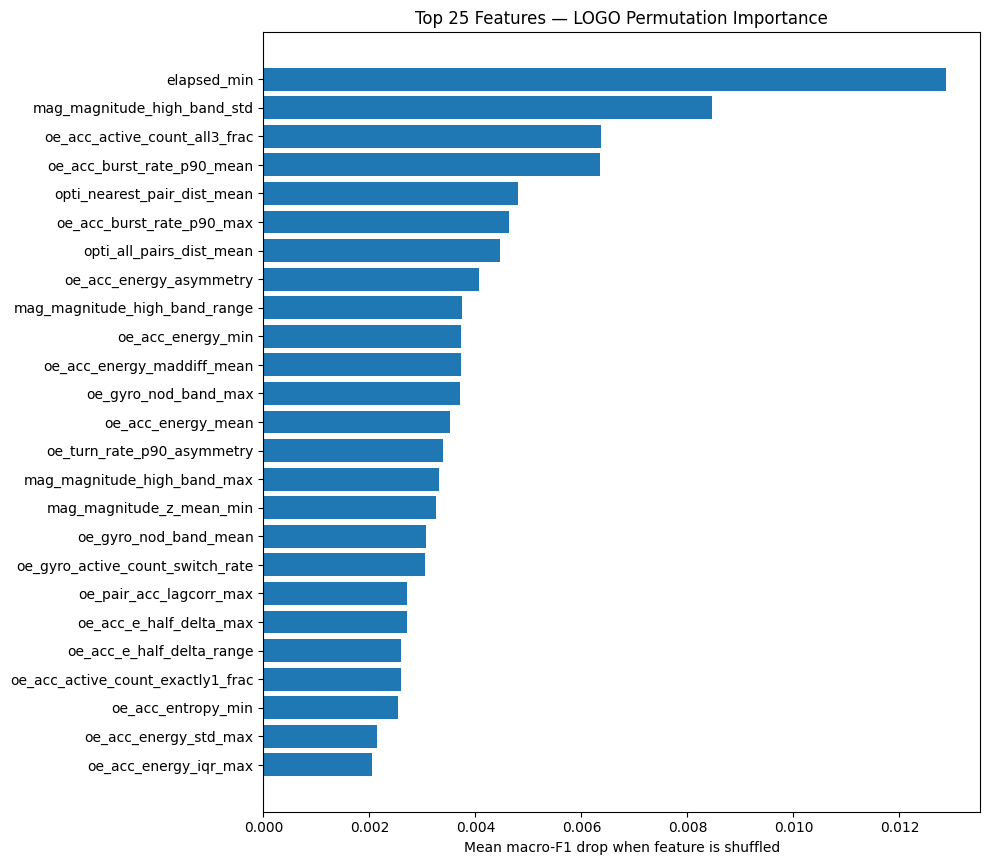

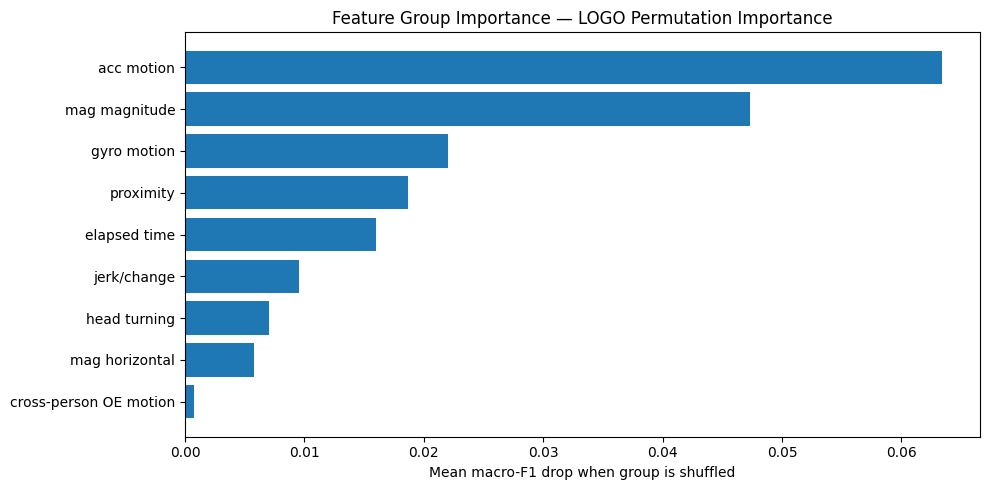

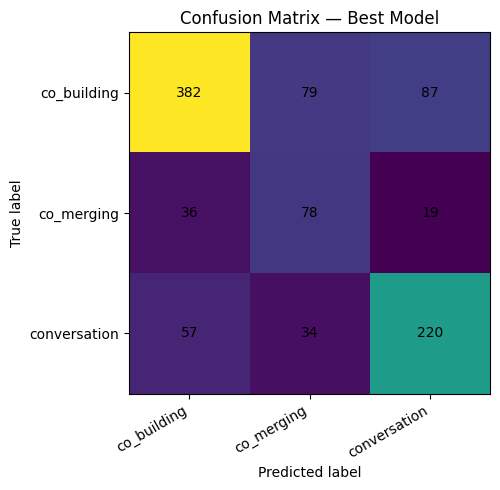

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


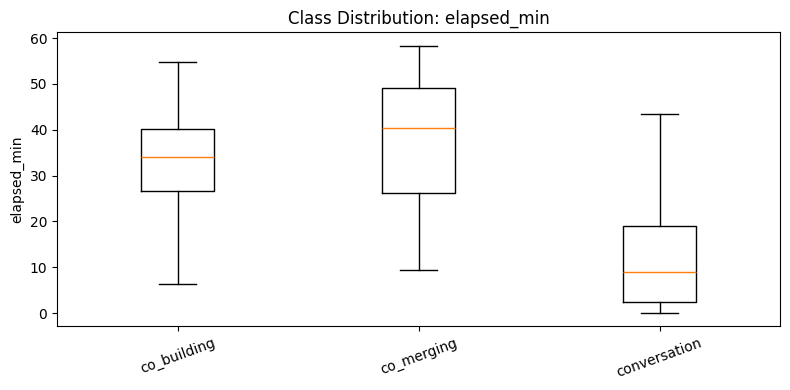

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


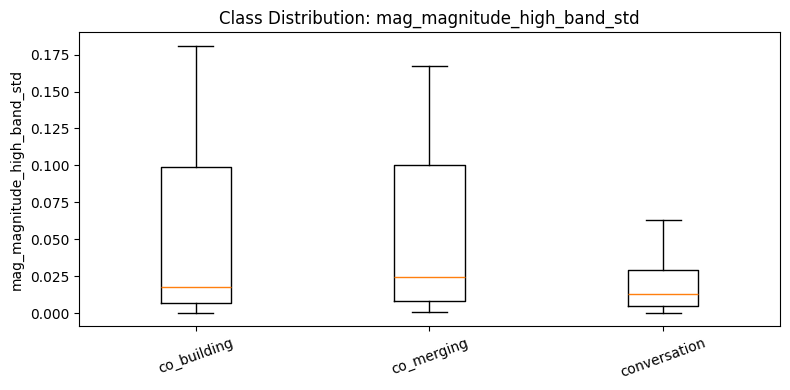

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


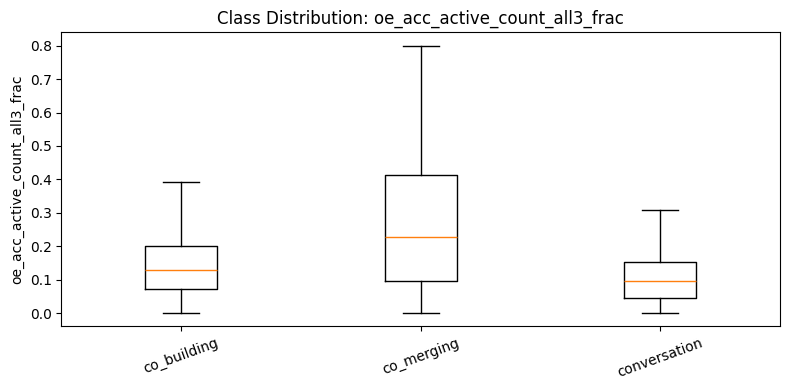

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


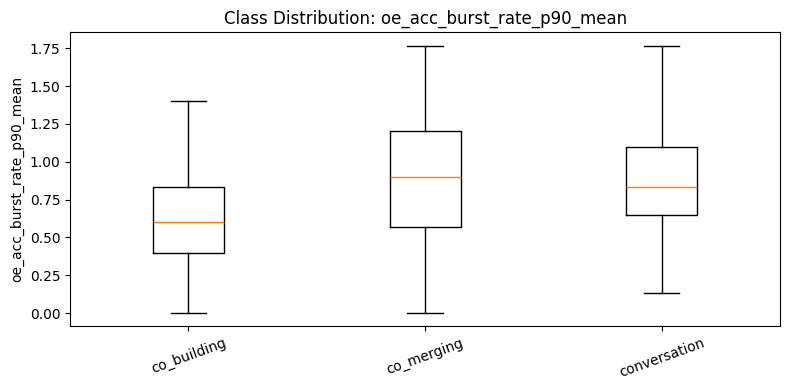

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


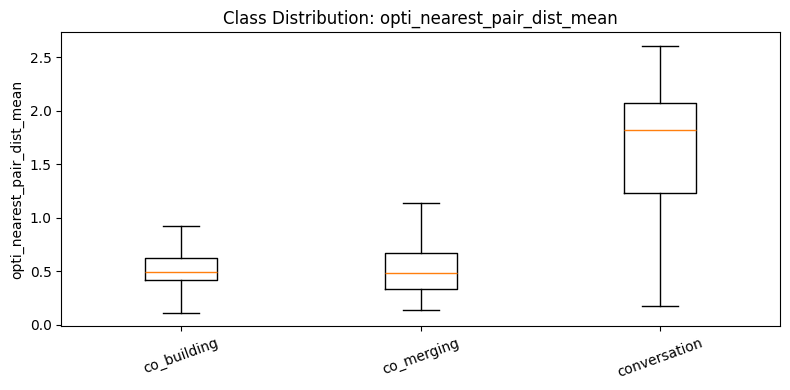

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


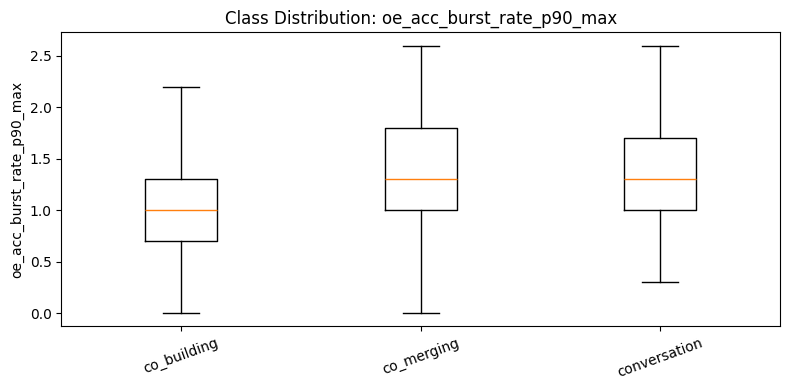

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


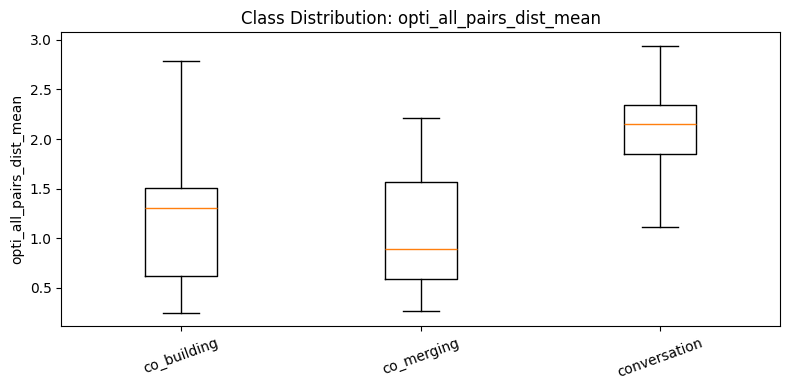

/tmp/ipykernel_733/2339648051.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


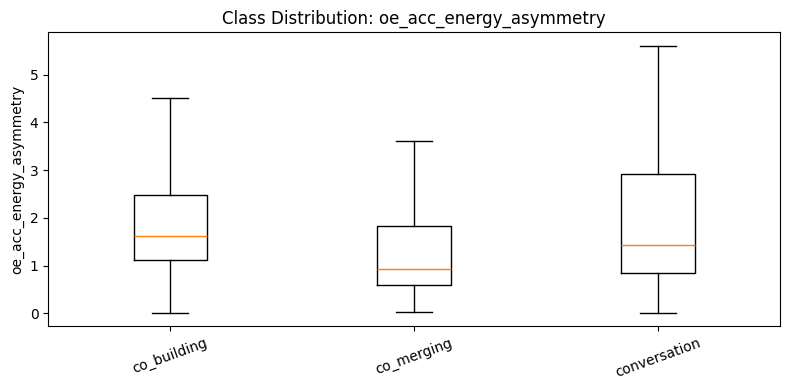

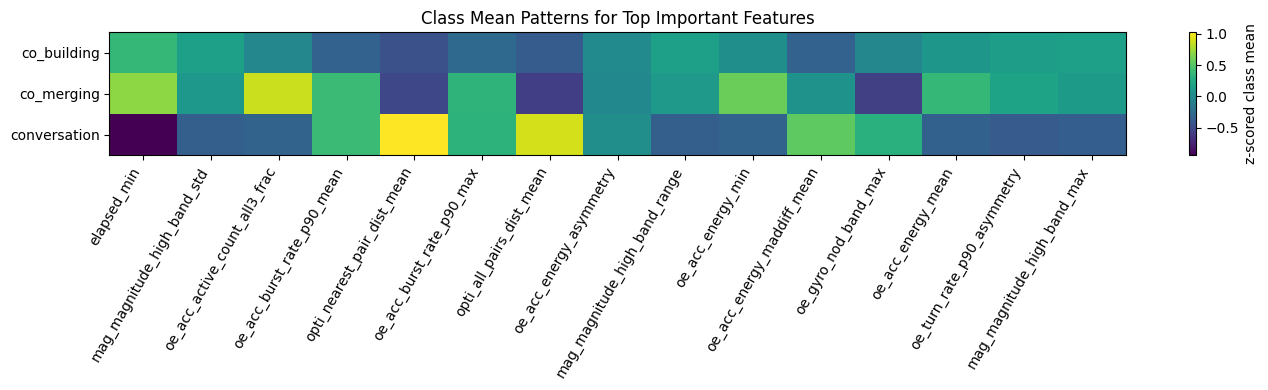


Class means for top features, z-scored:


,elapsed_min,mag_magnitude_high_band_std,oe_acc_active_count_all3_frac,oe_acc_burst_rate_p90_mean,opti_nearest_pair_dist_mean,oe_acc_burst_rate_p90_max,opti_all_pairs_dist_mean,oe_acc_energy_asymmetry,mag_magnitude_high_band_range,oe_acc_energy_min,oe_acc_energy_maddiff_mean,oe_gyro_nod_band_max,oe_acc_energy_mean,oe_turn_rate_p90_asymmetry,mag_magnitude_high_band_max
recognition_label,,,,,,,,,,,,,,,
co_building,0.37,0.17,-0.03,-0.32,-0.45,-0.27,-0.37,-0.01,0.16,0.04,-0.32,-0.03,0.10,0.16,0.17
co_merging,0.69,0.11,0.87,0.40,-0.52,0.33,-0.57,-0.02,0.12,0.58,0.06,-0.57,0.37,0.20,0.13
conversation,-0.94,-0.34,-0.32,0.40,1.02,0.33,0.89,0.03,-0.34,-0.31,0.54,0.30,-0.33,-0.37,-0.35



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/best_model_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/individual_permutation_importance.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/group_permutation_importance.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/class_mean_top_features_zscored.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/top_25_feature_importance.png
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/feature_group_importance.png
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/confusion_matrix_best_model.png
/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model/class_mean_heatmap_top_features.png


In [ ]:
# ================================================================
# EXPLAINABILITY FOR BEST MODEL
#
# Best model:
#   RBF SVC, C=1.0, gamma="scale"
#
# Best feature set:
#   OE motion + MAG magnitude + ENG7 proximity + elapsed_min
#
# Explainability method:
#   LOGO held-out permutation importance
#
# Meaning:
#   If shuffling a feature on the held-out group hurts macro-F1,
#   that feature was important for generalization.
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC


# ================================================================
# Paths
# ================================================================

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/explainability_best_model"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_recognition_labels(base_df, rec_df):
    labels = []

    for _, w in base_df.iterrows():
        sub = rec_df[
            (rec_df["group"] == w["group"])
            & (rec_df["mid"] >= w["window_start"])
            & (rec_df["mid"] < w["window_end"])
        ]

        labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

    out = base_df.copy()
    out["recognition_label"] = labels
    return out


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def pretty_name(f):
    f = f.replace("oebest__", "")
    return f


def feature_group(f):
    ff = f.replace("oebest__", "")

    if ff == "elapsed_min":
        return "elapsed time"

    if ff.startswith("opti_"):
        return "proximity"

    if ff.startswith("mag_"):
        if "active" in ff:
            return "mag activity"
        if "horizontal" in ff:
            return "mag horizontal"
        if "magnitude" in ff:
            return "mag magnitude"
        return "mag other"

    if "pair" in ff:
        return "cross-person OE motion"

    if "jerk" in ff:
        return "jerk/change"

    if "turn" in ff:
        return "head turning"

    if "gyro" in ff:
        return "gyro motion"

    if "acc" in ff:
        return "acc motion"

    return "OE motion other"


def plot_barh(df_plot, x_col, y_col, title, xlabel, path=None, top_n=None):
    d = df_plot.copy()

    if top_n is not None:
        d = d.head(top_n)

    d = d.iloc[::-1]

    plt.figure(figsize=(10, max(5, 0.35 * len(d))))
    plt.barh(d[y_col], d[x_col])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()

    if path:
        plt.savefig(path, dpi=200, bbox_inches="tight")

    plt.show()


# ================================================================
# Load files
# ================================================================

eng7 = pd.read_csv(ENG7_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0


# ================================================================
# Label ENG7 windows
# ================================================================

eng7 = add_recognition_labels(eng7, rec)

eng7 = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("ENG7 LABELED DATA")
print("=" * 100)
print("Shape:", eng7.shape)
print("Class counts:")
print(eng7["recognition_label"].value_counts().to_string())


# ================================================================
# ENG7 proximity features exactly like your old code
# ================================================================

eng7_opti = [c for c in eng7.columns if c.startswith("opti_")]

print("\nENG7 proximity columns:")
for c in eng7_opti:
    print(" ", c)


# ================================================================
# Add non-normalized elapsed time
# ================================================================

eng7["window_mid"] = (eng7["window_start"] + eng7["window_end"]) / 2.0

group_start = eng7.groupby("group")["window_mid"].transform("min")
eng7["elapsed_min"] = (eng7["window_mid"] - group_start) / 60.0


# ================================================================
# Build OE best features from OE10:
#   OE9 motion + MAG magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best = unique_feats(motion + mag_magnitude)

print("\nOE best feature count:", len(oe_best))


# Rename OE features to avoid column-name collisions
oe10_small = oe10[["group", "window_start", "window_end"] + oe_best].copy()

rename_map = {c: f"oebest__{c}" for c in oe_best}
oe10_small = oe10_small.rename(columns=rename_map)

oe_best_renamed = [rename_map[c] for c in oe_best]


# ================================================================
# Merge ENG7 proximity/time with OE10 best features
# ================================================================

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    e = add_merge_keys(eng7, decimals)
    o = add_merge_keys(oe10_small, decimals)

    o["_matched_oe10"] = 1

    merged_try = e.merge(
        o.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_oe10"].fillna(0).sum())

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

merged = best_merge.copy()
merged = merged[merged["_matched_oe10"] == 1].reset_index(drop=True)

print("\n" + "=" * 100)
print("COMMON ENG7 + OE10 DATA")
print("=" * 100)
print("Best merge rounding:", best_round)
print("Matched rows:", best_matched, "/", len(eng7))
print("Shape:", merged.shape)
print("Class counts:")
print(merged["recognition_label"].value_counts().to_string())


# ================================================================
# Final best feature set
# ================================================================

features = unique_feats(
    oe_best_renamed
    + eng7_opti
    + ["elapsed_min"]
)

features = clean_feature_list(merged, features)

print("\nFinal best feature count:", len(features))

group_counts = pd.Series([feature_group(f) for f in features]).value_counts()

print("\nFeature groups:")
print(group_counts.to_string())


# ================================================================
# Best model
# ================================================================

model = SVC(
    C=1.0,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced",
    random_state=42,
)


# ================================================================
# LOGO evaluation + individual permutation importance
# ================================================================

X_df = merged[features].apply(pd.to_numeric, errors="coerce")
X = X_df.values
y = merged["recognition_label"].values
groups = merged["group"].values

logo = LeaveOneGroupOut()
rng = np.random.default_rng(42)

N_REPEATS = 5

all_predictions = []
importance_rows = []
group_importance_rows = []

unique_feature_groups = sorted(set(feature_group(f) for f in features))

print("\n" + "=" * 100)
print("LOGO EVALUATION + PERMUTATION IMPORTANCE")
print("=" * 100)

for fold_id, (tr, te) in enumerate(logo.split(X, y, groups), start=1):
    test_group = int(np.unique(groups[te])[0])

    clf = make_pipeline(
        SimpleImputer(strategy="median"),
        RobustScaler(),
        clone(model),
    )

    clf.fit(X[tr], y[tr])

    base_pred = clf.predict(X[te])

    base_acc = accuracy_score(y[te], base_pred)
    base_macro = f1_score(y[te], base_pred, average="macro", zero_division=0)
    base_bal = balanced_accuracy_score(y[te], base_pred)

    print(
        f"Fold {fold_id:02d} | test group {test_group:2d} | "
        f"acc={base_acc:.3f} | macroF1={base_macro:.3f} | balAcc={base_bal:.3f}"
    )

    all_predictions.append(
        pd.DataFrame({
            "group": groups[te],
            "true": y[te],
            "pred": base_pred,
            "correct": y[te] == base_pred,
        })
    )

    # ------------------------------------------------------------
    # Individual feature permutation importance
    # ------------------------------------------------------------

    for j, f in enumerate(features):
        drops = []

        for r in range(N_REPEATS):
            X_perm = X[te].copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])

            perm_pred = clf.predict(X_perm)
            perm_macro = f1_score(y[te], perm_pred, average="macro", zero_division=0)

            drops.append(base_macro - perm_macro)

        importance_rows.append({
            "fold": fold_id,
            "test_group": test_group,
            "feature": f,
            "pretty_feature": pretty_name(f),
            "feature_group": feature_group(f),
            "importance_macro_f1_drop": float(np.mean(drops)),
            "importance_std": float(np.std(drops)),
        })

    # ------------------------------------------------------------
    # Group-level permutation importance
    # ------------------------------------------------------------

    for gname in unique_feature_groups:
        idxs = [i for i, f in enumerate(features) if feature_group(f) == gname]

        if len(idxs) == 0:
            continue

        drops = []

        for r in range(N_REPEATS):
            X_perm = X[te].copy()

            for j in idxs:
                X_perm[:, j] = rng.permutation(X_perm[:, j])

            perm_pred = clf.predict(X_perm)
            perm_macro = f1_score(y[te], perm_pred, average="macro", zero_division=0)

            drops.append(base_macro - perm_macro)

        group_importance_rows.append({
            "fold": fold_id,
            "test_group": test_group,
            "feature_group": gname,
            "n_features": len(idxs),
            "importance_macro_f1_drop": float(np.mean(drops)),
            "importance_std": float(np.std(drops)),
        })


pred_df = pd.concat(all_predictions, ignore_index=True)
imp_df = pd.DataFrame(importance_rows)
group_imp_df = pd.DataFrame(group_importance_rows)


# ================================================================
# Overall performance
# ================================================================

overall_acc = accuracy_score(pred_df["true"], pred_df["pred"])
overall_macro = f1_score(pred_df["true"], pred_df["pred"], average="macro", zero_division=0)
overall_weighted = f1_score(pred_df["true"], pred_df["pred"], average="weighted", zero_division=0)
overall_bal = balanced_accuracy_score(pred_df["true"], pred_df["pred"])

print("\n" + "=" * 100)
print("OVERALL BEST MODEL PERFORMANCE")
print("=" * 100)
print(f"Accuracy:          {overall_acc:.3f}")
print(f"Macro-F1:          {overall_macro:.3f}")
print(f"Weighted-F1:       {overall_weighted:.3f}")
print(f"Balanced accuracy: {overall_bal:.3f}")

print("\nClassification report:")
print(
    classification_report(
        pred_df["true"],
        pred_df["pred"],
        labels=CORE,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        pred_df["true"],
        pred_df["pred"],
        labels=CORE,
    ),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm)


# ================================================================
# Aggregate individual feature importance
# ================================================================

feature_importance = (
    imp_df
    .groupby(["feature", "pretty_feature", "feature_group"], as_index=False)
    .agg(
        mean_macro_f1_drop=("importance_macro_f1_drop", "mean"),
        std_macro_f1_drop=("importance_macro_f1_drop", "std"),
    )
    .sort_values("mean_macro_f1_drop", ascending=False)
    .reset_index(drop=True)
)

# Negative drops mean shuffling slightly improved performance.
# Usually we focus on positive drops.
feature_importance["mean_macro_f1_drop_clipped"] = feature_importance["mean_macro_f1_drop"].clip(lower=0)

print("\n" + "=" * 100)
print("TOP INDIVIDUAL FEATURES BY PERMUTATION IMPORTANCE")
print("=" * 100)

display(feature_importance.head(30).round(4))


# ================================================================
# Aggregate group importance
# ================================================================

group_importance = (
    group_imp_df
    .groupby("feature_group", as_index=False)
    .agg(
        n_features=("n_features", "max"),
        mean_macro_f1_drop=("importance_macro_f1_drop", "mean"),
        std_macro_f1_drop=("importance_macro_f1_drop", "std"),
    )
    .sort_values("mean_macro_f1_drop", ascending=False)
    .reset_index(drop=True)
)

group_importance["mean_macro_f1_drop_clipped"] = group_importance["mean_macro_f1_drop"].clip(lower=0)

print("\n" + "=" * 100)
print("FEATURE GROUP IMPORTANCE")
print("=" * 100)

display(group_importance.round(4))


# ================================================================
# Visualization 1: Top individual features
# ================================================================

top_n = 25
top_features = feature_importance.head(top_n).copy()

plot_barh(
    df_plot=top_features,
    x_col="mean_macro_f1_drop_clipped",
    y_col="pretty_feature",
    title=f"Top {top_n} Features — LOGO Permutation Importance",
    xlabel="Mean macro-F1 drop when feature is shuffled",
    path=f"{OUT_DIR}/top_{top_n}_feature_importance.png",
)


# ================================================================
# Visualization 2: Feature group importance
# ================================================================

plot_barh(
    df_plot=group_importance,
    x_col="mean_macro_f1_drop_clipped",
    y_col="feature_group",
    title="Feature Group Importance — LOGO Permutation Importance",
    xlabel="Mean macro-F1 drop when group is shuffled",
    path=f"{OUT_DIR}/feature_group_importance.png",
)


# ================================================================
# Visualization 3: Confusion matrix
# ================================================================

plt.figure(figsize=(6, 5))
plt.imshow(cm.values)
plt.xticks(range(len(CORE)), CORE, rotation=30, ha="right")
plt.yticks(range(len(CORE)), CORE)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Best Model")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm.values[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_best_model.png", dpi=200, bbox_inches="tight")
plt.show()


# ================================================================
# Visualization 4: Top feature class distributions
#
# This helps interpret direction:
#   Which class has higher/lower values for the most important features?
# ================================================================

top_dist_features = feature_importance.head(8)["feature"].tolist()

for f in top_dist_features:
    temp = merged[[f, "recognition_label"]].copy()
    temp[f] = pd.to_numeric(temp[f], errors="coerce")

    classes = CORE
    data = [
        temp[temp["recognition_label"] == c][f].dropna().values
        for c in classes
    ]

    plt.figure(figsize=(8, 4))
    plt.boxplot(data, labels=classes, showfliers=False)
    plt.ylabel(pretty_name(f))
    plt.title(f"Class Distribution: {pretty_name(f)}")
    plt.xticks(rotation=20)
    plt.tight_layout()

    safe_name = pretty_name(f).replace("/", "_").replace(" ", "_").replace(":", "_")
    safe_name = "".join(ch if ch.isalnum() or ch in "_-" else "_" for ch in safe_name)

    plt.savefig(f"{OUT_DIR}/class_distribution_{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.show()


# ================================================================
# Visualization 5: Class means for top features
# ================================================================

top_mean_features = feature_importance.head(15)["feature"].tolist()

mean_df = merged[top_mean_features + ["recognition_label"]].copy()

for f in top_mean_features:
    mean_df[f] = pd.to_numeric(mean_df[f], errors="coerce")

# z-score for comparability
z_df = mean_df.copy()

for f in top_mean_features:
    z_df[f] = (z_df[f] - z_df[f].mean()) / (z_df[f].std() + 1e-9)

class_means = (
    z_df
    .groupby("recognition_label")[top_mean_features]
    .mean()
    .loc[CORE]
)

class_means_pretty = class_means.copy()
class_means_pretty.columns = [pretty_name(c) for c in class_means_pretty.columns]

plt.figure(figsize=(14, 4))
plt.imshow(class_means_pretty.values, aspect="auto")
plt.yticks(range(len(class_means_pretty.index)), class_means_pretty.index)
plt.xticks(
    range(len(class_means_pretty.columns)),
    class_means_pretty.columns,
    rotation=60,
    ha="right",
)
plt.colorbar(label="z-scored class mean")
plt.title("Class Mean Patterns for Top Important Features")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/class_mean_heatmap_top_features.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nClass means for top features, z-scored:")
display(class_means_pretty.round(2))


# ================================================================
# Save outputs
# ================================================================

pred_path = f"{OUT_DIR}/best_model_predictions.csv"
feature_imp_path = f"{OUT_DIR}/individual_permutation_importance.csv"
group_imp_path = f"{OUT_DIR}/group_permutation_importance.csv"
class_means_path = f"{OUT_DIR}/class_mean_top_features_zscored.csv"

pred_df.to_csv(pred_path, index=False)
feature_importance.to_csv(feature_imp_path, index=False)
group_importance.to_csv(group_imp_path, index=False)
class_means_pretty.to_csv(class_means_path)

print("\nSaved:")
print(pred_path)
print(feature_imp_path)
print(group_imp_path)
print(class_means_path)
print(f"{OUT_DIR}/top_{top_n}_feature_importance.png")
print(f"{OUT_DIR}/feature_group_importance.png")
print(f"{OUT_DIR}/confusion_matrix_best_model.png")
print(f"{OUT_DIR}/class_mean_heatmap_top_features.png")

ENG7 LABELED DATA
Shape: (992, 23)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

OPTITRACK / PROXIMITY COLUMNS USED
Number of opti_ columns: 3
  opti_nearest_pair_dist_mean
  opti_all_pairs_dist_mean
  opti_all_pairs_dist_std

SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
opti_nearest_pair_dist_mean,992.0,0.932,0.685,0.045,0.446,0.585,1.548,2.609
opti_all_pairs_dist_mean,992.0,1.436,0.672,0.246,0.799,1.428,2.024,2.941
opti_all_pairs_dist_std,992.0,0.423,0.253,0.027,0.196,0.391,0.644,1.171



Missing values:
opti_nearest_pair_dist_mean    0
opti_all_pairs_dist_mean       0
opti_all_pairs_dist_std        0

CLASS MEANS — RAW OPTITRACK VALUES


,opti_nearest_pair_dist_mean,opti_all_pairs_dist_mean,opti_all_pairs_dist_std
recognition_label,,,
co_building,0.621,1.189,0.460
co_merging,0.579,1.051,0.428
conversation,1.632,2.035,0.354



CLASS MEANS — Z-SCORED OPTITRACK VALUES


,opti_nearest_pair_dist_mean,opti_all_pairs_dist_mean,opti_all_pairs_dist_std
recognition_label,,,
co_building,-0.45,-0.37,0.15
co_merging,-0.52,-0.57,0.02
conversation,1.02,0.89,-0.27


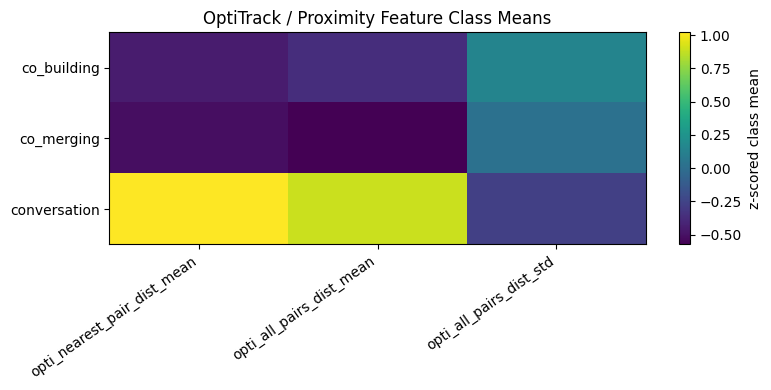

/tmp/ipykernel_733/4222190076.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=CORE, showfliers=False)


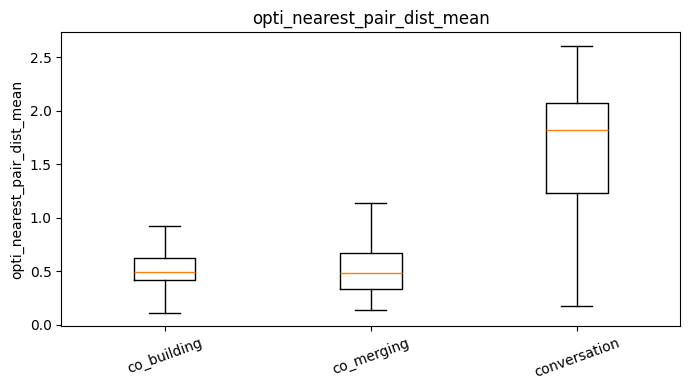

/tmp/ipykernel_733/4222190076.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=CORE, showfliers=False)


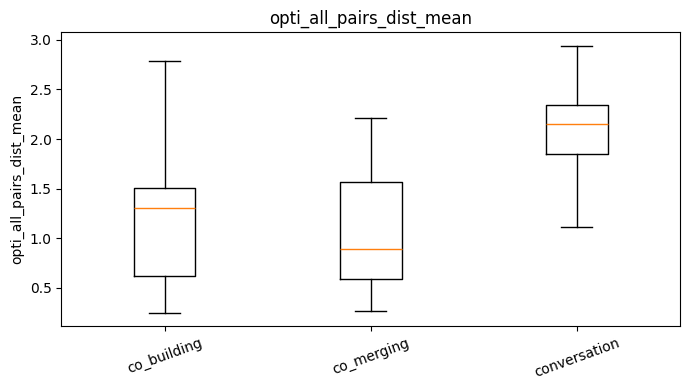

/tmp/ipykernel_733/4222190076.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=CORE, showfliers=False)


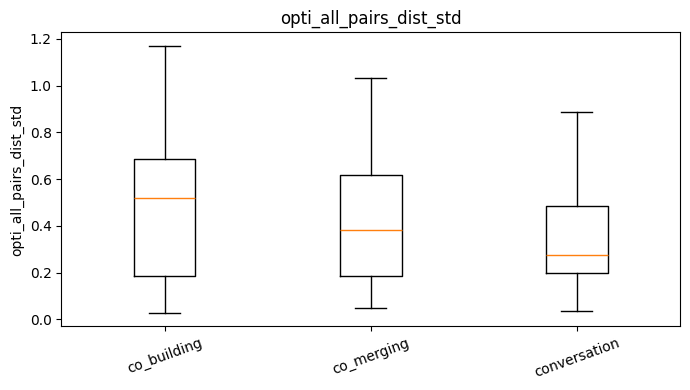


PROXIMITY ONLY — RANDOM FOREST LOGO
Accuracy:          0.685
Macro-F1:          0.588
Balanced accuracy: 0.590

Classification report:
              precision    recall  f1-score   support

 co_building       0.75      0.73      0.74       548
  co_merging       0.24      0.25      0.24       133
conversation       0.76      0.79      0.78       311

    accuracy                           0.69       992
   macro avg       0.59      0.59      0.59       992
weighted avg       0.69      0.69      0.69       992


Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,401,86,61
true_co_merging,84,33,16
true_conversation,47,18,246



PROXIMITY FEATURE IMPORTANCE — RF


,rf_importance
opti_nearest_pair_dist_mean,0.3775
opti_all_pairs_dist_mean,0.3731
opti_all_pairs_dist_std,0.2494


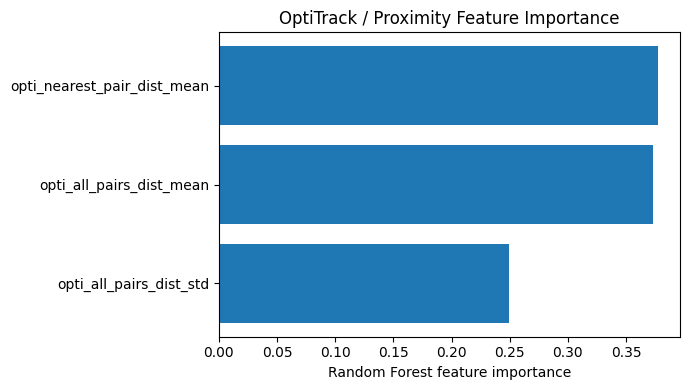

In [ ]:
# ================================================================
# CHECK EXACT OPTITRACK / PROXIMITY FEATURES USED FROM ENG7
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

CORE = ["co_building", "co_merging", "conversation"]

eng7 = pd.read_csv(ENG7_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0


# ================================================================
# Label ENG7 windows exactly like old code
# ================================================================

labels = []

for _, w in eng7.iterrows():
    sub = rec[
        (rec["group"] == w["group"])
        & (rec["mid"] >= w["window_start"])
        & (rec["mid"] < w["window_end"])
    ]

    labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

eng7["recognition_label"] = labels

df = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("ENG7 LABELED DATA")
print("=" * 100)
print("Shape:", df.shape)
print("Class counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Find all OptiTrack / proximity columns
# ================================================================

opti_cols = [c for c in df.columns if c.startswith("opti_")]

print("\n" + "=" * 100)
print("OPTITRACK / PROXIMITY COLUMNS USED")
print("=" * 100)

print("Number of opti_ columns:", len(opti_cols))

for c in opti_cols:
    print(" ", c)


# ================================================================
# Basic diagnostics
# ================================================================

print("\n" + "=" * 100)
print("SUMMARY STATISTICS")
print("=" * 100)

display(
    df[opti_cols]
    .describe()
    .T
    .round(3)
)

print("\nMissing values:")
print(df[opti_cols].isna().sum().to_string())


# ================================================================
# Class means: raw values
# ================================================================

print("\n" + "=" * 100)
print("CLASS MEANS — RAW OPTITRACK VALUES")
print("=" * 100)

class_means_raw = (
    df
    .groupby("recognition_label")[opti_cols]
    .mean()
    .loc[CORE]
)

display(class_means_raw.round(3))


# ================================================================
# Class means: z-scored values
# Easier to interpret direction
# ================================================================

z = df[opti_cols].copy()

for c in opti_cols:
    z[c] = (z[c] - z[c].mean()) / (z[c].std() + 1e-9)

z["recognition_label"] = df["recognition_label"]

class_means_z = (
    z
    .groupby("recognition_label")[opti_cols]
    .mean()
    .loc[CORE]
)

print("\n" + "=" * 100)
print("CLASS MEANS — Z-SCORED OPTITRACK VALUES")
print("=" * 100)

display(class_means_z.round(2))


# ================================================================
# Plot class means
# ================================================================

plt.figure(figsize=(8, 4))
plt.imshow(class_means_z.values, aspect="auto")
plt.yticks(range(len(CORE)), CORE)
plt.xticks(range(len(opti_cols)), opti_cols, rotation=35, ha="right")
plt.colorbar(label="z-scored class mean")
plt.title("OptiTrack / Proximity Feature Class Means")
plt.tight_layout()
plt.show()


# ================================================================
# Boxplots per OptiTrack feature
# ================================================================

for c in opti_cols:
    data = [
        df[df["recognition_label"] == lab][c].dropna().values
        for lab in CORE
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=CORE, showfliers=False)
    plt.title(c)
    plt.ylabel(c)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


# ================================================================
# Re-run proximity-only Random Forest exactly like old result
# ================================================================

X = df[opti_cols].apply(pd.to_numeric, errors="coerce").values
y = df["recognition_label"].values
groups = df["group"].values

logo = LeaveOneGroupOut()

rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1,
)

yt_all = []
yp_all = []

for tr, te in logo.split(X, y, groups):
    clf = make_pipeline(
        SimpleImputer(strategy="median"),
        rf,
    )

    clf.fit(X[tr], y[tr])
    pred = clf.predict(X[te])

    yt_all.extend(y[te])
    yp_all.extend(pred)

yt_all = np.array(yt_all)
yp_all = np.array(yp_all)

acc = accuracy_score(yt_all, yp_all)
macro = f1_score(yt_all, yp_all, average="macro", zero_division=0)
bal = balanced_accuracy_score(yt_all, yp_all)

print("\n" + "=" * 100)
print("PROXIMITY ONLY — RANDOM FOREST LOGO")
print("=" * 100)
print(f"Accuracy:          {acc:.3f}")
print(f"Macro-F1:          {macro:.3f}")
print(f"Balanced accuracy: {bal:.3f}")

print("\nClassification report:")
print(classification_report(yt_all, yp_all, labels=CORE, zero_division=0))

cm = pd.DataFrame(
    confusion_matrix(yt_all, yp_all, labels=CORE),
    index=[f"true_{c}" for c in CORE],
    columns=[f"pred_{c}" for c in CORE],
)

print("\nConfusion matrix:")
display(cm)


# ================================================================
# Random Forest feature importance for proximity-only model
# Trained on all data only for interpretation
# ================================================================

rf_full = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1,
)

X_full = (
    df[opti_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(df[opti_cols].median())
    .values
)

rf_full.fit(X_full, y)

imp = pd.Series(rf_full.feature_importances_, index=opti_cols).sort_values(ascending=False)

print("\n" + "=" * 100)
print("PROXIMITY FEATURE IMPORTANCE — RF")
print("=" * 100)

display(imp.round(4).to_frame("rf_importance"))

plt.figure(figsize=(7, 4))
plt.barh(imp.index[::-1], imp.values[::-1])
plt.xlabel("Random Forest feature importance")
plt.title("OptiTrack / Proximity Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# PRINT + SAVE EXACT FEATURE LISTS USED IN FINAL MODELS
#
# Saves:
#   1) OE best only features
#   2) OE best + ENG7 proximity features
#   3) OE best + ENG7 proximity + elapsed_min features
#
# Current best model:
#   RBF SVC
#   OE motion + MAG magnitude + ENG7 proximity + elapsed_min
# ================================================================

import os
import numpy as np
import pandas as pd

# ================================================================
# Paths
# ================================================================

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
OE10_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/final_feature_lists"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_recognition_labels(base_df, rec_df):
    labels = []

    for _, w in base_df.iterrows():
        sub = rec_df[
            (rec_df["group"] == w["group"])
            & (rec_df["mid"] >= w["window_start"])
            & (rec_df["mid"] < w["window_end"])
        ]

        labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

    out = base_df.copy()
    out["recognition_label"] = labels
    return out


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def feature_source(feature):
    f = feature.replace("oebest__", "")

    if f == "elapsed_min":
        return "elapsed_time"

    if f.startswith("opti_"):
        return "ENG7_proximity_OptiTrack"

    if f.startswith("mag_"):
        return "OpenEarable_magnetometer"

    if f.startswith("oe_") or f.startswith("ear_"):
        return "OpenEarable_acc_gyro"

    return "other"


def feature_group(feature):
    f = feature.replace("oebest__", "")

    if f == "elapsed_min":
        return "elapsed time"

    if f.startswith("opti_"):
        return "proximity"

    if f.startswith("mag_"):
        if "magnitude" in f:
            return "mag magnitude"
        if "horizontal" in f:
            return "mag horizontal"
        if "active" in f:
            return "mag activity"
        return "mag other"

    if "pair" in f:
        return "cross-person OE motion"

    if "jerk" in f:
        return "jerk/change"

    if "turn" in f:
        return "head turning"

    if "gyro" in f:
        return "gyro motion"

    if "acc" in f:
        return "acc motion"

    return "OE motion other"


def original_name(feature):
    return feature.replace("oebest__", "")


def save_feature_list(name, feats, out_dir):
    rows = []

    for i, f in enumerate(feats, start=1):
        rows.append({
            "rank": i,
            "feature_used_in_model": f,
            "original_feature_name": original_name(f),
            "source": feature_source(f),
            "feature_group": feature_group(f),
        })

    df_out = pd.DataFrame(rows)

    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace(":", "")
        .replace("/", "_")
    )

    csv_path = f"{out_dir}/{safe_name}_features.csv"
    txt_path = f"{out_dir}/{safe_name}_features.txt"

    df_out.to_csv(csv_path, index=False)

    with open(txt_path, "w") as f:
        f.write(name + "\n")
        f.write("=" * len(name) + "\n\n")
        f.write(f"Number of features: {len(feats)}\n\n")

        for source, sub in df_out.groupby("source"):
            f.write("\n" + "-" * 100 + "\n")
            f.write(source + f" | n={len(sub)}\n")
            f.write("-" * 100 + "\n")

            for feat in sub["original_feature_name"].tolist():
                f.write(feat + "\n")

    return df_out, csv_path, txt_path


# ================================================================
# Load data
# ================================================================

eng7 = pd.read_csv(ENG7_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0


# ================================================================
# Label ENG7 windows
# ================================================================

eng7 = add_recognition_labels(eng7, rec)

eng7 = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)


# ================================================================
# ENG7 proximity features
# ================================================================

eng7_opti = [c for c in eng7.columns if c.startswith("opti_")]


# ================================================================
# Add elapsed_min
# ================================================================

eng7["window_mid"] = (eng7["window_start"] + eng7["window_end"]) / 2.0
group_start = eng7.groupby("group")["window_mid"].transform("min")
eng7["elapsed_min"] = (eng7["window_mid"] - group_start) / 60.0


# ================================================================
# Build OE best features from OE10
# OE best = motion + MAG magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best = unique_feats(motion + mag_magnitude)

# Rename OE features to avoid collision after merge
oe10_small = oe10[["group", "window_start", "window_end"] + oe_best].copy()

rename_map = {c: f"oebest__{c}" for c in oe_best}
oe10_small = oe10_small.rename(columns=rename_map)

oe_best_renamed = [rename_map[c] for c in oe_best]


# ================================================================
# Merge ENG7 proximity/time with OE10 features
# ================================================================

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    e = add_merge_keys(eng7, decimals)
    o = add_merge_keys(oe10_small, decimals)

    o["_matched_oe10"] = 1

    merged_try = e.merge(
        o.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_oe10"].fillna(0).sum())

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

merged = best_merge.copy()
merged = merged[merged["_matched_oe10"] == 1].reset_index(drop=True)

print("=" * 100)
print("MERGED DATA CHECK")
print("=" * 100)
print("Best merge rounding:", best_round)
print("Matched rows:", best_matched, "/", len(eng7))
print("Merged shape:", merged.shape)
print("\nClass counts:")
print(merged["recognition_label"].value_counts().to_string())


# ================================================================
# Define final feature sets
# ================================================================

feature_sets = {
    "OE best only: motion + MAG magnitude": unique_feats(
        oe_best_renamed
    ),

    "OE best + ENG7 proximity": unique_feats(
        oe_best_renamed
        + eng7_opti
    ),

    "OE best + ENG7 proximity + elapsed time": unique_feats(
        oe_best_renamed
        + eng7_opti
        + ["elapsed_min"]
    ),
}


# ================================================================
# Clean, print, save
# ================================================================

all_saved = {}

print("\n" + "=" * 100)
print("FINAL FEATURE LISTS")
print("=" * 100)

for name, raw_feats in feature_sets.items():
    usable_feats = clean_feature_list(merged, raw_feats)

    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)
    print("Raw feature count:   ", len(raw_feats))
    print("Usable feature count:", len(usable_feats))

    feature_df, csv_path, txt_path = save_feature_list(
        name=name,
        feats=usable_feats,
        out_dir=OUT_DIR,
    )

    all_saved[name] = {
        "df": feature_df,
        "csv_path": csv_path,
        "txt_path": txt_path,
    }

    print("\nCounts by source:")
    print(feature_df["source"].value_counts().to_string())

    print("\nCounts by feature group:")
    print(feature_df["feature_group"].value_counts().to_string())

    print("\nFirst 30 features:")
    print(feature_df["original_feature_name"].head(30).to_string(index=False))

    print("\nSaved:")
    print(csv_path)
    print(txt_path)


# ================================================================
# Save one combined file too
# ================================================================

combined_rows = []

for model_name, obj in all_saved.items():
    temp = obj["df"].copy()
    temp.insert(0, "feature_set", model_name)
    combined_rows.append(temp)

combined_df = pd.concat(combined_rows, ignore_index=True)

combined_csv = f"{OUT_DIR}/combined_final_feature_lists.csv"
combined_txt = f"{OUT_DIR}/combined_final_feature_lists.txt"

combined_df.to_csv(combined_csv, index=False)

with open(combined_txt, "w") as f:
    for model_name, sub in combined_df.groupby("feature_set"):
        f.write("\n" + "=" * 120 + "\n")
        f.write(model_name + f" | n={len(sub)}\n")
        f.write("=" * 120 + "\n")

        for source, sub2 in sub.groupby("source"):
            f.write("\n" + "-" * 100 + "\n")
            f.write(source + f" | n={len(sub2)}\n")
            f.write("-" * 100 + "\n")

            for feat in sub2["original_feature_name"].tolist():
                f.write(feat + "\n")

print("\n" + "=" * 100)
print("COMBINED FILES SAVED")
print("=" * 100)
print(combined_csv)
print(combined_txt)


# ================================================================
# Quick final reminder
# ================================================================

print("\n" + "=" * 100)
print("CURRENT BEST MODEL FEATURE SET")
print("=" * 100)
print("OE best + ENG7 proximity + elapsed time")
print("Expected score from previous run:")
print("accuracy = 0.685 | macro-F1 = 0.640 | balanced accuracy = 0.664")

MERGED DATA CHECK
Best merge rounding: 6
Matched rows: 992 / 992
Merged shape: (992, 340)

Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

FINAL FEATURE LISTS

OE best only: motion + MAG magnitude
Raw feature count:    311
Usable feature count: 305

Counts by source:
source
OpenEarable_acc_gyro        225
OpenEarable_magnetometer     80

Counts by feature group:
feature_group
acc motion                88
gyro motion               74
mag magnitude             65
jerk/change               28
cross-person OE motion    20
head turning              15
mag horizontal            15

First 30 features:
   ear_head_turn_event_rate
         oe_acc_energy_mean
          oe_acc_energy_std
          oe_acc_energy_min
          oe_acc_energy_max
        oe_acc_energy_range
     oe_acc_energy_std_mean
      oe_acc_energy_std_std
      oe_acc_energy_std_min
      oe_acc_energy_std_max
    oe_acc_energy_std_range
     oe_acc_energy_iqr_mean
      oe_acc_ener

In [ ]:
# ================================================================
# OPTITRACK RAW DATA INSPECTION
#
# Goal:
#   Find OptiTrack / position files and print their columns clearly
#   so we can build rich OptiTrack features like we did for OE.
# ================================================================

import os
import glob
import pandas as pd
import numpy as np

ROOT = "/content/drive/MyDrive/thesis/data"

# Search likely OptiTrack / position files
patterns = [
    f"{ROOT}/**/*opti*.csv",
    f"{ROOT}/**/*Opti*.csv",
    f"{ROOT}/**/*OPT*.csv",
    f"{ROOT}/**/*track*.csv",
    f"{ROOT}/**/*Track*.csv",
    f"{ROOT}/**/*position*.csv",
    f"{ROOT}/**/*Position*.csv",
    f"{ROOT}/**/*rtls*.csv",
    f"{ROOT}/**/*RTLS*.csv",
]

files = []
for p in patterns:
    files.extend(glob.glob(p, recursive=True))

files = sorted(list(dict.fromkeys(files)))

print("=" * 120)
print("FOUND POSSIBLE OPTITRACK / POSITION FILES")
print("=" * 120)
print("Number of files:", len(files))

for i, f in enumerate(files[:100], start=1):
    print(f"{i:03d}. {f}")

if len(files) > 100:
    print("... showing first 100 only")


# ================================================================
# Inspect candidate files
# ================================================================

print("\n" + "=" * 120)
print("FILE STRUCTURE INSPECTION")
print("=" * 120)

for f in files[:50]:
    print("\n" + "=" * 120)
    print(f)
    print("=" * 120)

    try:
        df = pd.read_csv(f, nrows=5000)
    except Exception as e:
        print("Could not read:", e)
        continue

    print("Shape first read:", df.shape)

    print("\nColumns:")
    for c in df.columns:
        print(" ", c)

    print("\nDtypes:")
    print(df.dtypes.to_string())

    # Numeric columns
    numeric_cols = []
    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        if np.isfinite(s.values).sum() > 10:
            numeric_cols.append(c)

    print("\nNumeric columns:", len(numeric_cols))
    for c in numeric_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        print(
            f"  {c:40s} | "
            f"nonmissing={np.isfinite(s).sum():5d} | "
            f"mean={np.nanmean(s):10.3f} | "
            f"std={np.nanstd(s):10.3f} | "
            f"min={np.nanmin(s):10.3f} | "
            f"max={np.nanmax(s):10.3f}"
        )

    # Try to identify useful columns
    lower_cols = {c: c.lower() for c in df.columns}

    time_like = [
        c for c, cl in lower_cols.items()
        if any(k in cl for k in ["time", "timestamp", "unix", "utc", "frame", "sec"])
    ]

    pos_like = [
        c for c, cl in lower_cols.items()
        if (
            cl in ["x", "y", "z"]
            or cl.endswith("_x")
            or cl.endswith("_y")
            or cl.endswith("_z")
            or "pos" in cl
            or "position" in cl
            or "coord" in cl
            or "centroid" in cl
        )
    ]

    participant_like = [
        c for c, cl in lower_cols.items()
        if any(k in cl for k in ["p1", "p2", "p3", "participant", "person", "subject", "id", "name"])
    ]

    print("\nTime-like columns:")
    print(time_like)

    print("\nPosition-like columns:")
    print(pos_like)

    print("\nParticipant/id-like columns:")
    print(participant_like)

    print("\nHead:")
    display(df.head(5))

FOUND POSSIBLE OPTITRACK / POSITION FILES
Number of files: 160
001. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_10_optitrack_model_ready.csv
002. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_1_optitrack_model_ready.csv
003. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_2_optitrack_model_ready.csv
004. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_3_optitrack_model_ready.csv
005. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_5_optitrack_model_ready.csv
006. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_6_optitrack_model_ready.csv
007. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_7_optitrack_model_ready.csv
008. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_8_optitrack_model_ready.csv
009. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_9_optitrack_model_ready.csv
010. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_F

,frame,time_s,landmark1_x,landmark1_y,landmark1_z,landmark1_source,landmark2_x,landmark2_y,landmark2_z,landmark2_source,...,label_Participant1_Participant2,label_Participant1_Participant3,label_Participant2_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,1851,7.712500,1.633765,1.729581,-0.730989,Unlabeled 3113,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10,optitrack,group_10_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_10/op...,1851,357858
1,1852,7.716667,1.633334,1.729413,-0.731227,Unlabeled 3113,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10,optitrack,group_10_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_10/op...,1851,357858
2,1853,7.720833,1.632923,1.729222,-0.731411,Unlabeled 3113,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10,optitrack,group_10_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_10/op...,1851,357858
3,1854,7.725000,1.632514,1.729014,-0.731629,Unlabeled 3113,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10,optitrack,group_10_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_10/op...,1851,357858
4,1855,7.729167,1.632160,1.728830,-0.731879,Unlabeled 3113,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10,optitrack,group_10_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_10/op...,1851,357858



/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_1_optitrack_model_ready.csv
Shape first read: (5000, 39)

Columns:
  frame
  time_s
  landmark1_x
  landmark1_y
  landmark1_z
  landmark1_source
  landmark2_x
  landmark2_y
  landmark2_z
  landmark2_source
  landmark3_x
  landmark3_y
  landmark3_z
  landmark3_source
  landmark1_available
  landmark2_available
  landmark3_available
  active_clean_landmarks
  take
  time_s_original
  video_time_s
  alignment_method
  optitrack_sync_time_s
  elan_sync_mid_s
  single_sync_shift_s
  alignment_note
  label_Participant1
  label_Participant1_Participant2
  label_Participant1_Participant3
  label_Participant2
  label_Participant2_Participant3
  label_Participant3
  label_Whole_Group
  model_ready_group
  model_ready_sensor
  model_ready_source_file
  model_ready_source_path
  model_ready_trim_first_original_row
  model_ready_trim_last_original_row

Dtypes:
frame                                    int64
time_s                       

,frame,time_s,landmark1_x,landmark1_y,landmark1_z,landmark1_source,landmark2_x,landmark2_y,landmark2_z,landmark2_source,...,label_Participant2,label_Participant2_Participant3,label_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,130,0.541667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,individual_build,NaN,individual_build,NaN,1,optitrack,group_1_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_1/opt...,130,436458
1,131,0.545833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,individual_build,NaN,individual_build,NaN,1,optitrack,group_1_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_1/opt...,130,436458
2,132,0.550000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,individual_build,NaN,individual_build,NaN,1,optitrack,group_1_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_1/opt...,130,436458
3,133,0.554167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,individual_build,NaN,individual_build,NaN,1,optitrack,group_1_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_1/opt...,130,436458
4,134,0.558333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,individual_build,NaN,individual_build,NaN,1,optitrack,group_1_optitrack_labeled.csv,/content/drive/MyDrive/thesis/data/group_1/opt...,130,436458



/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_2_optitrack_model_ready.csv
Shape first read: (5000, 39)

Columns:
  frame
  time_s
  landmark1_x
  landmark1_y
  landmark1_z
  landmark1_source
  landmark2_x
  landmark2_y
  landmark2_z
  landmark2_source
  landmark3_x
  landmark3_y
  landmark3_z
  landmark3_source
  landmark1_available
  landmark2_available
  landmark3_available
  active_clean_landmarks
  take
  time_s_original
  video_time_s
  alignment_method
  optitrack_sync_time_s
  elan_sync_mid_s
  single_sync_shift_s
  alignment_note
  label_Participant1
  label_Participant1_Participant2
  label_Participant1_Participant3
  label_Participant2
  label_Participant2_Participant3
  label_Participant3
  label_Whole_Group
  model_ready_group
  model_ready_sensor
  model_ready_source_file
  model_ready_source_path
  model_ready_trim_first_original_row
  model_ready_trim_last_original_row

Dtypes:
frame                                    int64
time_s                       

...

,frame,time_s,landmark1_x,landmark1_y,landmark1_z,landmark1_source,landmark2_x,landmark2_y,landmark2_z,landmark2_source,landmark3_x,landmark3_y,landmark3_z,landmark3_source,landmark1_available,landmark2_available,landmark3_available,active_clean_landmarks
0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0
1,1,0.004167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0
2,2,0.008333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0
3,3,0.012500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0
4,4,0.016667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,0



/content/drive/MyDrive/thesis/data/group_1/optitrack/optitrack_final/optitrack_cleaning_steps/optitrack_cleaned_manual_stitched_UPDATED/group_1_optitrack_take_2_manual_stitched_UPDATED_raw.csv
Shape first read: (5000, 18)

Columns:
  frame
  time_s
  landmark1_x
  landmark1_y
  landmark1_z
  landmark1_source
  landmark2_x
  landmark2_y
  landmark2_z
  landmark2_source
  landmark3_x
  landmark3_y
  landmark3_z
  landmark3_source
  landmark1_available
  landmark2_available
  landmark3_available
  active_clean_landmarks

Dtypes:
frame                       int64
time_s                    float64
landmark1_x               float64
landmark1_y               float64
landmark1_z               float64
landmark1_source           object
landmark2_x               float64
landmark2_y               float64
landmark2_z               float64
landmark2_source          float64
landmark3_x               float64
landmark3_y               float64
landmark3_z               float64
landmark3_source         

,frame,time_s,landmark1_x,landmark1_y,landmark1_z,landmark1_source,landmark2_x,landmark2_y,landmark2_z,landmark2_source,landmark3_x,landmark3_y,landmark3_z,landmark3_source,landmark1_available,landmark2_available,landmark3_available,active_clean_landmarks
0,0,0.000000,-0.281473,1.744317,-0.204978,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
1,1,0.004167,-0.280988,1.744392,-0.205553,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
2,2,0.008333,-0.280545,1.744513,-0.206214,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
3,3,0.012500,-0.280152,1.744528,-0.206731,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
4,4,0.016667,-0.279699,1.744471,-0.207232,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1



/content/drive/MyDrive/thesis/data/group_1/optitrack/optitrack_final/optitrack_cleaning_steps/optitrack_cleaned_manual_stitched_UPDATED/group_1_optitrack_take_2_manual_stitched_UPDATED_smoothed.csv
Shape first read: (5000, 18)

Columns:
  frame
  time_s
  landmark1_x
  landmark1_y
  landmark1_z
  landmark1_source
  landmark2_x
  landmark2_y
  landmark2_z
  landmark2_source
  landmark3_x
  landmark3_y
  landmark3_z
  landmark3_source
  landmark1_available
  landmark2_available
  landmark3_available
  active_clean_landmarks

Dtypes:
frame                       int64
time_s                    float64
landmark1_x               float64
landmark1_y               float64
landmark1_z               float64
landmark1_source           object
landmark2_x               float64
landmark2_y               float64
landmark2_z               float64
landmark2_source          float64
landmark3_x               float64
landmark3_y               float64
landmark3_z               float64
landmark3_source    

,frame,time_s,landmark1_x,landmark1_y,landmark1_z,landmark1_source,landmark2_x,landmark2_y,landmark2_z,landmark2_source,landmark3_x,landmark3_y,landmark3_z,landmark3_source,landmark1_available,landmark2_available,landmark3_available,active_clean_landmarks
0,0,0.000000,-0.281002,1.744407,-0.205582,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
1,1,0.004167,-0.280790,1.744438,-0.205869,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
2,2,0.008333,-0.280571,1.744444,-0.206142,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
3,3,0.012500,-0.280130,1.744477,-0.206693,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1
4,4,0.016667,-0.279697,1.744491,-0.207230,Unlabeled 1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,1


IMPROVED OPTITRACK FEATURES

In [ ]:
# ================================================================
# OPTI2 — RICH OPTITRACK FEATURE GENERATION, ROBUST VERSION
#
# This version automatically chooses the better OptiTrack source file:
#   1) ALL_MODEL_READY_FILES_IDENTITY_FIXED
#   2) ALL_MODEL_READY_FILES
#
# It chooses the file with more usable landmark coordinate data
# inside the actual 10s windows.
#
# Output:
#   /content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/interaction_opti2_10s.csv
# ================================================================

import os
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ================================================================
# Paths
# ================================================================

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

OPTI_DIR_ID_FIXED = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OPTI_DIR_OLD      = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PATH = f"{OUT_DIR}/interaction_opti2_10s.csv"
SOURCE_REPORT_PATH = f"{OUT_DIR}/opti2_source_selection_report.csv"

CORE = ["co_building", "co_merging", "conversation"]
GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]


# ================================================================
# Helpers
# ================================================================

def get_num_col(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").to_numpy()
    return np.full(len(df), np.nan)


def safe_stats(out, prefix, arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]

    stats = ["mean", "std", "min", "max", "range", "median", "iqr", "p10", "p90"]

    if len(arr) == 0:
        for s in stats:
            out[f"{prefix}_{s}"] = np.nan
        return

    out[f"{prefix}_mean"] = np.nanmean(arr)
    out[f"{prefix}_std"] = np.nanstd(arr)
    out[f"{prefix}_min"] = np.nanmin(arr)
    out[f"{prefix}_max"] = np.nanmax(arr)
    out[f"{prefix}_range"] = np.nanmax(arr) - np.nanmin(arr)
    out[f"{prefix}_median"] = np.nanmedian(arr)
    out[f"{prefix}_iqr"] = np.nanpercentile(arr, 75) - np.nanpercentile(arr, 25)
    out[f"{prefix}_p10"] = np.nanpercentile(arr, 10)
    out[f"{prefix}_p90"] = np.nanpercentile(arr, 90)


def safe_fraction(out, prefix, mask):
    mask = np.asarray(mask)
    if len(mask) == 0:
        out[prefix] = np.nan
    else:
        out[prefix] = np.mean(mask)


def row_nanmin(A):
    A = np.asarray(A, dtype=float)
    out = np.full(A.shape[0], np.nan)
    mask = np.isfinite(A).any(axis=1)
    out[mask] = np.nanmin(A[mask], axis=1)
    return out


def row_nanmax(A):
    A = np.asarray(A, dtype=float)
    out = np.full(A.shape[0], np.nan)
    mask = np.isfinite(A).any(axis=1)
    out[mask] = np.nanmax(A[mask], axis=1)
    return out


def row_nanmean(A):
    A = np.asarray(A, dtype=float)
    out = np.full(A.shape[0], np.nan)
    mask = np.isfinite(A).any(axis=1)
    out[mask] = np.nanmean(A[mask], axis=1)
    return out


def row_nanstd(A):
    A = np.asarray(A, dtype=float)
    out = np.full(A.shape[0], np.nan)
    mask = np.isfinite(A).any(axis=1)
    out[mask] = np.nanstd(A[mask], axis=1)
    return out


def centroid_from_stack(A):
    A = np.asarray(A, dtype=float)
    n, people, dim = A.shape
    out = np.full((n, dim), np.nan)

    for i in range(n):
        valid_people = np.all(np.isfinite(A[i]), axis=1)
        if valid_people.any():
            out[i] = np.nanmean(A[i, valid_people, :], axis=0)

    return out


def compute_speed(pos, t):
    pos = np.asarray(pos, dtype=float)
    t = np.asarray(t, dtype=float)

    valid = np.all(np.isfinite(pos), axis=1) & np.isfinite(t)
    pos = pos[valid]
    t = t[valid]

    if len(t) < 3:
        return np.array([])

    dt = np.diff(t)
    dp = np.linalg.norm(np.diff(pos, axis=0), axis=1)

    good = np.isfinite(dt) & np.isfinite(dp) & (dt > 1e-6)

    if good.sum() == 0:
        return np.array([])

    speed = dp[good] / dt[good]
    speed = speed[np.isfinite(speed)]

    # Remove clear tracking jumps.
    speed = speed[speed < 10.0]

    return speed


def triangle_area_2d(p1, p2, p3):
    return 0.5 * np.abs(
        p1[:, 0] * (p2[:, 1] - p3[:, 1])
        + p2[:, 0] * (p3[:, 1] - p1[:, 1])
        + p3[:, 0] * (p1[:, 1] - p2[:, 1])
    )


def add_recognition_labels(base_df, rec_df):
    labels = []

    for _, w in base_df.iterrows():
        sub = rec_df[
            (rec_df["group"] == w["group"])
            & (rec_df["mid"] >= w["window_start"])
            & (rec_df["mid"] < w["window_end"])
        ]

        labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

    out = base_df.copy()
    out["recognition_label"] = labels
    return out


def standardize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def find_landmark_mapping(df):
    """
    Returns mapping:
      1 -> {"x": col, "y": col, "z": col}
      2 -> ...
      3 -> ...
    Handles common naming possibilities.
    """

    cols = list(df.columns)
    lower_to_original = {c.lower(): c for c in cols}

    mapping = {}

    candidates = {
        1: [
            ("landmark1_x", "landmark1_y", "landmark1_z"),
            ("p1_x", "p1_y", "p1_z"),
            ("participant1_x", "participant1_y", "participant1_z"),
            ("person1_x", "person1_y", "person1_z"),
        ],
        2: [
            ("landmark2_x", "landmark2_y", "landmark2_z"),
            ("p2_x", "p2_y", "p2_z"),
            ("participant2_x", "participant2_y", "participant2_z"),
            ("person2_x", "person2_y", "person2_z"),
        ],
        3: [
            ("landmark3_x", "landmark3_y", "landmark3_z"),
            ("p3_x", "p3_y", "p3_z"),
            ("participant3_x", "participant3_y", "participant3_z"),
            ("person3_x", "person3_y", "person3_z"),
        ],
    }

    for i in [1, 2, 3]:
        mapping[i] = {"x": None, "y": None, "z": None}

        for xname, yname, zname in candidates[i]:
            if (
                xname.lower() in lower_to_original
                and yname.lower() in lower_to_original
                and zname.lower() in lower_to_original
            ):
                mapping[i]["x"] = lower_to_original[xname.lower()]
                mapping[i]["y"] = lower_to_original[yname.lower()]
                mapping[i]["z"] = lower_to_original[zname.lower()]
                break

    return mapping


def find_available_col(df, i):
    candidates = [
        f"landmark{i}_available",
        f"p{i}_available",
        f"participant{i}_available",
        f"person{i}_available",
    ]

    lower_to_original = {c.lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower_to_original:
            return lower_to_original[c.lower()]

    return None


def load_candidate_file(path):
    raw = pd.read_csv(path, low_memory=False)
    raw = standardize_columns(raw)

    time_col = "video_time_s" if "video_time_s" in raw.columns else "time_s"

    if time_col not in raw.columns:
        return None, None, None

    raw[time_col] = pd.to_numeric(raw[time_col], errors="coerce")
    raw = raw.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    mapping = find_landmark_mapping(raw)

    return raw, time_col, mapping


def coordinate_score_for_windows(raw, time_col, mapping, base_g, max_windows=20):
    """
    Score candidate file by counting finite coordinate values in actual windows.
    """
    if raw is None:
        return -1

    t_raw = raw[time_col].to_numpy()
    score = 0

    sample = base_g.head(max_windows).copy()

    for _, w in sample.iterrows():
        ws = float(w["window_start"])
        we = float(w["window_end"])

        start_idx = np.searchsorted(t_raw, ws, side="left")
        end_idx = np.searchsorted(t_raw, we, side="left")

        sub = raw.iloc[start_idx:end_idx]

        for i in [1, 2, 3]:
            for axis in ["x", "y", "z"]:
                col = mapping[i][axis]
                if col is not None and col in sub.columns:
                    vals = pd.to_numeric(sub[col], errors="coerce").to_numpy()
                    score += np.isfinite(vals).sum()

    return int(score)


def choose_best_opti_source(group, base_g):
    candidates = []

    paths = [
        f"{OPTI_DIR_ID_FIXED}/group_{group}_optitrack_model_ready.csv",
        f"{OPTI_DIR_OLD}/group_{group}_optitrack_model_ready.csv",
    ]

    for path in paths:
        if not os.path.exists(path):
            continue

        raw, time_col, mapping = load_candidate_file(path)

        score = coordinate_score_for_windows(raw, time_col, mapping, base_g)

        candidates.append({
            "path": path,
            "raw": raw,
            "time_col": time_col,
            "mapping": mapping,
            "coordinate_score": score,
        })

    if len(candidates) == 0:
        raise FileNotFoundError(f"No OptiTrack file found for group {group}")

    candidates = sorted(candidates, key=lambda x: x["coordinate_score"], reverse=True)

    return candidates[0], candidates


# ================================================================
# Window feature computation
# ================================================================

def compute_window_features(sub, group, ws, we, mapping):
    out = {
        "group": group,
        "window_start": ws,
        "window_end": we,
    }

    if len(sub) == 0:
        return out

    sub = standardize_columns(sub)

    time_col = "video_time_s" if "video_time_s" in sub.columns else "time_s"
    t = get_num_col(sub, time_col)

    # ------------------------------------------------------------
    # Availability / tracking quality
    # ------------------------------------------------------------

    for i in [1, 2, 3]:
        avail_col = find_available_col(sub, i)

        if avail_col is not None:
            vals = get_num_col(sub, avail_col)
            out[f"opti2_lm{i}_available_frac"] = np.nanmean(vals) if np.isfinite(vals).sum() else np.nan
        else:
            xcol = mapping[i]["x"]
            ycol = mapping[i]["y"]
            zcol = mapping[i]["z"]

            if xcol is not None and ycol is not None and zcol is not None:
                valid = (
                    np.isfinite(get_num_col(sub, xcol))
                    & np.isfinite(get_num_col(sub, ycol))
                    & np.isfinite(get_num_col(sub, zcol))
                )
                out[f"opti2_lm{i}_available_frac"] = np.mean(valid)
            else:
                out[f"opti2_lm{i}_available_frac"] = np.nan

    if "active_clean_landmarks" in sub.columns:
        active = get_num_col(sub, "active_clean_landmarks")
    else:
        active = np.zeros(len(sub))
        for i in [1, 2, 3]:
            xcol = mapping[i]["x"]
            ycol = mapping[i]["y"]
            zcol = mapping[i]["z"]

            if xcol is not None and ycol is not None and zcol is not None:
                valid = (
                    np.isfinite(get_num_col(sub, xcol))
                    & np.isfinite(get_num_col(sub, ycol))
                    & np.isfinite(get_num_col(sub, zcol))
                )
                active += valid.astype(float)

    safe_stats(out, "opti2_active_landmarks", active)
    safe_fraction(out, "opti2_all3_available_frac", active >= 3)
    safe_fraction(out, "opti2_atleast2_available_frac", active >= 2)
    safe_fraction(out, "opti2_atleast1_available_frac", active >= 1)

    # ------------------------------------------------------------
    # Positions and individual movement
    # ------------------------------------------------------------

    P = {}

    for i in [1, 2, 3]:
        xcol = mapping[i]["x"]
        ycol = mapping[i]["y"]
        zcol = mapping[i]["z"]

        x = get_num_col(sub, xcol) if xcol is not None else np.full(len(sub), np.nan)
        y = get_num_col(sub, ycol) if ycol is not None else np.full(len(sub), np.nan)
        z = get_num_col(sub, zcol) if zcol is not None else np.full(len(sub), np.nan)

        pos3 = np.column_stack([x, y, z])
        pos2 = np.column_stack([x, z])

        P[i] = {
            "x": x,
            "y": y,
            "z": z,
            "pos3": pos3,
            "pos2": pos2,
        }

        safe_stats(out, f"opti2_lm{i}_x", x)
        safe_stats(out, f"opti2_lm{i}_y", y)
        safe_stats(out, f"opti2_lm{i}_z", z)

        speed2 = compute_speed(pos2, t)
        speed3 = compute_speed(pos3, t)

        safe_stats(out, f"opti2_lm{i}_speed2d", speed2)
        safe_stats(out, f"opti2_lm{i}_speed3d", speed3)

        safe_fraction(out, f"opti2_lm{i}_moving2d_frac_005", speed2 > 0.05)
        safe_fraction(out, f"opti2_lm{i}_moving2d_frac_010", speed2 > 0.10)
        safe_fraction(out, f"opti2_lm{i}_moving2d_frac_020", speed2 > 0.20)

    # ------------------------------------------------------------
    # Pairwise distances
    # ------------------------------------------------------------

    pair_names = [(1, 2), (1, 3), (2, 3)]

    all_pair_d2 = []
    all_pair_d3 = []

    for a, b in pair_names:
        valid2 = (
            np.all(np.isfinite(P[a]["pos2"]), axis=1)
            & np.all(np.isfinite(P[b]["pos2"]), axis=1)
        )

        valid3 = (
            np.all(np.isfinite(P[a]["pos3"]), axis=1)
            & np.all(np.isfinite(P[b]["pos3"]), axis=1)
        )

        d2 = np.linalg.norm(P[a]["pos2"] - P[b]["pos2"], axis=1)
        d3 = np.linalg.norm(P[a]["pos3"] - P[b]["pos3"], axis=1)

        d2[~valid2] = np.nan
        d3[~valid3] = np.nan

        safe_stats(out, f"opti2_pair{a}{b}_dist2d", d2)
        safe_stats(out, f"opti2_pair{a}{b}_dist3d", d3)

        safe_fraction(out, f"opti2_pair{a}{b}_valid_frac", np.isfinite(d2))

        if len(t) > 2:
            dt = np.diff(t)

            dd2 = np.abs(np.diff(d2))
            dd3 = np.abs(np.diff(d3))

            good2 = np.isfinite(dd2) & np.isfinite(dt) & (dt > 1e-6)
            good3 = np.isfinite(dd3) & np.isfinite(dt) & (dt > 1e-6)

            d2_change = dd2[good2] / dt[good2]
            d3_change = dd3[good3] / dt[good3]

            d2_change = d2_change[np.isfinite(d2_change) & (d2_change < 10.0)]
            d3_change = d3_change[np.isfinite(d3_change) & (d3_change < 10.0)]
        else:
            d2_change = np.array([])
            d3_change = np.array([])

        safe_stats(out, f"opti2_pair{a}{b}_dist2d_change_rate", d2_change)
        safe_stats(out, f"opti2_pair{a}{b}_dist3d_change_rate", d3_change)

        all_pair_d2.append(d2)
        all_pair_d3.append(d3)

    all_pair_d2 = np.vstack(all_pair_d2).T
    all_pair_d3 = np.vstack(all_pair_d3).T

    safe_stats(out, "opti2_all_pairs_dist2d_flat", all_pair_d2.ravel())
    safe_stats(out, "opti2_all_pairs_dist3d_flat", all_pair_d3.ravel())

    nearest2 = row_nanmin(all_pair_d2)
    farthest2 = row_nanmax(all_pair_d2)
    mean2 = row_nanmean(all_pair_d2)
    std2 = row_nanstd(all_pair_d2)
    range2 = farthest2 - nearest2

    nearest3 = row_nanmin(all_pair_d3)
    farthest3 = row_nanmax(all_pair_d3)
    mean3 = row_nanmean(all_pair_d3)
    std3 = row_nanstd(all_pair_d3)
    range3 = farthest3 - nearest3

    safe_stats(out, "opti2_nearest_pair_dist2d", nearest2)
    safe_stats(out, "opti2_farthest_pair_dist2d", farthest2)
    safe_stats(out, "opti2_all_pairs_dist2d_mean_over_time", mean2)
    safe_stats(out, "opti2_all_pairs_dist2d_std_over_time", std2)
    safe_stats(out, "opti2_all_pairs_dist2d_range_over_time", range2)

    safe_stats(out, "opti2_nearest_pair_dist3d", nearest3)
    safe_stats(out, "opti2_farthest_pair_dist3d", farthest3)
    safe_stats(out, "opti2_all_pairs_dist3d_mean_over_time", mean3)
    safe_stats(out, "opti2_all_pairs_dist3d_std_over_time", std3)
    safe_stats(out, "opti2_all_pairs_dist3d_range_over_time", range3)

    # ------------------------------------------------------------
    # Centroid and spread
    # ------------------------------------------------------------

    pos2_stack = np.stack([P[1]["pos2"], P[2]["pos2"], P[3]["pos2"]], axis=1)
    pos3_stack = np.stack([P[1]["pos3"], P[2]["pos3"], P[3]["pos3"]], axis=1)

    centroid2 = centroid_from_stack(pos2_stack)
    centroid3 = centroid_from_stack(pos3_stack)

    safe_stats(out, "opti2_centroid2d_x", centroid2[:, 0])
    safe_stats(out, "opti2_centroid2d_z", centroid2[:, 1])

    safe_stats(out, "opti2_centroid3d_x", centroid3[:, 0])
    safe_stats(out, "opti2_centroid3d_y", centroid3[:, 1])
    safe_stats(out, "opti2_centroid3d_z", centroid3[:, 2])

    centroid_speed2 = compute_speed(centroid2, t)
    centroid_speed3 = compute_speed(centroid3, t)

    safe_stats(out, "opti2_centroid_speed2d", centroid_speed2)
    safe_stats(out, "opti2_centroid_speed3d", centroid_speed3)

    dist_to_centroid2 = np.linalg.norm(pos2_stack - centroid2[:, None, :], axis=2)
    dist_to_centroid3 = np.linalg.norm(pos3_stack - centroid3[:, None, :], axis=2)

    safe_stats(out, "opti2_spread2d_mean", row_nanmean(dist_to_centroid2))
    safe_stats(out, "opti2_spread2d_std", row_nanstd(dist_to_centroid2))
    safe_stats(out, "opti2_spread2d_max", row_nanmax(dist_to_centroid2))

    safe_stats(out, "opti2_spread3d_mean", row_nanmean(dist_to_centroid3))
    safe_stats(out, "opti2_spread3d_std", row_nanstd(dist_to_centroid3))
    safe_stats(out, "opti2_spread3d_max", row_nanmax(dist_to_centroid3))

    # ------------------------------------------------------------
    # Formation triangle
    # ------------------------------------------------------------

    all3_valid_2d = (
        np.all(np.isfinite(P[1]["pos2"]), axis=1)
        & np.all(np.isfinite(P[2]["pos2"]), axis=1)
        & np.all(np.isfinite(P[3]["pos2"]), axis=1)
    )

    area2 = np.full(len(sub), np.nan)
    perimeter2 = np.full(len(sub), np.nan)

    if all3_valid_2d.sum() > 0:
        p1 = P[1]["pos2"][all3_valid_2d]
        p2 = P[2]["pos2"][all3_valid_2d]
        p3 = P[3]["pos2"][all3_valid_2d]

        area_vals = triangle_area_2d(p1, p2, p3)

        d12 = np.linalg.norm(p1 - p2, axis=1)
        d13 = np.linalg.norm(p1 - p3, axis=1)
        d23 = np.linalg.norm(p2 - p3, axis=1)

        perimeter_vals = d12 + d13 + d23

        area2[all3_valid_2d] = area_vals
        perimeter2[all3_valid_2d] = perimeter_vals

    compactness = area2 / ((perimeter2 ** 2) + 1e-9)

    safe_stats(out, "opti2_triangle_area2d", area2)
    safe_stats(out, "opti2_triangle_perimeter2d", perimeter2)
    safe_stats(out, "opti2_triangle_compactness2d", compactness)

    # ------------------------------------------------------------
    # Movement asymmetry
    # ------------------------------------------------------------

    speed_means = []

    for i in [1, 2, 3]:
        speed = compute_speed(P[i]["pos2"], t)
        speed_means.append(np.nanmean(speed) if len(speed) else np.nan)

    speed_means = np.asarray(speed_means, dtype=float)

    safe_stats(out, "opti2_individual_speed2d_mean_across_people", speed_means)

    return out


# ================================================================
# Load base windows from ENG7
# ================================================================

eng7 = pd.read_csv(ENG7_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0

eng7 = add_recognition_labels(eng7, rec)

eng7 = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

eng7["window_mid"] = (eng7["window_start"] + eng7["window_end"]) / 2.0
group_start = eng7.groupby("group")["window_mid"].transform("min")
eng7["elapsed_min"] = (eng7["window_mid"] - group_start) / 60.0

old_eng7_opti = [c for c in eng7.columns if c.startswith("opti_")]

print("=" * 100)
print("BASE WINDOWS")
print("=" * 100)
print("Shape:", eng7.shape)
print("Class counts:")
print(eng7["recognition_label"].value_counts().to_string())

print("\nOld ENG7 proximity columns:")
for c in old_eng7_opti:
    print(" ", c)


# ================================================================
# Generate features
# ================================================================

all_rows = []
source_rows = []

for group in GROUPS:
    print("\n" + "=" * 100)
    print(f"Processing group {group}")
    print("=" * 100)

    base_g = eng7[eng7["group"] == group].copy().reset_index(drop=True)

    chosen, candidates = choose_best_opti_source(group, base_g)

    raw = chosen["raw"]
    time_col = chosen["time_col"]
    mapping = chosen["mapping"]

    print("Candidate source scores:")
    for cand in candidates:
        print(" ", cand["coordinate_score"], "|", cand["path"])

    print("\nChosen:", chosen["path"])
    print("Coordinate score:", chosen["coordinate_score"])
    print("Time column:", time_col)
    print("Mapping:")
    print(mapping)

    t_raw = raw[time_col].to_numpy()

    print("Raw rows:", len(raw))
    print("Windows:", len(base_g))
    print("Raw time range:", np.nanmin(t_raw), "to", np.nanmax(t_raw))
    print("Window range:", base_g["window_start"].min(), "to", base_g["window_end"].max())

    source_rows.append({
        "group": group,
        "chosen_path": chosen["path"],
        "coordinate_score": chosen["coordinate_score"],
        "time_col": time_col,
        "lm1_x": mapping[1]["x"],
        "lm1_y": mapping[1]["y"],
        "lm1_z": mapping[1]["z"],
        "lm2_x": mapping[2]["x"],
        "lm2_y": mapping[2]["y"],
        "lm2_z": mapping[2]["z"],
        "lm3_x": mapping[3]["x"],
        "lm3_y": mapping[3]["y"],
        "lm3_z": mapping[3]["z"],
    })

    for idx, w in base_g.iterrows():
        ws = float(w["window_start"])
        we = float(w["window_end"])

        start_idx = np.searchsorted(t_raw, ws, side="left")
        end_idx = np.searchsorted(t_raw, we, side="left")

        sub = raw.iloc[start_idx:end_idx].copy()

        feat = compute_window_features(
            sub=sub,
            group=group,
            ws=ws,
            we=we,
            mapping=mapping,
        )

        feat["recognition_label"] = w["recognition_label"]
        feat["elapsed_min"] = w["elapsed_min"]

        for c in old_eng7_opti:
            feat[c] = w[c]

        all_rows.append(feat)

        if (idx + 1) % 50 == 0:
            print(f"  completed {idx + 1}/{len(base_g)} windows", flush=True)


# ================================================================
# Save
# ================================================================

opti2 = pd.DataFrame(all_rows)
source_report = pd.DataFrame(source_rows)

all_nan_cols = [c for c in opti2.columns if opti2[c].isna().all()]

if all_nan_cols:
    print("\nDropping all-NaN columns:", len(all_nan_cols))
    opti2 = opti2.drop(columns=all_nan_cols)

opti2.to_csv(OUT_PATH, index=False)
source_report.to_csv(SOURCE_REPORT_PATH, index=False)

opti2_features = [c for c in opti2.columns if c.startswith("opti2_")]
old_prox_features = [c for c in opti2.columns if c.startswith("opti_") and not c.startswith("opti2_")]

print("\n" + "=" * 100)
print("OPTI2 SAVED")
print("=" * 100)
print("Path:", OUT_PATH)
print("Shape:", opti2.shape)

print("\nSource report:")
display(source_report)

print("\nClass counts:")
print(opti2["recognition_label"].value_counts().to_string())

print("\nNumber of OPTI2 rich features:", len(opti2_features))
print("Number of old ENG7 proximity features kept:", len(old_prox_features))

print("\nFirst 100 OPTI2 features:")
for c in opti2_features[:100]:
    print(" ", c)

print("\nOld ENG7 proximity columns kept:")
for c in old_prox_features:
    print(" ", c)

print("\nSaved source selection report:")
print(SOURCE_REPORT_PATH)

BASE WINDOWS
Shape: (992, 25)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

Old ENG7 proximity columns:
  opti_nearest_pair_dist_mean
  opti_all_pairs_dist_mean
  opti_all_pairs_dist_std

Processing group 1
Candidate source scores:
  405990 | /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_optitrack_model_ready.csv
  405990 | /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_1_optitrack_model_ready.csv

Chosen: /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_optitrack_model_ready.csv
Coordinate score: 405990
Time column: video_time_s
Mapping:
{1: {'x': 'Participant1_x', 'y': 'Participant1_y', 'z': 'Participant1_z'}, 2: {'x': 'Participant2_x', 'y': 'Participant2_y', 'z': 'Participant2_z'}, 3: {'x': 'Participant3_x', 'y': 'Participant3_y', 'z': 'Participant3_z'}}
Raw rows: 436329
Windows: 109
Raw time range: 0.0028339999999321 to 1830.543
Window range: 0.014408 to 1

,group,chosen_path,coordinate_score,time_col,lm1_x,lm1_y,lm1_z,lm2_x,lm2_y,lm2_z,lm3_x,lm3_y,lm3_z
0,1,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,405990,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
1,2,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,421128,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
2,3,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,428058,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
3,5,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,428973,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
4,6,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,426981,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
5,7,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,410271,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
6,8,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,422964,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
7,9,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,301170,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z
8,10,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,393069,video_time_s,Participant1_x,Participant1_y,Participant1_z,Participant2_x,Participant2_y,Participant2_z,Participant3_x,Participant3_y,Participant3_z



Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

Number of OPTI2 rich features: 531
Number of old ENG7 proximity features kept: 3

First 100 OPTI2 features:
  opti2_lm1_available_frac
  opti2_lm2_available_frac
  opti2_lm3_available_frac
  opti2_active_landmarks_mean
  opti2_active_landmarks_std
  opti2_active_landmarks_min
  opti2_active_landmarks_max
  opti2_active_landmarks_range
  opti2_active_landmarks_median
  opti2_active_landmarks_iqr
  opti2_active_landmarks_p10
  opti2_active_landmarks_p90
  opti2_all3_available_frac
  opti2_atleast2_available_frac
  opti2_atleast1_available_frac
  opti2_lm1_x_mean
  opti2_lm1_x_std
  opti2_lm1_x_min
  opti2_lm1_x_max
  opti2_lm1_x_range
  opti2_lm1_x_median
  opti2_lm1_x_iqr
  opti2_lm1_x_p10
  opti2_lm1_x_p90
  opti2_lm1_y_mean
  opti2_lm1_y_std
  opti2_lm1_y_min
  opti2_lm1_y_max
  opti2_lm1_y_range
  opti2_lm1_y_median
  opti2_lm1_y_iqr
  opti2_lm1_y_p10
  opti2_lm1_y_p90
  opti2_lm1_z_mean
  o

In [ ]:
# ================================================================
# EVALUATE OPTI2 RICH FEATURES WITH CURRENT BEST OE MODEL
#
# Current best to beat:
#   OE best + ENG7 proximity + elapsed_min
#   accuracy = 0.685
#   macro-F1 = 0.640
#   balanced accuracy = 0.664
#
# This cell compares:
#   1) Current best
#   2) OPTI2 all rich only
#   3) OPTI2 relative/motion only
#   4) OPTI2 tracking-quality only
#   5) OPTI2 absolute-position only
#   6) OE best + OPTI2 relative/motion + elapsed
#   7) OE best + old proximity + OPTI2 relative/motion + elapsed
#   8) OE best + OPTI2 all rich + elapsed
#
# Main thing to watch:
#   macro-F1 and balanced accuracy
# ================================================================

import os
import numpy as np
import pandas as pd
import warnings

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ================================================================
# Paths
# ================================================================

OPTI2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/interaction_opti2_10s.csv"
OE10_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def is_quality_feature(c):
    c = c.lower()

    return (
        "available" in c
        or "active_landmarks" in c
        or "valid_frac" in c
        or "atleast" in c
        or "all3_available" in c
    )


def is_absolute_position_feature(c):
    c = c.lower()

    # Raw participant coordinates
    if any(pattern in c for pattern in [
        "_lm1_x_", "_lm1_y_", "_lm1_z_",
        "_lm2_x_", "_lm2_y_", "_lm2_z_",
        "_lm3_x_", "_lm3_y_", "_lm3_z_",
    ]):
        return True

    # Group centroid absolute coordinates
    if any(pattern in c for pattern in [
        "centroid2d_x",
        "centroid2d_z",
        "centroid3d_x",
        "centroid3d_y",
        "centroid3d_z",
    ]):
        return True

    return False


def opti2_group_name(c):
    c = c.lower()

    if is_quality_feature(c):
        return "tracking quality"

    if is_absolute_position_feature(c):
        return "absolute position"

    if "speed" in c or "moving" in c or "change_rate" in c:
        return "movement dynamics"

    if "pair" in c or "dist" in c or "nearest" in c or "farthest" in c:
        return "pairwise distance"

    if "spread" in c:
        return "group spread"

    if "triangle" in c or "compactness" in c or "perimeter" in c:
        return "formation geometry"

    return "other opti2"


def evaluate_logo(df, feature_set_name, feats, selection_name, k, model_name, model):
    feats = clean_feature_list(df, feats)

    if len(feats) == 0:
        return None, None

    if k is not None and k >= len(feats):
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["recognition_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        steps = [
            SimpleImputer(strategy="median"),
            RobustScaler(),
        ]

        if k is not None:
            steps.append(SelectKBest(score_func=f_classif, k=k))

        steps.append(clone(model))

        clf = make_pipeline(*steps)

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "feature_set": feature_set_name,
        "selection": selection_name,
        "model": model_name,
        "n_features": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "selection": selection_name,
        "model": model_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


def print_report(title, pred_df):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
        ),
        index=[f"true_{c}" for c in CORE],
        columns=[f"pred_{c}" for c in CORE],
    )

    print("Confusion matrix:")
    display(cm)


# ================================================================
# Load data
# ================================================================

opti2 = pd.read_csv(OPTI2_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()

opti2 = (
    opti2[opti2["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("OPTI2 DATA")
print("=" * 100)
print("Shape:", opti2.shape)
print("Class counts:")
print(opti2["recognition_label"].value_counts().to_string())


# ================================================================
# Build OE best features from OE10
# OE best = motion + MAG magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best = unique_feats(motion + mag_magnitude)

# Rename OE columns before merging
oe10_small = oe10[["group", "window_start", "window_end"] + oe_best].copy()

rename_map = {c: f"oebest__{c}" for c in oe_best}
oe10_small = oe10_small.rename(columns=rename_map)

oe_best_renamed = [rename_map[c] for c in oe_best]

print("\nOE best raw feature count:", len(oe_best_renamed))


# ================================================================
# Merge OE10 features into OPTI2 windows
# ================================================================

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    a = add_merge_keys(opti2, decimals)
    b = add_merge_keys(oe10_small, decimals)

    b["_matched_oe10"] = 1

    merged_try = a.merge(
        b.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_oe10"].fillna(0).sum())

    print(f"round={decimals} | matched OE10 windows: {matched} / {len(a)}")

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

df = best_merge.copy()
df = df[df["_matched_oe10"] == 1].reset_index(drop=True)

print("\n" + "=" * 100)
print("MERGED OPTI2 + OE10 DATA")
print("=" * 100)
print("Best merge rounding:", best_round)
print("Matched:", best_matched, "/", len(opti2))
print("Shape:", df.shape)
print("Class counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Define OptiTrack feature groups
# ================================================================

opti2_all = [c for c in df.columns if c.startswith("opti2_")]

old_eng7_prox = [
    c for c in [
        "opti_nearest_pair_dist_mean",
        "opti_all_pairs_dist_mean",
        "opti_all_pairs_dist_std",
    ]
    if c in df.columns
]

elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

opti2_quality = [
    c for c in opti2_all
    if is_quality_feature(c)
]

opti2_absolute = [
    c for c in opti2_all
    if is_absolute_position_feature(c)
]

opti2_relative_motion = [
    c for c in opti2_all
    if not is_quality_feature(c)
    and not is_absolute_position_feature(c)
]

opti2_relative_motion_quality = unique_feats(
    opti2_relative_motion + opti2_quality
)

print("\n" + "=" * 100)
print("OPTI2 FEATURE GROUP COUNTS")
print("=" * 100)
print("OPTI2 all:                    ", len(opti2_all))
print("OPTI2 relative/motion only:   ", len(opti2_relative_motion))
print("OPTI2 tracking-quality only:  ", len(opti2_quality))
print("OPTI2 absolute-position only: ", len(opti2_absolute))
print("Old ENG7 proximity:           ", len(old_eng7_prox))
print("Elapsed:                      ", len(elapsed))

group_counts = pd.Series([opti2_group_name(c) for c in opti2_all]).value_counts()

print("\nOPTI2 grouped counts:")
print(group_counts.to_string())


# ================================================================
# Feature sets to evaluate
# ================================================================

feature_sets = {
    "Current best: OE + old proximity + elapsed": unique_feats(
        oe_best_renamed + old_eng7_prox + elapsed
    ),

    "Old ENG7 proximity only": unique_feats(
        old_eng7_prox
    ),

    "OPTI2 all rich only": unique_feats(
        opti2_all
    ),

    "OPTI2 relative/motion only": unique_feats(
        opti2_relative_motion
    ),

    "OPTI2 relative/motion + quality": unique_feats(
        opti2_relative_motion_quality
    ),

    "OPTI2 tracking-quality only": unique_feats(
        opti2_quality
    ),

    "OPTI2 absolute-position only": unique_feats(
        opti2_absolute
    ),

    "OPTI2 relative/motion + elapsed": unique_feats(
        opti2_relative_motion + elapsed
    ),

    "OE best + OPTI2 relative/motion": unique_feats(
        oe_best_renamed + opti2_relative_motion
    ),

    "OE best + OPTI2 relative/motion + elapsed": unique_feats(
        oe_best_renamed + opti2_relative_motion + elapsed
    ),

    "OE best + old proximity + OPTI2 relative/motion + elapsed": unique_feats(
        oe_best_renamed + old_eng7_prox + opti2_relative_motion + elapsed
    ),

    "OE best + OPTI2 all rich + elapsed": unique_feats(
        oe_best_renamed + opti2_all + elapsed
    ),

    "OE best + old proximity + OPTI2 all rich + elapsed": unique_feats(
        oe_best_renamed + old_eng7_prox + opti2_all + elapsed
    ),
}

print("\n" + "=" * 100)
print("FEATURE SET SIZES")
print("=" * 100)

for name, feats in feature_sets.items():
    clean = clean_feature_list(df, feats)
    print(f"{name:65s}: raw={len(feats):4d} | usable={len(clean):4d}")


# ================================================================
# Models and feature selection options
# ================================================================

models = [
    (
        "rbfSVC_C1_gscale",
        SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C3_g0.03",
        SVC(
            C=3.0,
            gamma=0.03,
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "extraTrees_leaf1",
        ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "rf_leaf2",
        RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "logreg_C1",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    ),
]

selection_ks = [None, 20, 40, 80, 120]


# ================================================================
# Run LOGO search
# ================================================================

results = []
predictions = []

print("\n" + "=" * 100)
print("LOGO SEARCH — OPTI2 RICH FEATURES")
print("=" * 100)

for feature_set_name, feats in feature_sets.items():
    for k in selection_ks:
        selection_name = "all" if k is None else f"k{k}_f"

        for model_name, model in models:
            print(
                f"Running: {feature_set_name:65s} | {selection_name:6s} | {model_name}",
                flush=True,
            )

            result, pred_df = evaluate_logo(
                df=df,
                feature_set_name=feature_set_name,
                feats=feats,
                selection_name=selection_name,
                k=k,
                model_name=model_name,
                model=model,
            )

            if result is None:
                continue

            results.append(result)
            predictions.append(pred_df)

            print(
                f"DONE:    {feature_set_name:65s} | {selection_name:6s} | {model_name:18s} | "
                f"acc={result['accuracy']:.3f} | "
                f"macroF1={result['macro_f1']:.3f} | "
                f"balAcc={result['balanced_accuracy']:.3f}",
                flush=True,
            )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

pred_all = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("TOP RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.head(40).round(3))

print("\n" + "=" * 100)
print("TOP RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(40)
    .round(3)
)


# ================================================================
# Best result report
# ================================================================

best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST RESULT BY MACRO-F1")
print("=" * 100)
print(best.to_string())

best_pred = pred_all[
    (pred_all["feature_set"] == best["feature_set"])
    & (pred_all["selection"] == best["selection"])
    & (pred_all["model"] == best["model"])
].copy()

print_report(
    f"{best['feature_set']} | {best['selection']} | {best['model']} | "
    f"acc={best['accuracy']:.3f} | macroF1={best['macro_f1']:.3f} | balAcc={best['balanced_accuracy']:.3f}",
    best_pred,
)


# ================================================================
# Also print current-best row for direct comparison
# ================================================================

current_rows = summary_df[
    summary_df["feature_set"] == "Current best: OE + old proximity + elapsed"
].copy()

print("\n" + "=" * 100)
print("CURRENT BEST ROWS IN THIS RUN")
print("=" * 100)
display(
    current_rows
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .head(10)
    .round(3)
)


# ================================================================
# Save outputs
# ================================================================

summary_path = f"{OUT_DIR}/opti2_rich_search_summary.csv"
pred_path = f"{OUT_DIR}/opti2_rich_search_predictions.csv"

summary_df.to_csv(summary_path, index=False)
pred_all.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)

print("\nCurrent target to beat:")
print("OE + old ENG7 proximity + elapsed: accuracy=0.685 | macro-F1=0.640 | balanced accuracy=0.664")

OPTI2 DATA
Shape: (992, 539)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

OE best raw feature count: 311
round=6 | matched OE10 windows: 992 / 992
round=5 | matched OE10 windows: 992 / 992
round=4 | matched OE10 windows: 992 / 992
round=3 | matched OE10 windows: 992 / 992
round=2 | matched OE10 windows: 992 / 992
round=1 | matched OE10 windows: 992 / 992

MERGED OPTI2 + OE10 DATA
Best merge rounding: 6
Matched: 992 / 992
Shape: (992, 854)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

OPTI2 FEATURE GROUP COUNTS
OPTI2 all:                     531
OPTI2 relative/motion only:    387
OPTI2 tracking-quality only:   18
OPTI2 absolute-position only:  126
Old ENG7 proximity:            3
Elapsed:                       1

OPTI2 grouped counts:
pairwise distance     162
movement dynamics     144
absolute position     126
group spread           54
formation geometry     27
tracking quality       18

FEAT

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


DONE:    OPTI2 all rich only                                               | k20_f  | rbfSVC_C1_gscale   | acc=0.556 | macroF1=0.540 | balAcc=0.594
Running: OPTI2 all rich only                                               | k20_f  | rbfSVC_C3_g0.03


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


DONE:    OPTI2 all rich only                                               | k20_f  | rbfSVC_C3_g0.03    | acc=0.559 | macroF1=0.541 | balAcc=0.587
Running: OPTI2 all rich only                                               | k20_f  | extraTrees_leaf1


...


BEST RESULT BY MACRO-F1
feature_set          OPTI2 all rich only
selection                         k120_f
model                          logreg_C1
n_features                           531
accuracy                         0.71875
macro_f1                        0.673882
weighted_f1                      0.72176
balanced_accuracy               0.685199

OPTI2 all rich only | k120_f | logreg_C1 | acc=0.719 | macroF1=0.674 | balAcc=0.685
              precision    recall  f1-score   support

 co_building       0.79      0.76      0.78       548
  co_merging       0.49      0.60      0.54       133
conversation       0.72      0.69      0.70       311

    accuracy                           0.72       992
   macro avg       0.67      0.69      0.67       992
weighted avg       0.73      0.72      0.72       992

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,418,59,71
true_co_merging,39,80,14
true_conversation,73,23,215



CURRENT BEST ROWS IN THIS RUN


,feature_set,selection,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
15,Current best: OE + old proximity + elapsed,all,rbfSVC_C1_gscale,309,0.685,0.640,0.694,0.664
22,Current best: OE + old proximity + elapsed,k80_f,rbfSVC_C3_g0.03,309,0.715,0.635,0.704,0.623
23,Current best: OE + old proximity + elapsed,k80_f,rbfSVC_C1_gscale,309,0.681,0.634,0.692,0.658
51,Current best: OE + old proximity + elapsed,k120_f,rbfSVC_C1_gscale,309,0.662,0.623,0.677,0.658
69,Current best: OE + old proximity + elapsed,k80_f,logreg_C1,309,0.647,0.611,0.666,0.654
118,Current best: OE + old proximity + elapsed,all,logreg_C1,309,0.612,0.586,0.627,0.641
119,Current best: OE + old proximity + elapsed,k40_f,rbfSVC_C3_g0.03,309,0.637,0.586,0.650,0.603
122,Current best: OE + old proximity + elapsed,k40_f,rbfSVC_C1_gscale,309,0.630,0.585,0.645,0.608
135,Current best: OE + old proximity + elapsed,k120_f,logreg_C1,309,0.616,0.582,0.636,0.629
152,Current best: OE + old proximity + elapsed,k40_f,extraTrees_leaf1,309,0.682,0.574,0.676,0.569



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/opti2_rich_search_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/opti2_rich_search_predictions.csv

Current target to beat:
OE + old ENG7 proximity + elapsed: accuracy=0.685 | macro-F1=0.640 | balanced accuracy=0.664


XSXENS

In [ ]:
# ================================================================
# XSENS RAW DATA INSPECTION
#
# Goal:
#   Find Xsens/model-ready files and inspect columns so we can build
#   rich XSENS2 features properly.
#
# We want to know:
#   - file paths
#   - time column
#   - participant naming
#   - acc / gyro / orientation columns
#   - availability / missingness
# ================================================================

import os
import glob
import pandas as pd
import numpy as np

ROOT = "/content/drive/MyDrive/thesis/data"

patterns = [
    f"{ROOT}/**/*xsens*.csv",
    f"{ROOT}/**/*Xsens*.csv",
    f"{ROOT}/**/*XSENS*.csv",
    f"{ROOT}/**/*imu*.csv",
    f"{ROOT}/**/*IMU*.csv",
]

files = []

for p in patterns:
    files.extend(glob.glob(p, recursive=True))

files = sorted(list(dict.fromkeys(files)))

print("=" * 120)
print("FOUND POSSIBLE XSENS / IMU FILES")
print("=" * 120)
print("Number of files:", len(files))

for i, f in enumerate(files[:120], start=1):
    print(f"{i:03d}. {f}")

if len(files) > 120:
    print("... showing first 120 only")


# ================================================================
# Prefer model_ready files for inspection
# ================================================================

model_ready_files = [
    f for f in files
    if "model_ready" in os.path.basename(f).lower()
    or "model_ready" in f.lower()
]

print("\n" + "=" * 120)
print("MODEL-READY XSENS CANDIDATES")
print("=" * 120)
print("Number of model-ready candidates:", len(model_ready_files))

for i, f in enumerate(model_ready_files[:50], start=1):
    print(f"{i:03d}. {f}")


# ================================================================
# Helper for compact column categorization
# ================================================================

def column_category(c):
    cl = c.lower()

    if any(k in cl for k in ["time", "timestamp", "unix", "utc", "frame", "sec"]):
        return "time"

    if any(k in cl for k in ["acc", "accel", "acceleration", "freeacc", "free_acc"]):
        return "acceleration"

    if any(k in cl for k in ["gyro", "gyr", "angular", "angvel"]):
        return "gyroscope"

    if any(k in cl for k in ["quat", "qw", "qx", "qy", "qz"]):
        return "quaternion"

    if any(k in cl for k in ["roll", "pitch", "yaw", "euler", "heading"]):
        return "orientation_euler"

    if any(k in cl for k in ["mag", "magnet"]):
        return "magnetometer"

    if any(k in cl for k in ["p1", "p2", "p3", "participant", "person", "subject"]):
        return "participant_id_related"

    if any(k in cl for k in ["label", "activity", "tier"]):
        return "label"

    return "other"


def inspect_file(f, nrows=5000):
    print("\n" + "=" * 120)
    print(f)
    print("=" * 120)

    try:
        df = pd.read_csv(f, nrows=nrows, low_memory=False)
    except Exception as e:
        print("Could not read:", e)
        return

    df.columns = [str(c).strip() for c in df.columns]

    print("Shape first read:", df.shape)

    print("\nColumns:")
    for c in df.columns:
        print(" ", c)

    print("\nDtypes:")
    print(df.dtypes.to_string())

    # Numeric columns
    numeric_cols = []

    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        if np.isfinite(s.values).sum() > 10:
            numeric_cols.append(c)

    print("\nNumeric columns:", len(numeric_cols))

    for c in numeric_cols[:120]:
        s = pd.to_numeric(df[c], errors="coerce")

        print(
            f"  {c:45s} | "
            f"nonmissing={np.isfinite(s).sum():5d} | "
            f"mean={np.nanmean(s):12.4f} | "
            f"std={np.nanstd(s):12.4f} | "
            f"min={np.nanmin(s):12.4f} | "
            f"max={np.nanmax(s):12.4f}"
        )

    if len(numeric_cols) > 120:
        print("  ... numeric columns truncated")

    # Categories
    categories = {}

    for c in df.columns:
        cat = column_category(c)
        categories.setdefault(cat, []).append(c)

    print("\n" + "-" * 120)
    print("COLUMN CATEGORIES")
    print("-" * 120)

    for cat, cols in categories.items():
        print(f"\n{cat} | n={len(cols)}")
        for c in cols[:80]:
            print(" ", c)
        if len(cols) > 80:
            print("  ... truncated")

    # Possible participant prefixes
    print("\n" + "-" * 120)
    print("POSSIBLE PARTICIPANT-SPECIFIC COLUMNS")
    print("-" * 120)

    for p in ["p1", "p2", "p3", "participant1", "participant2", "participant3", "person1", "person2", "person3"]:
        cols = [c for c in df.columns if p in c.lower()]

        if len(cols) > 0:
            print(f"\n{p} | n={len(cols)}")
            for c in cols[:80]:
                print(" ", c)
            if len(cols) > 80:
                print("  ... truncated")

    print("\nHead:")
    display(df.head(5))


# ================================================================
# Inspect most relevant files first
# ================================================================

files_to_inspect = model_ready_files[:20] if len(model_ready_files) > 0 else files[:20]

print("\n" + "=" * 120)
print("FILE STRUCTURE INSPECTION")
print("=" * 120)

for f in files_to_inspect:
    inspect_file(f, nrows=5000)

FOUND POSSIBLE XSENS / IMU FILES
Number of files: 59
001. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_10_xsens_model_ready.csv
002. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_1_xsens_model_ready.csv
003. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_2_xsens_model_ready.csv
004. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_3_xsens_model_ready.csv
005. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_5_xsens_model_ready.csv
006. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_6_xsens_model_ready.csv
007. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_7_xsens_model_ready.csv
008. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_8_xsens_model_ready.csv
009. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_9_xsens_model_ready.csv
010. /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_10_xsens_model_ready.csv
011. /cont

,time_s,video_time_s,p1_euler_x,p1_euler_y,p1_euler_z,p1_acc_x,p1_acc_y,p1_acc_z,p1_gyr_x,p1_gyr_y,...,label_Participant1_Participant2,label_Participant1_Participant3,label_Participant2_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,26.6667,34.6667,-8.956400,-4.490805,-63.336353,0.779116,-1.557514,9.486418,-2.712411,0.923309,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
1,26.7000,34.7000,-9.001375,-4.402391,-63.368824,0.714738,-1.552194,9.501415,-3.615957,2.413392,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
2,26.7333,34.7333,-9.048743,-4.314665,-63.409618,0.671896,-1.564984,9.503421,-3.705333,2.432487,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
3,26.7667,34.7667,-9.058383,-4.263278,-63.438251,0.652944,-1.531000,9.507355,-2.544136,1.299188,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
4,26.8000,34.8000,-9.052351,-4.258152,-63.444248,0.644018,-1.504717,9.515600,-2.023660,-0.177643,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513



/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_1_xsens_model_ready.csv
Shape first read: (5000, 42)

Columns:
  SampleTimeFine
  time_s
  p1_euler_x
  p1_euler_y
  p1_euler_z
  p1_acc_x
  p1_acc_y
  p1_acc_z
  p1_gyr_x
  p1_gyr_y
  p1_gyr_z
  p2_euler_x
  p2_euler_y
  p2_euler_z
  p2_acc_x
  p2_acc_y
  p2_acc_z
  p2_gyr_x
  p2_gyr_y
  p2_gyr_z
  p3_euler_x
  p3_euler_y
  p3_euler_z
  p3_acc_x
  p3_acc_y
  p3_acc_z
  p3_gyr_x
  p3_gyr_y
  p3_gyr_z
  label_Participant1
  label_Participant2
  label_Participant3
  label_Participant1_Participant2
  label_Participant1_Participant3
  label_Participant2_Participant3
  label_Whole_Group
  model_ready_group
  model_ready_sensor
  model_ready_source_file
  model_ready_source_path
  model_ready_trim_first_original_row
  model_ready_trim_last_original_row

Dtypes:
SampleTimeFine                           int64
time_s                                 float64
p1_euler_x                             float64
p1_euler_y                   

,SampleTimeFine,time_s,p1_euler_x,p1_euler_y,p1_euler_z,p1_acc_x,p1_acc_y,p1_acc_z,p1_gyr_x,p1_gyr_y,...,label_Participant1_Participant2,label_Participant1_Participant3,label_Participant2_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,1419038770,153.7031,-77.268654,75.328995,98.123276,-9.177217,-2.148822,0.742226,-26.012999,-60.218678,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
1,1419072104,153.7364,-71.316650,75.410355,105.264633,-8.298522,-2.375343,1.090890,-30.828131,-51.674015,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
2,1419105438,153.7697,-67.725052,75.464035,109.887123,-7.580590,-2.790107,1.152016,-28.564039,-32.362675,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
3,1419138772,153.8031,-63.810997,75.472298,114.859573,-8.293778,-2.942631,1.374638,-29.062042,-34.284367,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
4,1419172106,153.8364,-59.630112,75.292580,120.039841,-8.494458,-2.969444,1.573339,-27.039591,-37.343147,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525



/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_2_xsens_model_ready.csv
Shape first read: (5000, 43)

Columns:
  SampleTimeFine
  time_s
  video_time_s
  p1_euler_x
  p1_euler_y
  p1_euler_z
  p1_acc_x
  p1_acc_y
  p1_acc_z
  p1_gyr_x
  p1_gyr_y
  p1_gyr_z
  p2_euler_x
  p2_euler_y
  p2_euler_z
  p2_acc_x
  p2_acc_y
  p2_acc_z
  p2_gyr_x
  p2_gyr_y
  p2_gyr_z
  p3_euler_x
  p3_euler_y
  p3_euler_z
  p3_acc_x
  p3_acc_y
  p3_acc_z
  p3_gyr_x
  p3_gyr_y
  p3_gyr_z
  label_Participant1
  label_Participant2
  label_Participant3
  label_Participant1_Participant2
  label_Participant1_Participant3
  label_Participant2_Participant3
  label_Whole_Group
  model_ready_group
  model_ready_sensor
  model_ready_source_file
  model_ready_source_path
  model_ready_trim_first_original_row
  model_ready_trim_last_original_row

Dtypes:
SampleTimeFine                           int64
time_s                                 float64
video_time_s                           float64
p1_euler_x    

...

,time_s,video_time_s,p1_euler_x,p1_euler_y,p1_euler_z,p1_acc_x,p1_acc_y,p1_acc_z,p1_gyr_x,p1_gyr_y,...,label_Participant1_Participant2,label_Participant1_Participant3,label_Participant2_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,48.1000,77.1000,-35.160599,-9.415249,35.613781,-0.359744,-8.165694,8.888430,7.215118,-46.656635,...,NaN,NaN,NaN,task_operational_convo,9,xsens,group_9_xsens_labeled_SHIFTED_EARLY_PEAK.csv,/content/drive/MyDrive/thesis/data/group_9/xse...,1443,73806
1,48.1333,77.1333,-34.586388,-12.876143,33.561844,0.474380,-6.122156,8.594995,1.896516,-55.122787,...,NaN,NaN,NaN,task_operational_convo,9,xsens,group_9_xsens_labeled_SHIFTED_EARLY_PEAK.csv,/content/drive/MyDrive/thesis/data/group_9/xse...,1443,73806
2,48.1667,77.1667,-34.224258,-16.650267,31.254704,1.200886,-5.163807,7.315422,-10.218833,-60.060108,...,NaN,NaN,NaN,task_operational_convo,9,xsens,group_9_xsens_labeled_SHIFTED_EARLY_PEAK.csv,/content/drive/MyDrive/thesis/data/group_9/xse...,1443,73806
3,48.2000,77.2000,-34.067024,-20.458254,29.039396,1.924995,-4.532385,7.059094,-19.889299,-63.636662,...,NaN,NaN,NaN,task_operational_convo,9,xsens,group_9_xsens_labeled_SHIFTED_EARLY_PEAK.csv,/content/drive/MyDrive/thesis/data/group_9/xse...,1443,73806
4,48.2333,77.2333,-34.185474,-24.062473,26.772520,2.036500,-3.453162,7.882029,-32.790714,-58.654167,...,NaN,NaN,NaN,task_operational_convo,9,xsens,group_9_xsens_labeled_SHIFTED_EARLY_PEAK.csv,/content/drive/MyDrive/thesis/data/group_9/xse...,1443,73806



/content/drive/MyDrive/thesis/data/group_1/xsens/model_ready/group_1_xsens_model_ready.csv
Shape first read: (5000, 42)

Columns:
  SampleTimeFine
  time_s
  p1_euler_x
  p1_euler_y
  p1_euler_z
  p1_acc_x
  p1_acc_y
  p1_acc_z
  p1_gyr_x
  p1_gyr_y
  p1_gyr_z
  p2_euler_x
  p2_euler_y
  p2_euler_z
  p2_acc_x
  p2_acc_y
  p2_acc_z
  p2_gyr_x
  p2_gyr_y
  p2_gyr_z
  p3_euler_x
  p3_euler_y
  p3_euler_z
  p3_acc_x
  p3_acc_y
  p3_acc_z
  p3_gyr_x
  p3_gyr_y
  p3_gyr_z
  label_Participant1
  label_Participant2
  label_Participant3
  label_Participant1_Participant2
  label_Participant1_Participant3
  label_Participant2_Participant3
  label_Whole_Group
  model_ready_group
  model_ready_sensor
  model_ready_source_file
  model_ready_source_path
  model_ready_trim_first_original_row
  model_ready_trim_last_original_row

Dtypes:
SampleTimeFine                           int64
time_s                                 float64
p1_euler_x                             float64
p1_euler_y               

,SampleTimeFine,time_s,p1_euler_x,p1_euler_y,p1_euler_z,p1_acc_x,p1_acc_y,p1_acc_z,p1_gyr_x,p1_gyr_y,...,label_Participant1_Participant2,label_Participant1_Participant3,label_Participant2_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,1419038770,153.7031,-77.268654,75.328995,98.123276,-9.177217,-2.148822,0.742226,-26.012999,-60.218678,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
1,1419072104,153.7364,-71.316650,75.410355,105.264633,-8.298522,-2.375343,1.090890,-30.828131,-51.674015,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
2,1419105438,153.7697,-67.725052,75.464035,109.887123,-7.580590,-2.790107,1.152016,-28.564039,-32.362675,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
3,1419138772,153.8031,-63.810997,75.472298,114.859573,-8.293778,-2.942631,1.374638,-29.062042,-34.284367,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525
4,1419172106,153.8364,-59.630112,75.292580,120.039841,-8.494458,-2.969444,1.573339,-27.039591,-37.343147,...,NaN,NaN,NaN,NaN,1,xsens,group_1_xsens_labeled_shifted_by_last10_peak.csv,/content/drive/MyDrive/thesis/data/group_1/xse...,4611,59525



/content/drive/MyDrive/thesis/data/group_10/xsens/model_ready/group_10_xsens_model_ready.csv
Shape first read: (5000, 45)

Columns:
  time_s
  video_time_s
  p1_euler_x
  p1_euler_y
  p1_euler_z
  p1_acc_x
  p1_acc_y
  p1_acc_z
  p1_gyr_x
  p1_gyr_y
  p1_gyr_z
  p2_euler_x
  p2_euler_y
  p2_euler_z
  p2_acc_x
  p2_acc_y
  p2_acc_z
  p2_gyr_x
  p2_gyr_y
  p2_gyr_z
  p3_euler_x
  p3_euler_y
  p3_euler_z
  p3_acc_x
  p3_acc_y
  p3_acc_z
  p3_gyr_x
  p3_gyr_y
  p3_gyr_z
  p1_xsens_available
  p2_xsens_available
  p3_xsens_available
  label_Participant1
  label_Participant2
  label_Participant3
  label_Participant1_Participant2
  label_Participant1_Participant3
  label_Participant2_Participant3
  label_Whole_Group
  model_ready_group
  model_ready_sensor
  model_ready_source_file
  model_ready_source_path
  model_ready_trim_first_original_row
  model_ready_trim_last_original_row

Dtypes:
time_s                                 float64
video_time_s                           float64
p1_euler_

,time_s,video_time_s,p1_euler_x,p1_euler_y,p1_euler_z,p1_acc_x,p1_acc_y,p1_acc_z,p1_gyr_x,p1_gyr_y,...,label_Participant1_Participant2,label_Participant1_Participant3,label_Participant2_Participant3,label_Whole_Group,model_ready_group,model_ready_sensor,model_ready_source_file,model_ready_source_path,model_ready_trim_first_original_row,model_ready_trim_last_original_row
0,26.6667,34.6667,-8.956400,-4.490805,-63.336353,0.779116,-1.557514,9.486418,-2.712411,0.923309,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
1,26.7000,34.7000,-9.001375,-4.402391,-63.368824,0.714738,-1.552194,9.501415,-3.615957,2.413392,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
2,26.7333,34.7333,-9.048743,-4.314665,-63.409618,0.671896,-1.564984,9.503421,-3.705333,2.432487,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
3,26.7667,34.7667,-9.058383,-4.263278,-63.438251,0.652944,-1.531000,9.507355,-2.544136,1.299188,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513
4,26.8000,34.8000,-9.052351,-4.258152,-63.444248,0.644018,-1.504717,9.515600,-2.023660,-0.177643,...,NaN,NaN,NaN,NaN,10,xsens,group_10_xsens_labeled_SHIFTED.csv,/content/drive/MyDrive/thesis/data/group_10/xs...,800,45513


In [ ]:
# ================================================================
# XSENS2 — RICH XSENS FEATURE GENERATION
#
# Builds rich 10s Xsens features from model-ready Xsens files.
#
# Raw Xsens columns expected:
#   p1_euler_x/y/z, p1_acc_x/y/z, p1_gyr_x/y/z
#   p2_euler_x/y/z, p2_acc_x/y/z, p2_gyr_x/y/z
#   p3_euler_x/y/z, p3_acc_x/y/z, p3_gyr_x/y/z
#
# Features:
#   - acceleration energy
#   - dynamic acceleration
#   - gyroscope energy
#   - jerk / angular jerk
#   - Euler posture/range/rate
#   - movement burst fractions
#   - active participant count
#   - cross-person synchrony
#   - movement asymmetry
#   - spectral entropy / band ratios
#
# Output:
#   /content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/interaction_xsens2_10s.csv
# ================================================================

import os
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ================================================================
# Paths
# ================================================================

ENG7_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG7/interaction_eng7_10s.csv"
REC_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"

XSENS_DIR_ID_FIXED = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
XSENS_DIR_OLD      = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES"
ROOT               = "/content/drive/MyDrive/thesis/data"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PATH = f"{OUT_DIR}/interaction_xsens2_10s.csv"
SOURCE_REPORT_PATH = f"{OUT_DIR}/xsens2_source_selection_report.csv"

CORE = ["co_building", "co_merging", "conversation"]
GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]


# ================================================================
# Helpers
# ================================================================

def get_num_col(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").to_numpy()
    return np.full(len(df), np.nan)


def safe_stats(out, prefix, arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]

    stats = ["mean", "std", "min", "max", "range", "median", "iqr", "p10", "p90"]

    if len(arr) == 0:
        for s in stats:
            out[f"{prefix}_{s}"] = np.nan
        return

    out[f"{prefix}_mean"] = np.nanmean(arr)
    out[f"{prefix}_std"] = np.nanstd(arr)
    out[f"{prefix}_min"] = np.nanmin(arr)
    out[f"{prefix}_max"] = np.nanmax(arr)
    out[f"{prefix}_range"] = np.nanmax(arr) - np.nanmin(arr)
    out[f"{prefix}_median"] = np.nanmedian(arr)
    out[f"{prefix}_iqr"] = np.nanpercentile(arr, 75) - np.nanpercentile(arr, 25)
    out[f"{prefix}_p10"] = np.nanpercentile(arr, 10)
    out[f"{prefix}_p90"] = np.nanpercentile(arr, 90)


def safe_fraction(out, prefix, mask):
    mask = np.asarray(mask)

    if len(mask) == 0:
        out[prefix] = np.nan
    else:
        out[prefix] = np.mean(mask)


def add_recognition_labels(base_df, rec_df):
    labels = []

    for _, w in base_df.iterrows():
        sub = rec_df[
            (rec_df["group"] == w["group"])
            & (rec_df["mid"] >= w["window_start"])
            & (rec_df["mid"] < w["window_end"])
        ]

        labels.append(sub["recognition_label"].mode().iat[0] if len(sub) else np.nan)

    out = base_df.copy()
    out["recognition_label"] = labels
    return out


def clean_signal(x, kind):
    """
    Removes impossible corrupted values.
    Xsens here seems to be:
      acc roughly m/s^2
      gyr roughly deg/s
      euler roughly degrees

    Some files contain huge corrupt values, so we mask them.
    """
    x = np.asarray(x, dtype=float)
    x[~np.isfinite(x)] = np.nan

    if kind == "acc":
        x[np.abs(x) > 100.0] = np.nan

    elif kind == "gyr":
        x[np.abs(x) > 2000.0] = np.nan

    elif kind == "euler":
        x[np.abs(x) > 360.0] = np.nan

    return x


def unwrap_degrees(x):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)

    valid = np.isfinite(x)

    if valid.sum() < 2:
        return out

    out[valid] = np.rad2deg(np.unwrap(np.deg2rad(x[valid])))

    return out


def vector_norm(x, y, z):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    out = np.full(len(x), np.nan)
    out[valid] = np.sqrt(x[valid] ** 2 + y[valid] ** 2 + z[valid] ** 2)

    return out


def derivative_norm(x, y, z, t, max_value=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    t = np.asarray(t, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & np.isfinite(t)

    x = x[valid]
    y = y[valid]
    z = z[valid]
    t = t[valid]

    if len(t) < 3:
        return np.array([])

    dt = np.diff(t)
    dx = np.diff(x)
    dy = np.diff(y)
    dz = np.diff(z)

    good = np.isfinite(dt) & (dt > 1e-6)

    if good.sum() == 0:
        return np.array([])

    val = np.sqrt(dx[good] ** 2 + dy[good] ** 2 + dz[good] ** 2) / dt[good]
    val = val[np.isfinite(val)]

    if max_value is not None:
        val = val[val < max_value]

    return val


def derivative_1d(x, t, max_value=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=float)

    valid = np.isfinite(x) & np.isfinite(t)

    x = x[valid]
    t = t[valid]

    if len(t) < 3:
        return np.array([])

    dt = np.diff(t)
    dx = np.diff(x)

    good = np.isfinite(dt) & (dt > 1e-6)

    if good.sum() == 0:
        return np.array([])

    val = np.abs(dx[good]) / dt[good]
    val = val[np.isfinite(val)]

    if max_value is not None:
        val = val[val < max_value]

    return val


def interp_nan(y):
    y = np.asarray(y, dtype=float)
    n = len(y)

    if n == 0:
        return y

    idx = np.arange(n)
    valid = np.isfinite(y)

    if valid.sum() < 3:
        return None

    y2 = y.copy()
    y2[~valid] = np.interp(idx[~valid], idx[valid], y[valid])

    return y2


def spectral_features(out, prefix, y, t):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)

    valid_t = np.isfinite(t)

    if valid_t.sum() < 16:
        out[f"{prefix}_spec_entropy"] = np.nan
        out[f"{prefix}_spec_low_ratio"] = np.nan
        out[f"{prefix}_spec_mid_ratio"] = np.nan
        out[f"{prefix}_spec_high_ratio"] = np.nan
        return

    y2 = interp_nan(y)

    if y2 is None or len(y2) < 16:
        out[f"{prefix}_spec_entropy"] = np.nan
        out[f"{prefix}_spec_low_ratio"] = np.nan
        out[f"{prefix}_spec_mid_ratio"] = np.nan
        out[f"{prefix}_spec_high_ratio"] = np.nan
        return

    t2 = t[np.isfinite(t)]
    dt = np.nanmedian(np.diff(t2))

    if not np.isfinite(dt) or dt <= 0:
        out[f"{prefix}_spec_entropy"] = np.nan
        out[f"{prefix}_spec_low_ratio"] = np.nan
        out[f"{prefix}_spec_mid_ratio"] = np.nan
        out[f"{prefix}_spec_high_ratio"] = np.nan
        return

    fs = 1.0 / dt

    y2 = y2 - np.nanmean(y2)

    if np.nanstd(y2) < 1e-12:
        out[f"{prefix}_spec_entropy"] = 0.0
        out[f"{prefix}_spec_low_ratio"] = 0.0
        out[f"{prefix}_spec_mid_ratio"] = 0.0
        out[f"{prefix}_spec_high_ratio"] = 0.0
        return

    fft = np.fft.rfft(y2)
    power = np.abs(fft) ** 2
    freqs = np.fft.rfftfreq(len(y2), d=dt)

    # remove DC
    power = power[1:]
    freqs = freqs[1:]

    total = np.nansum(power)

    if total <= 1e-12:
        out[f"{prefix}_spec_entropy"] = 0.0
        out[f"{prefix}_spec_low_ratio"] = 0.0
        out[f"{prefix}_spec_mid_ratio"] = 0.0
        out[f"{prefix}_spec_high_ratio"] = 0.0
        return

    p = power / total
    p = p[p > 0]

    entropy = -np.sum(p * np.log(p)) / np.log(len(p)) if len(p) > 1 else 0.0

    low = np.sum(power[(freqs >= 0.1) & (freqs < 0.5)]) / total
    mid = np.sum(power[(freqs >= 0.5) & (freqs < 2.0)]) / total
    high = np.sum(power[(freqs >= 2.0) & (freqs < 6.0)]) / total

    out[f"{prefix}_spec_entropy"] = entropy
    out[f"{prefix}_spec_low_ratio"] = low
    out[f"{prefix}_spec_mid_ratio"] = mid
    out[f"{prefix}_spec_high_ratio"] = high


def corr_feature(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    valid = np.isfinite(a) & np.isfinite(b)

    if valid.sum() < 10:
        return np.nan

    aa = a[valid]
    bb = b[valid]

    if np.nanstd(aa) < 1e-12 or np.nanstd(bb) < 1e-12:
        return np.nan

    return np.corrcoef(aa, bb)[0, 1]


def standardize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def candidate_paths_for_group(group):
    paths = [
        f"{XSENS_DIR_ID_FIXED}/group_{group}_xsens_model_ready.csv",
        f"{XSENS_DIR_OLD}/group_{group}_xsens_model_ready.csv",
        f"{ROOT}/group_{group}/xsens/model_ready/group_{group}_xsens_model_ready.csv",
    ]

    return [p for p in paths if os.path.exists(p)]


def load_xsens_file(path):
    raw = pd.read_csv(path, low_memory=False)
    raw = standardize_columns(raw)

    # Prefer video_time_s when available because ENG7 windows are video-time based.
    if "video_time_s" in raw.columns:
        time_col = "video_time_s"
    elif "time_s" in raw.columns:
        time_col = "time_s"
    else:
        return None, None

    raw[time_col] = pd.to_numeric(raw[time_col], errors="coerce")
    raw = raw.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    return raw, time_col


def sanity_score_for_source(raw, time_col, base_g):
    """
    Source score = number of sane finite sensor values inside the actual windows.
    This avoids selecting a file with corrupted huge values or poor overlap.
    """
    if raw is None or time_col is None:
        return -1

    needed = []

    for p in [1, 2, 3]:
        for kind in ["euler", "acc", "gyr"]:
            for axis in ["x", "y", "z"]:
                c = f"p{p}_{kind}_{axis}"
                if c in raw.columns:
                    needed.append(c)

    if len(needed) == 0:
        return -1

    t_raw = raw[time_col].to_numpy()
    score = 0

    for _, w in base_g.iterrows():
        ws = float(w["window_start"])
        we = float(w["window_end"])

        start_idx = np.searchsorted(t_raw, ws, side="left")
        end_idx = np.searchsorted(t_raw, we, side="left")

        sub = raw.iloc[start_idx:end_idx]

        if len(sub) == 0:
            continue

        for c in needed:
            if "_acc_" in c:
                kind = "acc"
            elif "_gyr_" in c:
                kind = "gyr"
            else:
                kind = "euler"

            x = clean_signal(get_num_col(sub, c), kind)
            score += np.isfinite(x).sum()

    return int(score)


def choose_best_xsens_source(group, base_g):
    rows = []

    for path in candidate_paths_for_group(group):
        raw, time_col = load_xsens_file(path)

        score = sanity_score_for_source(raw, time_col, base_g)

        rows.append({
            "path": path,
            "raw": raw,
            "time_col": time_col,
            "sanity_score": score,
        })

    if len(rows) == 0:
        raise FileNotFoundError(f"No Xsens file found for group {group}")

    rows = sorted(rows, key=lambda r: r["sanity_score"], reverse=True)

    return rows[0], rows


# ================================================================
# Main window feature function
# ================================================================

def compute_xsens_window_features(sub, group, ws, we, time_col):
    out = {
        "group": group,
        "window_start": ws,
        "window_end": we,
    }

    if len(sub) == 0:
        return out

    sub = standardize_columns(sub)

    t = get_num_col(sub, time_col)

    participant_data = {}

    # ------------------------------------------------------------
    # Per-participant features
    # ------------------------------------------------------------

    for p in [1, 2, 3]:
        prefix = f"xsens2_p{p}"

        # Availability
        avail_col = f"p{p}_xsens_available"

        if avail_col in sub.columns:
            avail = get_num_col(sub, avail_col)
            out[f"{prefix}_available_frac"] = np.nanmean(avail) if np.isfinite(avail).sum() else np.nan
        else:
            # infer availability from acc/gyr/euler finite values
            possible_cols = [
                f"p{p}_acc_x", f"p{p}_acc_y", f"p{p}_acc_z",
                f"p{p}_gyr_x", f"p{p}_gyr_y", f"p{p}_gyr_z",
                f"p{p}_euler_x", f"p{p}_euler_y", f"p{p}_euler_z",
            ]

            finite_any = np.zeros(len(sub), dtype=bool)

            for c in possible_cols:
                if c in sub.columns:
                    kind = "acc" if "_acc_" in c else "gyr" if "_gyr_" in c else "euler"
                    finite_any |= np.isfinite(clean_signal(get_num_col(sub, c), kind))

            out[f"{prefix}_available_frac"] = np.mean(finite_any)

        # Raw signals
        acc_x = clean_signal(get_num_col(sub, f"p{p}_acc_x"), "acc")
        acc_y = clean_signal(get_num_col(sub, f"p{p}_acc_y"), "acc")
        acc_z = clean_signal(get_num_col(sub, f"p{p}_acc_z"), "acc")

        gyr_x = clean_signal(get_num_col(sub, f"p{p}_gyr_x"), "gyr")
        gyr_y = clean_signal(get_num_col(sub, f"p{p}_gyr_y"), "gyr")
        gyr_z = clean_signal(get_num_col(sub, f"p{p}_gyr_z"), "gyr")

        eul_x = unwrap_degrees(clean_signal(get_num_col(sub, f"p{p}_euler_x"), "euler"))
        eul_y = unwrap_degrees(clean_signal(get_num_col(sub, f"p{p}_euler_y"), "euler"))
        eul_z = unwrap_degrees(clean_signal(get_num_col(sub, f"p{p}_euler_z"), "euler"))

        # Axis-level stats
        for axis_name, arr in [
            ("acc_x", acc_x), ("acc_y", acc_y), ("acc_z", acc_z),
            ("gyr_x", gyr_x), ("gyr_y", gyr_y), ("gyr_z", gyr_z),
            ("euler_x", eul_x), ("euler_y", eul_y), ("euler_z", eul_z),
        ]:
            safe_stats(out, f"{prefix}_{axis_name}", arr)

        # Vector magnitudes
        acc_norm = vector_norm(acc_x, acc_y, acc_z)
        gyr_norm = vector_norm(gyr_x, gyr_y, gyr_z)

        # Dynamic acceleration: remove window median per axis
        acc_x_dyn = acc_x - np.nanmedian(acc_x)
        acc_y_dyn = acc_y - np.nanmedian(acc_y)
        acc_z_dyn = acc_z - np.nanmedian(acc_z)

        acc_dyn_norm = vector_norm(acc_x_dyn, acc_y_dyn, acc_z_dyn)

        # Jerk and angular jerk
        jerk_norm = derivative_norm(acc_x_dyn, acc_y_dyn, acc_z_dyn, t, max_value=500.0)
        angular_jerk_norm = derivative_norm(gyr_x, gyr_y, gyr_z, t, max_value=10000.0)

        # Euler rate
        eul_rate_x = derivative_1d(eul_x, t, max_value=1000.0)
        eul_rate_y = derivative_1d(eul_y, t, max_value=1000.0)
        eul_rate_z = derivative_1d(eul_z, t, max_value=1000.0)

        # For same-length euler-rate proxy, use gradient style on unwrapped euler
        eul_rate_norm = derivative_norm(eul_x, eul_y, eul_z, t, max_value=2000.0)

        safe_stats(out, f"{prefix}_acc_norm", acc_norm)
        safe_stats(out, f"{prefix}_acc_dyn_norm", acc_dyn_norm)
        safe_stats(out, f"{prefix}_gyr_norm", gyr_norm)
        safe_stats(out, f"{prefix}_jerk_norm", jerk_norm)
        safe_stats(out, f"{prefix}_angular_jerk_norm", angular_jerk_norm)

        safe_stats(out, f"{prefix}_euler_rate_x", eul_rate_x)
        safe_stats(out, f"{prefix}_euler_rate_y", eul_rate_y)
        safe_stats(out, f"{prefix}_euler_rate_z", eul_rate_z)
        safe_stats(out, f"{prefix}_euler_rate_norm", eul_rate_norm)

        # Activity/burst fractions
        safe_fraction(out, f"{prefix}_acc_dyn_gt_0p5_frac", acc_dyn_norm > 0.5)
        safe_fraction(out, f"{prefix}_acc_dyn_gt_1p0_frac", acc_dyn_norm > 1.0)
        safe_fraction(out, f"{prefix}_acc_dyn_gt_2p0_frac", acc_dyn_norm > 2.0)

        safe_fraction(out, f"{prefix}_gyr_gt_30_frac", gyr_norm > 30.0)
        safe_fraction(out, f"{prefix}_gyr_gt_60_frac", gyr_norm > 60.0)
        safe_fraction(out, f"{prefix}_gyr_gt_100_frac", gyr_norm > 100.0)

        # Spectral features
        spectral_features(out, f"{prefix}_acc_dyn_norm", acc_dyn_norm, t)
        spectral_features(out, f"{prefix}_gyr_norm", gyr_norm, t)

        participant_data[p] = {
            "acc_dyn_norm": acc_dyn_norm,
            "gyr_norm": gyr_norm,
            "acc_norm": acc_norm,
            "euler_x": eul_x,
            "euler_y": eul_y,
            "euler_z": eul_z,
            "acc_dyn_mean": np.nanmean(acc_dyn_norm),
            "gyr_mean": np.nanmean(gyr_norm),
            "jerk_mean": np.nanmean(jerk_norm) if len(jerk_norm) else np.nan,
            "angular_jerk_mean": np.nanmean(angular_jerk_norm) if len(angular_jerk_norm) else np.nan,
        }

    # ------------------------------------------------------------
    # Group-level active counts
    # ------------------------------------------------------------

    acc_active = []
    gyr_active = []

    for p in [1, 2, 3]:
        acc_active.append(participant_data[p]["acc_dyn_norm"] > 1.0)
        gyr_active.append(participant_data[p]["gyr_norm"] > 60.0)

    acc_active = np.vstack(acc_active).T
    gyr_active = np.vstack(gyr_active).T

    acc_count = np.sum(acc_active, axis=1)
    gyr_count = np.sum(gyr_active, axis=1)

    safe_stats(out, "xsens2_acc_active_count", acc_count)
    safe_stats(out, "xsens2_gyr_active_count", gyr_count)

    for k in [0, 1, 2, 3]:
        safe_fraction(out, f"xsens2_acc_active_count_exactly{k}_frac", acc_count == k)
        safe_fraction(out, f"xsens2_gyr_active_count_exactly{k}_frac", gyr_count == k)

    safe_fraction(out, "xsens2_acc_active_count_atleast2_frac", acc_count >= 2)
    safe_fraction(out, "xsens2_acc_active_count_all3_frac", acc_count == 3)

    safe_fraction(out, "xsens2_gyr_active_count_atleast2_frac", gyr_count >= 2)
    safe_fraction(out, "xsens2_gyr_active_count_all3_frac", gyr_count == 3)

    # ------------------------------------------------------------
    # Cross-person synchrony and asymmetry
    # ------------------------------------------------------------

    pair_values = {
        "acc_dyn_corr": [],
        "gyr_corr": [],
        "acc_dyn_absdiff_mean": [],
        "gyr_absdiff_mean": [],
    }

    for a, b in [(1, 2), (1, 3), (2, 3)]:
        a_acc = participant_data[a]["acc_dyn_norm"]
        b_acc = participant_data[b]["acc_dyn_norm"]

        a_gyr = participant_data[a]["gyr_norm"]
        b_gyr = participant_data[b]["gyr_norm"]

        acc_corr = corr_feature(a_acc, b_acc)
        gyr_corr = corr_feature(a_gyr, b_gyr)

        acc_absdiff = np.abs(a_acc - b_acc)
        gyr_absdiff = np.abs(a_gyr - b_gyr)

        out[f"xsens2_pair{a}{b}_acc_dyn_corr"] = acc_corr
        out[f"xsens2_pair{a}{b}_gyr_corr"] = gyr_corr

        safe_stats(out, f"xsens2_pair{a}{b}_acc_dyn_absdiff", acc_absdiff)
        safe_stats(out, f"xsens2_pair{a}{b}_gyr_absdiff", gyr_absdiff)

        pair_values["acc_dyn_corr"].append(acc_corr)
        pair_values["gyr_corr"].append(gyr_corr)
        pair_values["acc_dyn_absdiff_mean"].append(np.nanmean(acc_absdiff))
        pair_values["gyr_absdiff_mean"].append(np.nanmean(gyr_absdiff))

    for name, vals in pair_values.items():
        safe_stats(out, f"xsens2_pair_summary_{name}", vals)

    # Movement asymmetry across participants
    for name in ["acc_dyn_mean", "gyr_mean", "jerk_mean", "angular_jerk_mean"]:
        vals = [participant_data[p][name] for p in [1, 2, 3]]
        safe_stats(out, f"xsens2_person_summary_{name}", vals)

    return out


# ================================================================
# Load base windows and labels
# ================================================================

eng7 = pd.read_csv(ENG7_PATH).copy()

rec = pd.read_csv(REC_PATH)[
    ["group", "window_start", "window_end", "recognition_label"]
].copy()

rec = rec[rec["recognition_label"].isin(CORE)].copy()
rec["mid"] = (rec["window_start"] + rec["window_end"]) / 2.0

eng7 = add_recognition_labels(eng7, rec)

eng7 = (
    eng7[eng7["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

eng7["window_mid"] = (eng7["window_start"] + eng7["window_end"]) / 2.0
group_start = eng7.groupby("group")["window_mid"].transform("min")
eng7["elapsed_min"] = (eng7["window_mid"] - group_start) / 60.0

print("=" * 100)
print("BASE WINDOWS")
print("=" * 100)
print("Shape:", eng7.shape)
print("Class counts:")
print(eng7["recognition_label"].value_counts().to_string())


# ================================================================
# Generate XSENS2 features
# ================================================================

all_rows = []
source_rows = []

for group in GROUPS:
    print("\n" + "=" * 100)
    print(f"Processing group {group}")
    print("=" * 100)

    base_g = eng7[eng7["group"] == group].copy().reset_index(drop=True)

    chosen, candidates = choose_best_xsens_source(group, base_g)

    raw = chosen["raw"]
    time_col = chosen["time_col"]

    print("Candidate source scores:")
    for cand in candidates:
        print(" ", cand["sanity_score"], "|", cand["time_col"], "|", cand["path"])

    print("\nChosen:", chosen["path"])
    print("Sanity score:", chosen["sanity_score"])
    print("Time column:", time_col)

    t_raw = raw[time_col].to_numpy()

    print("Raw rows:", len(raw))
    print("Windows:", len(base_g))
    print("Raw time range:", np.nanmin(t_raw), "to", np.nanmax(t_raw))
    print("Window range:", base_g["window_start"].min(), "to", base_g["window_end"].max())

    source_rows.append({
        "group": group,
        "chosen_path": chosen["path"],
        "time_col": time_col,
        "sanity_score": chosen["sanity_score"],
        "raw_rows": len(raw),
        "windows": len(base_g),
        "raw_time_min": np.nanmin(t_raw),
        "raw_time_max": np.nanmax(t_raw),
        "window_min": base_g["window_start"].min(),
        "window_max": base_g["window_end"].max(),
    })

    for idx, w in base_g.iterrows():
        ws = float(w["window_start"])
        we = float(w["window_end"])

        start_idx = np.searchsorted(t_raw, ws, side="left")
        end_idx = np.searchsorted(t_raw, we, side="left")

        sub = raw.iloc[start_idx:end_idx].copy()

        feat = compute_xsens_window_features(
            sub=sub,
            group=group,
            ws=ws,
            we=we,
            time_col=time_col,
        )

        feat["recognition_label"] = w["recognition_label"]
        feat["elapsed_min"] = w["elapsed_min"]

        all_rows.append(feat)

        if (idx + 1) % 50 == 0:
            print(f"  completed {idx + 1}/{len(base_g)} windows", flush=True)


# ================================================================
# Save
# ================================================================

xsens2 = pd.DataFrame(all_rows)
source_report = pd.DataFrame(source_rows)

# Drop all-NaN columns
all_nan_cols = [c for c in xsens2.columns if xsens2[c].isna().all()]

if all_nan_cols:
    print("\nDropping all-NaN columns:", len(all_nan_cols))
    xsens2 = xsens2.drop(columns=all_nan_cols)

xsens2.to_csv(OUT_PATH, index=False)
source_report.to_csv(SOURCE_REPORT_PATH, index=False)

xsens2_features = [c for c in xsens2.columns if c.startswith("xsens2_")]

print("\n" + "=" * 100)
print("XSENS2 SAVED")
print("=" * 100)
print("Path:", OUT_PATH)
print("Shape:", xsens2.shape)

print("\nSource report:")
display(source_report)

print("\nClass counts:")
print(xsens2["recognition_label"].value_counts().to_string())

print("\nNumber of XSENS2 rich features:", len(xsens2_features))

print("\nFirst 100 XSENS2 features:")
for c in xsens2_features[:100]:
    print(" ", c)

print("\nSaved source selection report:")
print(SOURCE_REPORT_PATH)

BASE WINDOWS
Shape: (992, 25)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

Processing group 1
Candidate source scores:
  806007 | time_s | /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_xsens_model_ready.csv
  806007 | time_s | /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES/group_1_xsens_model_ready.csv
  806007 | time_s | /content/drive/MyDrive/thesis/data/group_1/xsens/model_ready/group_1_xsens_model_ready.csv

Chosen: /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_xsens_model_ready.csv
Sanity score: 806007
Time column: time_s
Raw rows: 54915
Windows: 109
Raw time range: 153.7031 to 1984.2064
Window range: 0.014408 to 1820.014408
  completed 50/109 windows
  completed 100/109 windows

Processing group 2
Candidate source scores:
  842398 | video_time_s | /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_2_xsens_model_ready.csv
  842398

,group,chosen_path,time_col,sanity_score,raw_rows,windows,raw_time_min,raw_time_max,window_min,window_max
0,1,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,time_s,806007,54915,109,153.7031,1984.2064,0.014408,1820.014408
1,2,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,842398,80519,106,206.0000,2889.9870,153.527853,2583.527853
2,3,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,720893,81288,89,0.0000,2709.6209,43.268616,2653.268616
3,5,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,871020,108539,130,206.0000,4084.0590,262.913248,3432.913248
4,6,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,664173,41132,82,-12.0905,1358.9702,110.018227,1340.018227
5,7,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,1269352,87606,162,79.3671,2999.5921,95.551144,2975.551144
6,8,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,866673,69857,107,28.2342,2356.8141,68.880508,2308.880508
7,9,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,623285,72364,172,77.1000,2489.2000,81.804975,3591.804975
8,10,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,video_time_s,183879,44714,35,34.6667,1525.1000,863.319569,1493.319569



Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

Number of XSENS2 rich features: 693

First 100 XSENS2 features:
  xsens2_p1_available_frac
  xsens2_p1_acc_x_mean
  xsens2_p1_acc_x_std
  xsens2_p1_acc_x_min
  xsens2_p1_acc_x_max
  xsens2_p1_acc_x_range
  xsens2_p1_acc_x_median
  xsens2_p1_acc_x_iqr
  xsens2_p1_acc_x_p10
  xsens2_p1_acc_x_p90
  xsens2_p1_acc_y_mean
  xsens2_p1_acc_y_std
  xsens2_p1_acc_y_min
  xsens2_p1_acc_y_max
  xsens2_p1_acc_y_range
  xsens2_p1_acc_y_median
  xsens2_p1_acc_y_iqr
  xsens2_p1_acc_y_p10
  xsens2_p1_acc_y_p90
  xsens2_p1_acc_z_mean
  xsens2_p1_acc_z_std
  xsens2_p1_acc_z_min
  xsens2_p1_acc_z_max
  xsens2_p1_acc_z_range
  xsens2_p1_acc_z_median
  xsens2_p1_acc_z_iqr
  xsens2_p1_acc_z_p10
  xsens2_p1_acc_z_p90
  xsens2_p1_gyr_x_mean
  xsens2_p1_gyr_x_std
  xsens2_p1_gyr_x_min
  xsens2_p1_gyr_x_max
  xsens2_p1_gyr_x_range
  xsens2_p1_gyr_x_median
  xsens2_p1_gyr_x_iqr
  xsens2_p1_gyr_x_p10
  xsens2_p1_gyr_x_p90

In [ ]:
# ================================================================
# EVALUATE XSENS2 RICH FEATURES
#
# Compares:
#   - Current best OPTI2 all rich only
#   - Current OE + old proximity + elapsed
#   - XSENS2 all
#   - XSENS2 motion-only / no raw Euler posture
#   - XSENS2 + elapsed
#   - OE + XSENS2
#   - OPTI2 + XSENS2
#   - OE + OPTI2 + XSENS2
#
# Current target to beat:
#   OPTI2 all rich only, k120 Logistic Regression
#   accuracy = 0.719
#   macro-F1 = 0.674
#   balanced accuracy = 0.685
# ================================================================

import os
import numpy as np
import pandas as pd
import warnings

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ================================================================
# Paths
# ================================================================

XSENS2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/interaction_xsens2_10s.csv"
OPTI2_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/interaction_opti2_10s.csv"
OE10_PATH   = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2"
os.makedirs(OUT_DIR, exist_ok=True)

CORE = ["co_building", "co_merging", "conversation"]


# ================================================================
# Helpers
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce")

        if np.isfinite(x.values).sum() < 20:
            continue

        if np.nanstd(x.values) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def is_xsens_quality_feature(c):
    c = c.lower()
    return "available_frac" in c


def is_xsens_raw_euler_posture(c):
    c = c.lower()

    # Raw Euler posture stats, not Euler-rate features.
    return (
        "_euler_x_" in c
        or "_euler_y_" in c
        or "_euler_z_" in c
    )


def xsens_group_name(c):
    c = c.lower()

    if is_xsens_quality_feature(c):
        return "availability"

    if is_xsens_raw_euler_posture(c):
        return "raw euler posture"

    if "euler_rate" in c:
        return "euler rate"

    if "acc" in c and "pair" not in c:
        return "acceleration"

    if "gyr" in c and "pair" not in c:
        return "gyroscope"

    if "jerk" in c:
        return "jerk"

    if "pair" in c:
        return "cross-person synchrony"

    if "active_count" in c:
        return "active-count"

    if "person_summary" in c:
        return "movement asymmetry"

    return "other xsens"


def is_opti2_quality_feature(c):
    c = c.lower()

    return (
        "available" in c
        or "active_landmarks" in c
        or "valid_frac" in c
        or "atleast" in c
        or "all3_available" in c
    )


def is_opti2_absolute_position_feature(c):
    c = c.lower()

    if any(pattern in c for pattern in [
        "_lm1_x_", "_lm1_y_", "_lm1_z_",
        "_lm2_x_", "_lm2_y_", "_lm2_z_",
        "_lm3_x_", "_lm3_y_", "_lm3_z_",
    ]):
        return True

    if any(pattern in c for pattern in [
        "centroid2d_x",
        "centroid2d_z",
        "centroid3d_x",
        "centroid3d_y",
        "centroid3d_z",
    ]):
        return True

    return False


def evaluate_logo(df, feature_set_name, feats, selection_name, k, model_name, model):
    feats = clean_feature_list(df, feats)

    if len(feats) == 0:
        return None, None

    if k is not None and k >= len(feats):
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["recognition_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        steps = [
            SimpleImputer(strategy="median"),
            RobustScaler(),
        ]

        if k is not None:
            steps.append(SelectKBest(score_func=f_classif, k=k))

        steps.append(clone(model))

        clf = make_pipeline(*steps)

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "feature_set": feature_set_name,
        "selection": selection_name,
        "model": model_name,
        "n_features": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "selection": selection_name,
        "model": model_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


def print_report(title, pred_df):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
        ),
        index=[f"true_{c}" for c in CORE],
        columns=[f"pred_{c}" for c in CORE],
    )

    print("Confusion matrix:")
    display(cm)


# ================================================================
# Load data
# ================================================================

xsens2 = pd.read_csv(XSENS2_PATH).copy()
opti2 = pd.read_csv(OPTI2_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()

xsens2 = (
    xsens2[xsens2["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

opti2 = (
    opti2[opti2["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("XSENS2 DATA")
print("=" * 100)
print("Shape:", xsens2.shape)
print("Class counts:")
print(xsens2["recognition_label"].value_counts().to_string())

xsens_all_initial = [c for c in xsens2.columns if c.startswith("xsens2_")]

# Missingness diagnostic
xsens2["_xsens_nonmissing_frac"] = xsens2[xsens_all_initial].apply(
    pd.to_numeric,
    errors="coerce",
).notna().mean(axis=1)

print("\nXSENS2 non-missing feature fraction by group:")
display(
    xsens2
    .groupby("group")["_xsens_nonmissing_frac"]
    .agg(["count", "mean", "min", "max"])
    .round(3)
)

print("\nRows with very low XSENS feature coverage:")
display(
    xsens2
    .assign(low_coverage=xsens2["_xsens_nonmissing_frac"] < 0.20)
    .groupby("group")["low_coverage"]
    .agg(["sum", "count"])
)


# ================================================================
# Build OE best features from OE10
# OE best = motion + MAG magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best = unique_feats(motion + mag_magnitude)

oe10_small = oe10[["group", "window_start", "window_end"] + oe_best].copy()

rename_map = {c: f"oebest__{c}" for c in oe_best}
oe10_small = oe10_small.rename(columns=rename_map)

oe_best_renamed = [rename_map[c] for c in oe_best]

print("\nOE best raw feature count:", len(oe_best_renamed))


# ================================================================
# Merge OE10 into XSENS2 windows
# ================================================================

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    a = add_merge_keys(xsens2, decimals)
    b = add_merge_keys(oe10_small, decimals)

    b["_matched_oe10"] = 1

    merged_try = a.merge(
        b.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_oe10"].fillna(0).sum())
    print(f"OE merge round={decimals} | matched OE10 windows: {matched} / {len(a)}")

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

df = best_merge.copy()
df = df[df["_matched_oe10"] == 1].reset_index(drop=True)

print("\n" + "=" * 100)
print("MERGED XSENS2 + OE10 DATA")
print("=" * 100)
print("Best OE merge rounding:", best_round)
print("Matched:", best_matched, "/", len(xsens2))
print("Shape:", df.shape)


# ================================================================
# Merge OPTI2 into XSENS2 + OE10 windows
# ================================================================

opti2_all_cols = [c for c in opti2.columns if c.startswith("opti2_")]

old_eng7_prox_cols = [
    c for c in [
        "opti_nearest_pair_dist_mean",
        "opti_all_pairs_dist_mean",
        "opti_all_pairs_dist_std",
    ]
    if c in opti2.columns
]

opti2_small = opti2[
    ["group", "window_start", "window_end"] + opti2_all_cols + old_eng7_prox_cols
].copy()

df = df.drop(columns=[c for c in ["_group_key", "_ws_key", "_we_key"] if c in df.columns])

best_merge = None
best_round = None
best_matched = -1

for decimals in [6, 5, 4, 3, 2, 1]:
    a = add_merge_keys(df, decimals)
    b = add_merge_keys(opti2_small, decimals)

    b["_matched_opti2"] = 1

    merged_try = a.merge(
        b.drop(columns=["group", "window_start", "window_end"]),
        on=["_group_key", "_ws_key", "_we_key"],
        how="left",
    )

    matched = int(merged_try["_matched_opti2"].fillna(0).sum())
    print(f"OPTI2 merge round={decimals} | matched OPTI2 windows: {matched} / {len(a)}")

    if matched > best_matched:
        best_matched = matched
        best_merge = merged_try
        best_round = decimals

df = best_merge.copy()
df = df[df["_matched_opti2"] == 1].reset_index(drop=True)

print("\n" + "=" * 100)
print("MERGED XSENS2 + OE10 + OPTI2 DATA")
print("=" * 100)
print("Best OPTI2 merge rounding:", best_round)
print("Matched:", best_matched, "/", len(xsens2))
print("Shape:", df.shape)
print("Class counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Define feature groups
# ================================================================

xsens_all = [c for c in df.columns if c.startswith("xsens2_")]

xsens_quality = [
    c for c in xsens_all
    if is_xsens_quality_feature(c)
]

xsens_raw_euler = [
    c for c in xsens_all
    if is_xsens_raw_euler_posture(c)
]

xsens_motion_no_raw_euler = [
    c for c in xsens_all
    if not is_xsens_quality_feature(c)
    and not is_xsens_raw_euler_posture(c)
]

xsens_acc_gyr_only = [
    c for c in xsens_motion_no_raw_euler
    if (
        "acc" in c.lower()
        or "gyr" in c.lower()
        or "jerk" in c.lower()
        or "active_count" in c.lower()
        or "pair" in c.lower()
        or "person_summary" in c.lower()
    )
]

opti2_all = [c for c in df.columns if c.startswith("opti2_")]

opti2_relative_motion = [
    c for c in opti2_all
    if not is_opti2_quality_feature(c)
    and not is_opti2_absolute_position_feature(c)
]

old_eng7_prox = [
    c for c in [
        "opti_nearest_pair_dist_mean",
        "opti_all_pairs_dist_mean",
        "opti_all_pairs_dist_std",
    ]
    if c in df.columns
]

elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

print("\n" + "=" * 100)
print("FEATURE GROUP COUNTS")
print("=" * 100)
print("XSENS2 all:                       ", len(xsens_all))
print("XSENS2 motion/no raw Euler:       ", len(xsens_motion_no_raw_euler))
print("XSENS2 acc/gyr only:              ", len(xsens_acc_gyr_only))
print("XSENS2 raw Euler posture only:    ", len(xsens_raw_euler))
print("XSENS2 quality only:              ", len(xsens_quality))
print("OPTI2 all:                        ", len(opti2_all))
print("OPTI2 relative/motion:            ", len(opti2_relative_motion))
print("OE best:                          ", len(oe_best_renamed))
print("Old ENG7 proximity:               ", len(old_eng7_prox))
print("Elapsed:                          ", len(elapsed))

print("\nXSENS2 grouped counts:")
print(pd.Series([xsens_group_name(c) for c in xsens_all]).value_counts().to_string())


# ================================================================
# XSENS-FOCUSED FEATURE SETS ONLY
#
# This does NOT rerun pure OPTI2 or pure OE baselines.
# It only runs models where XSENS2 is included.
# ================================================================

feature_sets = {
    # Xsens-only
    "XSENS2 all only": unique_feats(
        xsens_all
    ),

    "XSENS2 motion/no raw Euler only": unique_feats(
        xsens_motion_no_raw_euler
    ),

    "XSENS2 acc/gyr only": unique_feats(
        xsens_acc_gyr_only
    ),

    "XSENS2 raw Euler posture only": unique_feats(
        xsens_raw_euler
    ),

    "XSENS2 all + elapsed": unique_feats(
        xsens_all + elapsed
    ),

    "XSENS2 motion/no raw Euler + elapsed": unique_feats(
        xsens_motion_no_raw_euler + elapsed
    ),

    # OE + Xsens
    "OE best + XSENS2 motion/no raw Euler + elapsed": unique_feats(
        oe_best_renamed + xsens_motion_no_raw_euler + elapsed
    ),

    "OE best + XSENS2 all + elapsed": unique_feats(
        oe_best_renamed + xsens_all + elapsed
    ),

    # OptiTrack + Xsens
    "OPTI2 all rich + XSENS2 motion/no raw Euler + elapsed": unique_feats(
        opti2_all + xsens_motion_no_raw_euler + elapsed
    ),

    "OPTI2 all rich + XSENS2 all + elapsed": unique_feats(
        opti2_all + xsens_all + elapsed
    ),

    "OPTI2 relative/motion + XSENS2 motion/no raw Euler + elapsed": unique_feats(
        opti2_relative_motion + xsens_motion_no_raw_euler + elapsed
    ),

    # Full multimodal with Xsens
    "OE best + OPTI2 all rich + XSENS2 motion/no raw Euler + elapsed": unique_feats(
        oe_best_renamed + opti2_all + xsens_motion_no_raw_euler + elapsed
    ),

    "OE best + OPTI2 all rich + XSENS2 all + elapsed": unique_feats(
        oe_best_renamed + opti2_all + xsens_all + elapsed
    ),
}

print("\n" + "=" * 100)
print("XSENS-FOCUSED FEATURE SET SIZES")
print("=" * 100)

for name, feats in feature_sets.items():
    clean = clean_feature_list(df, feats)
    print(f"{name:75s}: raw={len(feats):4d} | usable={len(clean):4d}")

print("\nBaselines for comparison, not rerun here:")
print("OPTI2 all rich only: acc=0.719 | macro-F1=0.674 | balAcc=0.685")
print("OE + old proximity + elapsed: acc=0.685 | macro-F1=0.640 | balAcc=0.664")


# ================================================================
# Models and selections
# ================================================================

models = [
    (
        "logreg_C1",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    ),
    (
        "rbfSVC_C1_gscale",
        SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        ),
    ),
    (
        "rf_leaf2",
        RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "extraTrees_leaf1",
        ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
]

selection_ks = [None, 40, 80, 120, 200]


# ================================================================
# Run LOGO search
# ================================================================

results = []
predictions = []

print("\n" + "=" * 100)
print("LOGO SEARCH — XSENS2 / OPTI2 / OE")
print("=" * 100)

for feature_set_name, feats in feature_sets.items():
    for k in selection_ks:
        selection_name = "all" if k is None else f"k{k}_f"

        for model_name, model in models:
            print(
                f"Running: {feature_set_name:75s} | {selection_name:6s} | {model_name}",
                flush=True,
            )

            result, pred_df = evaluate_logo(
                df=df,
                feature_set_name=feature_set_name,
                feats=feats,
                selection_name=selection_name,
                k=k,
                model_name=model_name,
                model=model,
            )

            if result is None:
                continue

            results.append(result)
            predictions.append(pred_df)

            print(
                f"DONE:    {feature_set_name:75s} | {selection_name:6s} | {model_name:18s} | "
                f"acc={result['accuracy']:.3f} | "
                f"macroF1={result['macro_f1']:.3f} | "
                f"balAcc={result['balanced_accuracy']:.3f}",
                flush=True,
            )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

pred_all = pd.concat(predictions, ignore_index=True)

print("\n" + "=" * 100)
print("TOP RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.head(50).round(3))

print("\n" + "=" * 100)
print("TOP RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(50)
    .round(3)
)


# ================================================================
# Best report
# ================================================================

best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST RESULT BY MACRO-F1")
print("=" * 100)
print(best.to_string())

best_pred = pred_all[
    (pred_all["feature_set"] == best["feature_set"])
    & (pred_all["selection"] == best["selection"])
    & (pred_all["model"] == best["model"])
].copy()

print_report(
    f"{best['feature_set']} | {best['selection']} | {best['model']} | "
    f"acc={best['accuracy']:.3f} | macroF1={best['macro_f1']:.3f} | balAcc={best['balanced_accuracy']:.3f}",
    best_pred,
)


# ================================================================
# Baseline rows
# ================================================================

print("\n" + "=" * 100)
print("BASELINE ROWS")
print("=" * 100)

baseline_rows = summary_df[
    summary_df["feature_set"].isin([
        "Current best: OPTI2 all rich only",
        "Previous OE best: OE + old proximity + elapsed",
        "XSENS2 all only",
        "XSENS2 motion/no raw Euler only",
        "XSENS2 acc/gyr only",
        "OPTI2 all rich + XSENS2 all + elapsed",
        "OPTI2 all rich + XSENS2 motion/no raw Euler + elapsed",
        "OE best + OPTI2 all rich + XSENS2 all + elapsed",
        "OE best + OPTI2 all rich + XSENS2 motion/no raw Euler + elapsed",
    ])
].copy()

display(
    baseline_rows
    .sort_values(["feature_set", "macro_f1", "accuracy"], ascending=[True, False, False])
    .groupby("feature_set")
    .head(3)
    .round(3)
)


# ================================================================
# Save outputs
# ================================================================

summary_path = f"{OUT_DIR}/xsens2_multimodal_search_summary.csv"
pred_path = f"{OUT_DIR}/xsens2_multimodal_search_predictions.csv"

summary_df.to_csv(summary_path, index=False)
pred_all.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)

print("\nCurrent target to beat:")
print("OPTI2 all rich only: accuracy=0.719 | macro-F1=0.674 | balanced accuracy=0.685")

XSENS2 DATA
Shape: (992, 698)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

XSENS2 non-missing feature fraction by group:


,count,mean,min,max
group,,,,
1,109,0.917,0.000,1.0
2,106,0.981,0.000,1.0
3,89,1.000,1.000,1.0
5,130,0.831,0.000,1.0
6,82,1.000,1.000,1.0
7,162,0.983,0.697,1.0
8,107,1.000,1.000,1.0
9,172,0.450,0.000,1.0
10,35,0.704,0.371,1.0



Rows with very low XSENS feature coverage:


,sum,count
group,,
1,9,109
2,2,106
3,0,89
5,22,130
6,0,82
7,0,162
8,0,107
9,94,172
10,0,35



OE best raw feature count: 311
OE merge round=6 | matched OE10 windows: 992 / 992
OE merge round=5 | matched OE10 windows: 992 / 992
OE merge round=4 | matched OE10 windows: 992 / 992
OE merge round=3 | matched OE10 windows: 992 / 992
OE merge round=2 | matched OE10 windows: 992 / 992
OE merge round=1 | matched OE10 windows: 992 / 992

MERGED XSENS2 + OE10 DATA
Best OE merge rounding: 6
Matched: 992 / 992
Shape: (992, 1014)
OPTI2 merge round=6 | matched OPTI2 windows: 992 / 992
OPTI2 merge round=5 | matched OPTI2 windows: 992 / 992
OPTI2 merge round=4 | matched OPTI2 windows: 992 / 992
OPTI2 merge round=3 | matched OPTI2 windows: 992 / 992
OPTI2 merge round=2 | matched OPTI2 windows: 992 / 992
OPTI2 merge round=1 | matched OPTI2 windows: 992 / 992

MERGED XSENS2 + OE10 + OPTI2 DATA
Best OPTI2 merge rounding: 6
Matched: 992 / 992
Shape: (992, 1549)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

FEATURE GROUP COUNTS
XSENS2 all:              

...


BEST RESULT BY MACRO-F1
feature_set          OPTI2 all rich + XSENS2 motion/no raw Euler + ...
selection                                                       k120_f
model                                                 rbfSVC_C1_gscale
n_features                                                        1140
accuracy                                                      0.739919
macro_f1                                                      0.660287
weighted_f1                                                   0.739115
balanced_accuracy                                             0.656881

OPTI2 all rich + XSENS2 motion/no raw Euler + elapsed | k120_f | rbfSVC_C1_gscale | acc=0.740 | macroF1=0.660 | balAcc=0.657
              precision    recall  f1-score   support

 co_building       0.78      0.80      0.79       548
  co_merging       0.40      0.39      0.40       133
conversation       0.81      0.77      0.79       311

    accuracy                           0.74       992
   macro 

,pred_co_building,pred_co_merging,pred_conversation
true_co_building,441,61,46
true_co_merging,70,52,11
true_conversation,54,16,241



BASELINE ROWS


,feature_set,selection,model,n_features,accuracy,macro_f1,weighted_f1,balanced_accuracy
6,OE best + OPTI2 all rich + XSENS2 all + elapsed,k120_f,rbfSVC_C1_gscale,1529,0.730,0.651,0.730,0.650
9,OE best + OPTI2 all rich + XSENS2 all + elapsed,k120_f,rf_leaf2,1529,0.737,0.646,0.727,0.633
15,OE best + OPTI2 all rich + XSENS2 all + elapsed,k80_f,rf_leaf2,1529,0.721,0.642,0.718,0.639
5,OE best + OPTI2 all rich + XSENS2 motion/no ra...,k120_f,rbfSVC_C1_gscale,1445,0.730,0.651,0.730,0.650
8,OE best + OPTI2 all rich + XSENS2 motion/no ra...,k120_f,rf_leaf2,1445,0.737,0.646,0.727,0.633
14,OE best + OPTI2 all rich + XSENS2 motion/no ra...,k80_f,rf_leaf2,1445,0.721,0.642,0.718,0.639
1,OPTI2 all rich + XSENS2 all + elapsed,k120_f,rbfSVC_C1_gscale,1224,0.740,0.660,0.739,0.657
3,OPTI2 all rich + XSENS2 all + elapsed,k120_f,logreg_C1,1224,0.710,0.652,0.713,0.665
7,OPTI2 all rich + XSENS2 all + elapsed,all,rbfSVC_C1_gscale,1224,0.682,0.646,0.685,0.663
0,OPTI2 all rich + XSENS2 motion/no raw Euler + ...,k120_f,rbfSVC_C1_gscale,1140,0.740,0.660,0.739,0.657



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/xsens2_multimodal_search_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/xsens2_multimodal_search_predictions.csv

Current target to beat:
OPTI2 all rich only: accuracy=0.719 | macro-F1=0.674 | balanced accuracy=0.685


TEST FOR THE EFFECT OF TIME AND COMPARİSON WİTH DEEP LEARNING MODELS

In [ ]:
# ================================================================
# PART 1 — CLEAN CLASSICAL ABLATION
#
# Goal:
#   Compare engineered-feature classical models
#   WITH elapsed_min vs WITHOUT elapsed_min
#
# Feature sets:
#   OE best
#   OPTI2 all rich
#   OPTI2 relative/motion
#   XSENS2 all
#   XSENS2 motion/no raw Euler
#   OE + OPTI2
#   OE + XSENS2
#   OPTI2 + XSENS2
#   OE + OPTI2 + XSENS2
#
# Evaluation:
#   Leave-One-Group-Out
#
# Metrics:
#   accuracy, macro-F1, weighted-F1, balanced accuracy
#
# Output:
#   /content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/classical_elapsed_ablation_summary.csv
#   /content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/classical_elapsed_ablation_predictions.csv
# ================================================================

import os
import numpy as np
import pandas as pd
import warnings

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ================================================================
# Paths
# ================================================================

OE10_PATH   = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
OPTI2_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/interaction_opti2_10s.csv"
XSENS2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/interaction_xsens2_10s.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS"
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_PATH = f"{OUT_DIR}/classical_elapsed_ablation_summary.csv"
PRED_PATH    = f"{OUT_DIR}/classical_elapsed_ablation_predictions.csv"

CORE = ["co_building", "co_merging", "conversation"]

# Set this True first for speed.
# Later set False for full search.
FAST_MODE = True


# ================================================================
# Helper functions
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = out["window_start"].round(decimals)
    out["_we_key"] = out["window_end"].round(decimals)
    return out


def merge_by_windows(base, other, other_feature_cols, label):
    other_small = other[
        ["group", "window_start", "window_end"] + other_feature_cols
    ].copy()

    best_merge = None
    best_round = None
    best_matched = -1

    for decimals in [6, 5, 4, 3, 2, 1]:
        a = add_merge_keys(base, decimals)
        b = add_merge_keys(other_small, decimals)

        b[f"_matched_{label}"] = 1

        merged_try = a.merge(
            b.drop(columns=["group", "window_start", "window_end"]),
            on=["_group_key", "_ws_key", "_we_key"],
            how="left",
        )

        matched = int(merged_try[f"_matched_{label}"].fillna(0).sum())

        print(f"{label} merge round={decimals} | matched={matched}/{len(base)}")

        if matched > best_matched:
            best_matched = matched
            best_round = decimals
            best_merge = merged_try

    out = best_merge.copy()
    out = out[out[f"_matched_{label}"] == 1].reset_index(drop=True)

    print(f"Best {label} merge rounding:", best_round)
    print(f"Matched {label}:", best_matched, "/", len(base))
    print("Shape after merge:", out.shape)

    return out


def is_xsens_quality_feature(c):
    c = c.lower()
    return "available_frac" in c


def is_xsens_raw_euler_posture(c):
    c = c.lower()

    return (
        "_euler_x_" in c
        or "_euler_y_" in c
        or "_euler_z_" in c
    )


def is_opti2_quality_feature(c):
    c = c.lower()

    return (
        "available" in c
        or "active_landmarks" in c
        or "valid_frac" in c
        or "atleast" in c
        or "all3_available" in c
    )


def is_opti2_absolute_position_feature(c):
    c = c.lower()

    if any(pattern in c for pattern in [
        "_lm1_x_", "_lm1_y_", "_lm1_z_",
        "_lm2_x_", "_lm2_y_", "_lm2_z_",
        "_lm3_x_", "_lm3_y_", "_lm3_z_",
    ]):
        return True

    if any(pattern in c for pattern in [
        "centroid2d_x",
        "centroid2d_z",
        "centroid3d_x",
        "centroid3d_y",
        "centroid3d_z",
    ]):
        return True

    return False


def evaluate_logo(df, base_feature_set, time_condition, feats, selection_name, k, model_name, model):
    feats = clean_feature_list(df, feats)

    if len(feats) == 0:
        return None, None

    if k is not None and k >= len(feats):
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["recognition_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        steps = [
            SimpleImputer(strategy="median"),
            RobustScaler(),
        ]

        if k is not None:
            steps.append(SelectKBest(score_func=f_classif, k=k))

        steps.append(clone(model))

        clf = make_pipeline(*steps)
        clf.fit(X[tr], y[tr])

        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "base_feature_set": base_feature_set,
        "time_condition": time_condition,
        "selection": selection_name,
        "model": model_name,
        "n_features": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    pred_df = pd.DataFrame({
        "base_feature_set": base_feature_set,
        "time_condition": time_condition,
        "selection": selection_name,
        "model": model_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


def print_best_report(summary_df, pred_all, rank=0):
    row = summary_df.iloc[rank]

    print("\n" + "=" * 100)
    print(f"REPORT FOR RANK {rank}")
    print("=" * 100)
    print(row.to_string())

    pred_df = pred_all[
        (pred_all["base_feature_set"] == row["base_feature_set"])
        & (pred_all["time_condition"] == row["time_condition"])
        & (pred_all["selection"] == row["selection"])
        & (pred_all["model"] == row["model"])
    ].copy()

    print("\nClassification report:")
    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=CORE,
        ),
        index=[f"true_{c}" for c in CORE],
        columns=[f"pred_{c}" for c in CORE],
    )

    print("Confusion matrix:")
    display(cm)


# ================================================================
# Load data
# ================================================================

oe10 = pd.read_csv(OE10_PATH).copy()
opti2 = pd.read_csv(OPTI2_PATH).copy()
xsens2 = pd.read_csv(XSENS2_PATH).copy()

xsens2 = (
    xsens2[xsens2["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

opti2 = (
    opti2[opti2["recognition_label"].isin(CORE)]
    .dropna(subset=["recognition_label"])
    .reset_index(drop=True)
)

print("=" * 100)
print("BASE DATA")
print("=" * 100)
print("XSENS2:", xsens2.shape)
print("OPTI2:", opti2.shape)
print("OE10:", oe10.shape)
print("\nClass counts:")
print(xsens2["recognition_label"].value_counts().to_string())


# ================================================================
# Build OE best features from OE10
# OE best = OE motion + magnetometer magnitude
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

oe_motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best_original = unique_feats(oe_motion + mag_magnitude)

oe10_small = oe10[["group", "window_start", "window_end"] + oe_best_original].copy()

oe_rename_map = {c: f"oe__{c}" for c in oe_best_original}
oe10_small = oe10_small.rename(columns=oe_rename_map)

oe_best = [oe_rename_map[c] for c in oe_best_original]

print("\nOE best feature count:", len(oe_best))


# ================================================================
# Base dataframe = XSENS2 windows
# Then merge OE and OPTI2
# ================================================================

base_cols = [
    "group",
    "window_start",
    "window_end",
    "recognition_label",
    "elapsed_min",
]

xsens_features = [c for c in xsens2.columns if c.startswith("xsens2_")]

df = xsens2[base_cols + xsens_features].copy()

df = merge_by_windows(
    base=df,
    other=oe10_small,
    other_feature_cols=oe_best,
    label="oe10",
)

# Remove temporary merge keys before next merge
df = df.drop(columns=[c for c in ["_group_key", "_ws_key", "_we_key"] if c in df.columns])

opti2_features = [c for c in opti2.columns if c.startswith("opti2_")]

old_eng7_prox = [
    c for c in [
        "opti_nearest_pair_dist_mean",
        "opti_all_pairs_dist_mean",
        "opti_all_pairs_dist_std",
    ]
    if c in opti2.columns
]

opti_feature_cols = opti2_features + old_eng7_prox

df = merge_by_windows(
    base=df,
    other=opti2,
    other_feature_cols=opti_feature_cols,
    label="opti2",
)

print("\n" + "=" * 100)
print("FINAL MERGED DATA")
print("=" * 100)
print("Shape:", df.shape)
print("Class counts:")
print(df["recognition_label"].value_counts().to_string())


# ================================================================
# Define clean feature groups
# ================================================================

elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

xsens_all = [c for c in df.columns if c.startswith("xsens2_")]

xsens_motion_no_raw_euler = [
    c for c in xsens_all
    if not is_xsens_quality_feature(c)
    and not is_xsens_raw_euler_posture(c)
]

xsens_acc_gyr_only = [
    c for c in xsens_motion_no_raw_euler
    if (
        "acc" in c.lower()
        or "gyr" in c.lower()
        or "jerk" in c.lower()
        or "active_count" in c.lower()
        or "pair" in c.lower()
        or "person_summary" in c.lower()
    )
]

opti2_all = [c for c in df.columns if c.startswith("opti2_")]

opti2_relative_motion = [
    c for c in opti2_all
    if not is_opti2_quality_feature(c)
    and not is_opti2_absolute_position_feature(c)
]

old_prox = [
    c for c in [
        "opti_nearest_pair_dist_mean",
        "opti_all_pairs_dist_mean",
        "opti_all_pairs_dist_std",
    ]
    if c in df.columns
]

print("\n" + "=" * 100)
print("FEATURE GROUP COUNTS")
print("=" * 100)
print("OE best:", len(oe_best))
print("OPTI2 all:", len(opti2_all))
print("OPTI2 relative/motion:", len(opti2_relative_motion))
print("Old proximity:", len(old_prox))
print("XSENS2 all:", len(xsens_all))
print("XSENS2 motion/no raw Euler:", len(xsens_motion_no_raw_euler))
print("XSENS2 acc/gyr only:", len(xsens_acc_gyr_only))
print("Elapsed:", len(elapsed))


# ================================================================
# Base feature sets WITHOUT elapsed
# The code automatically creates with_elapsed versions.
# ================================================================

base_feature_sets = {
    "OE best": unique_feats(
        oe_best
    ),

    "OE best + old proximity": unique_feats(
        oe_best + old_prox
    ),

    "OPTI2 all rich": unique_feats(
        opti2_all
    ),

    "OPTI2 relative/motion": unique_feats(
        opti2_relative_motion
    ),

    "XSENS2 all": unique_feats(
        xsens_all
    ),

    "XSENS2 motion/no raw Euler": unique_feats(
        xsens_motion_no_raw_euler
    ),

    "XSENS2 acc/gyr only": unique_feats(
        xsens_acc_gyr_only
    ),

    "OE best + OPTI2 all rich": unique_feats(
        oe_best + opti2_all
    ),

    "OE best + old proximity + OPTI2 all rich": unique_feats(
        oe_best + old_prox + opti2_all
    ),

    "OE best + XSENS2 all": unique_feats(
        oe_best + xsens_all
    ),

    "OE best + XSENS2 motion/no raw Euler": unique_feats(
        oe_best + xsens_motion_no_raw_euler
    ),

    "OPTI2 all rich + XSENS2 all": unique_feats(
        opti2_all + xsens_all
    ),

    "OPTI2 all rich + XSENS2 motion/no raw Euler": unique_feats(
        opti2_all + xsens_motion_no_raw_euler
    ),

    "OE best + OPTI2 all rich + XSENS2 all": unique_feats(
        oe_best + opti2_all + xsens_all
    ),

    "OE best + OPTI2 all rich + XSENS2 motion/no raw Euler": unique_feats(
        oe_best + opti2_all + xsens_motion_no_raw_euler
    ),
}

print("\n" + "=" * 100)
print("FEATURE SET SIZES")
print("=" * 100)

for name, feats in base_feature_sets.items():
    no_time = clean_feature_list(df, feats)
    with_time = clean_feature_list(df, unique_feats(feats + elapsed))

    print(
        f"{name:65s} | "
        f"no_elapsed={len(no_time):4d} | "
        f"with_elapsed={len(with_time):4d}"
    )


# ================================================================
# Models and feature selection settings
# ================================================================

if FAST_MODE:
    models = [
        (
            "logreg_C1",
            LogisticRegression(
                C=1.0,
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42,
            ),
        ),
        (
            "rbfSVC_C1_gscale",
            SVC(
                C=1.0,
                gamma="scale",
                kernel="rbf",
                class_weight="balanced",
                random_state=42,
            ),
        ),
        (
            "rf_leaf2",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]

    selection_ks = [None, 80, 120, 200]

else:
    models = [
        (
            "logreg_C1",
            LogisticRegression(
                C=1.0,
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42,
            ),
        ),
        (
            "rbfSVC_C1_gscale",
            SVC(
                C=1.0,
                gamma="scale",
                kernel="rbf",
                class_weight="balanced",
                random_state=42,
            ),
        ),
        (
            "rf_leaf2",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
        (
            "extraTrees_leaf1",
            ExtraTreesClassifier(
                n_estimators=500,
                min_samples_leaf=1,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]

    selection_ks = [None, 40, 80, 120, 200]


# ================================================================
# Run LOGO search
# ================================================================

results = []
predictions = []

print("\n" + "=" * 100)
print("CLASSICAL ELAPSED / NO-ELAPSED LOGO SEARCH")
print("=" * 100)

for base_name, feats_no_elapsed in base_feature_sets.items():

    for time_condition, feats in [
        ("no_elapsed", feats_no_elapsed),
        ("with_elapsed", unique_feats(feats_no_elapsed + elapsed)),
    ]:

        for k in selection_ks:
            selection_name = "all" if k is None else f"k{k}_f"

            for model_name, model in models:

                print(
                    f"Running: {base_name:65s} | {time_condition:12s} | "
                    f"{selection_name:6s} | {model_name}",
                    flush=True,
                )

                result, pred_df = evaluate_logo(
                    df=df,
                    base_feature_set=base_name,
                    time_condition=time_condition,
                    feats=feats,
                    selection_name=selection_name,
                    k=k,
                    model_name=model_name,
                    model=model,
                )

                if result is None:
                    continue

                results.append(result)
                predictions.append(pred_df)

                print(
                    f"DONE:    {base_name:65s} | {time_condition:12s} | "
                    f"{selection_name:6s} | {model_name:18s} | "
                    f"acc={result['accuracy']:.3f} | "
                    f"macroF1={result['macro_f1']:.3f} | "
                    f"balAcc={result['balanced_accuracy']:.3f}",
                    flush=True,
                )


summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

pred_all = pd.concat(predictions, ignore_index=True)

summary_df.to_csv(SUMMARY_PATH, index=False)
pred_all.to_csv(PRED_PATH, index=False)


# ================================================================
# Display main results
# ================================================================

print("\n" + "=" * 100)
print("TOP 40 RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.head(40).round(3))

print("\n" + "=" * 100)
print("TOP 40 RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(40)
    .round(3)
)


# ================================================================
# Best per feature set and time condition
# ================================================================

best_per_condition = (
    summary_df
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .groupby(["base_feature_set", "time_condition"], as_index=False)
    .head(1)
    .sort_values(["base_feature_set", "time_condition"])
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("BEST RESULT PER FEATURE SET AND TIME CONDITION")
print("=" * 100)
display(best_per_condition.round(3))


# ================================================================
# Elapsed effect table
# ================================================================

no_elapsed = best_per_condition[
    best_per_condition["time_condition"] == "no_elapsed"
].copy()

with_elapsed = best_per_condition[
    best_per_condition["time_condition"] == "with_elapsed"
].copy()

elapsed_effect = no_elapsed.merge(
    with_elapsed,
    on="base_feature_set",
    suffixes=("_no_elapsed", "_with_elapsed"),
)

elapsed_effect["delta_accuracy"] = (
    elapsed_effect["accuracy_with_elapsed"]
    - elapsed_effect["accuracy_no_elapsed"]
)

elapsed_effect["delta_macro_f1"] = (
    elapsed_effect["macro_f1_with_elapsed"]
    - elapsed_effect["macro_f1_no_elapsed"]
)

elapsed_effect["delta_balanced_accuracy"] = (
    elapsed_effect["balanced_accuracy_with_elapsed"]
    - elapsed_effect["balanced_accuracy_no_elapsed"]
)

cols_to_show = [
    "base_feature_set",

    "model_no_elapsed",
    "selection_no_elapsed",
    "accuracy_no_elapsed",
    "macro_f1_no_elapsed",
    "balanced_accuracy_no_elapsed",

    "model_with_elapsed",
    "selection_with_elapsed",
    "accuracy_with_elapsed",
    "macro_f1_with_elapsed",
    "balanced_accuracy_with_elapsed",

    "delta_accuracy",
    "delta_macro_f1",
    "delta_balanced_accuracy",
]

elapsed_effect = elapsed_effect[cols_to_show].sort_values(
    "delta_macro_f1",
    ascending=False,
)

print("\n" + "=" * 100)
print("ELAPSED EFFECT TABLE")
print("=" * 100)
display(elapsed_effect.round(3))


# ================================================================
# Best model report
# ================================================================

print_best_report(summary_df, pred_all, rank=0)

print("\nSaved:")
print(SUMMARY_PATH)
print(PRED_PATH)

print("\nKnown benchmarks from previous runs:")
print("OPTI2 all rich only: acc=0.719 | macro-F1=0.674 | balAcc=0.685")
print("OE + old proximity + elapsed: acc=0.685 | macro-F1=0.640 | balAcc=0.664")
print("Best Xsens-including model so far: acc=0.740 | macro-F1=0.660 | balAcc=0.657")

BASE DATA
XSENS2: (992, 698)
OPTI2: (992, 539)
OE10: (2284, 515)

Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

OE best feature count: 311
oe10 merge round=6 | matched=992/992
oe10 merge round=5 | matched=992/992
oe10 merge round=4 | matched=992/992
oe10 merge round=3 | matched=992/992
oe10 merge round=2 | matched=992/992
oe10 merge round=1 | matched=992/992
Best oe10 merge rounding: 6
Matched oe10: 992 / 992
Shape after merge: (992, 1013)
opti2 merge round=6 | matched=992/992
opti2 merge round=5 | matched=992/992
opti2 merge round=4 | matched=992/992
opti2 merge round=3 | matched=992/992
opti2 merge round=2 | matched=992/992
opti2 merge round=1 | matched=992/992
Best opti2 merge rounding: 6
Matched opti2: 992 / 992
Shape after merge: (992, 1548)

FINAL MERGED DATA
Shape: (992, 1548)
Class counts:
recognition_label
co_building     548
conversation    311
co_merging      133

FEATURE GROUP COUNTS
OE best: 311
OPTI2 all: 531
OPTI2 relative/m

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


DONE:    OPTI2 all rich                                                    | no_elapsed   | k80_f  | logreg_C1          | acc=0.617 | macroF1=0.589 | balAcc=0.634
Running: OPTI2 all rich                                                    | no_elapsed   | k80_f  | rbfSVC_C1_gscale


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


DONE:    OPTI2 all rich                                                    | no_elapsed   | k80_f  | rbfSVC_C1_gscale   | acc=0.579 | macroF1=0.549 | balAcc=0.583
Running: OPTI2 all rich                                                    | no_elapsed   | k80_f  | rf_leaf2


...


ELAPSED EFFECT TABLE


,base_feature_set,model_no_elapsed,selection_no_elapsed,accuracy_no_elapsed,macro_f1_no_elapsed,balanced_accuracy_no_elapsed,model_with_elapsed,selection_with_elapsed,accuracy_with_elapsed,macro_f1_with_elapsed,balanced_accuracy_with_elapsed,delta_accuracy,delta_macro_f1,delta_balanced_accuracy
13,XSENS2 all,rf_leaf2,all,0.500,0.425,0.418,logreg_C1,k120_f,0.581,0.540,0.566,0.081,0.114,0.148
14,XSENS2 motion/no raw Euler,rbfSVC_C1_gscale,k200_f,0.469,0.424,0.441,logreg_C1,k80_f,0.570,0.529,0.555,0.101,0.105,0.113
12,XSENS2 acc/gyr only,logreg_C1,k120_f,0.477,0.441,0.464,logreg_C1,k120_f,0.586,0.541,0.564,0.109,0.099,0.100
4,OE best + XSENS2 all,rbfSVC_C1_gscale,k200_f,0.574,0.529,0.552,rbfSVC_C1_gscale,k200_f,0.599,0.551,0.573,0.025,0.022,0.021
8,OPTI2 all rich,rbfSVC_C1_gscale,k200_f,0.730,0.690,0.720,rbfSVC_C1_gscale,k200_f,0.741,0.703,0.736,0.011,0.013,0.017
6,OE best + old proximity,rbfSVC_C1_gscale,k80_f,0.682,0.638,0.663,rbfSVC_C1_gscale,k200_f,0.713,0.650,0.645,0.030,0.011,-0.018
0,OE best,rbfSVC_C1_gscale,all,0.659,0.614,0.641,rbfSVC_C1_gscale,all,0.671,0.624,0.649,0.012,0.010,0.008
5,OE best + XSENS2 motion/no raw Euler,rbfSVC_C1_gscale,k200_f,0.568,0.527,0.558,rbfSVC_C1_gscale,k200_f,0.579,0.536,0.566,0.011,0.009,0.008
11,OPTI2 relative/motion,rf_leaf2,k120_f,0.721,0.632,0.620,rf_leaf2,k80_f,0.723,0.641,0.636,0.002,0.009,0.015
7,OE best + old proximity + OPTI2 all rich,rbfSVC_C1_gscale,all,0.694,0.658,0.691,rbfSVC_C1_gscale,all,0.694,0.659,0.691,0.000,0.000,0.000



REPORT FOR RANK 0
base_feature_set       OPTI2 all rich
time_condition           with_elapsed
selection                      k200_f
model                rbfSVC_C1_gscale
n_features                        532
accuracy                     0.740927
macro_f1                     0.702914
weighted_f1                  0.749676
balanced_accuracy            0.736234

Classification report:
              precision    recall  f1-score   support

 co_building       0.84      0.73      0.78       548
  co_merging       0.45      0.70      0.55       133
conversation       0.78      0.78      0.78       311

    accuracy                           0.74       992
   macro avg       0.69      0.74      0.70       992
weighted avg       0.77      0.74      0.75       992

Confusion matrix:


,pred_co_building,pred_co_merging,pred_conversation
true_co_building,399,93,56
true_co_merging,27,93,13
true_conversation,47,21,243



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/classical_elapsed_ablation_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/classical_elapsed_ablation_predictions.csv

Known benchmarks from previous runs:
OPTI2 all rich only: acc=0.719 | macro-F1=0.674 | balAcc=0.685
OE + old proximity + elapsed: acc=0.685 | macro-F1=0.640 | balAcc=0.664
Best Xsens-including model so far: acc=0.740 | macro-F1=0.660 | balAcc=0.657


In [ ]:
# ================================================================
# FAST EVALUATION ONLY — 5s BINARY ADVANCED FEATURES
#
# This cell:
#   - loads the already saved advanced merged feature file
#   - runs only 2 models per sensor combination
#   - uses only k=200 feature selection
#
# Much faster than the full search.
# ================================================================

import os
import itertools
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

# ================================================================
# CONFIG
# ================================================================

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES"

MERGED_FEATURES_PATH = f"{OUT_DIR}/binary_5s_all_sensor_advanced_features.csv"

FAST_SUMMARY_PATH = f"{OUT_DIR}/binary_5s_FAST_2models_k200_summary.csv"
FAST_PRED_PATH = f"{OUT_DIR}/binary_5s_FAST_2models_k200_predictions.csv"
FAST_BEST_PATH = f"{OUT_DIR}/binary_5s_FAST_2models_k200_best_per_condition.csv"
FAST_ELAPSED_PATH = f"{OUT_DIR}/binary_5s_FAST_2models_k200_elapsed_effect.csv"

RANDOM_STATE = 42

# Use 2 models by default.
# Change this to True if you want 3 models.
USE_THREE_MODELS = False

K_FEATURES = 200


# ================================================================
# LOAD SAVED ADVANCED FEATURE DATASET
# ================================================================

if not os.path.exists(MERGED_FEATURES_PATH):
    raise FileNotFoundError(
        f"Could not find:\n{MERGED_FEATURES_PATH}\n\n"
        "Run the advanced feature-generation cell first until it saves "
        "binary_5s_all_sensor_advanced_features.csv."
    )

df = pd.read_csv(MERGED_FEATURES_PATH)

print("=" * 100)
print("LOADED SAVED 5s BINARY ADVANCED FEATURE DATASET")
print("=" * 100)
print("Path:", MERGED_FEATURES_PATH)
print("Shape:", df.shape)

display(df["binary_label"].value_counts())

print("\nGroup x binary counts:")
display(pd.crosstab(df["group"], df["binary_label"]))


# ================================================================
# HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


# ================================================================
# FEATURE SETS
# ================================================================

oe_cols = [c for c in df.columns if c.startswith("oe__")]
opti_cols = [c for c in df.columns if c.startswith("opti2_") or c.startswith("opti2__")]
xsens_cols = [c for c in df.columns if c.startswith("xsens2__")]

elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

modality_features = {
    "OE": unique_feats(oe_cols),
    "OPTI2": unique_feats(opti_cols),
    "XSENS2": unique_feats(xsens_cols),
}

print("\n" + "=" * 100)
print("MODALITY ADVANCED FEATURE COUNTS")
print("=" * 100)

for name, feats in modality_features.items():
    print(
        f"{name:8s}: raw={len(feats):5d} | "
        f"usable={len(clean_feature_list(df, feats)):5d}"
    )

print("Elapsed:", elapsed)

combo_feature_sets = {}

modalities = ["OE", "OPTI2", "XSENS2"]

for r in range(1, len(modalities) + 1):
    for combo in itertools.combinations(modalities, r):
        combo_name = " + ".join(combo)

        feats = []

        for m in combo:
            feats.extend(modality_features[m])

        combo_feature_sets[combo_name] = unique_feats(feats)

print("\n" + "=" * 100)
print("COMBINATION ADVANCED FEATURE SET SIZES")
print("=" * 100)

for name, feats in combo_feature_sets.items():
    no_time = clean_feature_list(df, feats)
    with_time = clean_feature_list(df, unique_feats(feats + elapsed))

    print(
        f"{name:25s} | "
        f"no_elapsed={len(no_time):5d} | "
        f"with_elapsed={len(with_time):5d}"
    )


# ================================================================
# BASELINES
# ================================================================

print("\n" + "=" * 100)
print("BINARY BASELINES")
print("=" * 100)

y_all = df["binary_label"].values
class_counts = pd.Series(y_all).value_counts()

majority_class = class_counts.idxmax()
majority_acc = class_counts.max() / class_counts.sum()

print("Class counts:")
display(class_counts)

print(f"Majority class: {majority_class}")
print(f"Majority baseline accuracy: {majority_acc:.3f}")

# Majority macro-F1
majority_pred = np.array([majority_class] * len(y_all))

print(
    "Majority baseline macro-F1:",
    round(f1_score(y_all, majority_pred, average="macro", zero_division=0), 3),
)

print(
    "Majority baseline balanced accuracy:",
    round(balanced_accuracy_score(y_all, majority_pred), 3),
)


# ================================================================
# FAST MODELS
# ================================================================

models = [
    (
        "logreg_C1_k200",
        LogisticRegression(
            C=1.0,
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "rbfSVC_C1_gscale_k200",
        SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
]

if USE_THREE_MODELS:
    models.append(
        (
            "rf_leaf2_200trees_k200",
            RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    )

print("\n" + "=" * 100)
print("FAST MODEL SET")
print("=" * 100)

for name, _ in models:
    print(name)

print("Feature selection: k=200 only")


# ================================================================
# LOGO EVALUATION
# ================================================================

def evaluate_logo_fast(df, combo_name, time_condition, feats, model_name, model):
    feats = clean_feature_list(df, feats)

    if len(feats) == 0:
        return None, None

    k = min(K_FEATURES, len(feats) - 1)

    if k < 1:
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = df["binary_label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    for tr, te in logo.split(X, y, groups):
        if len(np.unique(y[tr])) < 2:
            print(f"Skipping fold: training has only one class. Test group={groups[te][0]}")
            continue

        clf = make_pipeline(
            SimpleImputer(strategy="median"),
            RobustScaler(),
            SelectKBest(score_func=f_classif, k=k),
            clone(model),
        )

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    result = {
        "combo": combo_name,
        "time_condition": time_condition,
        "selection": f"k{k}_f",
        "model": model_name,
        "n_features_before_selection": len(feats),
        "k_selected": k,
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
        "f1_interaction": f1_score(
            yt_all,
            yp_all,
            pos_label="interaction",
            average="binary",
            zero_division=0,
        ),
        "f1_non_interaction": f1_score(
            yt_all,
            yp_all,
            pos_label="non_interaction",
            average="binary",
            zero_division=0,
        ),
    }

    pred_df = pd.DataFrame({
        "combo": combo_name,
        "time_condition": time_condition,
        "selection": f"k{k}_f",
        "model": model_name,
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


def print_best_report(summary_df, pred_all, rank=0):
    row = summary_df.iloc[rank]

    print("\n" + "=" * 100)
    print(f"FAST BINARY 5s ADVANCED REPORT FOR RANK {rank}")
    print("=" * 100)
    print(row.to_string())

    pred_df = pred_all[
        (pred_all["combo"] == row["combo"])
        & (pred_all["time_condition"] == row["time_condition"])
        & (pred_all["selection"] == row["selection"])
        & (pred_all["model"] == row["model"])
    ].copy()

    labels = ["interaction", "non_interaction"]

    print("\nClassification report:")
    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=labels,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=labels,
        ),
        index=[f"true_{c}" for c in labels],
        columns=[f"pred_{c}" for c in labels],
    )

    print("Confusion matrix:")
    display(cm)

    print("\nPer-group accuracy:")
    display(
        pred_df
        .groupby("group")["correct"]
        .mean()
        .reset_index(name="accuracy")
        .round(3)
    )


# ================================================================
# RUN FAST SEARCH
# ================================================================

results = []
predictions = []

print("\n" + "=" * 100)
print("FAST BINARY 5s ADVANCED ALL-SENSOR COMBINATION SEARCH")
print("=" * 100)

for combo_name, feats_no_elapsed in combo_feature_sets.items():

    for time_condition, feats in [
        ("no_elapsed", feats_no_elapsed),
        ("with_elapsed", unique_feats(feats_no_elapsed + elapsed)),
    ]:

        for model_name, model in models:
            print(
                f"Running: {combo_name:25s} | "
                f"{time_condition:12s} | "
                f"k200_f | "
                f"{model_name}",
                flush=True,
            )

            result, pred_df = evaluate_logo_fast(
                df=df,
                combo_name=combo_name,
                time_condition=time_condition,
                feats=feats,
                model_name=model_name,
                model=model,
            )

            if result is None:
                continue

            results.append(result)
            predictions.append(pred_df)

            print(
                f"DONE:    {combo_name:25s} | "
                f"{time_condition:12s} | "
                f"{model_name:24s} | "
                f"acc={result['accuracy']:.3f} | "
                f"macroF1={result['macro_f1']:.3f} | "
                f"balAcc={result['balanced_accuracy']:.3f} | "
                f"F1_interaction={result['f1_interaction']:.3f} | "
                f"F1_non_interaction={result['f1_non_interaction']:.3f}",
                flush=True,
            )

summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

pred_all = pd.concat(predictions, ignore_index=True)

summary_df.to_csv(FAST_SUMMARY_PATH, index=False)
pred_all.to_csv(FAST_PRED_PATH, index=False)


# ================================================================
# RESULTS
# ================================================================

print("\n" + "=" * 100)
print("TOP FAST BINARY 5s ADVANCED RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.round(3))

print("\n" + "=" * 100)
print("TOP FAST BINARY 5s ADVANCED RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .round(3)
)

best_per_condition = (
    summary_df
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .groupby(["combo", "time_condition"], as_index=False)
    .head(1)
    .sort_values(["combo", "time_condition"])
    .reset_index(drop=True)
)

best_per_condition.to_csv(FAST_BEST_PATH, index=False)

print("\n" + "=" * 100)
print("BEST FAST BINARY 5s ADVANCED RESULT PER SENSOR COMBO AND TIME CONDITION")
print("=" * 100)
display(best_per_condition.round(3))


# ================================================================
# ELAPSED EFFECT TABLE
# ================================================================

no_elapsed = best_per_condition[
    best_per_condition["time_condition"] == "no_elapsed"
].copy()

with_elapsed = best_per_condition[
    best_per_condition["time_condition"] == "with_elapsed"
].copy()

elapsed_effect = no_elapsed.merge(
    with_elapsed,
    on="combo",
    suffixes=("_no_elapsed", "_with_elapsed"),
)

elapsed_effect["delta_accuracy"] = (
    elapsed_effect["accuracy_with_elapsed"]
    - elapsed_effect["accuracy_no_elapsed"]
)

elapsed_effect["delta_macro_f1"] = (
    elapsed_effect["macro_f1_with_elapsed"]
    - elapsed_effect["macro_f1_no_elapsed"]
)

elapsed_effect["delta_balanced_accuracy"] = (
    elapsed_effect["balanced_accuracy_with_elapsed"]
    - elapsed_effect["balanced_accuracy_no_elapsed"]
)

elapsed_effect = elapsed_effect.sort_values(
    "delta_macro_f1",
    ascending=False,
)

elapsed_effect.to_csv(FAST_ELAPSED_PATH, index=False)

print("\n" + "=" * 100)
print("FAST BINARY 5s ADVANCED ELAPSED EFFECT TABLE")
print("=" * 100)
display(elapsed_effect.round(3))


# ================================================================
# BEST REPORT
# ================================================================

print_best_report(summary_df, pred_all, rank=0)

print("\nSaved files:")
print(FAST_SUMMARY_PATH)
print(FAST_PRED_PATH)
print(FAST_BEST_PATH)
print(FAST_ELAPSED_PATH)

LOADED SAVED 5s BINARY ADVANCED FEATURE DATASET
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_all_sensor_advanced_features.csv
Shape: (4579, 1860)


,count
binary_label,
non_interaction,2304
interaction,2275



Group x binary counts:


binary_label,interaction,non_interaction
group,,
1,213,153
2,299,267
3,205,330
5,391,401
6,152,122
7,332,247
8,244,220
9,361,352
10,78,212



MODALITY ADVANCED FEATURE COUNTS
OE      : raw=  803 | usable=  801
OPTI2   : raw=  403 | usable=  403
XSENS2  : raw=  643 | usable=  618
Elapsed: ['elapsed_min']

COMBINATION ADVANCED FEATURE SET SIZES
OE                        | no_elapsed=  801 | with_elapsed=  802
OPTI2                     | no_elapsed=  403 | with_elapsed=  404
XSENS2                    | no_elapsed=  618 | with_elapsed=  619
OE + OPTI2                | no_elapsed= 1204 | with_elapsed= 1205
OE + XSENS2               | no_elapsed= 1419 | with_elapsed= 1420
OPTI2 + XSENS2            | no_elapsed= 1021 | with_elapsed= 1022
OE + OPTI2 + XSENS2       | no_elapsed= 1822 | with_elapsed= 1823

BINARY BASELINES
Class counts:


...


FAST BINARY 5s ADVANCED REPORT FOR RANK 0
combo                                   OPTI2
time_condition                     no_elapsed
selection                              k200_f
model                          logreg_C1_k200
n_features_before_selection               403
k_selected                                200
accuracy                             0.722865
macro_f1                             0.722855
weighted_f1                          0.722866
balanced_accuracy                    0.722856
f1_interaction                        0.72116
f1_non_interaction                    0.72455

Classification report:
                 precision    recall  f1-score   support

    interaction       0.72      0.72      0.72      2275
non_interaction       0.72      0.72      0.72      2304

       accuracy                           0.72      4579
      macro avg       0.72      0.72      0.72      4579
   weighted avg       0.72      0.72      0.72      4579

Confusion matrix:


,pred_interaction,pred_non_interaction
true_interaction,1641,634
true_non_interaction,635,1669



Per-group accuracy:


,group,accuracy
0,1,0.454
1,2,0.761
2,3,0.753
3,5,0.837
4,6,0.573
5,7,0.743
6,8,0.720
7,9,0.697
8,10,0.790



Saved files:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_FAST_2models_k200_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_FAST_2models_k200_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_FAST_2models_k200_best_per_condition.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_FAST_2models_k200_elapsed_effect.csv


In [ ]:
# ================================================================
# FIXED FOCUSED CELL — IMPROVE OPTI2 AND TEST ADDING OE
#
# Loads saved advanced 5s binary feature file:
# /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/
#
# Runs:
#   OPTI2_ALL
#   OPTI2_RELATIVE_ONLY
#   OE
#   OPTI2_ALL + OE
#   OPTI2_RELATIVE_ONLY + OE
#
# Main question:
#   Can OE improve the best OPTI2 result?
#
# Fix:
#   Uses custom median imputation, so columns are never silently dropped.
#   This avoids the previous IndexError with OE.
# ================================================================

import os
import re
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

# ================================================================
# CONFIG
# ================================================================

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES"

MERGED_FEATURES_PATH = f"{OUT_DIR}/binary_5s_all_sensor_advanced_features.csv"

FOCUSED_SUMMARY_PATH = f"{OUT_DIR}/binary_5s_FIXED_FOCUSED_opti_oe_summary.csv"
FOCUSED_PRED_PATH = f"{OUT_DIR}/binary_5s_FIXED_FOCUSED_opti_oe_predictions.csv"
FOCUSED_BEST_PATH = f"{OUT_DIR}/binary_5s_FIXED_FOCUSED_opti_oe_best_per_condition.csv"
FOCUSED_OE_EFFECT_PATH = f"{OUT_DIR}/binary_5s_FIXED_FOCUSED_oe_add_effect.csv"

RANDOM_STATE = 42

# Good focused search.
# If it is still too slow, change to K_LIST = [200]
K_LIST = [100, 200, 300]

FEATURE_SETS_TO_RUN = [
    "OPTI2_ALL",
    "OPTI2_RELATIVE_ONLY",
    "OE",
    "OPTI2_ALL + OE",
    "OPTI2_RELATIVE_ONLY + OE",
]

TIME_CONDITIONS = ["no_elapsed", "with_elapsed"]


# ================================================================
# LOAD DATA
# ================================================================

if not os.path.exists(MERGED_FEATURES_PATH):
    raise FileNotFoundError(
        f"Could not find:\n{MERGED_FEATURES_PATH}\n\n"
        "Run the advanced feature-generation cell first."
    )

df = pd.read_csv(MERGED_FEATURES_PATH)

print("=" * 100)
print("LOADED ADVANCED 5s BINARY FEATURE DATASET")
print("=" * 100)
print("Path:", MERGED_FEATURES_PATH)
print("Shape:", df.shape)

display(df["binary_label"].value_counts())

print("\nGroup x binary counts:")
display(pd.crosstab(df["group"], df["binary_label"]))


# ================================================================
# HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce").values

        # Keep only features with enough observed values globally
        if np.isfinite(x).sum() < 20:
            continue

        # Drop globally constant features
        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def is_oe_feature(c):
    return str(c).startswith("oe__")


def is_opti_feature(c):
    return str(c).startswith("opti2_") or str(c).startswith("opti2__")


def is_xsens_feature(c):
    return str(c).startswith("xsens2__")


def is_opti_relative_feature(c):
    """
    Relative OptiTrack features:
    distances, spread, speed, triangle area, pair features.
    Excludes mostly absolute position / centroid coordinates.
    """
    c = str(c).lower()

    if not is_opti_feature(c):
        return False

    relative_tokens = [
        "dist",
        "spread",
        "area",
        "speed",
        "active_speed",
        "pair",
        "nearest",
        "farthest",
        "triangle",
    ]

    return any(tok in c for tok in relative_tokens)


def selected_feature_source_counts(selected_features):
    selected_features = list(selected_features)

    return {
        "selected_oe": sum(is_oe_feature(c) for c in selected_features),
        "selected_opti2": sum(is_opti_feature(c) for c in selected_features),
        "selected_xsens2": sum(is_xsens_feature(c) for c in selected_features),
        "selected_other": sum(
            not is_oe_feature(c)
            and not is_opti_feature(c)
            and not is_xsens_feature(c)
            for c in selected_features
        ),
    }


def median_impute_train_test(Xtr, Xte):
    """
    Custom fold-safe median imputation.
    Keeps feature dimensions unchanged.
    If a feature is all-NaN in the training fold, fill it with 0.
    """
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


# ================================================================
# FEATURE SETS
# ================================================================

oe_cols = [c for c in df.columns if is_oe_feature(c)]
opti_all_cols = [c for c in df.columns if is_opti_feature(c)]
xsens_cols = [c for c in df.columns if is_xsens_feature(c)]

opti_relative_cols = [c for c in opti_all_cols if is_opti_relative_feature(c)]

elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

feature_sets = {
    "OE": unique_feats(oe_cols),
    "OPTI2_ALL": unique_feats(opti_all_cols),
    "OPTI2_RELATIVE_ONLY": unique_feats(opti_relative_cols),
    "OPTI2_ALL + OE": unique_feats(opti_all_cols + oe_cols),
    "OPTI2_RELATIVE_ONLY + OE": unique_feats(opti_relative_cols + oe_cols),
}

print("\n" + "=" * 100)
print("FOCUSED FEATURE SET COUNTS")
print("=" * 100)

for name in FEATURE_SETS_TO_RUN:
    feats = feature_sets[name]
    usable = clean_feature_list(df, feats)
    print(f"{name:30s} | raw={len(feats):5d} | usable={len(usable):5d}")

print("Elapsed:", elapsed)


# ================================================================
# BASELINES
# ================================================================

print("\n" + "=" * 100)
print("BASELINES")
print("=" * 100)

y_all = df["binary_label"].values
class_counts = pd.Series(y_all).value_counts()

majority_class = class_counts.idxmax()
majority_pred = np.array([majority_class] * len(y_all))

print("Class counts:")
display(class_counts)

print(f"Majority class: {majority_class}")
print("Majority accuracy:", round(accuracy_score(y_all, majority_pred), 3))
print("Majority macro-F1:", round(f1_score(y_all, majority_pred, average="macro", zero_division=0), 3))
print("Majority balanced accuracy:", round(balanced_accuracy_score(y_all, majority_pred), 3))


# ================================================================
# MODELS
# ================================================================

models = [
    (
        "logreg_C0.3",
        LogisticRegression(
            C=0.3,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "logreg_C1",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "linearSVC_C1",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            dual=False,
            random_state=RANDOM_STATE,
        ),
    ),
]

print("\n" + "=" * 100)
print("FOCUSED MODEL SET")
print("=" * 100)

for model_name, _ in models:
    print(model_name)

print("K values:", K_LIST)


# ================================================================
# LOGO EVALUATION
# ================================================================

def evaluate_logo_focused(df, feature_set_name, time_condition, feats, k_requested, model_name, model):
    feats = clean_feature_list(df, feats)

    if len(feats) == 0:
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)
    y = df["binary_label"].values
    groups = df["group"].values

    feat_arr = np.array(feats)

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []

    selected_counts_per_fold = []

    for tr, te in logo.split(X, y, groups):
        if len(np.unique(y[tr])) < 2:
            print(f"Skipping fold: training has one class only. Test group={groups[te][0]}")
            continue

        Xtr = X[tr]
        Xte = X[te]

        # Custom imputation avoids feature dropping
        Xtr, Xte = median_impute_train_test(Xtr, Xte)

        scaler = RobustScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        k = min(k_requested, Xtr.shape[1] - 1)

        if k < 1:
            continue

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr, y[tr])
        Xte_sel = selector.transform(Xte)

        selected_features = feat_arr[selector.get_support()]
        selected_counts_per_fold.append(selected_feature_source_counts(selected_features))

        clf = clone(model)
        clf.fit(Xtr_sel, y[tr])

        pred = clf.predict(Xte_sel)

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    if len(yt_all) == 0:
        return None, None

    selected_counts_df = pd.DataFrame(selected_counts_per_fold)

    if len(selected_counts_df) > 0:
        selected_summary = selected_counts_df.mean().to_dict()
    else:
        selected_summary = {
            "selected_oe": np.nan,
            "selected_opti2": np.nan,
            "selected_xsens2": np.nan,
            "selected_other": np.nan,
        }

    result = {
        "feature_set": feature_set_name,
        "time_condition": time_condition,
        "model": model_name,
        "k_requested": k_requested,
        "k_selected": min(k_requested, len(feats) - 1),
        "n_features_before_selection": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
        "f1_interaction": f1_score(
            yt_all,
            yp_all,
            pos_label="interaction",
            average="binary",
            zero_division=0,
        ),
        "f1_non_interaction": f1_score(
            yt_all,
            yp_all,
            pos_label="non_interaction",
            average="binary",
            zero_division=0,
        ),
        "avg_selected_oe": selected_summary.get("selected_oe", np.nan),
        "avg_selected_opti2": selected_summary.get("selected_opti2", np.nan),
        "avg_selected_xsens2": selected_summary.get("selected_xsens2", np.nan),
        "avg_selected_other": selected_summary.get("selected_other", np.nan),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "time_condition": time_condition,
        "model": model_name,
        "k_requested": k_requested,
        "k_selected": result["k_selected"],
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


# ================================================================
# RUN FOCUSED SEARCH
# ================================================================

results = []
predictions = []

estimated_fits = (
    len(FEATURE_SETS_TO_RUN)
    * len(TIME_CONDITIONS)
    * len(K_LIST)
    * len(models)
    * df["group"].nunique()
)

print("\n" + "=" * 100)
print("FIXED FOCUSED OPTI2 / OE SEARCH")
print("=" * 100)
print("Estimated model fits:", estimated_fits)

for feature_set_name in FEATURE_SETS_TO_RUN:
    base_feats = feature_sets[feature_set_name]

    for time_condition in TIME_CONDITIONS:
        if time_condition == "with_elapsed":
            feats = unique_feats(base_feats + elapsed)
        else:
            feats = base_feats

        for k_requested in K_LIST:
            for model_name, model in models:
                print(
                    f"Running: {feature_set_name:30s} | "
                    f"{time_condition:12s} | "
                    f"k={k_requested:<3d} | "
                    f"{model_name}",
                    flush=True,
                )

                result, pred_df = evaluate_logo_focused(
                    df=df,
                    feature_set_name=feature_set_name,
                    time_condition=time_condition,
                    feats=feats,
                    k_requested=k_requested,
                    model_name=model_name,
                    model=model,
                )

                if result is None:
                    continue

                results.append(result)
                predictions.append(pred_df)

                print(
                    f"DONE:    {feature_set_name:30s} | "
                    f"{time_condition:12s} | "
                    f"k={result['k_selected']:<3d} | "
                    f"{model_name:12s} | "
                    f"acc={result['accuracy']:.3f} | "
                    f"macroF1={result['macro_f1']:.3f} | "
                    f"balAcc={result['balanced_accuracy']:.3f} | "
                    f"selOE={result['avg_selected_oe']:.1f} | "
                    f"selOPTI={result['avg_selected_opti2']:.1f}",
                    flush=True,
                )

summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

pred_all = pd.concat(predictions, ignore_index=True)

summary_df.to_csv(FOCUSED_SUMMARY_PATH, index=False)
pred_all.to_csv(FOCUSED_PRED_PATH, index=False)


# ================================================================
# RESULTS
# ================================================================

print("\n" + "=" * 100)
print("TOP FOCUSED RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.head(50).round(3))

print("\n" + "=" * 100)
print("TOP FOCUSED RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(50)
    .round(3)
)

best_per_condition = (
    summary_df
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .groupby(["feature_set", "time_condition"], as_index=False)
    .head(1)
    .sort_values(["feature_set", "time_condition"])
    .reset_index(drop=True)
)

best_per_condition.to_csv(FOCUSED_BEST_PATH, index=False)

print("\n" + "=" * 100)
print("BEST RESULT PER FEATURE SET AND TIME CONDITION")
print("=" * 100)
display(best_per_condition.round(3))


# ================================================================
# DOES ADDING OE HELP?
# ================================================================

effect_rows = []

def get_best(feature_set, time_condition):
    sub = best_per_condition[
        (best_per_condition["feature_set"] == feature_set)
        & (best_per_condition["time_condition"] == time_condition)
    ]

    if len(sub) == 0:
        return None

    return sub.iloc[0]

for time_condition in TIME_CONDITIONS:
    comparisons = [
        ("Add OE to OPTI2_ALL", "OPTI2_ALL", "OPTI2_ALL + OE"),
        ("Add OE to OPTI2_RELATIVE_ONLY", "OPTI2_RELATIVE_ONLY", "OPTI2_RELATIVE_ONLY + OE"),
    ]

    for comparison_name, base_name, added_name in comparisons:
        base = get_best(base_name, time_condition)
        added = get_best(added_name, time_condition)

        if base is None or added is None:
            continue

        effect_rows.append({
            "comparison": comparison_name,
            "time_condition": time_condition,
            "base_feature_set": base_name,
            "added_feature_set": added_name,
            "base_macro_f1": base["macro_f1"],
            "added_macro_f1": added["macro_f1"],
            "delta_macro_f1": added["macro_f1"] - base["macro_f1"],
            "base_accuracy": base["accuracy"],
            "added_accuracy": added["accuracy"],
            "delta_accuracy": added["accuracy"] - base["accuracy"],
            "base_balanced_accuracy": base["balanced_accuracy"],
            "added_balanced_accuracy": added["balanced_accuracy"],
            "delta_balanced_accuracy": added["balanced_accuracy"] - base["balanced_accuracy"],
            "added_avg_selected_oe": added["avg_selected_oe"],
            "added_avg_selected_opti2": added["avg_selected_opti2"],
            "added_best_model": added["model"],
            "added_best_k": added["k_selected"],
        })

oe_effect_df = pd.DataFrame(effect_rows).sort_values(
    ["delta_macro_f1", "delta_accuracy"],
    ascending=False,
)

oe_effect_df.to_csv(FOCUSED_OE_EFFECT_PATH, index=False)

print("\n" + "=" * 100)
print("DOES ADDING OE HELP?")
print("=" * 100)
display(oe_effect_df.round(3))


# ================================================================
# BEST MODEL DETAILED REPORT
# ================================================================

def print_best_report(summary_df, pred_all, rank=0):
    row = summary_df.iloc[rank]

    print("\n" + "=" * 100)
    print(f"FOCUSED REPORT FOR RANK {rank}")
    print("=" * 100)
    print(row.to_string())

    pred_df = pred_all[
        (pred_all["feature_set"] == row["feature_set"])
        & (pred_all["time_condition"] == row["time_condition"])
        & (pred_all["model"] == row["model"])
        & (pred_all["k_requested"] == row["k_requested"])
        & (pred_all["k_selected"] == row["k_selected"])
    ].copy()

    labels = ["interaction", "non_interaction"]

    print("\nClassification report:")
    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=labels,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=labels,
        ),
        index=[f"true_{c}" for c in labels],
        columns=[f"pred_{c}" for c in labels],
    )

    print("Confusion matrix:")
    display(cm)

    print("\nPer-group accuracy:")
    display(
        pred_df
        .groupby("group")["correct"]
        .mean()
        .reset_index(name="accuracy")
        .round(3)
    )

print_best_report(summary_df, pred_all, rank=0)


print("\nSaved files:")
print(FOCUSED_SUMMARY_PATH)
print(FOCUSED_PRED_PATH)
print(FOCUSED_BEST_PATH)
print(FOCUSED_OE_EFFECT_PATH)

LOADED ADVANCED 5s BINARY FEATURE DATASET
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_all_sensor_advanced_features.csv
Shape: (4579, 1860)


,count
binary_label,
non_interaction,2304
interaction,2275



Group x binary counts:


binary_label,interaction,non_interaction
group,,
1,213,153
2,299,267
3,205,330
5,391,401
6,152,122
7,332,247
8,244,220
9,361,352
10,78,212



FOCUSED FEATURE SET COUNTS
OPTI2_ALL                      | raw=  403 | usable=  403
OPTI2_RELATIVE_ONLY            | raw=  211 | usable=  211
OE                             | raw=  803 | usable=  801
OPTI2_ALL + OE                 | raw= 1206 | usable= 1204
OPTI2_RELATIVE_ONLY + OE       | raw= 1014 | usable= 1012
Elapsed: ['elapsed_min']

BASELINES
Class counts:


,count
non_interaction,2304
interaction,2275


Majority class: non_interaction
Majority accuracy: 0.503
Majority macro-F1: 0.335
Majority balanced accuracy: 0.5

FOCUSED MODEL SET
logreg_C0.3
logreg_C1
linearSVC_C1
K values: [100, 200, 300]

FIXED FOCUSED OPTI2 / OE SEARCH
Estimated model fits: 810
Running: OPTI2_ALL                      | no_elapsed   | k=100 | logreg_C0.3
DONE:    OPTI2_ALL                      | no_elapsed   | k=100 | logreg_C0.3  | acc=0.678 | macroF1=0.677 | balAcc=0.678 | selOE=0.0 | selOPTI=100.0
Running: OPTI2_ALL                      | no_elapsed   | k=100 | logreg_C1
DONE:    OPTI2_ALL                      | no_elapsed   | k=100 | logreg_C1    | acc=0.689 | macroF1=0.689 | balAcc=0.689 | selOE=0.0 | selOPTI=100.0
Running: OPTI2_ALL                      | no_elapsed   | k=100 | linearSVC_C1
DONE:    OPTI2_ALL                      | no_elapsed   | k=100 | linearSVC_C1 | acc=0.721 | macroF1=0.721 | balAcc=0.721 | selOE=0.0 | selOPTI=100.0
Running: OPTI2_ALL                      | no_elapsed   | k=200 | logre

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os

path = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_all_sensor_advanced_features.csv"

df = pd.read_csv(path, nrows=5)

oe_cols = [c for c in df.columns if c.startswith("oe__")]

keywords = [
    "head",
    "movement",
    "move",
    "freq",
    "frequency",
    "peak",
    "burst",
    "jerk",
    "turn",
    "nod",
    "shake",
    "spectral",
    "fft",
    "dominant",
    "zero_cross",
    "zcr",
]

matches = []

for c in oe_cols:
    cl = c.lower()
    if any(k in cl for k in keywords):
        matches.append(c)

print("Total OE columns:", len(oe_cols))
print("OE columns matching head/movement/frequency keywords:", len(matches))

for c in matches[:300]:
    print(c)

Total OE columns: 803
OE columns matching head/movement/frequency keywords: 0


In [ ]:
# ================================================================
# SPECIALIZED OE9/OE10-STYLE FEATURES FOR 5s BINARY TASK
#
# This fixes the problem:
#   old binary OE features = generic stats only
#   new binary OE features = specialized head/posture/turn/nod/spectral/jerk/sync features
#
# It:
#   1. Loads saved 5s binary dataset
#   2. Rebuilds specialized OE features for the exact same 5s windows
#   3. Drops the old generic oe__ features
#   4. Merges specialized OE features
#   5. Tests:
#        SPECIAL_OE
#        OPTI2_RELATIVE_ONLY
#        SPECIAL_OE + OPTI2_RELATIVE_ONLY
#        SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2
#
# Output folder:
# /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/
# ================================================================

import os
import re
import glob
import gc
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

# ================================================================
# CONFIG
# ================================================================

DATA_ROOT = "/content/drive/MyDrive/thesis/data"

INPUT_DIR = f"{DATA_ROOT}/ALL_MODEL_READY_FILES_IDENTITY_FIXED"

OLD_BINARY_PATH = f"{DATA_ROOT}/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_all_sensor_advanced_features.csv"

OUT_DIR = f"{DATA_ROOT}/INTERACTION_BINARY_5S_SPECIALIZED_OE"
os.makedirs(OUT_DIR, exist_ok=True)

SPECIAL_OE_PATH = f"{OUT_DIR}/binary_5s_specialized_oe9_oe10_features.csv"
MERGED_SPECIAL_PATH = f"{OUT_DIR}/binary_5s_specialized_oe_merged_all_features.csv"
SUMMARY_PATH = f"{OUT_DIR}/binary_5s_specialized_oe_summary.csv"
PRED_PATH = f"{OUT_DIR}/binary_5s_specialized_oe_predictions.csv"
BEST_PATH = f"{OUT_DIR}/binary_5s_specialized_oe_best_per_condition.csv"
EFFECT_PATH = f"{OUT_DIR}/binary_5s_specialized_oe_effect.csv"

RESAMPLE_HZ = 25

NOD_BAND = (1.0, 3.0)
LOW_MOTION_BAND = (0.2, 1.0)
HIGH_MOTION_BAND = (3.0, 8.0)

MAG_LOW_BAND = (0.2, 1.0)
MAG_MID_BAND = (1.0, 3.0)
MAG_HIGH_BAND = (3.0, 8.0)

PAIRS = [(1, 2), (1, 3), (2, 3)]

EAR_ACC = lambda p: [f"p{p}_acc_{a}" for a in "xyz"]
EAR_GYR = lambda p: [f"p{p}_gyro_{a}" for a in "xyz"]
MAG_COLS = sum([[f"p{p}_mag_{a}" for a in "xyz"] for p in (1, 2, 3)], [])
ALL_OE_COLS = sum([EAR_ACC(p) + EAR_GYR(p) for p in (1, 2, 3)], []) + MAG_COLS

RANDOM_STATE = 42

K_LIST = [40, 80, 120, 200]

FEATURE_SETS_TO_RUN = [
    "SPECIAL_OE",
    "OPTI2_RELATIVE_ONLY",
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY",
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2",
]

TIME_CONDITIONS = ["no_elapsed", "with_elapsed"]


# ================================================================
# LOAD OLD BINARY DATASET
# ================================================================

if not os.path.exists(OLD_BINARY_PATH):
    raise FileNotFoundError(
        f"Could not find old binary dataset:\n{OLD_BINARY_PATH}\n\n"
        "Run the earlier binary feature-generation cell first."
    )

base_df = pd.read_csv(OLD_BINARY_PATH)

print("=" * 100)
print("LOADED OLD 5s BINARY DATASET")
print("=" * 100)
print("Path:", OLD_BINARY_PATH)
print("Shape:", base_df.shape)

display(base_df["binary_label"].value_counts())

print("\nGroup x label counts:")
display(pd.crosstab(base_df["group"], base_df["binary_label"]))


# ================================================================
# IO HELPERS
# ================================================================

def discover_openearable(folder):
    found = {}

    for path in glob.glob(os.path.join(folder, "group_*_openearable_model_ready.csv")):
        m = re.search(r"group_(\d+)_openearable_model_ready", os.path.basename(path))

        if m:
            found[int(m.group(1))] = path

    return dict(sorted(found.items()))


def load_oe(path):
    df = pd.read_csv(path, low_memory=False)

    if "video_time_s" in df.columns:
        time_col = "video_time_s"
    elif "time_s" in df.columns:
        time_col = "time_s"
    else:
        raise ValueError(f"No video_time_s or time_s in {path}")

    df["t"] = pd.to_numeric(df[time_col], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    for c in ALL_OE_COLS:
        if c not in df.columns:
            df[c] = np.nan

        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].where(df[c].abs() < 1e6, np.nan)

    return df


# ================================================================
# SIGNAL HELPERS
# ================================================================

def sinterp(grid, t, v):
    t = np.asarray(t, dtype=float)
    v = np.asarray(v, dtype=float)

    m = np.isfinite(t) & np.isfinite(v)

    if m.sum() < 2:
        return np.full_like(grid, np.nan, dtype=float)

    out = np.interp(grid, t[m], v[m])
    out[(grid < np.nanmin(t[m])) | (grid > np.nanmax(t[m]))] = np.nan

    return out


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanstd(x)) if np.isfinite(x).any() else np.nan


def safe_min(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmin(x)) if np.isfinite(x).any() else np.nan


def safe_max(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmax(x)) if np.isfinite(x).any() else np.nan


def safe_range(x):
    x = np.asarray(x, dtype=float)

    if not np.isfinite(x).any():
        return np.nan

    return float(np.nanmax(x) - np.nanmin(x))


def safe_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    return float(np.percentile(x, 75) - np.percentile(x, 25))


def safe_percentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    return float(np.percentile(x, q))


def mad_diff(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 3:
        return np.nan

    return float(np.nanmedian(np.abs(np.diff(x))))


def event_count(mask):
    mask = np.asarray(mask).astype(bool)

    if len(mask) < 2:
        return 0

    return int(np.sum(np.diff(mask.astype(int)) == 1))


def spectral_entropy(sig, fs):
    s = np.asarray(sig, dtype=float)
    s = s[np.isfinite(s)]

    if len(s) < 8:
        return np.nan

    s = s - np.mean(s)
    P = np.abs(np.fft.rfft(s)) ** 2
    P = P[1:]

    if P.sum() <= 0:
        return np.nan

    p = P / P.sum()
    p = p[p > 0]

    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def band_ratio(sig, fs, lo, hi):
    s = np.asarray(sig, dtype=float)
    s = s[np.isfinite(s)]

    if len(s) < 8:
        return np.nan

    s = s - np.mean(s)

    f = np.fft.rfftfreq(len(s), 1 / fs)
    P = np.abs(np.fft.rfft(s)) ** 2

    total = P[1:].sum()

    if total <= 0:
        return np.nan

    return float(P[(f >= lo) & (f < hi)].sum() / total)


def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    m = np.isfinite(a) & np.isfinite(b)

    if m.sum() < 8:
        return np.nan

    a = a[m]
    b = b[m]

    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def max_lag_corr(a, b, max_lag_steps):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    best = np.nan

    for lag in range(-max_lag_steps, max_lag_steps + 1):
        if lag < 0:
            aa = a[-lag:]
            bb = b[:len(aa)]
        elif lag > 0:
            aa = a[:-lag]
            bb = b[lag:]
        else:
            aa = a
            bb = b

        c = corr_safe(aa, bb)

        if np.isfinite(c):
            if not np.isfinite(best) or abs(c) > abs(best):
                best = c

    return best


def aggregate_values(row, prefix, values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        row[f"{prefix}_mean"] = np.nan
        row[f"{prefix}_std"] = np.nan
        row[f"{prefix}_min"] = np.nan
        row[f"{prefix}_max"] = np.nan
        row[f"{prefix}_range"] = np.nan
        return

    row[f"{prefix}_mean"] = float(np.mean(finite))
    row[f"{prefix}_std"] = float(np.std(finite))
    row[f"{prefix}_min"] = float(np.min(finite))
    row[f"{prefix}_max"] = float(np.max(finite))
    row[f"{prefix}_range"] = float(np.max(finite) - np.min(finite))


def circular_diff(a, b):
    return np.angle(np.exp(1j * (a - b)))


# ================================================================
# SESSION BASELINE
# ================================================================

def session_baseline(oe):
    sess = {}

    for p in (1, 2, 3):
        acc = np.stack(
            [oe[f"p{p}_acc_{a}"].values for a in "xyz"],
            axis=1,
        )

        gyr = np.stack(
            [oe[f"p{p}_gyro_{a}"].values for a in "xyz"],
            axis=1,
        )

        acc_mag = np.linalg.norm(acc, axis=1)
        gyr_mag = np.linalg.norm(gyr, axis=1)

        pitch = np.arctan2(
            acc[:, 0],
            np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2),
        )

        roll = np.arctan2(
            acc[:, 1],
            np.sqrt(acc[:, 0] ** 2 + acc[:, 2] ** 2),
        )

        sess[p] = {
            "acc_mean": safe_mean(acc_mag),
            "acc_std": safe_std(acc_mag),
            "gyr_mean": safe_mean(gyr_mag),
            "gyr_std": safe_std(gyr_mag),
            "pitch_mean": safe_mean(pitch),
            "pitch_std": safe_std(pitch),
            "roll_mean": safe_mean(roll),
            "roll_std": safe_std(roll),
            "gyr_p75": safe_percentile(gyr_mag, 75),
            "gyr_p80": safe_percentile(gyr_mag, 80),
            "gyr_p90": safe_percentile(gyr_mag, 90),
            "acc_p75": safe_percentile(acc_mag, 75),
            "acc_p90": safe_percentile(acc_mag, 90),
        }

    return sess


# ================================================================
# SPECIALIZED OE9 + OE10-LIKE FEATURE EXTRACTION
# ================================================================

def extract_specialized_oe_features(oe, ws, we, sess):
    win_s = float(we - ws)
    n = max(8, int(round(win_s * RESAMPLE_HZ)))
    grid = np.linspace(ws, we, n, endpoint=False)
    fs = RESAMPLE_HZ

    row = {}

    acc = {}
    gyr = {}
    acc_mag = {}
    gyr_mag = {}
    acc_e = {}
    gyr_e = {}
    pitch = {}
    roll = {}
    vert = {}
    jerk = {}
    angular_jerk = {}

    # ------------------------------------------------------------
    # Per-person acc/gyro signals
    # ------------------------------------------------------------

    for p in (1, 2, 3):
        acc[p] = np.stack(
            [
                sinterp(grid, oe["t"].values, oe[f"p{p}_acc_{a}"].values)
                for a in "xyz"
            ],
            axis=1,
        )

        gyr[p] = np.stack(
            [
                sinterp(grid, oe["t"].values, oe[f"p{p}_gyro_{a}"].values)
                for a in "xyz"
            ],
            axis=1,
        )

        acc_mag[p] = np.linalg.norm(acc[p], axis=1)
        gyr_mag[p] = np.linalg.norm(gyr[p], axis=1)

        acc_e[p] = (acc_mag[p] - sess[p]["acc_mean"]) / (sess[p]["acc_std"] + 1e-9)
        gyr_e[p] = (gyr_mag[p] - sess[p]["gyr_mean"]) / (sess[p]["gyr_std"] + 1e-9)

        pitch[p] = np.arctan2(
            acc[p][:, 0],
            np.sqrt(acc[p][:, 1] ** 2 + acc[p][:, 2] ** 2),
        )

        roll[p] = np.arctan2(
            acc[p][:, 1],
            np.sqrt(acc[p][:, 0] ** 2 + acc[p][:, 2] ** 2),
        )

        vert[p] = acc[p][:, 2]

        jerk[p] = np.r_[0, np.diff(acc_mag[p])] * fs
        angular_jerk[p] = np.r_[0, np.diff(gyr_mag[p])] * fs

    # ------------------------------------------------------------
    # Old ENG7-style explicit head features
    # ------------------------------------------------------------

    down_thr = -0.35

    down_fracs = []
    pitch_ranges = []
    switch_rates = []
    turn_rates = []
    nod_ratios = []

    for p in (1, 2, 3):
        down = pitch[p] < down_thr

        down_fracs.append(np.nanmean(down))
        pitch_ranges.append(safe_range(pitch[p]))
        switch_rates.append(event_count(down) / win_s)
        turn_rates.append(event_count(gyr_mag[p] > sess[p]["gyr_p80"]) / win_s)
        nod_ratios.append(band_ratio(vert[p], fs, *NOD_BAND))

    row["ear_head_down_fraction"] = safe_mean(down_fracs)
    row["ear_head_pitch_range_mean"] = safe_mean(pitch_ranges)
    row["ear_head_regime_switch_rate"] = safe_mean(switch_rates)
    row["ear_head_turn_event_rate"] = safe_mean(turn_rates)
    row["ear_head_nod_band_ratio"] = safe_mean(nod_ratios)

    head_active_binary = {
        p: (gyr_e[p] > 0).astype(float)
        for p in (1, 2, 3)
    }

    pair_corrs = []

    for a, b in PAIRS:
        c = corr_safe(head_active_binary[a], head_active_binary[b])
        if np.isfinite(c):
            pair_corrs.append(c)

    row["ear_head_activity_alternation"] = (
        float(-np.mean(pair_corrs)) if len(pair_corrs) else np.nan
    )

    # ------------------------------------------------------------
    # Rich OE9 per-person features aggregated across people
    # ------------------------------------------------------------

    per_person_feature_values = {}

    def collect(name, vals):
        per_person_feature_values[name] = vals
        aggregate_values(row, f"oe_{name}", vals)

    collect("acc_energy", [safe_mean(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_std", [safe_std(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_iqr", [safe_iqr(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_range", [safe_range(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_energy_maddiff", [mad_diff(acc_e[p]) for p in (1, 2, 3)])
    collect("acc_entropy", [spectral_entropy(acc_e[p], fs) for p in (1, 2, 3)])
    collect("acc_low_band", [band_ratio(acc_e[p], fs, *LOW_MOTION_BAND) for p in (1, 2, 3)])
    collect("acc_nod_band", [band_ratio(acc_e[p], fs, *NOD_BAND) for p in (1, 2, 3)])
    collect("acc_high_band", [band_ratio(acc_e[p], fs, *HIGH_MOTION_BAND) for p in (1, 2, 3)])

    collect("gyro_energy", [safe_mean(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_std", [safe_std(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_iqr", [safe_iqr(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_range", [safe_range(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_energy_maddiff", [mad_diff(gyr_e[p]) for p in (1, 2, 3)])
    collect("gyro_entropy", [spectral_entropy(gyr_e[p], fs) for p in (1, 2, 3)])
    collect("gyro_low_band", [band_ratio(gyr_e[p], fs, *LOW_MOTION_BAND) for p in (1, 2, 3)])
    collect("gyro_nod_band", [band_ratio(gyr_e[p], fs, *NOD_BAND) for p in (1, 2, 3)])
    collect("gyro_high_band", [band_ratio(gyr_e[p], fs, *HIGH_MOTION_BAND) for p in (1, 2, 3)])

    collect("pitch_mean", [safe_mean(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_std", [safe_std(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_iqr", [safe_iqr(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_range", [safe_range(pitch[p]) for p in (1, 2, 3)])
    collect("pitch_maddiff", [mad_diff(pitch[p]) for p in (1, 2, 3)])

    collect("roll_mean", [safe_mean(roll[p]) for p in (1, 2, 3)])
    collect("roll_std", [safe_std(roll[p]) for p in (1, 2, 3)])
    collect("roll_iqr", [safe_iqr(roll[p]) for p in (1, 2, 3)])
    collect("roll_range", [safe_range(roll[p]) for p in (1, 2, 3)])
    collect("roll_maddiff", [mad_diff(roll[p]) for p in (1, 2, 3)])

    collect("jerk_abs_mean", [safe_mean(np.abs(jerk[p])) for p in (1, 2, 3)])
    collect("jerk_abs_std", [safe_std(np.abs(jerk[p])) for p in (1, 2, 3)])
    collect("angular_jerk_abs_mean", [safe_mean(np.abs(angular_jerk[p])) for p in (1, 2, 3)])
    collect("angular_jerk_abs_std", [safe_std(np.abs(angular_jerk[p])) for p in (1, 2, 3)])

    collect("down_fraction", [np.nanmean(pitch[p] < down_thr) for p in (1, 2, 3)])
    collect("up_fraction", [np.nanmean(pitch[p] >= down_thr) for p in (1, 2, 3)])
    collect("turn_rate_p75", [event_count(gyr_mag[p] > sess[p]["gyr_p75"]) / win_s for p in (1, 2, 3)])
    collect("turn_rate_p90", [event_count(gyr_mag[p] > sess[p]["gyr_p90"]) / win_s for p in (1, 2, 3)])
    collect("acc_burst_rate_p75", [event_count(acc_mag[p] > sess[p]["acc_p75"]) / win_s for p in (1, 2, 3)])
    collect("acc_burst_rate_p90", [event_count(acc_mag[p] > sess[p]["acc_p90"]) / win_s for p in (1, 2, 3)])

    # Extra explicit names so keyword check finds them
    collect("head_movement_frequency", [event_count(gyr_e[p] > 0) / win_s for p in (1, 2, 3)])
    collect("head_turn_frequency", [event_count(gyr_mag[p] > sess[p]["gyr_p80"]) / win_s for p in (1, 2, 3)])
    collect("head_nod_frequency_band", [band_ratio(vert[p], fs, *NOD_BAND) for p in (1, 2, 3)])
    collect("head_posture_switch_frequency", [event_count(pitch[p] < down_thr) / win_s for p in (1, 2, 3)])

    # ------------------------------------------------------------
    # Active-person-count features
    # ------------------------------------------------------------

    acc_active = np.stack([(acc_e[p] > 0).astype(int) for p in (1, 2, 3)], axis=0)
    gyro_active = np.stack([(gyr_e[p] > 0).astype(int) for p in (1, 2, 3)], axis=0)
    down_active = np.stack([(pitch[p] < down_thr).astype(int) for p in (1, 2, 3)], axis=0)

    acc_count = acc_active.sum(axis=0)
    gyro_count = gyro_active.sum(axis=0)
    down_count = down_active.sum(axis=0)

    for name, count in [
        ("acc_active_count", acc_count),
        ("gyro_active_count", gyro_count),
        ("down_count", down_count),
    ]:
        row[f"oe_{name}_mean"] = safe_mean(count)
        row[f"oe_{name}_std"] = safe_std(count)
        row[f"oe_{name}_exactly1_frac"] = float(np.mean(count == 1))
        row[f"oe_{name}_atleast2_frac"] = float(np.mean(count >= 2))
        row[f"oe_{name}_all3_frac"] = float(np.mean(count == 3))
        row[f"oe_{name}_switch_rate"] = event_count(np.r_[False, np.diff(count) != 0]) / win_s

    # ------------------------------------------------------------
    # Dominance / asymmetry
    # ------------------------------------------------------------

    for name, vals in per_person_feature_values.items():
        vals = np.asarray(vals, dtype=float)

        if np.isfinite(vals).sum() >= 2:
            row[f"oe_{name}_dominance_gap"] = float(np.nanmax(vals) - np.nanmedian(vals))
            row[f"oe_{name}_asymmetry"] = float(np.nanstd(vals) / (abs(np.nanmean(vals)) + 1e-9))
        else:
            row[f"oe_{name}_dominance_gap"] = np.nan
            row[f"oe_{name}_asymmetry"] = np.nan

    # ------------------------------------------------------------
    # Cross-person synchrony and lag
    # ------------------------------------------------------------

    pair_acc_corrs = []
    pair_gyro_corrs = []
    pair_pitch_corrs = []
    pair_acc_lagcorrs = []
    pair_gyro_lagcorrs = []

    max_lag_steps = int(1.0 * fs)

    for a, b in PAIRS:
        pair_acc_corrs.append(corr_safe(acc_e[a], acc_e[b]))
        pair_gyro_corrs.append(corr_safe(gyr_e[a], gyr_e[b]))
        pair_pitch_corrs.append(corr_safe(pitch[a], pitch[b]))

        pair_acc_lagcorrs.append(max_lag_corr(acc_e[a], acc_e[b], max_lag_steps))
        pair_gyro_lagcorrs.append(max_lag_corr(gyr_e[a], gyr_e[b], max_lag_steps))

    aggregate_values(row, "oe_pair_acc_corr", pair_acc_corrs)
    aggregate_values(row, "oe_pair_gyro_corr", pair_gyro_corrs)
    aggregate_values(row, "oe_pair_pitch_corr", pair_pitch_corrs)
    aggregate_values(row, "oe_pair_acc_lagcorr", pair_acc_lagcorrs)
    aggregate_values(row, "oe_pair_gyro_lagcorr", pair_gyro_lagcorrs)

    # ------------------------------------------------------------
    # First-half vs second-half change features
    # ------------------------------------------------------------

    half = len(grid) // 2

    for signal_name, signals in [
        ("acc_e", acc_e),
        ("gyro_e", gyr_e),
        ("pitch", pitch),
    ]:
        deltas = []

        for p in (1, 2, 3):
            x = signals[p]

            if len(x) >= 4:
                deltas.append(safe_mean(x[half:]) - safe_mean(x[:half]))
            else:
                deltas.append(np.nan)

        aggregate_values(row, f"oe_{signal_name}_half_delta", deltas)

    # ------------------------------------------------------------
    # OE10-like magnetometer features, if mag columns exist
    # ------------------------------------------------------------

    mag = {}
    mag_norm = {}
    heading = {}
    heading_raw = {}

    for p in (1, 2, 3):
        mag[p] = np.stack(
            [
                sinterp(grid, oe["t"].values, oe[f"p{p}_mag_{a}"].values)
                for a in "xyz"
            ],
            axis=1,
        )

        mag_norm[p] = np.linalg.norm(mag[p], axis=1)
        heading_raw[p] = np.arctan2(mag[p][:, 1], mag[p][:, 0])
        heading[p] = np.unwrap(heading_raw[p])

    has_mag = any(np.isfinite(mag_norm[p]).sum() >= 8 for p in (1, 2, 3))

    if has_mag:
        collect("mag_magnitude_mean", [safe_mean(mag_norm[p]) for p in (1, 2, 3)])
        collect("mag_magnitude_std", [safe_std(mag_norm[p]) for p in (1, 2, 3)])
        collect("mag_magnitude_range", [safe_range(mag_norm[p]) for p in (1, 2, 3)])
        collect("mag_magnitude_iqr", [safe_iqr(mag_norm[p]) for p in (1, 2, 3)])
        collect("mag_magnitude_maddiff", [mad_diff(mag_norm[p]) for p in (1, 2, 3)])
        collect("mag_magnitude_entropy", [spectral_entropy(mag_norm[p], fs) for p in (1, 2, 3)])
        collect("mag_magnitude_low_band", [band_ratio(mag_norm[p], fs, *MAG_LOW_BAND) for p in (1, 2, 3)])
        collect("mag_magnitude_mid_band", [band_ratio(mag_norm[p], fs, *MAG_MID_BAND) for p in (1, 2, 3)])
        collect("mag_magnitude_high_band", [band_ratio(mag_norm[p], fs, *MAG_HIGH_BAND) for p in (1, 2, 3)])

        collect("mag_heading_std", [safe_std(heading[p]) for p in (1, 2, 3)])
        collect("mag_heading_range", [safe_range(heading[p]) for p in (1, 2, 3)])
        collect("mag_heading_maddiff", [mad_diff(heading[p]) for p in (1, 2, 3)])
        collect("mag_heading_turn_frequency", [event_count(np.abs(np.r_[0, np.diff(heading[p])]) > 0.05) / win_s for p in (1, 2, 3)])
        collect("mag_heading_low_band", [band_ratio(heading[p], fs, *MAG_LOW_BAND) for p in (1, 2, 3)])
        collect("mag_heading_mid_band", [band_ratio(heading[p], fs, *MAG_MID_BAND) for p in (1, 2, 3)])
        collect("mag_heading_high_band", [band_ratio(heading[p], fs, *MAG_HIGH_BAND) for p in (1, 2, 3)])

        pair_mag_corrs = []
        pair_heading_corrs = []
        pair_heading_diff_std = []
        pair_heading_diff_maddiff = []

        for a, b in PAIRS:
            pair_mag_corrs.append(corr_safe(mag_norm[a], mag_norm[b]))
            pair_heading_corrs.append(corr_safe(heading[a], heading[b]))

            hd = circular_diff(heading_raw[a], heading_raw[b])
            pair_heading_diff_std.append(safe_std(hd))
            pair_heading_diff_maddiff.append(mad_diff(hd))

        aggregate_values(row, "mag_pair_magnitude_corr", pair_mag_corrs)
        aggregate_values(row, "mag_pair_heading_corr", pair_heading_corrs)
        aggregate_values(row, "mag_pair_heading_diff_std", pair_heading_diff_std)
        aggregate_values(row, "mag_pair_heading_diff_maddiff", pair_heading_diff_maddiff)

    return row


# ================================================================
# BUILD SPECIALIZED OE FEATURES FOR EXACT BINARY WINDOWS
# ================================================================

files = discover_openearable(INPUT_DIR)

print("\n" + "=" * 100)
print("BUILDING SPECIALIZED OE FEATURES FOR 5s BINARY WINDOWS")
print("=" * 100)
print("Found OE files:", files)

rows = []

for group in sorted(base_df["group"].unique()):
    group = int(group)

    if group not in files:
        print(f"WARNING: no OpenEarable file for group {group}, skipping.")
        continue

    print("\nGroup", group, "|", os.path.basename(files[group]))

    oe = load_oe(files[group])
    sess = session_baseline(oe)

    gw = base_df[base_df["group"] == group][["group", "window_start", "window_end"]].copy()
    gw = gw.sort_values("window_start").reset_index(drop=True)

    print("Windows:", len(gw))

    for _, w in gw.iterrows():
        ws = float(w["window_start"])
        we = float(w["window_end"])

        row = extract_specialized_oe_features(oe, ws, we, sess)
        row["group"] = group
        row["window_start"] = ws
        row["window_end"] = we

        rows.append(row)

    del oe
    gc.collect()

special_oe_df = pd.DataFrame(rows)

special_oe_df.to_csv(SPECIAL_OE_PATH, index=False)

print("\n" + "=" * 100)
print("SAVED SPECIALIZED OE FEATURES")
print("=" * 100)
print(SPECIAL_OE_PATH)
print("Shape:", special_oe_df.shape)

special_cols = [
    c for c in special_oe_df.columns
    if c not in ["group", "window_start", "window_end"]
]

print("Specialized OE feature count:", len(special_cols))

keyword_cols = [
    c for c in special_cols
    if any(k in c.lower() for k in [
        "head", "movement", "freq", "frequency", "turn", "nod",
        "spectral", "entropy", "jerk", "sync", "lag", "mag"
    ])
]

print("Specialized keyword-matching columns:", len(keyword_cols))
print("\nFirst 100 keyword columns:")
for c in keyword_cols[:100]:
    print(c)


# ================================================================
# MERGE: DROP OLD GENERIC OE__ AND ADD SPECIALIZED OE
# ================================================================

generic_oe_cols = [c for c in base_df.columns if c.startswith("oe__")]

print("\nDropping old generic OE columns:", len(generic_oe_cols))

df = base_df.drop(columns=generic_oe_cols)

df = df.merge(
    special_oe_df,
    on=["group", "window_start", "window_end"],
    how="left",
)

df.to_csv(MERGED_SPECIAL_PATH, index=False)

print("\n" + "=" * 100)
print("MERGED SPECIALIZED OE DATASET")
print("=" * 100)
print(MERGED_SPECIAL_PATH)
print("Shape:", df.shape)

display(df["binary_label"].value_counts())


# ================================================================
# FEATURE SETS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def is_special_oe(c):
    c = str(c)
    return (
        c.startswith("ear_")
        or c.startswith("oe_")
        or c.startswith("mag_")
    )


def is_opti(c):
    c = str(c)
    return c.startswith("opti2_") or c.startswith("opti2__")


def is_xsens(c):
    return str(c).startswith("xsens2__")


def is_opti_relative_feature(c):
    c = str(c).lower()

    if not is_opti(c):
        return False

    tokens = [
        "dist",
        "spread",
        "area",
        "speed",
        "active_speed",
        "pair",
        "nearest",
        "farthest",
        "triangle",
    ]

    return any(tok in c for tok in tokens)


special_oe_cols = [c for c in df.columns if is_special_oe(c)]
opti_all_cols = [c for c in df.columns if is_opti(c)]
opti_relative_cols = [c for c in opti_all_cols if is_opti_relative_feature(c)]
xsens_cols = [c for c in df.columns if is_xsens(c)]

elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

feature_sets = {
    "SPECIAL_OE": unique_feats(special_oe_cols),
    "OPTI2_RELATIVE_ONLY": unique_feats(opti_relative_cols),
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY": unique_feats(special_oe_cols + opti_relative_cols),
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2": unique_feats(special_oe_cols + opti_relative_cols + xsens_cols),
}

print("\n" + "=" * 100)
print("FEATURE SET COUNTS")
print("=" * 100)

for name in FEATURE_SETS_TO_RUN:
    feats = feature_sets[name]
    usable = clean_feature_list(df, feats)

    print(f"{name:45s} | raw={len(feats):5d} | usable={len(usable):5d}")

print("Elapsed:", elapsed)


# ================================================================
# MODELS
# ================================================================

models = [
    (
        "logreg_C1",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "linearSVC_C1",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            dual=False,
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "rbfSVC_C1_gscale",
        SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
]


# ================================================================
# FOLD-SAFE IMPUTATION AND EVALUATION
# ================================================================

def median_impute_train_test(Xtr, Xte):
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


def selected_feature_source_counts(selected_features):
    selected_features = list(selected_features)

    return {
        "selected_special_oe": sum(is_special_oe(c) for c in selected_features),
        "selected_opti2": sum(is_opti(c) for c in selected_features),
        "selected_xsens2": sum(is_xsens(c) for c in selected_features),
    }


def evaluate_logo(df, feature_set_name, time_condition, feats, k_requested, model_name, model):
    feats = clean_feature_list(df, feats)

    if len(feats) == 0:
        return None, None

    X = df[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)
    y = df["binary_label"].values
    groups = df["group"].values

    feat_arr = np.array(feats)

    logo = LeaveOneGroupOut()

    yt_all = []
    yp_all = []
    group_all = []
    selected_counts = []

    for tr, te in logo.split(X, y, groups):
        if len(np.unique(y[tr])) < 2:
            continue

        Xtr = X[tr]
        Xte = X[te]

        Xtr, Xte = median_impute_train_test(Xtr, Xte)

        scaler = RobustScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        k = min(k_requested, Xtr.shape[1] - 1)

        if k < 1:
            continue

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr = selector.fit_transform(Xtr, y[tr])
        Xte = selector.transform(Xte)

        selected_features = feat_arr[selector.get_support()]
        selected_counts.append(selected_feature_source_counts(selected_features))

        clf = clone(model)
        clf.fit(Xtr, y[tr])

        pred = clf.predict(Xte)

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    if len(yt_all) == 0:
        return None, None

    selected_counts_df = pd.DataFrame(selected_counts)

    if len(selected_counts_df) > 0:
        selected_mean = selected_counts_df.mean().to_dict()
    else:
        selected_mean = {
            "selected_special_oe": np.nan,
            "selected_opti2": np.nan,
            "selected_xsens2": np.nan,
        }

    result = {
        "feature_set": feature_set_name,
        "time_condition": time_condition,
        "model": model_name,
        "k_requested": k_requested,
        "k_selected": min(k_requested, len(feats) - 1),
        "n_features_before_selection": len(feats),
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt_all, yp_all, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
        "f1_interaction": f1_score(
            yt_all,
            yp_all,
            pos_label="interaction",
            average="binary",
            zero_division=0,
        ),
        "f1_non_interaction": f1_score(
            yt_all,
            yp_all,
            pos_label="non_interaction",
            average="binary",
            zero_division=0,
        ),
        "avg_selected_special_oe": selected_mean.get("selected_special_oe", np.nan),
        "avg_selected_opti2": selected_mean.get("selected_opti2", np.nan),
        "avg_selected_xsens2": selected_mean.get("selected_xsens2", np.nan),
    }

    pred_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "time_condition": time_condition,
        "model": model_name,
        "k_requested": k_requested,
        "k_selected": result["k_selected"],
        "group": group_all,
        "true": yt_all,
        "pred": yp_all,
        "correct": yt_all == yp_all,
    })

    return result, pred_df


# ================================================================
# RUN SEARCH
# ================================================================

results = []
predictions = []

estimated_fits = (
    len(FEATURE_SETS_TO_RUN)
    * len(TIME_CONDITIONS)
    * len(K_LIST)
    * len(models)
    * df["group"].nunique()
)

print("\n" + "=" * 100)
print("SPECIALIZED OE BINARY SEARCH")
print("=" * 100)
print("Estimated model fits:", estimated_fits)

for feature_set_name in FEATURE_SETS_TO_RUN:
    base_feats = feature_sets[feature_set_name]

    for time_condition in TIME_CONDITIONS:
        if time_condition == "with_elapsed":
            feats = unique_feats(base_feats + elapsed)
        else:
            feats = base_feats

        for k_requested in K_LIST:
            for model_name, model in models:
                print(
                    f"Running: {feature_set_name:45s} | "
                    f"{time_condition:12s} | "
                    f"k={k_requested:<3d} | "
                    f"{model_name}",
                    flush=True,
                )

                result, pred_df = evaluate_logo(
                    df=df,
                    feature_set_name=feature_set_name,
                    time_condition=time_condition,
                    feats=feats,
                    k_requested=k_requested,
                    model_name=model_name,
                    model=model,
                )

                if result is None:
                    continue

                results.append(result)
                predictions.append(pred_df)

                print(
                    f"DONE:    {feature_set_name:45s} | "
                    f"{time_condition:12s} | "
                    f"k={result['k_selected']:<3d} | "
                    f"{model_name:17s} | "
                    f"acc={result['accuracy']:.3f} | "
                    f"macroF1={result['macro_f1']:.3f} | "
                    f"balAcc={result['balanced_accuracy']:.3f} | "
                    f"selOE={result['avg_selected_special_oe']:.1f} | "
                    f"selOPTI={result['avg_selected_opti2']:.1f} | "
                    f"selXSENS={result['avg_selected_xsens2']:.1f}",
                    flush=True,
                )

summary_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

pred_all = pd.concat(predictions, ignore_index=True)

summary_df.to_csv(SUMMARY_PATH, index=False)
pred_all.to_csv(PRED_PATH, index=False)


# ================================================================
# RESULTS
# ================================================================

print("\n" + "=" * 100)
print("TOP SPECIALIZED OE RESULTS BY MACRO-F1")
print("=" * 100)
display(summary_df.head(60).round(3))

print("\n" + "=" * 100)
print("TOP SPECIALIZED OE RESULTS BY ACCURACY")
print("=" * 100)
display(
    summary_df
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .head(60)
    .round(3)
)

best_per_condition = (
    summary_df
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .groupby(["feature_set", "time_condition"], as_index=False)
    .head(1)
    .sort_values(["feature_set", "time_condition"])
    .reset_index(drop=True)
)

best_per_condition.to_csv(BEST_PATH, index=False)

print("\n" + "=" * 100)
print("BEST RESULT PER FEATURE SET AND TIME CONDITION")
print("=" * 100)
display(best_per_condition.round(3))


# ================================================================
# DOES SPECIALIZED OE HELP?
# ================================================================

def get_best(feature_set, time_condition):
    sub = best_per_condition[
        (best_per_condition["feature_set"] == feature_set)
        & (best_per_condition["time_condition"] == time_condition)
    ]

    if len(sub) == 0:
        return None

    return sub.iloc[0]


effect_rows = []

for time_condition in TIME_CONDITIONS:
    comparisons = [
        (
            "Add specialized OE to OPTI2_RELATIVE_ONLY",
            "OPTI2_RELATIVE_ONLY",
            "SPECIAL_OE + OPTI2_RELATIVE_ONLY",
        ),
        (
            "Add XSENS to SPECIAL_OE + OPTI2_RELATIVE_ONLY",
            "SPECIAL_OE + OPTI2_RELATIVE_ONLY",
            "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2",
        ),
    ]

    for name, base_name, added_name in comparisons:
        base = get_best(base_name, time_condition)
        added = get_best(added_name, time_condition)

        if base is None or added is None:
            continue

        effect_rows.append({
            "comparison": name,
            "time_condition": time_condition,
            "base_feature_set": base_name,
            "added_feature_set": added_name,
            "base_macro_f1": base["macro_f1"],
            "added_macro_f1": added["macro_f1"],
            "delta_macro_f1": added["macro_f1"] - base["macro_f1"],
            "base_accuracy": base["accuracy"],
            "added_accuracy": added["accuracy"],
            "delta_accuracy": added["accuracy"] - base["accuracy"],
            "base_balanced_accuracy": base["balanced_accuracy"],
            "added_balanced_accuracy": added["balanced_accuracy"],
            "delta_balanced_accuracy": added["balanced_accuracy"] - base["balanced_accuracy"],
            "added_avg_selected_special_oe": added["avg_selected_special_oe"],
            "added_avg_selected_opti2": added["avg_selected_opti2"],
            "added_avg_selected_xsens2": added["avg_selected_xsens2"],
            "added_best_model": added["model"],
            "added_best_k": added["k_selected"],
        })

effect_df = pd.DataFrame(effect_rows).sort_values(
    ["delta_macro_f1", "delta_accuracy"],
    ascending=False,
)

effect_df.to_csv(EFFECT_PATH, index=False)

print("\n" + "=" * 100)
print("DOES SPECIALIZED OE HELP?")
print("=" * 100)
display(effect_df.round(3))


# ================================================================
# DETAILED BEST REPORT
# ================================================================

def print_best_report(summary_df, pred_all, rank=0):
    row = summary_df.iloc[rank]

    print("\n" + "=" * 100)
    print(f"SPECIALIZED OE REPORT FOR RANK {rank}")
    print("=" * 100)
    print(row.to_string())

    pred_df = pred_all[
        (pred_all["feature_set"] == row["feature_set"])
        & (pred_all["time_condition"] == row["time_condition"])
        & (pred_all["model"] == row["model"])
        & (pred_all["k_requested"] == row["k_requested"])
        & (pred_all["k_selected"] == row["k_selected"])
    ].copy()

    labels = ["interaction", "non_interaction"]

    print("\nClassification report:")
    print(
        classification_report(
            pred_df["true"],
            pred_df["pred"],
            labels=labels,
            zero_division=0,
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(
            pred_df["true"],
            pred_df["pred"],
            labels=labels,
        ),
        index=[f"true_{c}" for c in labels],
        columns=[f"pred_{c}" for c in labels],
    )

    print("Confusion matrix:")
    display(cm)

    print("\nPer-group accuracy:")
    display(
        pred_df
        .groupby("group")["correct"]
        .mean()
        .reset_index(name="accuracy")
        .round(3)
    )

print_best_report(summary_df, pred_all, rank=0)


print("\nSaved files:")
print(SPECIAL_OE_PATH)
print(MERGED_SPECIAL_PATH)
print(SUMMARY_PATH)
print(PRED_PATH)
print(BEST_PATH)
print(EFFECT_PATH)

LOADED OLD 5s BINARY DATASET
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_all_sensor_advanced_features.csv
Shape: (4579, 1860)


,count
binary_label,
non_interaction,2304
interaction,2275



Group x label counts:


binary_label,interaction,non_interaction
group,,
1,213,153
2,299,267
3,205,330
5,391,401
6,152,122
7,332,247
8,244,220
9,361,352
10,78,212



BUILDING SPECIALIZED OE FEATURES FOR 5s BINARY WINDOWS
Found OE files: {1: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_openearable_model_ready.csv', 2: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_2_openearable_model_ready.csv', 3: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_3_openearable_model_ready.csv', 5: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_5_openearable_model_ready.csv', 6: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_6_openearable_model_ready.csv', 7: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_7_openearable_model_ready.csv', 8: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_8_openearable_model_ready.csv', 9: '/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_9_openearable_model_ready.csv', 10: '/content/d

...


SPECIALIZED OE REPORT FOR RANK 0
feature_set                    OPTI2_RELATIVE_ONLY
time_condition                        with_elapsed
model                                 linearSVC_C1
k_requested                                    120
k_selected                                     120
n_features_before_selection                    212
accuracy                                  0.754095
macro_f1                                  0.754094
weighted_f1                               0.754097
balanced_accuracy                         0.754115
f1_interaction                            0.753718
f1_non_interaction                         0.75447
avg_selected_special_oe                        0.0
avg_selected_opti2                           119.0
avg_selected_xsens2                            0.0

Classification report:
                 precision    recall  f1-score   support

    interaction       0.75      0.76      0.75      2275
non_interaction       0.76      0.75      0.75      2304

    

,pred_interaction,pred_non_interaction
true_interaction,1723,552
true_non_interaction,574,1730



Per-group accuracy:


,group,accuracy
0,1,0.527
1,2,0.799
2,3,0.778
3,5,0.890
4,6,0.635
5,7,0.743
6,8,0.748
7,9,0.689
8,10,0.845



Saved files:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe9_oe10_features.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_best_per_condition.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_effect.csv


In [ ]:
# ================================================================
# EXPLAINABILITY FOR BEST BINARY CLASSICAL MODELS
#
# Explains:
#   1. BEST_OVERALL:
#      OPTI2_RELATIVE_ONLY + elapsed, LinearSVC, k=120
#
#   2. BEST_OPTI_SENSOR_ONLY_NO_ELAPSED:
#      OPTI2_RELATIVE_ONLY, no elapsed, LinearSVC, k=120
#
#   3. BEST_OE_ONLY:
#      SPECIAL_OE + elapsed, LogReg, k=200
#
#   4. BEST_FUSION:
#      SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2 + elapsed, LinearSVC, k=80
#
# Outputs:
#   Feature-importance CSVs and top feature tables.
# ================================================================

import os
import numpy as np
import pandas as pd
import warnings

from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

# ================================================================
# PATHS
# ================================================================

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE"

DATA_PATH = f"{OUT_DIR}/binary_5s_specialized_oe_merged_all_features.csv"

EXPLAIN_DIR = f"{OUT_DIR}/EXPLAINABILITY"
os.makedirs(EXPLAIN_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find:\n{DATA_PATH}\n\n"
        "Run the specialized OE cell first."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 100)
print("LOADED SPECIALIZED OE MERGED DATASET")
print("=" * 100)
print("Path:", DATA_PATH)
print("Shape:", df.shape)
display(df["binary_label"].value_counts())


# ================================================================
# FEATURE HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(df, feats):
    cleaned = []

    for f in feats:
        if f not in df.columns:
            continue

        x = pd.to_numeric(df[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def is_special_oe(c):
    c = str(c)
    return c.startswith("ear_") or c.startswith("oe_") or c.startswith("mag_")


def is_opti(c):
    c = str(c)
    return c.startswith("opti2_") or c.startswith("opti2__")


def is_xsens(c):
    return str(c).startswith("xsens2__")


def is_elapsed(c):
    return str(c) == "elapsed_min"


def is_opti_relative_feature(c):
    c = str(c).lower()

    if not is_opti(c):
        return False

    tokens = [
        "dist",
        "spread",
        "area",
        "speed",
        "active_speed",
        "pair",
        "nearest",
        "farthest",
        "triangle",
    ]

    return any(tok in c for tok in tokens)


def modality_of_feature(c):
    if is_elapsed(c):
        return "elapsed_time"
    if is_special_oe(c):
        return "OpenEarable"
    if is_opti(c):
        return "OptiTrack"
    if is_xsens(c):
        return "Xsens"
    return "other"


def feature_family(c):
    cl = str(c).lower()

    if is_elapsed(c):
        return "elapsed_time"

    if "head" in cl:
        return "head_movement"
    if "nod" in cl:
        return "nod_frequency"
    if "turn" in cl:
        return "turn_dynamics"
    if "jerk" in cl:
        return "jerk_change"
    if "entropy" in cl or "band" in cl or "spectral" in cl:
        return "spectral"
    if "sync" in cl or "corr" in cl or "lag" in cl:
        return "synchrony"
    if "dominance" in cl or "asymmetry" in cl:
        return "dominance_asymmetry"
    if "mag" in cl:
        return "magnetometer"

    if "dist" in cl or "nearest" in cl or "farthest" in cl or "pair" in cl:
        return "pairwise_distance"
    if "spread" in cl:
        return "group_spread"
    if "triangle" in cl or "area" in cl or "compactness" in cl or "perimeter" in cl:
        return "formation_geometry"
    if "speed" in cl or "moving" in cl:
        return "movement_dynamics"

    if "xsens" in cl and "acc" in cl:
        return "xsens_acceleration"
    if "xsens" in cl and ("gyr" in cl or "gyro" in cl):
        return "xsens_gyroscope"
    if "xsens" in cl and "euler" in cl:
        return "xsens_orientation"

    return "other"


def median_impute_train_test(Xtr, Xte):
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


# ================================================================
# FEATURE SETS
# ================================================================

special_oe_cols = [c for c in df.columns if is_special_oe(c)]
opti_all_cols = [c for c in df.columns if is_opti(c)]
opti_relative_cols = [c for c in opti_all_cols if is_opti_relative_feature(c)]
xsens_cols = [c for c in df.columns if is_xsens(c)]
elapsed = ["elapsed_min"] if "elapsed_min" in df.columns else []

feature_sets = {
    "SPECIAL_OE": unique_feats(special_oe_cols),
    "OPTI2_RELATIVE_ONLY": unique_feats(opti_relative_cols),
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY": unique_feats(special_oe_cols + opti_relative_cols),
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2": unique_feats(
        special_oe_cols + opti_relative_cols + xsens_cols
    ),
}

print("\n" + "=" * 100)
print("FEATURE SET COUNTS")
print("=" * 100)

for name, feats in feature_sets.items():
    usable = clean_feature_list(df, feats)
    print(f"{name:45s} | raw={len(feats):5d} | usable={len(usable):5d}")

print("Elapsed:", elapsed)


# ================================================================
# MODEL CONFIGS TO EXPLAIN
# ================================================================

configs = [
    {
        "explain_name": "BEST_OVERALL__OPTI2_RELATIVE_WITH_ELAPSED",
        "feature_set": "OPTI2_RELATIVE_ONLY",
        "with_elapsed": True,
        "k": 120,
        "model_name": "linearSVC_C1",
        "model": LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            dual=False,
            random_state=42,
        ),
    },
    {
        "explain_name": "BEST_OPTI_SENSOR_ONLY__NO_ELAPSED",
        "feature_set": "OPTI2_RELATIVE_ONLY",
        "with_elapsed": False,
        "k": 120,
        "model_name": "linearSVC_C1",
        "model": LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            dual=False,
            random_state=42,
        ),
    },
    {
        "explain_name": "BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED",
        "feature_set": "SPECIAL_OE",
        "with_elapsed": True,
        "k": 200,
        "model_name": "logreg_C1",
        "model": LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
    },
    {
        "explain_name": "BEST_FUSION__SPECIAL_OE_OPTI_XSENS_WITH_ELAPSED",
        "feature_set": "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2",
        "with_elapsed": True,
        "k": 80,
        "model_name": "linearSVC_C1",
        "model": LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            dual=False,
            random_state=42,
        ),
    },
]


# ================================================================
# EXPLAINABILITY FUNCTION
# ================================================================

def explain_logo_linear_model(df, cfg):
    base_feats = feature_sets[cfg["feature_set"]]

    if cfg["with_elapsed"]:
        feats = unique_feats(base_feats + elapsed)
        time_condition = "with_elapsed"
    else:
        feats = base_feats
        time_condition = "no_elapsed"

    feats = clean_feature_list(df, feats)

    X = df[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)
    y = df["binary_label"].values
    groups = df["group"].values

    feat_arr = np.array(feats)

    logo = LeaveOneGroupOut()

    fold_rows = []
    feature_rows = []

    yt_all = []
    yp_all = []
    group_all = []

    for fold_id, (tr, te) in enumerate(logo.split(X, y, groups), start=1):
        test_group = int(groups[te][0])

        Xtr = X[tr]
        Xte = X[te]

        Xtr, Xte = median_impute_train_test(Xtr, Xte)

        scaler = RobustScaler()
        Xtr_scaled = scaler.fit_transform(Xtr)
        Xte_scaled = scaler.transform(Xte)

        k = min(cfg["k"], Xtr_scaled.shape[1] - 1)

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr_scaled, y[tr])
        Xte_sel = selector.transform(Xte_scaled)

        selected_features = feat_arr[selector.get_support()]
        selected_scores = selector.scores_[selector.get_support()]

        clf = clone(cfg["model"])
        clf.fit(Xtr_sel, y[tr])

        pred = clf.predict(Xte_sel)

        yt_all.extend(y[te].tolist())
        yp_all.extend(pred.tolist())
        group_all.extend(groups[te].tolist())

        # For binary sklearn linear models:
        # positive raw coef usually points toward clf.classes_[1].
        # We convert it so positive = pushes toward interaction.
        coef = clf.coef_.ravel()

        if list(clf.classes_)[1] == "interaction":
            coef_for_interaction = coef
        else:
            coef_for_interaction = -coef

        fold_acc = accuracy_score(y[te], pred)
        fold_macro = f1_score(y[te], pred, average="macro", zero_division=0)
        fold_bal = balanced_accuracy_score(y[te], pred)

        fold_rows.append({
            "explain_name": cfg["explain_name"],
            "feature_set": cfg["feature_set"],
            "time_condition": time_condition,
            "model": cfg["model_name"],
            "k": k,
            "fold": fold_id,
            "test_group": test_group,
            "fold_accuracy": fold_acc,
            "fold_macro_f1": fold_macro,
            "fold_balanced_accuracy": fold_bal,
            "n_selected_features": len(selected_features),
            "model_classes": str(list(clf.classes_)),
        })

        for f, c, score in zip(selected_features, coef_for_interaction, selected_scores):
            feature_rows.append({
                "explain_name": cfg["explain_name"],
                "feature": f,
                "modality": modality_of_feature(f),
                "family": feature_family(f),
                "fold": fold_id,
                "test_group": test_group,
                "coef_for_interaction": c,
                "abs_coef": abs(c),
                "f_score": score,
            })

    yt_all = np.array(yt_all)
    yp_all = np.array(yp_all)
    group_all = np.array(group_all)

    overall_metrics = {
        "explain_name": cfg["explain_name"],
        "feature_set": cfg["feature_set"],
        "time_condition": time_condition,
        "model": cfg["model_name"],
        "k": cfg["k"],
        "accuracy": accuracy_score(yt_all, yp_all),
        "macro_f1": f1_score(yt_all, yp_all, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(yt_all, yp_all),
    }

    feature_df = pd.DataFrame(feature_rows)
    fold_df = pd.DataFrame(fold_rows)

    n_folds = fold_df["fold"].nunique()

    agg = (
        feature_df
        .groupby(["explain_name", "feature", "modality", "family"], as_index=False)
        .agg(
            selected_in_folds=("fold", "nunique"),
            mean_abs_coef=("abs_coef", "mean"),
            std_abs_coef=("abs_coef", "std"),
            mean_coef_for_interaction=("coef_for_interaction", "mean"),
            mean_f_score=("f_score", "mean"),
        )
    )

    agg["selection_frequency"] = agg["selected_in_folds"] / n_folds

    # Main importance: big coefficient AND consistently selected across folds
    agg["stability_weighted_importance"] = (
        agg["mean_abs_coef"] * agg["selection_frequency"]
    )

    agg["direction"] = np.where(
        agg["mean_coef_for_interaction"] > 0,
        "pushes_toward_interaction",
        "pushes_toward_non_interaction",
    )

    agg = agg.sort_values(
        ["stability_weighted_importance", "selection_frequency", "mean_abs_coef"],
        ascending=False,
    ).reset_index(drop=True)

    return overall_metrics, fold_df, agg


# ================================================================
# RUN EXPLAINABILITY
# ================================================================

all_metric_rows = []

for cfg in configs:
    print("\n" + "=" * 100)
    print("EXPLAINING:", cfg["explain_name"])
    print("=" * 100)

    metrics, fold_df, importance_df = explain_logo_linear_model(df, cfg)
    all_metric_rows.append(metrics)

    safe_name = cfg["explain_name"]

    fold_path = f"{EXPLAIN_DIR}/{safe_name}_fold_metrics.csv"
    imp_path = f"{EXPLAIN_DIR}/{safe_name}_feature_importance.csv"

    fold_df.to_csv(fold_path, index=False)
    importance_df.to_csv(imp_path, index=False)

    print("\nMetrics:")
    display(pd.DataFrame([metrics]).round(3))

    print("\nPer-fold performance:")
    display(fold_df.round(3))

    print("\nTop 40 important features:")
    display(
        importance_df[
            [
                "feature",
                "modality",
                "family",
                "selected_in_folds",
                "selection_frequency",
                "mean_abs_coef",
                "mean_coef_for_interaction",
                "direction",
                "mean_f_score",
                "stability_weighted_importance",
            ]
        ].head(40).round(4)
    )

    print("\nTop feature families:")
    family_summary = (
        importance_df
        .groupby(["modality", "family"], as_index=False)
        .agg(
            n_features=("feature", "count"),
            mean_importance=("stability_weighted_importance", "mean"),
            total_importance=("stability_weighted_importance", "sum"),
            mean_selection_frequency=("selection_frequency", "mean"),
        )
        .sort_values("total_importance", ascending=False)
    )

    display(family_summary.head(30).round(4))

    print("\nSaved:")
    print(fold_path)
    print(imp_path)

metrics_df = pd.DataFrame(all_metric_rows)
metrics_path = f"{EXPLAIN_DIR}/explainability_model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\n" + "=" * 100)
print("ALL EXPLAINED MODEL METRICS")
print("=" * 100)
display(metrics_df.round(3))

print("\nSaved metrics:")
print(metrics_path)
print("\nExplainability folder:")
print(EXPLAIN_DIR)

LOADED SPECIALIZED OE MERGED DATASET
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
Shape: (4579, 1515)


,count
binary_label,
non_interaction,2304
interaction,2275



FEATURE SET COUNTS
SPECIAL_OE                                    | raw=  458 | usable=  457
OPTI2_RELATIVE_ONLY                           | raw=  211 | usable=  211
SPECIAL_OE + OPTI2_RELATIVE_ONLY              | raw=  669 | usable=  668
SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2     | raw= 1312 | usable= 1286
Elapsed: ['elapsed_min']

EXPLAINING: BEST_OVERALL__OPTI2_RELATIVE_WITH_ELAPSED

Metrics:


,explain_name,feature_set,time_condition,model,k,accuracy,macro_f1,balanced_accuracy
0,BEST_OVERALL__OPTI2_RELATIVE_WITH_ELAPSED,OPTI2_RELATIVE_ONLY,with_elapsed,linearSVC_C1,120,0.754,0.754,0.754



Per-fold performance:


...


Top feature families:


,modality,family,n_features,mean_importance,total_importance,mean_selection_frequency
2,OptiTrack,pairwise_distance,59,0.4824,28.4604,1.0
0,OptiTrack,formation_geometry,10,0.7711,7.7112,1.0
1,OptiTrack,group_spread,10,0.3906,3.9056,1.0
3,elapsed_time,elapsed_time,1,0.4687,0.4687,1.0



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/BEST_FUSION__SPECIAL_OE_OPTI_XSENS_WITH_ELAPSED_fold_metrics.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/BEST_FUSION__SPECIAL_OE_OPTI_XSENS_WITH_ELAPSED_feature_importance.csv

ALL EXPLAINED MODEL METRICS


,explain_name,feature_set,time_condition,model,k,accuracy,macro_f1,balanced_accuracy
0,BEST_OVERALL__OPTI2_RELATIVE_WITH_ELAPSED,OPTI2_RELATIVE_ONLY,with_elapsed,linearSVC_C1,120,0.754,0.754,0.754
1,BEST_OPTI_SENSOR_ONLY__NO_ELAPSED,OPTI2_RELATIVE_ONLY,no_elapsed,linearSVC_C1,120,0.741,0.741,0.741
2,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,SPECIAL_OE,with_elapsed,logreg_C1,200,0.700,0.700,0.700
3,BEST_FUSION__SPECIAL_OE_OPTI_XSENS_WITH_ELAPSED,SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2,with_elapsed,linearSVC_C1,80,0.752,0.752,0.752



Saved metrics:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/explainability_model_metrics.csv

Explainability folder:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY


Loaded explainability files:
Best overall: OptiTrack relative + elapsed              | (142, 12)
Best OptiTrack only: no elapsed                         | (143, 12)
Best OE only: specialized OE + elapsed                  | (329, 12)
Best fusion: OE + OptiTrack + Xsens + elapsed           | (80, 12)

Explained model metrics:


,explain_name,feature_set,time_condition,model,k,accuracy,macro_f1,balanced_accuracy
0,BEST_OVERALL__OPTI2_RELATIVE_WITH_ELAPSED,OPTI2_RELATIVE_ONLY,with_elapsed,linearSVC_C1,120,0.754,0.754,0.754
1,BEST_OPTI_SENSOR_ONLY__NO_ELAPSED,OPTI2_RELATIVE_ONLY,no_elapsed,linearSVC_C1,120,0.741,0.741,0.741
2,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,SPECIAL_OE,with_elapsed,logreg_C1,200,0.700,0.700,0.700
3,BEST_FUSION__SPECIAL_OE_OPTI_XSENS_WITH_ELAPSED,SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2,with_elapsed,linearSVC_C1,80,0.752,0.752,0.752



Top features: Best overall model


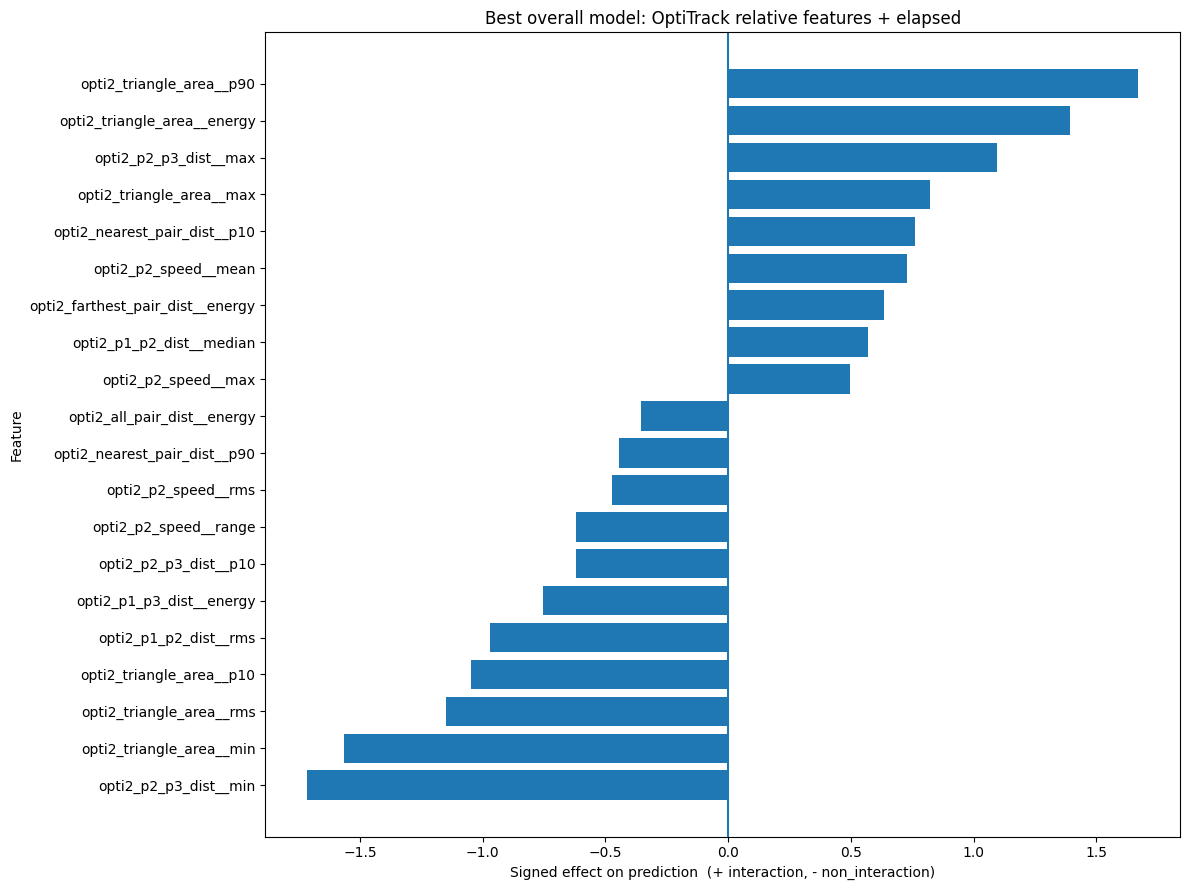

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/01_best_overall_signed_feature_effects.png


,feature,modality,family,selected_in_folds,selection_frequency,mean_abs_coef,signed_effect,direction,stability_weighted_importance
0,opti2_p2_p3_dist__min,OptiTrack,pairwise_distance,9,1.0000,1.7160,-1.7160,pushes_toward_non_interaction,1.7160
2,opti2_triangle_area__min,OptiTrack,formation_geometry,9,1.0000,1.5664,-1.5664,pushes_toward_non_interaction,1.5664
4,opti2_triangle_area__rms,OptiTrack,formation_geometry,9,1.0000,1.1511,-1.1511,pushes_toward_non_interaction,1.1511
6,opti2_triangle_area__p10,OptiTrack,formation_geometry,9,1.0000,1.0457,-1.0457,pushes_toward_non_interaction,1.0457
7,opti2_p1_p2_dist__rms,OptiTrack,pairwise_distance,9,1.0000,0.9692,-0.9692,pushes_toward_non_interaction,0.9692
10,opti2_p1_p3_dist__energy,OptiTrack,pairwise_distance,9,1.0000,0.7549,-0.7549,pushes_toward_non_interaction,0.7549
13,opti2_p2_p3_dist__p10,OptiTrack,pairwise_distance,9,1.0000,0.6215,-0.6215,pushes_toward_non_interaction,0.6215
16,opti2_p2_speed__range,OptiTrack,movement_dynamics,7,0.7778,0.6211,-0.6211,pushes_toward_non_interaction,0.4831
18,opti2_p2_speed__rms,OptiTrack,movement_dynamics,9,1.0000,0.4753,-0.4723,pushes_toward_non_interaction,0.4753
19,opti2_nearest_pair_dist__p90,OptiTrack,pairwise_distance,9,1.0000,0.4441,-0.4441,pushes_toward_non_interaction,0.4441


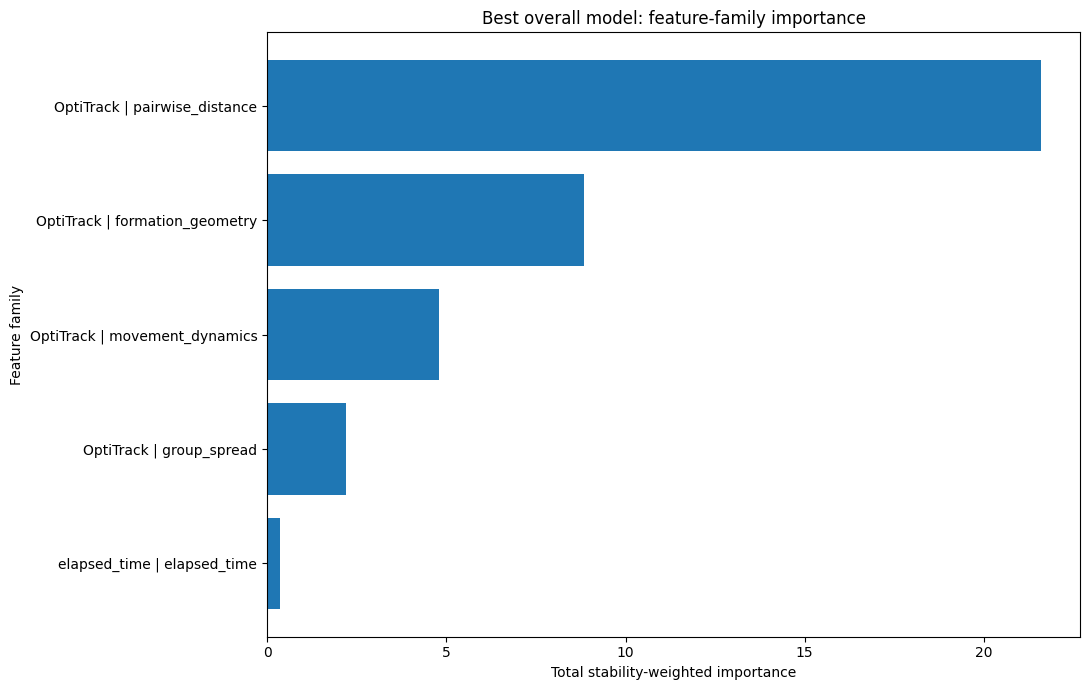

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/02_best_overall_family_importance.png


,modality,family,n_features,total_importance,mean_importance,mean_selection_frequency
3,OptiTrack,pairwise_distance,83,21.5984,0.2602,0.8956
0,OptiTrack,formation_geometry,14,8.8522,0.6323,1.0000
2,OptiTrack,movement_dynamics,33,4.7986,0.1454,0.6229
1,OptiTrack,group_spread,11,2.2048,0.2004,0.9192
4,elapsed_time,elapsed_time,1,0.3621,0.3621,1.0000



Top features: Best OptiTrack-only model without elapsed


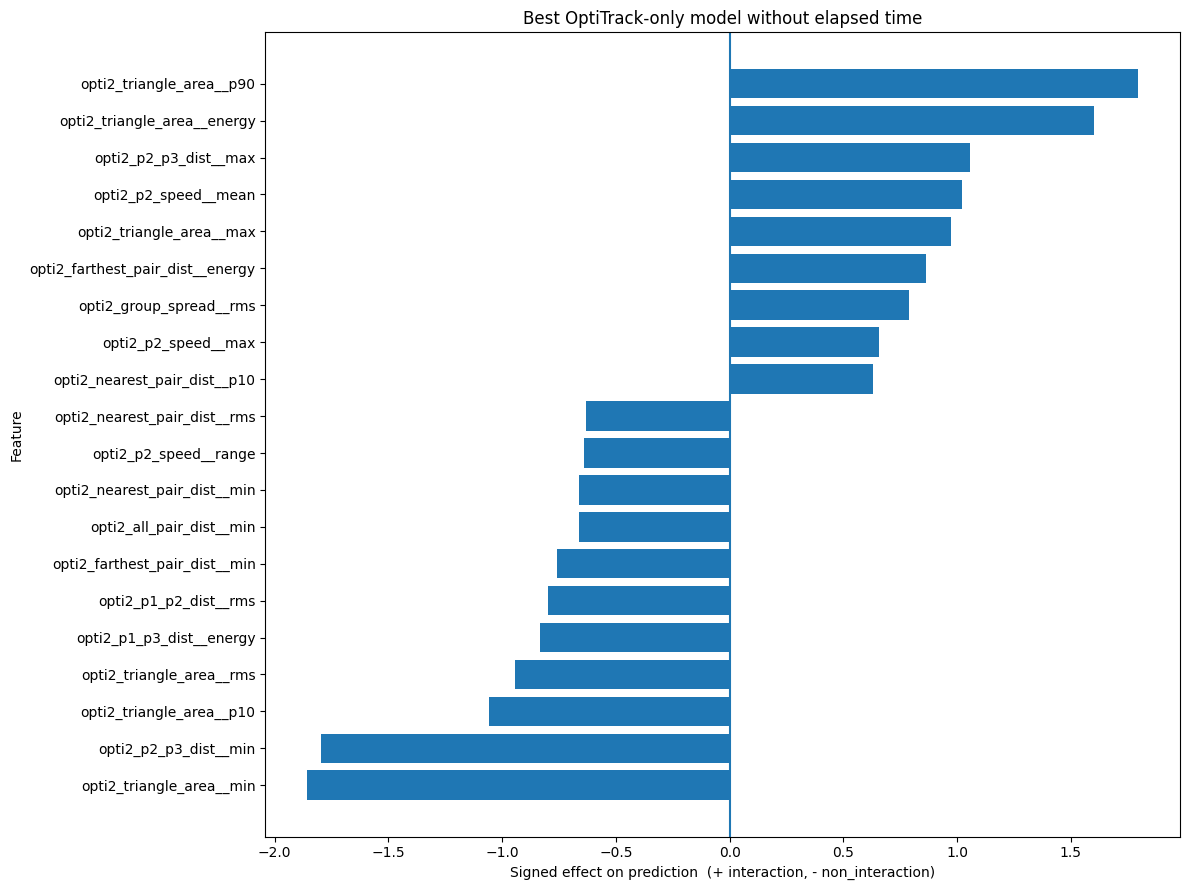

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/03_best_opti_no_elapsed_signed_feature_effects.png


,feature,modality,family,selected_in_folds,selection_frequency,mean_abs_coef,signed_effect,direction,stability_weighted_importance
0,opti2_triangle_area__min,OptiTrack,formation_geometry,9,1.0000,1.8577,-1.8577,pushes_toward_non_interaction,1.8577
1,opti2_p2_p3_dist__min,OptiTrack,pairwise_distance,9,1.0000,1.7968,-1.7968,pushes_toward_non_interaction,1.7968
4,opti2_triangle_area__p10,OptiTrack,formation_geometry,9,1.0000,1.0584,-1.0584,pushes_toward_non_interaction,1.0584
7,opti2_triangle_area__rms,OptiTrack,formation_geometry,9,1.0000,0.9428,-0.9428,pushes_toward_non_interaction,0.9428
10,opti2_p1_p3_dist__energy,OptiTrack,pairwise_distance,9,1.0000,0.8320,-0.8320,pushes_toward_non_interaction,0.8320
11,opti2_p1_p2_dist__rms,OptiTrack,pairwise_distance,9,1.0000,0.7995,-0.7995,pushes_toward_non_interaction,0.7995
13,opti2_farthest_pair_dist__min,OptiTrack,pairwise_distance,9,1.0000,0.7601,-0.7601,pushes_toward_non_interaction,0.7601
14,opti2_all_pair_dist__min,OptiTrack,pairwise_distance,9,1.0000,0.6617,-0.6617,pushes_toward_non_interaction,0.6617
15,opti2_nearest_pair_dist__min,OptiTrack,pairwise_distance,9,1.0000,0.6617,-0.6617,pushes_toward_non_interaction,0.6617
17,opti2_p2_speed__range,OptiTrack,movement_dynamics,9,1.0000,0.6419,-0.6419,pushes_toward_non_interaction,0.6419


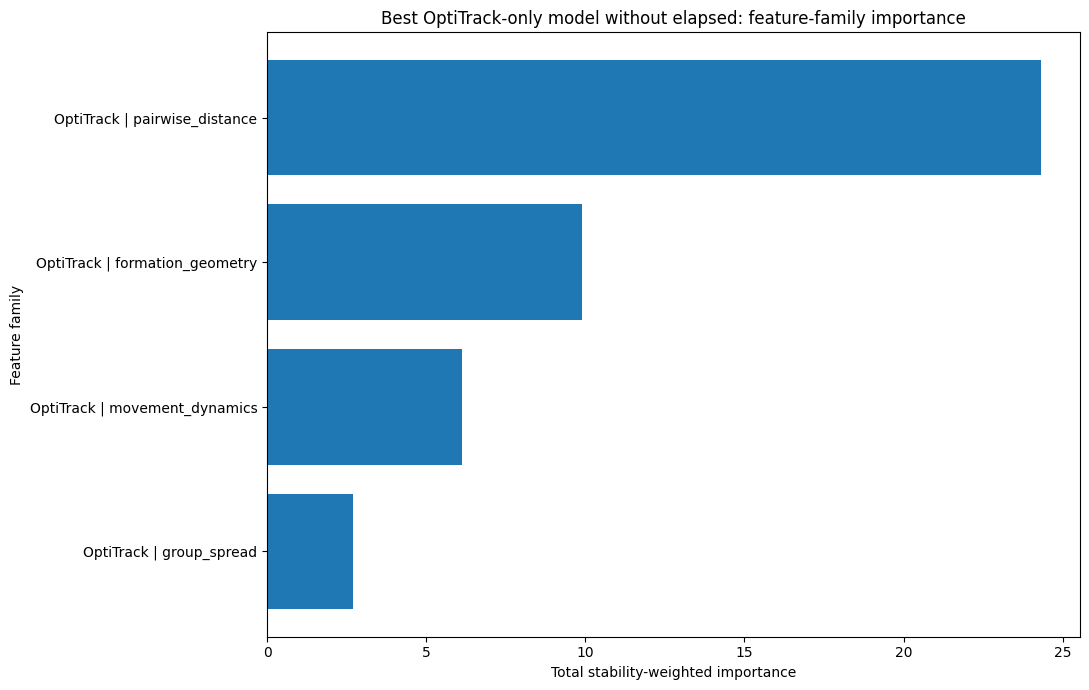

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/04_best_opti_no_elapsed_family_importance.png


,modality,family,n_features,total_importance,mean_importance,mean_selection_frequency
3,OptiTrack,pairwise_distance,83,24.3265,0.2931,0.8969
0,OptiTrack,formation_geometry,14,9.8953,0.7068,1.0000
2,OptiTrack,movement_dynamics,35,6.1346,0.1753,0.6127
1,OptiTrack,group_spread,11,2.7152,0.2468,0.9192


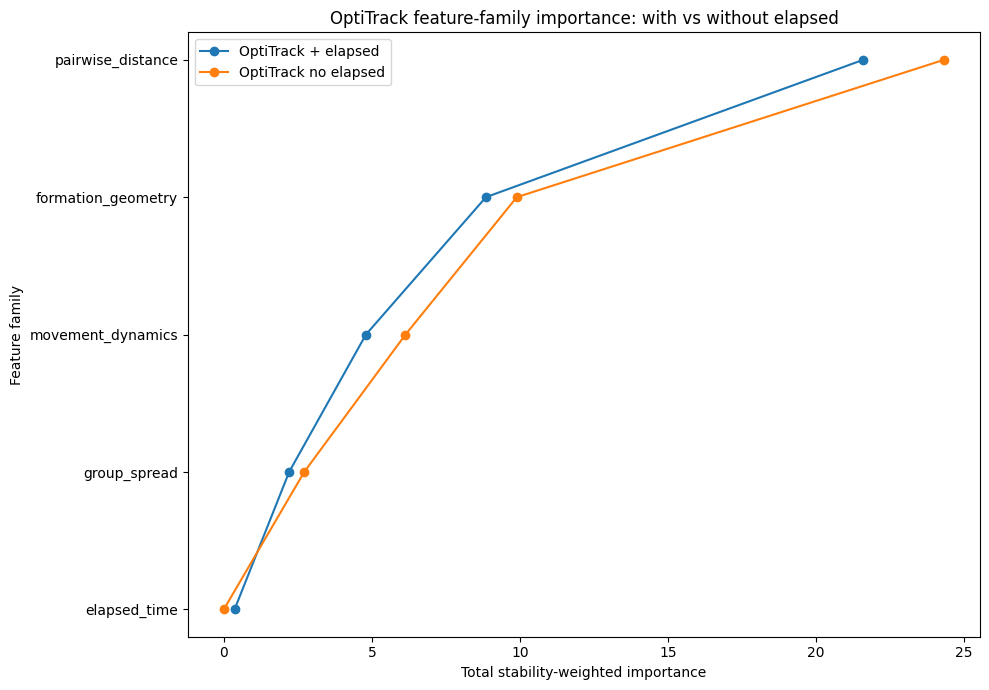

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/05_opti_with_vs_without_elapsed_family_comparison.png


model,OptiTrack + elapsed,OptiTrack no elapsed
family,,
elapsed_time,0.3621,0.0000
group_spread,2.2048,2.7152
movement_dynamics,4.7986,6.1346
formation_geometry,8.8522,9.8953
pairwise_distance,21.5984,24.3265



Top features: Best OE-only model


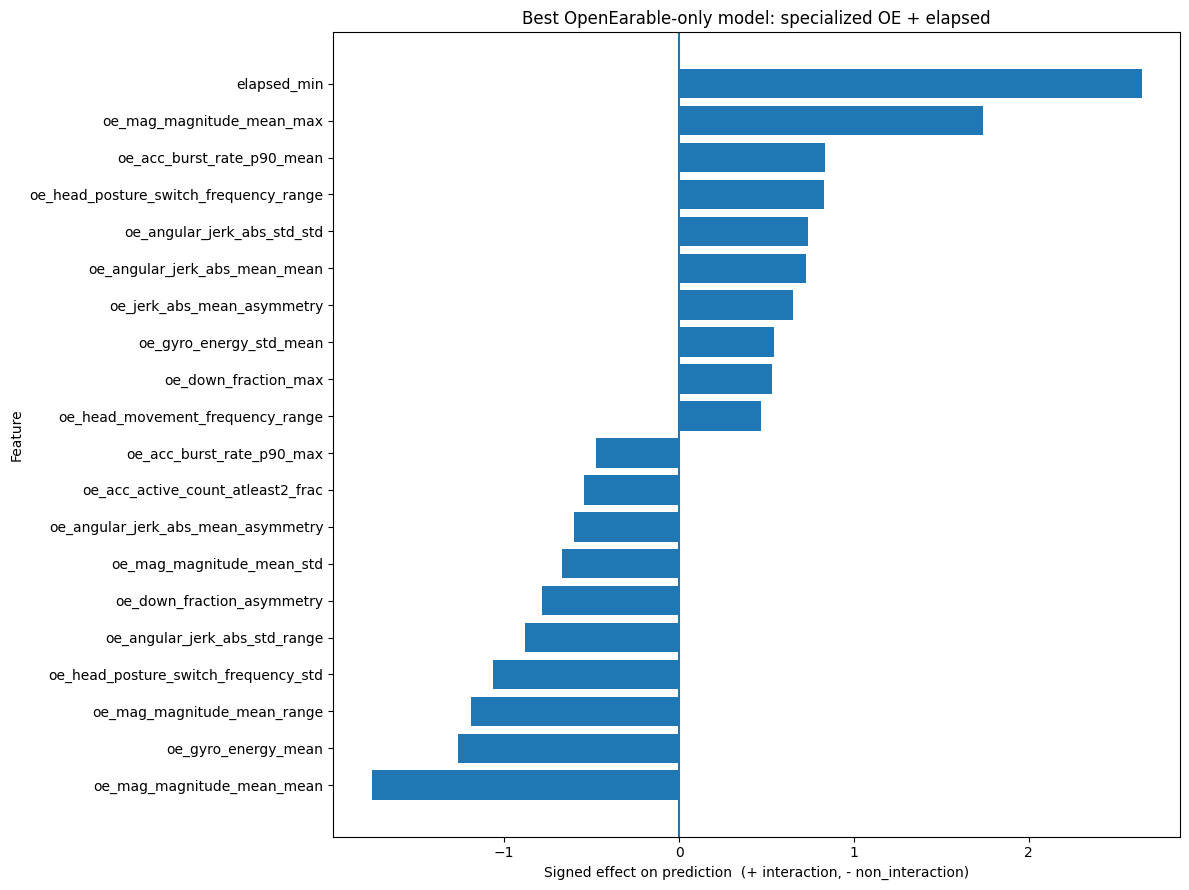

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/06_best_oe_signed_feature_effects.png


,feature,modality,family,selected_in_folds,selection_frequency,mean_abs_coef,signed_effect,direction,stability_weighted_importance
1,oe_mag_magnitude_mean_mean,OpenEarable,magnetometer,9,1.0000,1.7569,-1.7569,pushes_toward_non_interaction,1.7569
6,oe_gyro_energy_mean,OpenEarable,other,7,0.7778,1.2634,-1.2634,pushes_toward_non_interaction,0.9827
3,oe_mag_magnitude_mean_range,OpenEarable,magnetometer,9,1.0000,1.2360,-1.1872,pushes_toward_non_interaction,1.2360
4,oe_head_posture_switch_frequency_std,OpenEarable,head_movement,9,1.0000,1.0628,-1.0628,pushes_toward_non_interaction,1.0628
7,oe_angular_jerk_abs_std_range,OpenEarable,jerk_change,9,1.0000,0.8805,-0.8805,pushes_toward_non_interaction,0.8805
12,oe_down_fraction_asymmetry,OpenEarable,dominance_asymmetry,8,0.8889,0.7838,-0.7838,pushes_toward_non_interaction,0.6968
5,oe_mag_magnitude_mean_std,OpenEarable,magnetometer,7,0.7778,1.3626,-0.6700,pushes_toward_non_interaction,1.0598
14,oe_angular_jerk_abs_mean_asymmetry,OpenEarable,jerk_change,8,0.8889,0.5988,-0.5988,pushes_toward_non_interaction,0.5323
16,oe_acc_active_count_atleast2_frac,OpenEarable,other,8,0.8889,0.5441,-0.5441,pushes_toward_non_interaction,0.4836
17,oe_acc_burst_rate_p90_max,OpenEarable,other,9,1.0000,0.4773,-0.4773,pushes_toward_non_interaction,0.4773


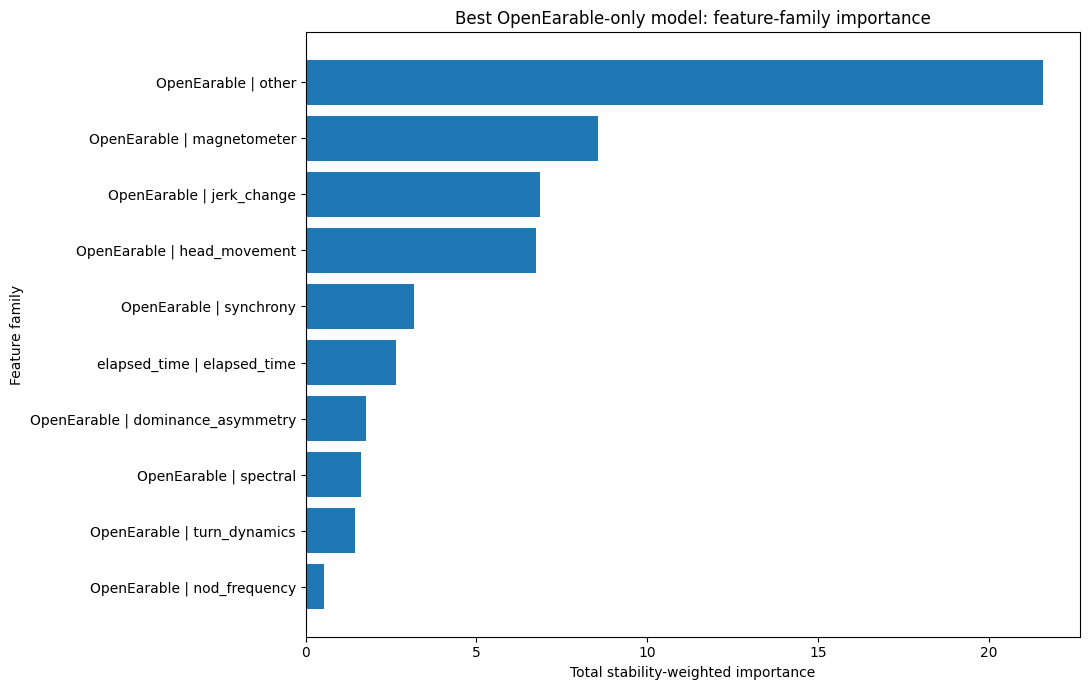

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/07_best_oe_family_importance.png


,modality,family,n_features,total_importance,mean_importance,mean_selection_frequency
5,OpenEarable,other,129,21.5934,0.1674,0.6055
3,OpenEarable,magnetometer,23,8.5685,0.3725,0.7971
2,OpenEarable,jerk_change,27,6.8492,0.2537,0.7901
1,OpenEarable,head_movement,55,6.7585,0.1229,0.5475
7,OpenEarable,synchrony,25,3.1848,0.1274,0.7733
9,elapsed_time,elapsed_time,1,2.6447,2.6447,1.0000
0,OpenEarable,dominance_asymmetry,20,1.7760,0.0888,0.5444
6,OpenEarable,spectral,28,1.6150,0.0577,0.3016
8,OpenEarable,turn_dynamics,13,1.4466,0.1113,0.6752
4,OpenEarable,nod_frequency,8,0.5320,0.0665,0.4583



Top features: Best fusion model


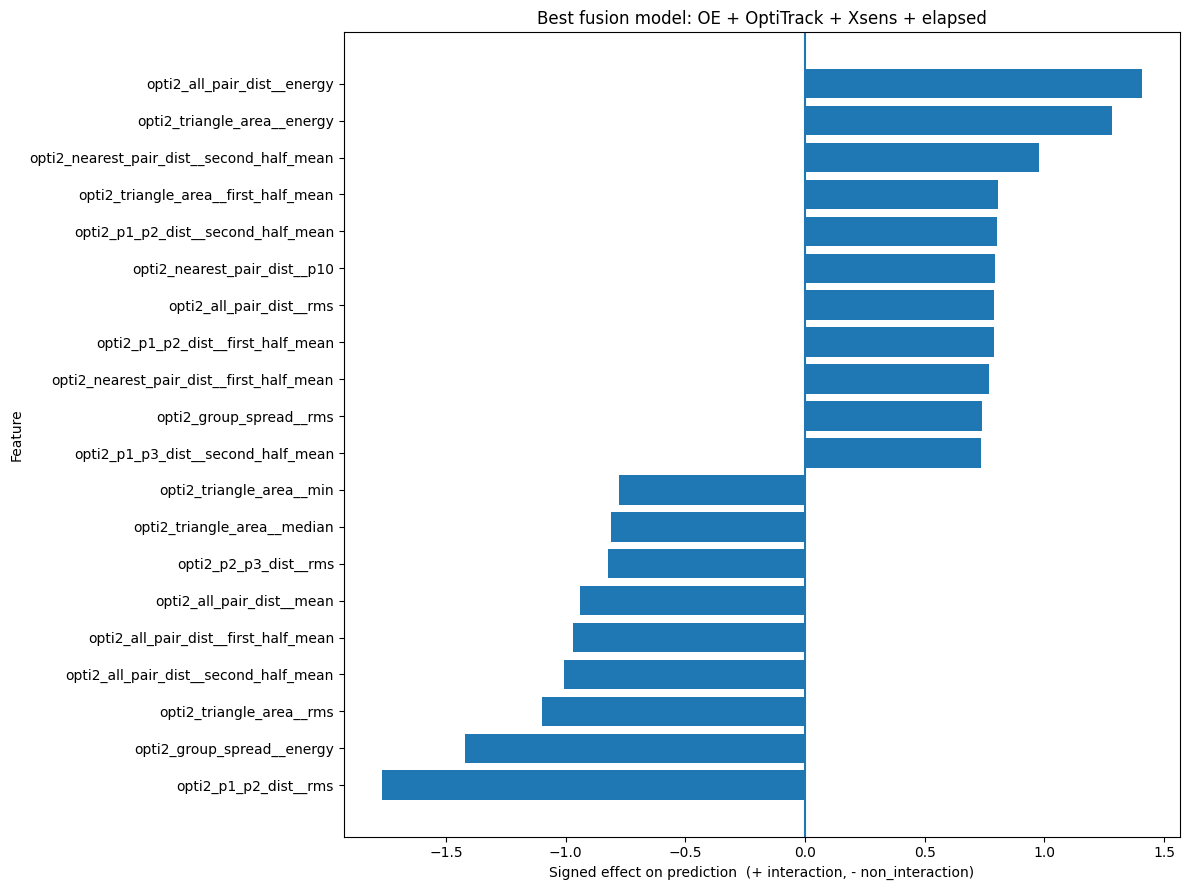

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/08_best_fusion_signed_feature_effects.png


,feature,modality,family,selected_in_folds,selection_frequency,mean_abs_coef,signed_effect,direction,stability_weighted_importance
0,opti2_p1_p2_dist__rms,OptiTrack,pairwise_distance,9,1.0,1.7686,-1.7686,pushes_toward_non_interaction,1.7686
1,opti2_group_spread__energy,OptiTrack,group_spread,9,1.0,1.4215,-1.4215,pushes_toward_non_interaction,1.4215
4,opti2_triangle_area__rms,OptiTrack,formation_geometry,9,1.0,1.1007,-1.1007,pushes_toward_non_interaction,1.1007
5,opti2_all_pair_dist__second_half_mean,OptiTrack,pairwise_distance,9,1.0,1.0060,-1.0060,pushes_toward_non_interaction,1.0060
7,opti2_all_pair_dist__first_half_mean,OptiTrack,pairwise_distance,9,1.0,0.9711,-0.9711,pushes_toward_non_interaction,0.9711
8,opti2_all_pair_dist__mean,OptiTrack,pairwise_distance,9,1.0,0.9403,-0.9403,pushes_toward_non_interaction,0.9403
10,opti2_p2_p3_dist__rms,OptiTrack,pairwise_distance,9,1.0,0.8219,-0.8219,pushes_toward_non_interaction,0.8219
9,opti2_triangle_area__median,OptiTrack,formation_geometry,9,1.0,0.8687,-0.8124,pushes_toward_non_interaction,0.8687
16,opti2_triangle_area__min,OptiTrack,formation_geometry,9,1.0,0.7757,-0.7757,pushes_toward_non_interaction,0.7757
19,opti2_p1_p3_dist__second_half_mean,OptiTrack,pairwise_distance,9,1.0,0.7368,0.7368,pushes_toward_interaction,0.7368


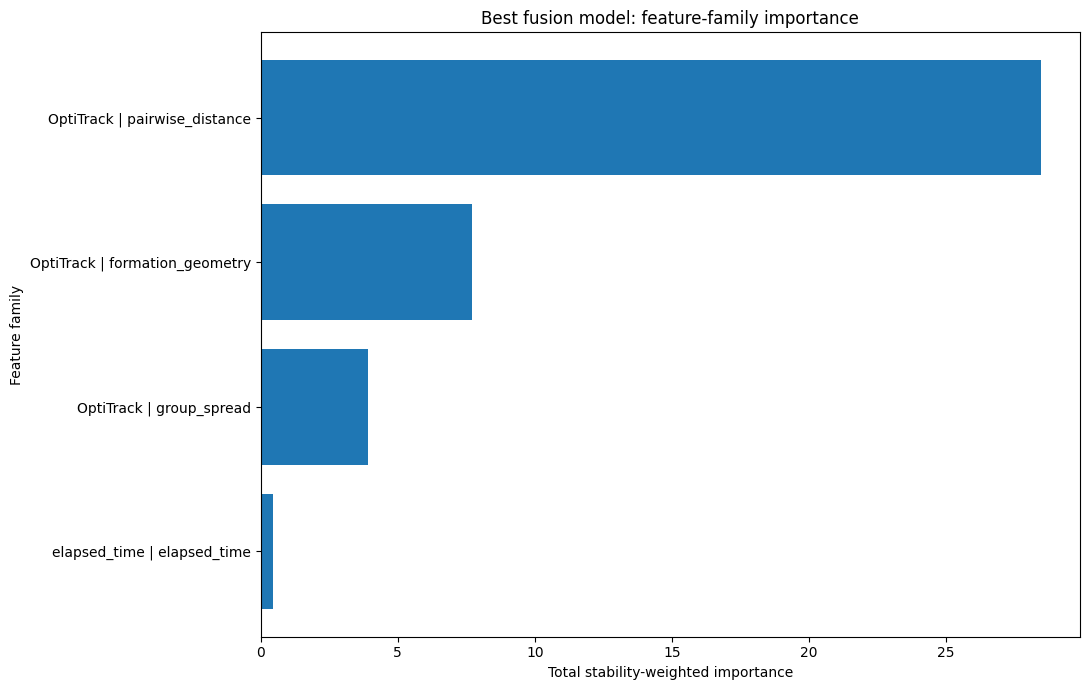

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/09_best_fusion_family_importance.png


,modality,family,n_features,total_importance,mean_importance,mean_selection_frequency
2,OptiTrack,pairwise_distance,59,28.4604,0.4824,1.0
0,OptiTrack,formation_geometry,10,7.7112,0.7711,1.0
1,OptiTrack,group_spread,10,3.9056,0.3906,1.0
3,elapsed_time,elapsed_time,1,0.4687,0.4687,1.0



Fusion model modality importance:


,modality,n_features,total_importance,mean_importance,mean_selection_frequency
0,OptiTrack,79,40.0772,0.5073,1.0
1,elapsed_time,1,0.4687,0.4687,1.0


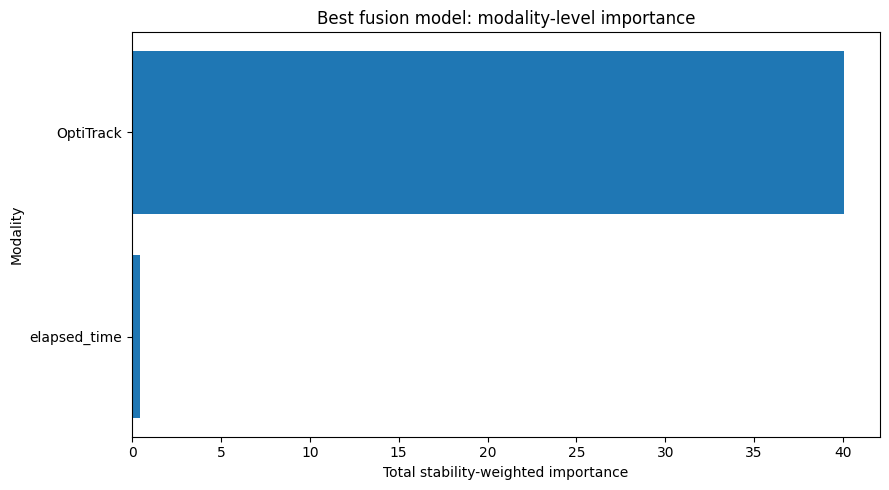

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots/10_best_fusion_modality_importance.png

All plots saved to:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots


In [ ]:
# ================================================================
# VISUALIZE FEATURE EFFECTS FROM EXPLAINABILITY OUTPUTS
#
# Shows:
#   1. Best overall model: OPTI2_RELATIVE_ONLY + elapsed
#   2. Best OptiTrack model without elapsed
#   3. Best OE-only model with elapsed
#   4. Optional fusion model
#   5. Feature-family importance comparison
#
# Interpretation:
#   positive signed effect  -> pushes prediction toward interaction
#   negative signed effect  -> pushes prediction toward non_interaction
# ================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------
# PATHS
# ------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE"
EXPLAIN_DIR = f"{BASE_DIR}/EXPLAINABILITY"
PLOT_DIR = f"{EXPLAIN_DIR}/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

FILES = {
    "Best overall: OptiTrack relative + elapsed":
        f"{EXPLAIN_DIR}/BEST_OVERALL__OPTI2_RELATIVE_WITH_ELAPSED_feature_importance.csv",

    "Best OptiTrack only: no elapsed":
        f"{EXPLAIN_DIR}/BEST_OPTI_SENSOR_ONLY__NO_ELAPSED_feature_importance.csv",

    "Best OE only: specialized OE + elapsed":
        f"{EXPLAIN_DIR}/BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED_feature_importance.csv",

    "Best fusion: OE + OptiTrack + Xsens + elapsed":
        f"{EXPLAIN_DIR}/BEST_FUSION__SPECIAL_OE_OPTI_XSENS_WITH_ELAPSED_feature_importance.csv",
}

METRICS_PATH = f"{EXPLAIN_DIR}/explainability_model_metrics.csv"

TOP_N = 20


# ------------------------------------------------
# LOAD
# ------------------------------------------------

importance = {}

for name, path in FILES.items():
    if not os.path.exists(path):
        print("Missing:", path)
        continue

    df_imp = pd.read_csv(path)

    needed = [
        "feature",
        "modality",
        "family",
        "selected_in_folds",
        "selection_frequency",
        "mean_abs_coef",
        "mean_coef_for_interaction",
        "stability_weighted_importance",
        "direction",
    ]

    missing = [c for c in needed if c not in df_imp.columns]

    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

    importance[name] = df_imp.copy()

print("Loaded explainability files:")
for k, v in importance.items():
    print(f"{k:55s} | {v.shape}")


# ------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------

def short_feature_name(name, max_len=55):
    name = str(name)
    if len(name) <= max_len:
        return name
    return name[:max_len - 3] + "..."


def top_by_signed_effect(df, top_n=20):
    """
    Select most important features by stability-weighted importance,
    then plot signed coefficient.
    """
    out = (
        df
        .sort_values("stability_weighted_importance", ascending=False)
        .head(top_n)
        .copy()
    )

    out["signed_effect"] = out["mean_coef_for_interaction"]
    out["short_feature"] = out["feature"].apply(short_feature_name)

    return out


def plot_signed_feature_effects(df, title, save_name, top_n=20):
    """
    Positive = pushes toward interaction
    Negative = pushes toward non_interaction
    """
    top = top_by_signed_effect(df, top_n=top_n)
    top = top.sort_values("signed_effect")

    plt.figure(figsize=(12, 9))
    plt.barh(top["short_feature"], top["signed_effect"])
    plt.axvline(0)
    plt.xlabel("Signed effect on prediction  (+ interaction, - non_interaction)")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()

    out_path = f"{PLOT_DIR}/{save_name}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

    return top


def plot_family_importance(df, title, save_name):
    fam = (
        df
        .groupby(["modality", "family"], as_index=False)
        .agg(
            n_features=("feature", "count"),
            total_importance=("stability_weighted_importance", "sum"),
            mean_importance=("stability_weighted_importance", "mean"),
            mean_selection_frequency=("selection_frequency", "mean"),
        )
        .sort_values("total_importance", ascending=False)
    )

    fam_plot = fam.sort_values("total_importance")

    labels = fam_plot["modality"] + " | " + fam_plot["family"]

    plt.figure(figsize=(11, 7))
    plt.barh(labels, fam_plot["total_importance"])
    plt.xlabel("Total stability-weighted importance")
    plt.ylabel("Feature family")
    plt.title(title)
    plt.tight_layout()

    out_path = f"{PLOT_DIR}/{save_name}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

    return fam


# ------------------------------------------------
# MODEL METRICS TABLE
# ------------------------------------------------

if os.path.exists(METRICS_PATH):
    metrics = pd.read_csv(METRICS_PATH)

    print("\nExplained model metrics:")
    display(metrics.round(3))


# ------------------------------------------------
# 1) BEST OVERALL MODEL
# ------------------------------------------------

best_overall = importance["Best overall: OptiTrack relative + elapsed"]

print("\nTop features: Best overall model")
top_overall = plot_signed_feature_effects(
    best_overall,
    title="Best overall model: OptiTrack relative features + elapsed",
    save_name="01_best_overall_signed_feature_effects",
    top_n=TOP_N,
)

display(
    top_overall[
        [
            "feature",
            "modality",
            "family",
            "selected_in_folds",
            "selection_frequency",
            "mean_abs_coef",
            "signed_effect",
            "direction",
            "stability_weighted_importance",
        ]
    ].round(4)
)

family_overall = plot_family_importance(
    best_overall,
    title="Best overall model: feature-family importance",
    save_name="02_best_overall_family_importance",
)

display(family_overall.round(4))


# ------------------------------------------------
# 2) BEST OPTITRACK MODEL WITHOUT ELAPSED
# ------------------------------------------------

best_no_elapsed = importance["Best OptiTrack only: no elapsed"]

print("\nTop features: Best OptiTrack-only model without elapsed")
top_no_elapsed = plot_signed_feature_effects(
    best_no_elapsed,
    title="Best OptiTrack-only model without elapsed time",
    save_name="03_best_opti_no_elapsed_signed_feature_effects",
    top_n=TOP_N,
)

display(
    top_no_elapsed[
        [
            "feature",
            "modality",
            "family",
            "selected_in_folds",
            "selection_frequency",
            "mean_abs_coef",
            "signed_effect",
            "direction",
            "stability_weighted_importance",
        ]
    ].round(4)
)

family_no_elapsed = plot_family_importance(
    best_no_elapsed,
    title="Best OptiTrack-only model without elapsed: feature-family importance",
    save_name="04_best_opti_no_elapsed_family_importance",
)

display(family_no_elapsed.round(4))


# ------------------------------------------------
# 3) COMPARE WITH ELAPSED VS WITHOUT ELAPSED FOR OPTITRACK
# ------------------------------------------------

compare_rows = []

for model_name, df_imp in [
    ("OptiTrack + elapsed", best_overall),
    ("OptiTrack no elapsed", best_no_elapsed),
]:
    fam = (
        df_imp
        .groupby("family", as_index=False)
        .agg(total_importance=("stability_weighted_importance", "sum"))
    )

    fam["model"] = model_name
    compare_rows.append(fam)

compare_fam = pd.concat(compare_rows, ignore_index=True)

pivot = (
    compare_fam
    .pivot(index="family", columns="model", values="total_importance")
    .fillna(0)
)

pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

plt.figure(figsize=(10, 7))

for col in pivot.columns:
    plt.plot(pivot[col].values, pivot.index, marker="o", label=col)

plt.xlabel("Total stability-weighted importance")
plt.ylabel("Feature family")
plt.title("OptiTrack feature-family importance: with vs without elapsed")
plt.legend()
plt.tight_layout()

out_path = f"{PLOT_DIR}/05_opti_with_vs_without_elapsed_family_comparison.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

display(pivot.round(4))


# ------------------------------------------------
# 4) BEST OE-ONLY MODEL
# ------------------------------------------------

best_oe = importance["Best OE only: specialized OE + elapsed"]

print("\nTop features: Best OE-only model")
top_oe = plot_signed_feature_effects(
    best_oe,
    title="Best OpenEarable-only model: specialized OE + elapsed",
    save_name="06_best_oe_signed_feature_effects",
    top_n=TOP_N,
)

display(
    top_oe[
        [
            "feature",
            "modality",
            "family",
            "selected_in_folds",
            "selection_frequency",
            "mean_abs_coef",
            "signed_effect",
            "direction",
            "stability_weighted_importance",
        ]
    ].round(4)
)

family_oe = plot_family_importance(
    best_oe,
    title="Best OpenEarable-only model: feature-family importance",
    save_name="07_best_oe_family_importance",
)

display(family_oe.round(4))


# ------------------------------------------------
# 5) OPTIONAL: BEST FUSION MODEL
# ------------------------------------------------

best_fusion = importance["Best fusion: OE + OptiTrack + Xsens + elapsed"]

print("\nTop features: Best fusion model")
top_fusion = plot_signed_feature_effects(
    best_fusion,
    title="Best fusion model: OE + OptiTrack + Xsens + elapsed",
    save_name="08_best_fusion_signed_feature_effects",
    top_n=TOP_N,
)

display(
    top_fusion[
        [
            "feature",
            "modality",
            "family",
            "selected_in_folds",
            "selection_frequency",
            "mean_abs_coef",
            "signed_effect",
            "direction",
            "stability_weighted_importance",
        ]
    ].round(4)
)

family_fusion = plot_family_importance(
    best_fusion,
    title="Best fusion model: feature-family importance",
    save_name="09_best_fusion_family_importance",
)

display(family_fusion.round(4))


# ------------------------------------------------
# 6) SUMMARY: MODALITY IMPORTANCE IN FUSION
# ------------------------------------------------

fusion_modality = (
    best_fusion
    .groupby("modality", as_index=False)
    .agg(
        n_features=("feature", "count"),
        total_importance=("stability_weighted_importance", "sum"),
        mean_importance=("stability_weighted_importance", "mean"),
        mean_selection_frequency=("selection_frequency", "mean"),
    )
    .sort_values("total_importance", ascending=False)
)

print("\nFusion model modality importance:")
display(fusion_modality.round(4))

fusion_modality_plot = fusion_modality.sort_values("total_importance")

plt.figure(figsize=(9, 5))
plt.barh(fusion_modality_plot["modality"], fusion_modality_plot["total_importance"])
plt.xlabel("Total stability-weighted importance")
plt.ylabel("Modality")
plt.title("Best fusion model: modality-level importance")
plt.tight_layout()

out_path = f"{PLOT_DIR}/10_best_fusion_modality_importance.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------
# DONE
# ------------------------------------------------

print("\nAll plots saved to:")
print(PLOT_DIR)

LOADED BEST OE-ONLY EXPLAINABILITY
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED_feature_importance.csv
Shape: (329, 12)


,explain_name,feature,modality,family,selected_in_folds,mean_abs_coef,std_abs_coef,mean_coef_for_interaction,mean_f_score,selection_frequency,stability_weighted_importance,direction
0,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,elapsed_min,elapsed_time,elapsed_time,9,2.644709,0.254624,2.644709,1120.880710,1.0,2.644709,pushes_toward_interaction
1,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,oe_mag_magnitude_mean_mean,OpenEarable,magnetometer,9,1.756918,0.275755,-1.756918,103.213231,1.0,1.756918,pushes_toward_non_interaction
2,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,oe_mag_magnitude_mean_max,OpenEarable,magnetometer,9,1.736188,0.701298,1.736188,49.426499,1.0,1.736188,pushes_toward_interaction
3,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,oe_mag_magnitude_mean_range,OpenEarable,magnetometer,9,1.236006,1.029936,-1.187214,28.588618,1.0,1.236006,pushes_toward_non_interaction
4,BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED,oe_head_posture_switch_frequency_std,OpenEarable,head_movement,9,1.062761,0.148242,-1.062761,32.293817,1.0,1.062761,pushes_toward_non_interaction



EXACT FEATURES PREVIOUSLY CATEGORIZED AS OpenEarable | other
Count: 129


,feature,detailed_family,selected_in_folds,selection_frequency,mean_abs_coef,signed_effect,pushes_toward,stability_weighted_importance
0,oe_gyro_energy_mean,gyro_energy,7,0.7778,1.2634,-1.2634,non_interaction,0.9827
1,oe_acc_burst_rate_p90_mean,acceleration_bursts,9,1.0000,0.8343,0.8343,interaction,0.8343
2,oe_gyro_energy_std_mean,gyro_energy,8,0.8889,0.5629,0.5439,interaction,0.5003
3,oe_acc_active_count_atleast2_frac,active_person_count,8,0.8889,0.5441,-0.5441,non_interaction,0.4836
4,oe_acc_burst_rate_p90_max,acceleration_bursts,9,1.0000,0.4773,-0.4773,non_interaction,0.4773
5,oe_down_fraction_max,posture_pitch_roll,8,0.8889,0.5305,0.5305,interaction,0.4716
6,oe_acc_energy_range_mean,acceleration_energy,9,1.0000,0.4698,0.4698,interaction,0.4698
7,oe_acc_energy_range,acceleration_energy,5,0.5556,0.7972,0.7972,interaction,0.4429
8,oe_acc_energy_std_max,acceleration_energy,9,1.0000,0.4077,0.4077,interaction,0.4077
9,oe_down_count_std,active_person_count,9,1.0000,0.4064,0.4064,interaction,0.4064


Saved exact old-other feature list:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/OE_ONLY_exact_features_previously_called_other.csv

BREAKDOWN OF PREVIOUSLY 'OTHER' FEATURES


...

Saved old-other breakdown:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/OE_ONLY_breakdown_of_previous_other_family.csv

NEW DETAILED OE-ONLY FEATURE-FAMILY SUMMARY


,modality,detailed_family,n_features,total_importance,mean_importance,mean_selection_frequency
13,OpenEarable,magnetometer_magnitude,33,8.9403,0.2709,0.6465
15,OpenEarable,posture_pitch_roll,49,8.5741,0.1750,0.6236
1,OpenEarable,acceleration_energy,20,4.5715,0.2286,0.7278
3,OpenEarable,angular_jerk_change,13,3.8794,0.2984,0.7863
11,OpenEarable,linear_jerk_change,14,2.9698,0.2121,0.7937
20,elapsed_time,elapsed_time,1,2.6447,2.6447,1.0000
9,OpenEarable,head_posture_switching,6,2.4915,0.4153,1.0000
0,OpenEarable,acceleration_bursts,10,2.4744,0.2474,0.7556
10,OpenEarable,head_turn_dynamics,20,2.4416,0.1221,0.6944
18,OpenEarable,temporal_change,29,2.3434,0.0808,0.4444


Saved new family summary:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/OE_ONLY_detailed_feature_family_summary.csv

TOP 40 EXACT OE FEATURES WITH DETAILED FAMILY NAMES


,feature,old_family,detailed_family,selected_in_folds,selection_frequency,mean_abs_coef,signed_effect,pushes_toward,stability_weighted_importance
0,elapsed_min,elapsed_time,elapsed_time,9,1.0000,2.6447,2.6447,interaction,2.6447
1,oe_mag_magnitude_mean_mean,magnetometer,magnetometer_magnitude,9,1.0000,1.7569,-1.7569,non_interaction,1.7569
2,oe_mag_magnitude_mean_max,magnetometer,magnetometer_magnitude,9,1.0000,1.7362,1.7362,interaction,1.7362
3,oe_mag_magnitude_mean_range,magnetometer,magnetometer_magnitude,9,1.0000,1.2360,-1.1872,non_interaction,1.2360
4,oe_head_posture_switch_frequency_std,head_movement,head_posture_switching,9,1.0000,1.0628,-1.0628,non_interaction,1.0628
5,oe_mag_magnitude_mean_std,magnetometer,magnetometer_magnitude,7,0.7778,1.3626,-0.6700,non_interaction,1.0598
6,oe_gyro_energy_mean,other,gyro_energy,7,0.7778,1.2634,-1.2634,non_interaction,0.9827
7,oe_angular_jerk_abs_std_range,jerk_change,angular_jerk_change,9,1.0000,0.8805,-0.8805,non_interaction,0.8805
8,oe_acc_burst_rate_p90_mean,other,acceleration_bursts,9,1.0000,0.8343,0.8343,interaction,0.8343
9,oe_head_posture_switch_frequency_range,head_movement,head_posture_switching,9,1.0000,0.8312,0.8312,interaction,0.8312


Saved top exact features:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/OE_ONLY_top40_exact_features_with_detailed_family.csv


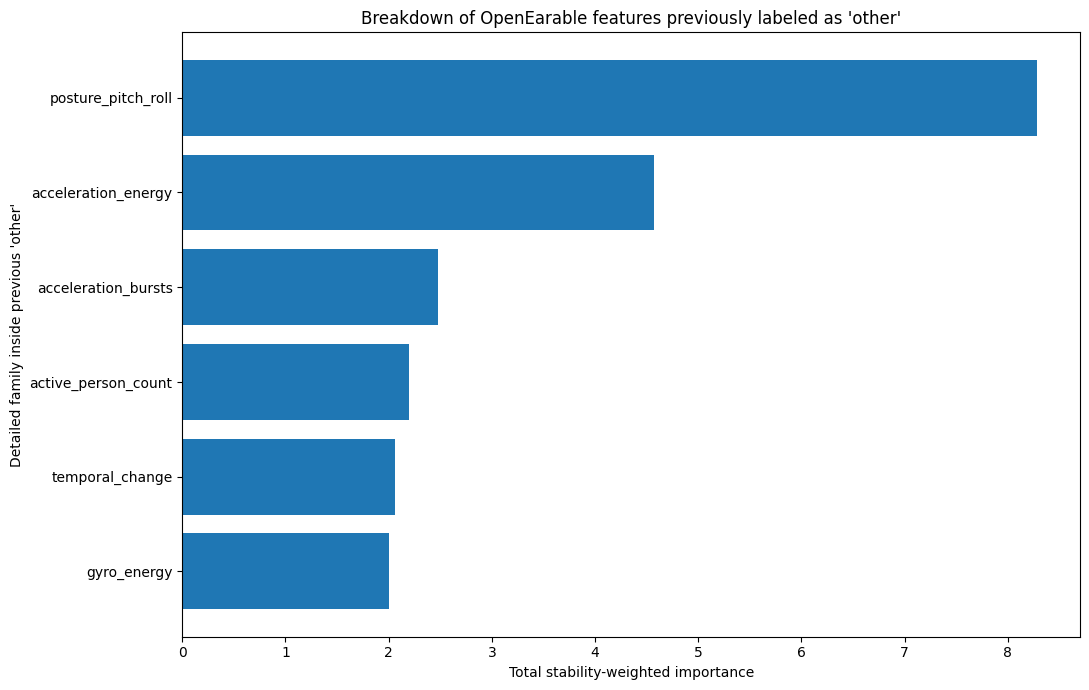

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots_oe_other_breakdown/01_breakdown_of_previous_other_family.png


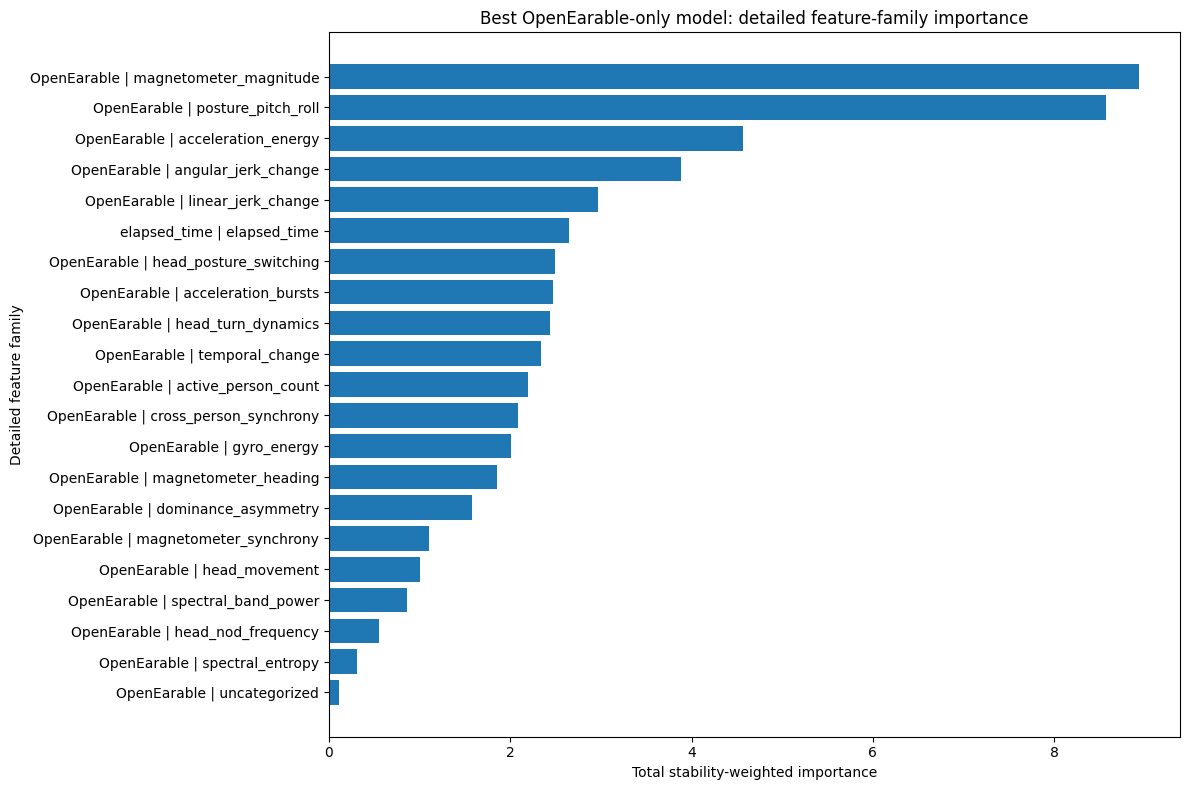

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots_oe_other_breakdown/02_detailed_oe_family_importance.png


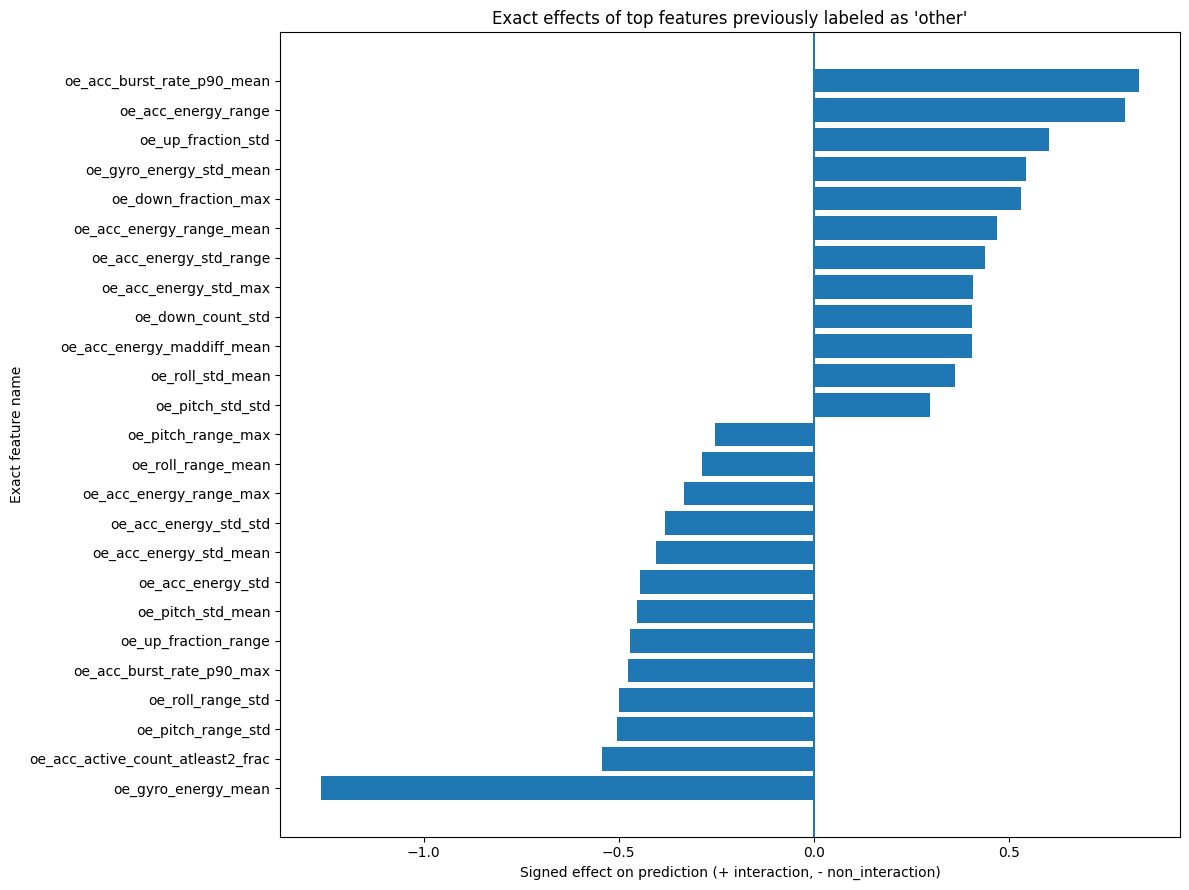

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots_oe_other_breakdown/03_signed_effects_top_previous_other_features.png


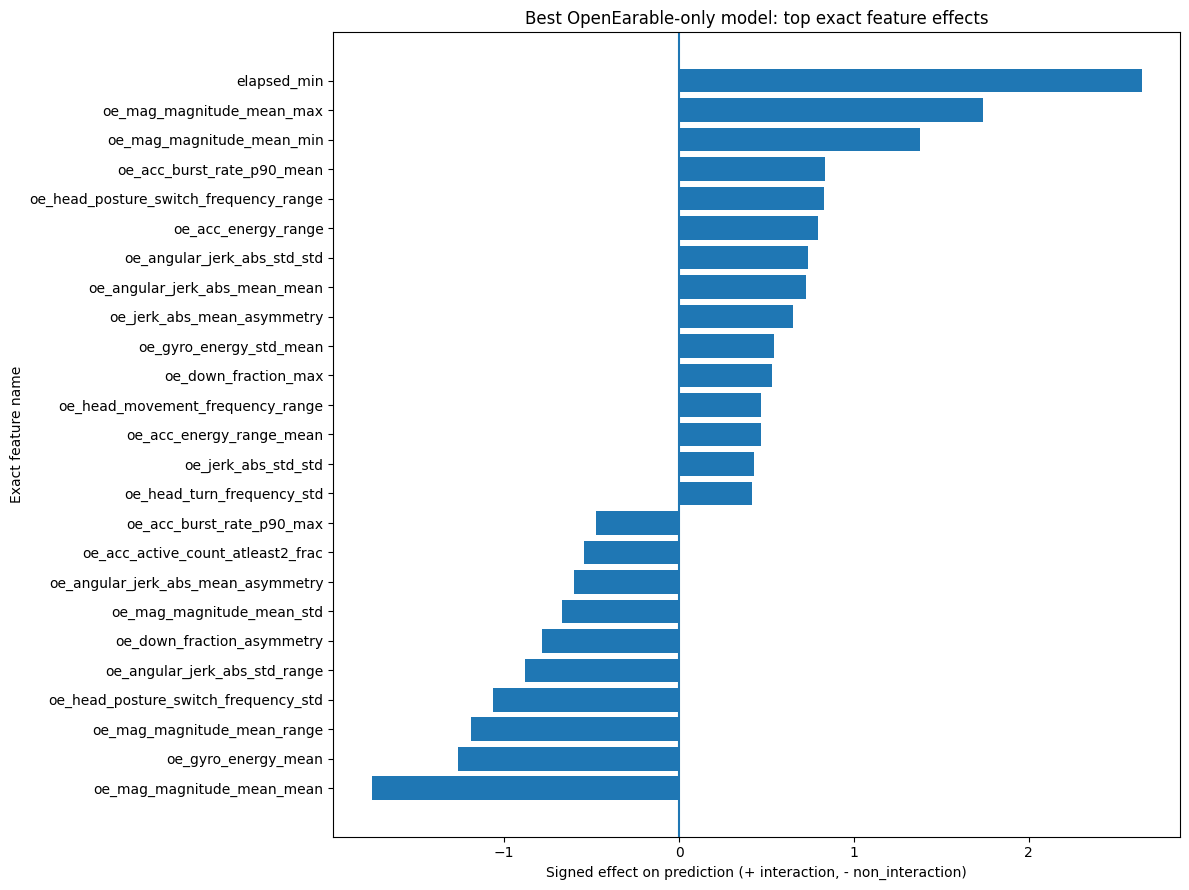

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots_oe_other_breakdown/04_signed_effects_top_oe_features_overall.png


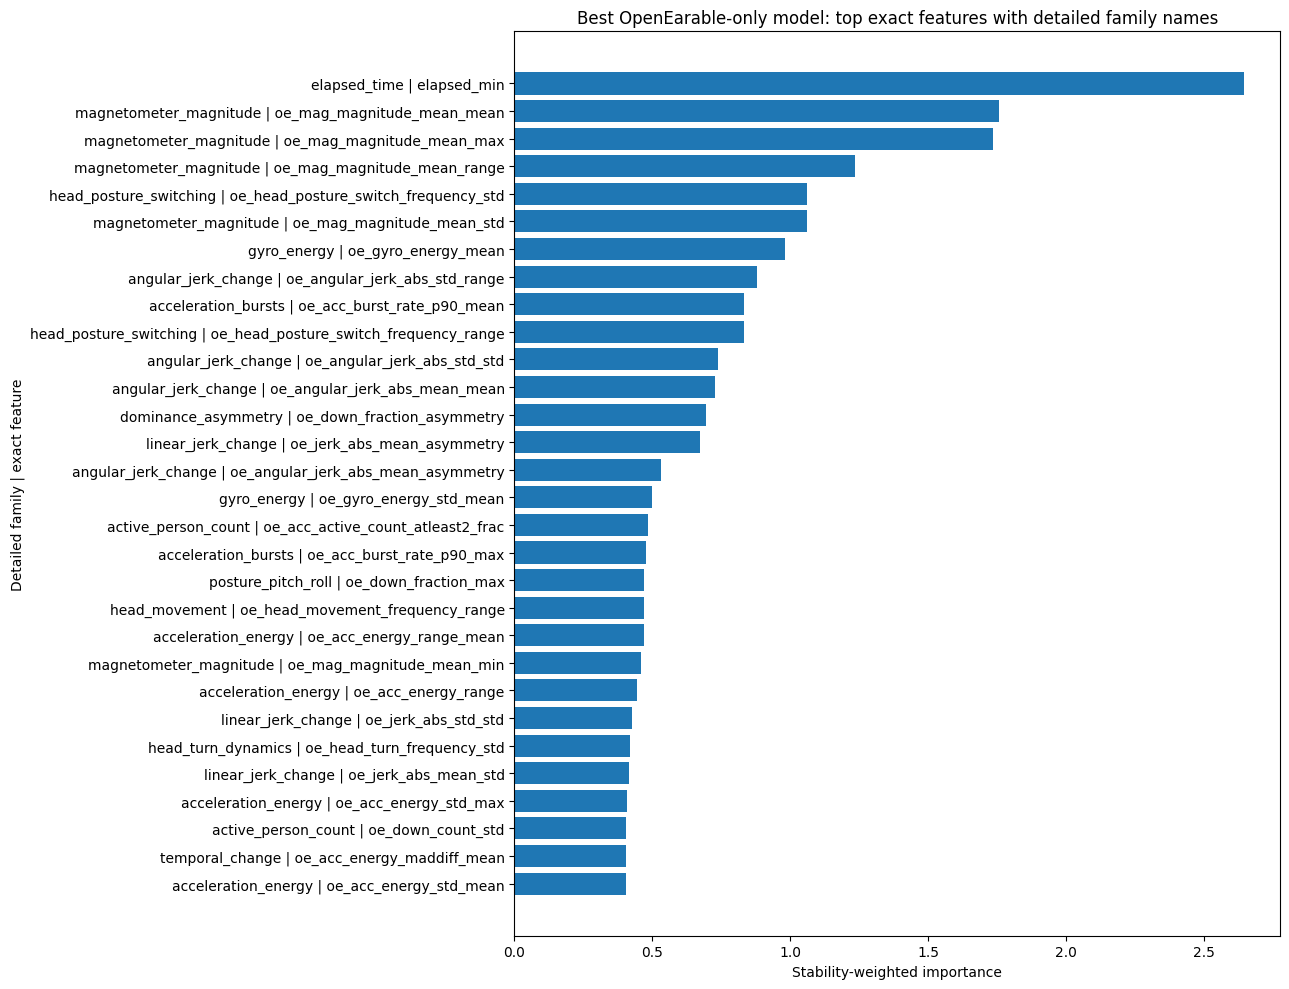

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots_oe_other_breakdown/05_top_oe_features_with_family_and_exact_name.png

SUMMARY
The old 'OpenEarable | other' category was split into these detailed groups:


,detailed_family,n_features,total_importance
4,posture_pitch_roll,47,8.2855
1,acceleration_energy,20,4.5715
0,acceleration_bursts,10,2.4744
2,active_person_count,18,2.1970
5,temporal_change,23,2.0620
3,gyro_energy,11,2.0030



Most important exact features previously called 'other':


,feature,detailed_family,signed_effect,pushes_toward,stability_weighted_importance
0,oe_gyro_energy_mean,gyro_energy,-1.2634,non_interaction,0.9827
1,oe_acc_burst_rate_p90_mean,acceleration_bursts,0.8343,interaction,0.8343
2,oe_gyro_energy_std_mean,gyro_energy,0.5439,interaction,0.5003
3,oe_acc_active_count_atleast2_frac,active_person_count,-0.5441,non_interaction,0.4836
4,oe_acc_burst_rate_p90_max,acceleration_bursts,-0.4773,non_interaction,0.4773
5,oe_down_fraction_max,posture_pitch_roll,0.5305,interaction,0.4716
6,oe_acc_energy_range_mean,acceleration_energy,0.4698,interaction,0.4698
7,oe_acc_energy_range,acceleration_energy,0.7972,interaction,0.4429
8,oe_acc_energy_std_max,acceleration_energy,0.4077,interaction,0.4077
9,oe_down_count_std,active_person_count,0.4064,interaction,0.4064



All outputs saved to:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/EXPLAINABILITY/plots_oe_other_breakdown


In [ ]:
# ================================================================
# BREAK DOWN "OpenEarable | other" INTO EXACT FEATURE NAMES + BETTER GROUPS
#
# This cell:
#   1. Loads the best OE-only explainability CSV
#   2. Shows exactly which features were previously called "other"
#   3. Re-labels them into clearer categories:
#        acceleration_energy
#        gyro_energy
#        movement_bursts
#        posture_pitch_roll
#        active_person_count
#        etc.
#   4. Replots the OE-only feature-family importance
#   5. Plots signed effects of the top "previously other" features
#
# Positive signed effect  -> pushes prediction toward interaction
# Negative signed effect  -> pushes prediction toward non_interaction
# ================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------
# PATHS
# ------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE"
EXPLAIN_DIR = f"{BASE_DIR}/EXPLAINABILITY"
PLOT_DIR = f"{EXPLAIN_DIR}/plots_oe_other_breakdown"
os.makedirs(PLOT_DIR, exist_ok=True)

OE_IMPORTANCE_PATH = f"{EXPLAIN_DIR}/BEST_OE_ONLY__SPECIAL_OE_WITH_ELAPSED_feature_importance.csv"

if not os.path.exists(OE_IMPORTANCE_PATH):
    raise FileNotFoundError(
        f"Could not find:\n{OE_IMPORTANCE_PATH}\n\n"
        "Run the explainability cell first."
    )

df = pd.read_csv(OE_IMPORTANCE_PATH)

print("=" * 100)
print("LOADED BEST OE-ONLY EXPLAINABILITY")
print("=" * 100)
print("Path:", OE_IMPORTANCE_PATH)
print("Shape:", df.shape)

display(df.head())


# ------------------------------------------------
# CHECK REQUIRED COLUMNS
# ------------------------------------------------

required_cols = [
    "feature",
    "modality",
    "family",
    "selected_in_folds",
    "selection_frequency",
    "mean_abs_coef",
    "mean_coef_for_interaction",
    "stability_weighted_importance",
    "direction",
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")


# ------------------------------------------------
# BETTER FEATURE FAMILY CATEGORIZER
# ------------------------------------------------

def detailed_oe_family(feature):
    """
    More detailed categorizer for OpenEarable features.
    This replaces the broad fallback category "other".
    """
    c = str(feature).lower()

    # Time
    if c == "elapsed_min":
        return "elapsed_time"

    # Magnetometer
    if c.startswith("mag_") or "mag_" in c or "magnetometer" in c:
        if "heading" in c:
            return "magnetometer_heading"
        if "pair" in c or "corr" in c:
            return "magnetometer_synchrony"
        if "magnitude" in c:
            return "magnetometer_magnitude"
        return "magnetometer"

    # Head / posture / orientation
    if "head_posture" in c or "head_movement" in c or "head_turn" in c or "head_nod" in c:
        if "nod" in c:
            return "head_nod_frequency"
        if "turn" in c:
            return "head_turn_dynamics"
        if "posture" in c:
            return "head_posture_switching"
        return "head_movement"

    # Explicit nod/turn before spectral because nod may also contain "band"
    if "nod" in c:
        return "head_nod_frequency"

    if "turn" in c or "turn_rate" in c:
        return "head_turn_dynamics"

    # Jerk / change
    if "angular_jerk" in c:
        return "angular_jerk_change"

    if "jerk" in c:
        return "linear_jerk_change"

    if "maddiff" in c or "half_delta" in c:
        return "temporal_change"

    # Synchrony
    if "sync" in c or "lag" in c or "corr" in c:
        return "cross_person_synchrony"

    # Dominance/asymmetry
    if "dominance" in c or "asymmetry" in c:
        return "dominance_asymmetry"

    # Spectral
    if "entropy" in c:
        return "spectral_entropy"

    if "band" in c or "spectral" in c:
        return "spectral_band_power"

    # Active-person counts
    if (
        "active_count" in c
        or "down_count" in c
        or "gyro_active" in c
        or "acc_active" in c
        or "exactly1" in c
        or "atleast2" in c
        or "all3" in c
    ):
        return "active_person_count"

    # Acceleration
    if "acc_burst" in c or "burst_rate" in c:
        return "acceleration_bursts"

    if "acc_energy" in c:
        return "acceleration_energy"

    if "acc_" in c:
        return "acceleration_motion"

    # Gyroscope
    if "gyro_energy" in c:
        return "gyro_energy"

    if "gyro_" in c:
        return "gyro_motion"

    # Pitch / roll / up / down posture
    if (
        "pitch" in c
        or "roll" in c
        or "down_fraction" in c
        or "up_fraction" in c
        or "down_" in c
        or "up_" in c
    ):
        return "posture_pitch_roll"

    return "uncategorized"


def short_name(s, max_len=65):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."


# ------------------------------------------------
# ADD NEW DETAILED FAMILY
# ------------------------------------------------

df["old_family"] = df["family"]
df["detailed_family"] = df["feature"].apply(detailed_oe_family)
df["signed_effect"] = df["mean_coef_for_interaction"]
df["pushes_toward"] = np.where(
    df["signed_effect"] > 0,
    "interaction",
    "non_interaction"
)

# ------------------------------------------------
# EXACT FEATURES THAT WERE PREVIOUSLY "OTHER"
# ------------------------------------------------

old_other = (
    df[df["old_family"] == "other"]
    .sort_values("stability_weighted_importance", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("EXACT FEATURES PREVIOUSLY CATEGORIZED AS OpenEarable | other")
print("=" * 100)
print("Count:", len(old_other))

display(
    old_other[
        [
            "feature",
            "detailed_family",
            "selected_in_folds",
            "selection_frequency",
            "mean_abs_coef",
            "signed_effect",
            "pushes_toward",
            "stability_weighted_importance",
        ]
    ].round(4)
)

OTHER_EXACT_PATH = f"{EXPLAIN_DIR}/OE_ONLY_exact_features_previously_called_other.csv"
old_other.to_csv(OTHER_EXACT_PATH, index=False)

print("Saved exact old-other feature list:")
print(OTHER_EXACT_PATH)


# ------------------------------------------------
# BREAKDOWN OF OLD "OTHER" INTO DETAILED FAMILIES
# ------------------------------------------------

old_other_breakdown = (
    old_other
    .groupby("detailed_family", as_index=False)
    .agg(
        n_features=("feature", "count"),
        total_importance=("stability_weighted_importance", "sum"),
        mean_importance=("stability_weighted_importance", "mean"),
        mean_selection_frequency=("selection_frequency", "mean"),
    )
    .sort_values("total_importance", ascending=False)
)

print("\n" + "=" * 100)
print("BREAKDOWN OF PREVIOUSLY 'OTHER' FEATURES")
print("=" * 100)

display(old_other_breakdown.round(4))

OLD_OTHER_BREAKDOWN_PATH = f"{EXPLAIN_DIR}/OE_ONLY_breakdown_of_previous_other_family.csv"
old_other_breakdown.to_csv(OLD_OTHER_BREAKDOWN_PATH, index=False)

print("Saved old-other breakdown:")
print(OLD_OTHER_BREAKDOWN_PATH)


# ------------------------------------------------
# NEW OVERALL DETAILED OE FAMILY SUMMARY
# ------------------------------------------------

new_family_summary = (
    df
    .groupby(["modality", "detailed_family"], as_index=False)
    .agg(
        n_features=("feature", "count"),
        total_importance=("stability_weighted_importance", "sum"),
        mean_importance=("stability_weighted_importance", "mean"),
        mean_selection_frequency=("selection_frequency", "mean"),
    )
    .sort_values("total_importance", ascending=False)
)

print("\n" + "=" * 100)
print("NEW DETAILED OE-ONLY FEATURE-FAMILY SUMMARY")
print("=" * 100)

display(new_family_summary.round(4))

NEW_FAMILY_PATH = f"{EXPLAIN_DIR}/OE_ONLY_detailed_feature_family_summary.csv"
new_family_summary.to_csv(NEW_FAMILY_PATH, index=False)

print("Saved new family summary:")
print(NEW_FAMILY_PATH)


# ------------------------------------------------
# TOP EXACT OE FEATURES WITH NEW DETAILED FAMILY
# ------------------------------------------------

top_exact = (
    df
    .sort_values("stability_weighted_importance", ascending=False)
    .head(40)
    .copy()
)

print("\n" + "=" * 100)
print("TOP 40 EXACT OE FEATURES WITH DETAILED FAMILY NAMES")
print("=" * 100)

display(
    top_exact[
        [
            "feature",
            "old_family",
            "detailed_family",
            "selected_in_folds",
            "selection_frequency",
            "mean_abs_coef",
            "signed_effect",
            "pushes_toward",
            "stability_weighted_importance",
        ]
    ].round(4)
)

TOP_EXACT_PATH = f"{EXPLAIN_DIR}/OE_ONLY_top40_exact_features_with_detailed_family.csv"
top_exact.to_csv(TOP_EXACT_PATH, index=False)

print("Saved top exact features:")
print(TOP_EXACT_PATH)


# ------------------------------------------------
# PLOT 1: OLD OTHER BREAKDOWN
# ------------------------------------------------

plot_df = old_other_breakdown.sort_values("total_importance")

plt.figure(figsize=(11, 7))
plt.barh(plot_df["detailed_family"], plot_df["total_importance"])
plt.xlabel("Total stability-weighted importance")
plt.ylabel("Detailed family inside previous 'other'")
plt.title("Breakdown of OpenEarable features previously labeled as 'other'")
plt.tight_layout()

out_path = f"{PLOT_DIR}/01_breakdown_of_previous_other_family.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------
# PLOT 2: NEW DETAILED OE FAMILY IMPORTANCE
# ------------------------------------------------

plot_df = new_family_summary.copy()
plot_df["label"] = plot_df["modality"] + " | " + plot_df["detailed_family"]
plot_df = plot_df.sort_values("total_importance")

plt.figure(figsize=(12, 8))
plt.barh(plot_df["label"], plot_df["total_importance"])
plt.xlabel("Total stability-weighted importance")
plt.ylabel("Detailed feature family")
plt.title("Best OpenEarable-only model: detailed feature-family importance")
plt.tight_layout()

out_path = f"{PLOT_DIR}/02_detailed_oe_family_importance.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------
# PLOT 3: SIGNED EFFECTS OF TOP FEATURES THAT WERE PREVIOUSLY OTHER
# ------------------------------------------------

top_old_other = old_other.head(25).copy()
top_old_other["short_feature"] = top_old_other["feature"].apply(short_name)
top_old_other = top_old_other.sort_values("signed_effect")

plt.figure(figsize=(12, 9))
plt.barh(top_old_other["short_feature"], top_old_other["signed_effect"])
plt.axvline(0)
plt.xlabel("Signed effect on prediction (+ interaction, - non_interaction)")
plt.ylabel("Exact feature name")
plt.title("Exact effects of top features previously labeled as 'other'")
plt.tight_layout()

out_path = f"{PLOT_DIR}/03_signed_effects_top_previous_other_features.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------
# PLOT 4: SIGNED EFFECTS OF TOP OE FEATURES OVERALL
# ------------------------------------------------

top_all = df.sort_values("stability_weighted_importance", ascending=False).head(25).copy()
top_all["short_feature"] = top_all["feature"].apply(short_name)
top_all = top_all.sort_values("signed_effect")

plt.figure(figsize=(12, 9))
plt.barh(top_all["short_feature"], top_all["signed_effect"])
plt.axvline(0)
plt.xlabel("Signed effect on prediction (+ interaction, - non_interaction)")
plt.ylabel("Exact feature name")
plt.title("Best OpenEarable-only model: top exact feature effects")
plt.tight_layout()

out_path = f"{PLOT_DIR}/04_signed_effects_top_oe_features_overall.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------
# PLOT 5: TOP EXACT FEATURES WITH LABELS AS FAMILY + FEATURE
# ------------------------------------------------

top_all = df.sort_values("stability_weighted_importance", ascending=False).head(30).copy()
top_all["label"] = top_all["detailed_family"] + " | " + top_all["feature"].apply(short_name)
top_all = top_all.sort_values("stability_weighted_importance")

plt.figure(figsize=(13, 10))
plt.barh(top_all["label"], top_all["stability_weighted_importance"])
plt.xlabel("Stability-weighted importance")
plt.ylabel("Detailed family | exact feature")
plt.title("Best OpenEarable-only model: top exact features with detailed family names")
plt.tight_layout()

out_path = f"{PLOT_DIR}/05_top_oe_features_with_family_and_exact_name.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)

print("The old 'OpenEarable | other' category was split into these detailed groups:")
display(old_other_breakdown[["detailed_family", "n_features", "total_importance"]].round(4))

print("\nMost important exact features previously called 'other':")
display(
    old_other[
        [
            "feature",
            "detailed_family",
            "signed_effect",
            "pushes_toward",
            "stability_weighted_importance",
        ]
    ].head(20).round(4)
)

print("\nAll outputs saved to:")
print(EXPLAIN_DIR)
print(PLOT_DIR)

In [ ]:
# ================================================================
# SEQUENTIAL DEEP MODELS FOR 5s BINARY INTERACTION DETECTION
#
# Goal:
#   Test whether LSTM / Transformer can learn temporal structure
#   WITHOUT using elapsed_min.
#
# Compared against classical no-time baselines:
#   OPTI2_RELATIVE_ONLY no elapsed  macro-F1 ≈ 0.741
#   SPECIAL_OE no elapsed           macro-F1 ≈ 0.635
#   SPECIAL_OE + OPTI2 no elapsed   macro-F1 ≈ 0.729
#
# Models:
#   1. LSTM
#   2. Transformer Encoder
#
# Sequence target:
#   Previous seq_len windows including current window
#   -> predict current window label
#
# Important:
#   - No elapsed_min
#   - No random split
#   - Leave-one-group-out
#   - No sequence crosses group/session boundary
# ================================================================

import os
import random
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

# ================================================================
# CONFIG
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BASE_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE"

DATA_PATH = f"{BASE_DIR}/binary_5s_specialized_oe_merged_all_features.csv"

OUT_DIR = f"{BASE_DIR}/DEEP_SEQUENCE_MODELS_NO_ELAPSED"
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_PATH = f"{OUT_DIR}/deep_sequence_no_elapsed_summary.csv"
PRED_PATH = f"{OUT_DIR}/deep_sequence_no_elapsed_predictions.csv"
FOLD_PATH = f"{OUT_DIR}/deep_sequence_no_elapsed_fold_metrics.csv"

# Start with these.
# You can add more later.
RUN_CONFIGS = [
    {
        "run_name": "OPTI2_RELATIVE_ONLY_seq6_k120",
        "feature_set": "OPTI2_RELATIVE_ONLY",
        "seq_len": 6,          # 6 windows x 5s = 30 sec context
        "k_features": 120,
    },
    {
        "run_name": "OPTI2_RELATIVE_ONLY_seq12_k120",
        "feature_set": "OPTI2_RELATIVE_ONLY",
        "seq_len": 12,         # 12 windows x 5s = 60 sec context
        "k_features": 120,
    },
    {
        "run_name": "SPECIAL_OE_seq6_k200",
        "feature_set": "SPECIAL_OE",
        "seq_len": 6,
        "k_features": 200,
    },
    {
        "run_name": "SPECIAL_OE_seq12_k200",
        "feature_set": "SPECIAL_OE",
        "seq_len": 12,
        "k_features": 200,
    },
    {
        "run_name": "SPECIAL_OE_OPTI2_XSENS2_seq6_k200",
        "feature_set": "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2",
        "seq_len": 6,
        "k_features": 200,
    },
]

MODEL_TYPES = ["lstm", "transformer"]

MAX_EPOCHS = 60
PATIENCE = 10
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Classical no-elapsed references from your latest runs
CLASSICAL_NO_ELAPSED_BASELINES = {
    "OPTI2_RELATIVE_ONLY": 0.741,
    "SPECIAL_OE": 0.635,
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY": 0.729,
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2": 0.729,
}


# ================================================================
# LOAD DATA
# ================================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find:\n{DATA_PATH}\n\n"
        "Run the specialized OE feature cell first."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 100)
print("LOADED DATA")
print("=" * 100)
print("Path:", DATA_PATH)
print("Shape:", df.shape)

display(df["binary_label"].value_counts())
display(pd.crosstab(df["group"], df["binary_label"]))


# ================================================================
# FEATURE HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def clean_feature_list(dataframe, feats):
    cleaned = []

    for f in feats:
        if f not in dataframe.columns:
            continue

        # Never include elapsed time in this experiment
        if f == "elapsed_min":
            continue

        x = pd.to_numeric(dataframe[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


def is_special_oe(c):
    c = str(c)
    return (
        c.startswith("ear_")
        or c.startswith("oe_")
        or c.startswith("mag_")
    )


def is_opti(c):
    c = str(c)
    return c.startswith("opti2_") or c.startswith("opti2__")


def is_xsens(c):
    return str(c).startswith("xsens2__")


def is_opti_relative_feature(c):
    c = str(c).lower()

    if not is_opti(c):
        return False

    tokens = [
        "dist",
        "spread",
        "area",
        "speed",
        "active_speed",
        "pair",
        "nearest",
        "farthest",
        "triangle",
    ]

    return any(tok in c for tok in tokens)


special_oe_cols = [c for c in df.columns if is_special_oe(c)]
opti_all_cols = [c for c in df.columns if is_opti(c)]
opti_relative_cols = [c for c in opti_all_cols if is_opti_relative_feature(c)]
xsens_cols = [c for c in df.columns if is_xsens(c)]

feature_sets = {
    "SPECIAL_OE": unique_feats(special_oe_cols),
    "OPTI2_RELATIVE_ONLY": unique_feats(opti_relative_cols),
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY": unique_feats(special_oe_cols + opti_relative_cols),
    "SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2": unique_feats(
        special_oe_cols + opti_relative_cols + xsens_cols
    ),
}

print("\n" + "=" * 100)
print("FEATURE SET COUNTS, NO ELAPSED")
print("=" * 100)

for name, feats in feature_sets.items():
    usable = clean_feature_list(df, feats)
    print(f"{name:45s} | raw={len(feats):5d} | usable_no_elapsed={len(usable):5d}")

if "elapsed_min" in df.columns:
    print("\nConfirmed: elapsed_min exists in dataset but will be excluded.")


# ================================================================
# PREPROCESSING HELPERS
# ================================================================

label_to_id = {
    "non_interaction": 0,
    "interaction": 1,
}

id_to_label = {
    0: "non_interaction",
    1: "interaction",
}


def median_impute_train_test(Xtr, Xte):
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


def make_sequences(X, y, groups, starts, seq_len):
    """
    Creates past-context sequences within each group only.
    Target label is the label of the final window in the sequence.
    """
    X_seq = []
    y_seq = []
    g_seq = []
    start_seq = []

    groups_unique = np.unique(groups)

    for g in groups_unique:
        idx = np.where(groups == g)[0]
        idx = idx[np.argsort(starts[idx])]

        if len(idx) < seq_len:
            continue

        for j in range(seq_len - 1, len(idx)):
            seq_idx = idx[j - seq_len + 1 : j + 1]

            X_seq.append(X[seq_idx])
            y_seq.append(y[idx[j]])
            g_seq.append(g)
            start_seq.append(starts[idx[j]])

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.int64)
    g_seq = np.asarray(g_seq)
    start_seq = np.asarray(start_seq)

    return X_seq, y_seq, g_seq, start_seq


def choose_validation_group(train_groups):
    """
    Pick one training group as validation group.
    This avoids random within-session validation leakage.
    """
    train_groups = sorted(list(np.unique(train_groups)))

    if len(train_groups) < 2:
        return train_groups[-1]

    return train_groups[-1]


# ================================================================
# MODELS
# ================================================================

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2, n_classes=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2,
        n_classes=2,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model=d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.encoder(x)
        last = out[:, -1, :]
        return self.head(last)


def build_model(model_type, input_dim):
    if model_type == "lstm":
        return LSTMClassifier(
            input_dim=input_dim,
            hidden_dim=64,
            num_layers=1,
            dropout=0.25,
            n_classes=2,
        )

    if model_type == "transformer":
        return TransformerClassifier(
            input_dim=input_dim,
            d_model=64,
            nhead=4,
            num_layers=2,
            dim_feedforward=128,
            dropout=0.25,
            n_classes=2,
        )

    raise ValueError(f"Unknown model_type: {model_type}")


# ================================================================
# TRAINING / EVALUATION
# ================================================================

def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
    )


def predict_model(model, loader):
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(pred.tolist())
            trues.extend(yb.numpy().tolist())

    return np.asarray(trues), np.asarray(preds)


def train_one_fold(X_train_seq, y_train_seq, g_train_seq, X_test_seq, y_test_seq, model_type):
    # ------------------------------------------------
    # Group-wise validation split inside training groups
    # ------------------------------------------------

    val_group = choose_validation_group(g_train_seq)

    train_mask = g_train_seq != val_group
    val_mask = g_train_seq == val_group

    # Fallback if validation split too small
    if val_mask.sum() < 20 or train_mask.sum() < 20:
        rng = np.random.default_rng(SEED)
        all_idx = np.arange(len(y_train_seq))
        rng.shuffle(all_idx)

        n_val = max(20, int(0.15 * len(all_idx)))
        val_idx = all_idx[:n_val]
        train_idx = all_idx[n_val:]

        train_mask = np.zeros(len(y_train_seq), dtype=bool)
        val_mask = np.zeros(len(y_train_seq), dtype=bool)

        train_mask[train_idx] = True
        val_mask[val_idx] = True

    Xtr = X_train_seq[train_mask]
    ytr = y_train_seq[train_mask]

    Xval = X_train_seq[val_mask]
    yval = y_train_seq[val_mask]

    train_loader = make_loader(Xtr, ytr, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(Xval, yval, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = make_loader(X_test_seq, y_test_seq, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = X_train_seq.shape[-1]

    model = build_model(model_type, input_dim=input_dim).to(DEVICE)

    # Class weights
    counts = np.bincount(ytr, minlength=2).astype(float)
    weights = counts.sum() / (2.0 * np.maximum(counts, 1.0))
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    best_val_macro = -np.inf
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item() * len(yb)

        # Validation
        yv_true, yv_pred = predict_model(model, val_loader)
        val_macro = f1_score(yv_true, yv_pred, average="macro", zero_division=0)

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    yt, yp = predict_model(model, test_loader)

    return {
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro,
        "y_true": yt,
        "y_pred": yp,
    }


def evaluate_config_logo(dataframe, config, model_type):
    feature_set_name = config["feature_set"]
    seq_len = config["seq_len"]
    k_features = config["k_features"]

    base_feats = feature_sets[feature_set_name]
    feats = clean_feature_list(dataframe, base_feats)

    print("\n" + "=" * 100)
    print(f"RUN: {config['run_name']} | model={model_type}")
    print("=" * 100)
    print("Feature set:", feature_set_name)
    print("Usable no-elapsed features:", len(feats))
    print("Requested k_features:", k_features)
    print("Sequence length:", seq_len, f"({seq_len * 5} sec context)")

    y_all = dataframe["binary_label"].map(label_to_id).values.astype(int)
    groups_all = dataframe["group"].values
    starts_all = dataframe["window_start"].values.astype(float)

    X_all_raw = dataframe[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    all_group = []
    all_start = []

    fold_rows = []

    selected_feature_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(logo.split(X_all_raw, y_all, groups_all), start=1):
        test_group = int(groups_all[test_idx][0])

        Xtr_raw = X_all_raw[train_idx]
        Xte_raw = X_all_raw[test_idx]

        ytr_raw = y_all[train_idx]
        yte_raw = y_all[test_idx]

        gtr_raw = groups_all[train_idx]
        gte_raw = groups_all[test_idx]

        str_raw = starts_all[train_idx]
        ste_raw = starts_all[test_idx]

        # Impute
        Xtr_imp, Xte_imp = median_impute_train_test(Xtr_raw, Xte_raw)

        # Scale fitted only on train fold
        scaler = RobustScaler()
        Xtr_scaled = scaler.fit_transform(Xtr_imp)
        Xte_scaled = scaler.transform(Xte_imp)

        # Supervised feature selection inside fold only
        k = min(k_features, Xtr_scaled.shape[1] - 1)

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr_scaled, ytr_raw)
        Xte_sel = selector.transform(Xte_scaled)

        selected_feats = np.array(feats)[selector.get_support()]

        for sf in selected_feats:
            selected_feature_rows.append({
                "run_name": config["run_name"],
                "model_type": model_type,
                "fold": fold_id,
                "test_group": test_group,
                "selected_feature": sf,
            })

        # Build sequences after scaling and selection
        Xtr_seq, ytr_seq, gtr_seq, str_seq = make_sequences(
            Xtr_sel,
            ytr_raw,
            gtr_raw,
            str_raw,
            seq_len=seq_len,
        )

        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            Xte_sel,
            yte_raw,
            gte_raw,
            ste_raw,
            seq_len=seq_len,
        )

        if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
            print(f"Skipping fold {fold_id}, group {test_group}: not enough sequences.")
            continue

        print(
            f"Fold {fold_id}/9 | test_group={test_group} | "
            f"train_seq={len(Xtr_seq)} | test_seq={len(Xte_seq)} | input_dim={Xtr_seq.shape[-1]}",
            flush=True,
        )

        fold_result = train_one_fold(
            X_train_seq=Xtr_seq,
            y_train_seq=ytr_seq,
            g_train_seq=gtr_seq,
            X_test_seq=Xte_seq,
            y_test_seq=yte_seq,
            model_type=model_type,
        )

        yt = fold_result["y_true"]
        yp = fold_result["y_pred"]

        fold_acc = accuracy_score(yt, yp)
        fold_macro = f1_score(yt, yp, average="macro", zero_division=0)
        fold_bal = balanced_accuracy_score(yt, yp)

        fold_rows.append({
            "run_name": config["run_name"],
            "feature_set": feature_set_name,
            "model_type": model_type,
            "seq_len": seq_len,
            "context_seconds": seq_len * 5,
            "k_features": k,
            "fold": fold_id,
            "test_group": test_group,
            "n_train_seq": len(Xtr_seq),
            "n_test_seq": len(Xte_seq),
            "accuracy": fold_acc,
            "macro_f1": fold_macro,
            "balanced_accuracy": fold_bal,
            "best_epoch": fold_result["best_epoch"],
            "best_val_macro_f1": fold_result["best_val_macro_f1"],
        })

        all_true.extend(yt.tolist())
        all_pred.extend(yp.tolist())
        all_group.extend(gte_seq.tolist())
        all_start.extend(ste_seq.tolist())

        print(
            f"  Fold result: acc={fold_acc:.3f} | macroF1={fold_macro:.3f} | "
            f"balAcc={fold_bal:.3f} | best_epoch={fold_result['best_epoch']}",
            flush=True,
        )

    all_true = np.asarray(all_true)
    all_pred = np.asarray(all_pred)

    pred_df = pd.DataFrame({
        "run_name": config["run_name"],
        "feature_set": feature_set_name,
        "model_type": model_type,
        "seq_len": seq_len,
        "context_seconds": seq_len * 5,
        "k_features": k_features,
        "group": all_group,
        "window_start": all_start,
        "true_id": all_true,
        "pred_id": all_pred,
    })

    pred_df["true"] = pred_df["true_id"].map(id_to_label)
    pred_df["pred"] = pred_df["pred_id"].map(id_to_label)
    pred_df["correct"] = pred_df["true_id"] == pred_df["pred_id"]

    if len(all_true) == 0:
        summary = {
            "run_name": config["run_name"],
            "feature_set": feature_set_name,
            "model_type": model_type,
            "seq_len": seq_len,
            "context_seconds": seq_len * 5,
            "k_features": k_features,
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "balanced_accuracy": np.nan,
            "classical_no_elapsed_macro_f1": CLASSICAL_NO_ELAPSED_BASELINES.get(feature_set_name, np.nan),
            "delta_vs_classical_no_elapsed": np.nan,
        }
    else:
        macro = f1_score(all_true, all_pred, average="macro", zero_division=0)

        summary = {
            "run_name": config["run_name"],
            "feature_set": feature_set_name,
            "model_type": model_type,
            "seq_len": seq_len,
            "context_seconds": seq_len * 5,
            "k_features": k_features,
            "n_sequences_evaluated": len(all_true),
            "accuracy": accuracy_score(all_true, all_pred),
            "macro_f1": macro,
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred),
            "f1_interaction": f1_score(
                all_true,
                all_pred,
                pos_label=1,
                average="binary",
                zero_division=0,
            ),
            "f1_non_interaction": f1_score(
                all_true,
                all_pred,
                pos_label=0,
                average="binary",
                zero_division=0,
            ),
            "classical_no_elapsed_macro_f1": CLASSICAL_NO_ELAPSED_BASELINES.get(feature_set_name, np.nan),
            "delta_vs_classical_no_elapsed": macro - CLASSICAL_NO_ELAPSED_BASELINES.get(feature_set_name, np.nan),
        }

    fold_df = pd.DataFrame(fold_rows)
    selected_df = pd.DataFrame(selected_feature_rows)

    return summary, fold_df, pred_df, selected_df


# ================================================================
# RUN ALL CONFIGS
# ================================================================

summary_rows = []
fold_dfs = []
pred_dfs = []
selected_dfs = []

for config in RUN_CONFIGS:
    for model_type in MODEL_TYPES:
        summary, fold_df, pred_df, selected_df = evaluate_config_logo(
            dataframe=df,
            config=config,
            model_type=model_type,
        )

        summary_rows.append(summary)
        fold_dfs.append(fold_df)
        pred_dfs.append(pred_df)
        selected_dfs.append(selected_df)

        # Save partial results after each run
        partial_summary = pd.DataFrame(summary_rows).sort_values(
            ["macro_f1", "accuracy"],
            ascending=False,
        )

        partial_summary.to_csv(SUMMARY_PATH, index=False)

        if len(fold_dfs) > 0:
            pd.concat(fold_dfs, ignore_index=True).to_csv(FOLD_PATH, index=False)

        if len(pred_dfs) > 0:
            pd.concat(pred_dfs, ignore_index=True).to_csv(PRED_PATH, index=False)

        if len(selected_dfs) > 0:
            pd.concat(selected_dfs, ignore_index=True).to_csv(
                f"{OUT_DIR}/deep_sequence_no_elapsed_selected_features.csv",
                index=False,
            )

        print("\nCurrent summary:")
        display(partial_summary.round(3))


# ================================================================
# FINAL RESULTS
# ================================================================

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

fold_all = pd.concat(fold_dfs, ignore_index=True)
pred_all = pd.concat(pred_dfs, ignore_index=True)
selected_all = pd.concat(selected_dfs, ignore_index=True)

summary_df.to_csv(SUMMARY_PATH, index=False)
fold_all.to_csv(FOLD_PATH, index=False)
pred_all.to_csv(PRED_PATH, index=False)
selected_all.to_csv(f"{OUT_DIR}/deep_sequence_no_elapsed_selected_features.csv", index=False)

print("\n" + "=" * 100)
print("FINAL DEEP SEQUENCE RESULTS, NO ELAPSED")
print("=" * 100)

display(summary_df.round(3))

print("\nBest result:")
best = summary_df.iloc[0]
print(best.to_string())

print("\n" + "=" * 100)
print("PER-FOLD RESULTS FOR BEST RUN")
print("=" * 100)

best_folds = fold_all[
    (fold_all["run_name"] == best["run_name"])
    & (fold_all["model_type"] == best["model_type"])
].copy()

display(best_folds.round(3))

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT FOR BEST RUN")
print("=" * 100)

best_pred = pred_all[
    (pred_all["run_name"] == best["run_name"])
    & (pred_all["model_type"] == best["model_type"])
].copy()

print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=["interaction", "non_interaction"],
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_pred["true"],
        best_pred["pred"],
        labels=["interaction", "non_interaction"],
    ),
    index=["true_interaction", "true_non_interaction"],
    columns=["pred_interaction", "pred_non_interaction"],
)

display(cm)

print("\nPer-group accuracy for best run:")
display(
    best_pred
    .groupby("group")["correct"]
    .mean()
    .reset_index(name="accuracy")
    .round(3)
)

print("\nSaved files:")
print(SUMMARY_PATH)
print(FOLD_PATH)
print(PRED_PATH)
print(f"{OUT_DIR}/deep_sequence_no_elapsed_selected_features.csv")

Device: cpu
LOADED DATA
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
Shape: (4579, 1515)


,count
binary_label,
non_interaction,2304
interaction,2275


binary_label,interaction,non_interaction
group,,
1,213,153
2,299,267
3,205,330
5,391,401
6,152,122
7,332,247
8,244,220
9,361,352
10,78,212



FEATURE SET COUNTS, NO ELAPSED
SPECIAL_OE                                    | raw=  458 | usable_no_elapsed=  457
OPTI2_RELATIVE_ONLY                           | raw=  211 | usable_no_elapsed=  211
SPECIAL_OE + OPTI2_RELATIVE_ONLY              | raw=  669 | usable_no_elapsed=  668
SPECIAL_OE + OPTI2_RELATIVE_ONLY + XSENS2     | raw= 1312 | usable_no_elapsed= 1286

Confirmed: elapsed_min exists in dataset but will be excluded.

RUN: OPTI2_RELATIVE_ONLY_seq6_k120 | model=lstm
Feature set: OPTI2_RELATIVE_ONLY
Usable no-elapsed features: 211
Requested k_features: 120
Sequence length: 6 (30 sec context)
Fold 1/9 | test_group=1 | train_seq=4173 | test_seq=361 | input_dim=120
  Fold result: acc=0.537 | macroF1=0.535 | balAcc=0.564 | best_epoch=1
Fold 2/9 | test_group=2 | train_seq=3973 | test_seq=561 | input_dim=120
  Fold result: acc=0.772 | macroF1=0.771 | balAcc=0.771 | best_epoch=1
Fold 3/9 | test_group=3 | train_seq=4004 | test_seq=530 | input_dim=120
  Fold result: acc=0.815 | macroF1

,run_name,feature_set,model_type,seq_len,context_seconds,k_features,n_sequences_evaluated,accuracy,macro_f1,balanced_accuracy,f1_interaction,f1_non_interaction,classical_no_elapsed_macro_f1,delta_vs_classical_no_elapsed
0,OPTI2_RELATIVE_ONLY_seq6_k120,OPTI2_RELATIVE_ONLY,lstm,6,30,120,4534,0.74,0.74,0.74,0.744,0.736,0.741,-0.001


...


CLASSIFICATION REPORT FOR BEST RUN
                 precision    recall  f1-score   support

    interaction       0.74      0.76      0.75      2245
non_interaction       0.75      0.74      0.74      2235

       accuracy                           0.75      4480
      macro avg       0.75      0.75      0.75      4480
   weighted avg       0.75      0.75      0.75      4480



,pred_interaction,pred_non_interaction
true_interaction,1707,538
true_non_interaction,589,1646



Per-group accuracy for best run:


,group,accuracy
0,1,0.566
1,2,0.789
2,3,0.802
3,5,0.712
4,6,0.696
5,7,0.798
6,8,0.733
7,9,0.781
8,10,0.796



Saved files:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_MODELS_NO_ELAPSED/deep_sequence_no_elapsed_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_MODELS_NO_ELAPSED/deep_sequence_no_elapsed_fold_metrics.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_MODELS_NO_ELAPSED/deep_sequence_no_elapsed_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_MODELS_NO_ELAPSED/deep_sequence_no_elapsed_selected_features.csv


In [ ]:
# ================================================================
# FOCUSED FINE-TUNING FOR SEQUENTIAL DL MODELS, NO ELAPSED
#
# Goal:
#   Improve LSTM / Transformer performance without elapsed_min.
#
# Main target:
#   Beat classical no-elapsed OPTI2 baseline: macro-F1 = 0.741
#   Current best sequence result: LSTM seq12 k120 macro-F1 = 0.748
#
# This cell tests:
#   - LSTM
#   - BiLSTM
#   - GRU
#   - Transformer
#
# On:
#   - OPTI2_RELATIVE_ONLY
#
# With:
#   - sequence lengths: 6, 12, 18 windows
#   - context: 30s, 60s, 90s
#   - feature counts: 80, 120, 160, 211
#   - multiple seeds
#
# Important:
#   - elapsed_min is excluded
#   - leave-one-group-out evaluation
#   - no sequence crosses group boundary
# ================================================================

import os
import random
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE"
DATA_PATH = f"{BASE_DIR}/binary_5s_specialized_oe_merged_all_features.csv"

OUT_DIR = f"{BASE_DIR}/DEEP_SEQUENCE_FINE_TUNING_NO_ELAPSED"
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_PATH = f"{OUT_DIR}/fine_tuned_deep_sequence_summary.csv"
FOLD_PATH = f"{OUT_DIR}/fine_tuned_deep_sequence_fold_metrics.csv"
PRED_PATH = f"{OUT_DIR}/fine_tuned_deep_sequence_predictions.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Keep this focused. You can expand later.
SEEDS = [42, 7]

SEQ_LENS = [6, 12, 18]          # 30s, 60s, 90s
K_FEATURES_LIST = [80, 120, 160, 211]

MODEL_CONFIGS = [
    {
        "model_type": "lstm",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "bilstm",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "gru",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "transformer",
        "d_model": 64,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 128,
        "dropout": 0.25,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 64

CLASSICAL_OPTI_NO_ELAPSED_MACRO = 0.741
CLASSICAL_OPTI_WITH_ELAPSED_MACRO = 0.754

# ================================================================
# LOAD DATA
# ================================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find:\n{DATA_PATH}\n\n"
        "Run the specialized OE cell first."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 100)
print("LOADED DATA")
print("=" * 100)
print("Path:", DATA_PATH)
print("Shape:", df.shape)

display(df["binary_label"].value_counts())
display(pd.crosstab(df["group"], df["binary_label"]))

if "elapsed_min" in df.columns:
    print("\nConfirmed: elapsed_min exists but will be excluded.")


# ================================================================
# FEATURE HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def is_opti(c):
    c = str(c)
    return c.startswith("opti2_") or c.startswith("opti2__")


def is_opti_relative_feature(c):
    c = str(c).lower()

    if not is_opti(c):
        return False

    tokens = [
        "dist",
        "spread",
        "area",
        "speed",
        "active_speed",
        "pair",
        "nearest",
        "farthest",
        "triangle",
    ]

    return any(tok in c for tok in tokens)


def clean_feature_list(dataframe, feats):
    cleaned = []

    for f in feats:
        if f not in dataframe.columns:
            continue

        if f == "elapsed_min":
            continue

        x = pd.to_numeric(dataframe[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return cleaned


opti_relative_cols = [c for c in df.columns if is_opti_relative_feature(c)]
opti_relative_cols = clean_feature_list(df, unique_feats(opti_relative_cols))

print("\nOPTI2_RELATIVE_ONLY usable no-elapsed features:", len(opti_relative_cols))


# ================================================================
# LABEL / SEQUENCE HELPERS
# ================================================================

label_to_id = {
    "non_interaction": 0,
    "interaction": 1,
}

id_to_label = {
    0: "non_interaction",
    1: "interaction",
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def median_impute_train_test(Xtr, Xte):
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


def make_sequences(X, y, groups, starts, seq_len):
    """
    Build sequences inside each group only.
    Target = label of final window in sequence.
    Sequence includes previous windows and current window.
    """
    X_seq = []
    y_seq = []
    g_seq = []
    start_seq = []

    for g in sorted(np.unique(groups)):
        idx = np.where(groups == g)[0]
        idx = idx[np.argsort(starts[idx])]

        if len(idx) < seq_len:
            continue

        for j in range(seq_len - 1, len(idx)):
            seq_idx = idx[j - seq_len + 1 : j + 1]

            X_seq.append(X[seq_idx])
            y_seq.append(y[idx[j]])
            g_seq.append(g)
            start_seq.append(starts[idx[j]])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.int64),
        np.asarray(g_seq),
        np.asarray(start_seq),
    )


def choose_validation_group(train_groups, test_group):
    """
    Deterministic group-wise validation split.
    Avoids random within-session validation leakage.
    """
    train_groups = sorted(list(np.unique(train_groups)))

    # Pick the largest group id among training groups.
    # This is simple and stable.
    return train_groups[-1]


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
    )


# ================================================================
# MODELS
# ================================================================

class RNNClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        rnn_type="lstm",
        hidden_dim=64,
        num_layers=1,
        dropout=0.25,
        bidirectional=False,
        n_classes=2,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.rnn_type = rnn_type

        if rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.25,
        n_classes=2,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model=d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.encoder(x)
        last = out[:, -1, :]
        return self.head(last)


def build_model(input_dim, cfg):
    model_type = cfg["model_type"]

    if model_type == "lstm":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="lstm",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=False,
        )

    if model_type == "bilstm":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="lstm",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=True,
        )

    if model_type == "gru":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="gru",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=False,
        )

    if model_type == "transformer":
        return TransformerClassifier(
            input_dim=input_dim,
            d_model=cfg["d_model"],
            nhead=cfg["nhead"],
            num_layers=cfg["num_layers"],
            dim_feedforward=cfg["dim_feedforward"],
            dropout=cfg["dropout"],
        )

    raise ValueError(f"Unknown model_type: {model_type}")


# ================================================================
# TRAINING
# ================================================================

def predict_model(model, loader):
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)

            logits = model(xb)
            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()

            preds.extend(pred.tolist())
            trues.extend(yb.numpy().tolist())

    return np.asarray(trues), np.asarray(preds)


def train_one_fold(Xtr_seq, ytr_seq, gtr_seq, Xte_seq, yte_seq, model_cfg, seed, test_group):
    set_seed(seed)

    val_group = choose_validation_group(gtr_seq, test_group=test_group)

    train_mask = gtr_seq != val_group
    val_mask = gtr_seq == val_group

    if train_mask.sum() < 50 or val_mask.sum() < 50:
        rng = np.random.default_rng(seed)
        idx = np.arange(len(ytr_seq))
        rng.shuffle(idx)

        n_val = max(50, int(0.15 * len(idx)))

        val_idx = idx[:n_val]
        train_idx = idx[n_val:]

        train_mask = np.zeros(len(ytr_seq), dtype=bool)
        val_mask = np.zeros(len(ytr_seq), dtype=bool)

        train_mask[train_idx] = True
        val_mask[val_idx] = True

    X_train = Xtr_seq[train_mask]
    y_train = ytr_seq[train_mask]

    X_val = Xtr_seq[val_mask]
    y_val = ytr_seq[val_mask]

    train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = make_loader(Xte_seq, yte_seq, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = Xtr_seq.shape[-1]

    model = build_model(input_dim=input_dim, cfg=model_cfg).to(DEVICE)

    counts = np.bincount(y_train, minlength=2).astype(float)
    weights = counts.sum() / (2.0 * np.maximum(counts, 1.0))
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=model_cfg["lr"],
        weight_decay=model_cfg["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
    )

    best_val_macro = -np.inf
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        epoch_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            epoch_loss += loss.item() * len(yb)

        yv_true, yv_pred = predict_model(model, val_loader)
        val_macro = f1_score(yv_true, yv_pred, average="macro", zero_division=0)

        scheduler.step(val_macro)

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    yt, yp = predict_model(model, test_loader)

    return {
        "y_true": yt,
        "y_pred": yp,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro,
        "val_group": val_group,
    }


# ================================================================
# EVALUATION
# ================================================================

def evaluate_run(df, seq_len, k_features, model_cfg, seed):
    run_name = (
        f"OPTI2_REL_seq{seq_len}_k{k_features}_"
        f"{model_cfg['model_type']}_seed{seed}"
    )

    print("\n" + "=" * 100)
    print("RUN:", run_name)
    print("=" * 100)

    feats = opti_relative_cols.copy()

    y_all = df["binary_label"].map(label_to_id).values.astype(int)
    groups_all = df["group"].values
    starts_all = df["window_start"].values.astype(float)

    X_all_raw = df[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    all_group = []
    all_start = []

    fold_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(logo.split(X_all_raw, y_all, groups_all), start=1):
        test_group = int(groups_all[test_idx][0])

        Xtr_raw = X_all_raw[train_idx]
        Xte_raw = X_all_raw[test_idx]

        ytr_raw = y_all[train_idx]
        yte_raw = y_all[test_idx]

        gtr_raw = groups_all[train_idx]
        gte_raw = groups_all[test_idx]

        str_raw = starts_all[train_idx]
        ste_raw = starts_all[test_idx]

        Xtr_imp, Xte_imp = median_impute_train_test(Xtr_raw, Xte_raw)

        scaler = RobustScaler()
        Xtr_scaled = scaler.fit_transform(Xtr_imp)
        Xte_scaled = scaler.transform(Xte_imp)

        k = min(k_features, Xtr_scaled.shape[1] - 1)

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr_scaled, ytr_raw)
        Xte_sel = selector.transform(Xte_scaled)

        Xtr_seq, ytr_seq, gtr_seq, str_seq = make_sequences(
            Xtr_sel,
            ytr_raw,
            gtr_raw,
            str_raw,
            seq_len=seq_len,
        )

        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            Xte_sel,
            yte_raw,
            gte_raw,
            ste_raw,
            seq_len=seq_len,
        )

        if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
            print(f"Skipping fold {fold_id}, group {test_group}: no sequences.")
            continue

        print(
            f"Fold {fold_id}/9 | group={test_group} | "
            f"train_seq={len(Xtr_seq)} | test_seq={len(Xte_seq)} | "
            f"seq_len={seq_len} | k={k}",
            flush=True,
        )

        result = train_one_fold(
            Xtr_seq=Xtr_seq,
            ytr_seq=ytr_seq,
            gtr_seq=gtr_seq,
            Xte_seq=Xte_seq,
            yte_seq=yte_seq,
            model_cfg=model_cfg,
            seed=seed,
            test_group=test_group,
        )

        yt = result["y_true"]
        yp = result["y_pred"]

        fold_acc = accuracy_score(yt, yp)
        fold_macro = f1_score(yt, yp, average="macro", zero_division=0)
        fold_bal = balanced_accuracy_score(yt, yp)

        fold_rows.append({
            "run_name": run_name,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "seq_len": seq_len,
            "context_seconds": seq_len * 5,
            "k_features": k,
            "fold": fold_id,
            "test_group": test_group,
            "val_group": result["val_group"],
            "n_train_seq": len(Xtr_seq),
            "n_test_seq": len(Xte_seq),
            "accuracy": fold_acc,
            "macro_f1": fold_macro,
            "balanced_accuracy": fold_bal,
            "best_epoch": result["best_epoch"],
            "best_val_macro_f1": result["best_val_macro_f1"],
        })

        all_true.extend(yt.tolist())
        all_pred.extend(yp.tolist())
        all_group.extend(gte_seq.tolist())
        all_start.extend(ste_seq.tolist())

        print(
            f"  acc={fold_acc:.3f} | macroF1={fold_macro:.3f} | "
            f"balAcc={fold_bal:.3f} | best_epoch={result['best_epoch']}",
            flush=True,
        )

    all_true = np.asarray(all_true)
    all_pred = np.asarray(all_pred)

    pred_df = pd.DataFrame({
        "run_name": run_name,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * 5,
        "k_features": k_features,
        "group": all_group,
        "window_start": all_start,
        "true_id": all_true,
        "pred_id": all_pred,
    })

    pred_df["true"] = pred_df["true_id"].map(id_to_label)
    pred_df["pred"] = pred_df["pred_id"].map(id_to_label)
    pred_df["correct"] = pred_df["true_id"] == pred_df["pred_id"]

    macro = f1_score(all_true, all_pred, average="macro", zero_division=0)

    summary = {
        "run_name": run_name,
        "feature_set": "OPTI2_RELATIVE_ONLY",
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * 5,
        "k_features": k_features,
        "n_sequences_evaluated": len(all_true),
        "accuracy": accuracy_score(all_true, all_pred),
        "macro_f1": macro,
        "balanced_accuracy": balanced_accuracy_score(all_true, all_pred),
        "f1_interaction": f1_score(
            all_true,
            all_pred,
            pos_label=1,
            average="binary",
            zero_division=0,
        ),
        "f1_non_interaction": f1_score(
            all_true,
            all_pred,
            pos_label=0,
            average="binary",
            zero_division=0,
        ),
        "classical_no_elapsed_macro_f1": CLASSICAL_OPTI_NO_ELAPSED_MACRO,
        "delta_vs_classical_no_elapsed": macro - CLASSICAL_OPTI_NO_ELAPSED_MACRO,
        "classical_with_elapsed_macro_f1": CLASSICAL_OPTI_WITH_ELAPSED_MACRO,
        "delta_vs_classical_with_elapsed": macro - CLASSICAL_OPTI_WITH_ELAPSED_MACRO,
    }

    fold_df = pd.DataFrame(fold_rows)

    return summary, fold_df, pred_df


# ================================================================
# RUN GRID
# ================================================================

summary_rows = []
fold_dfs = []
pred_dfs = []

total_runs = len(SEEDS) * len(SEQ_LENS) * len(K_FEATURES_LIST) * len(MODEL_CONFIGS)

print("\nTotal runs:", total_runs)

run_counter = 0

for seed in SEEDS:
    for seq_len in SEQ_LENS:
        for k_features in K_FEATURES_LIST:
            for model_cfg in MODEL_CONFIGS:
                run_counter += 1

                print("\n" + "#" * 100)
                print(f"GRID RUN {run_counter}/{total_runs}")
                print("#" * 100)

                summary, fold_df, pred_df = evaluate_run(
                    df=df,
                    seq_len=seq_len,
                    k_features=k_features,
                    model_cfg=model_cfg,
                    seed=seed,
                )

                summary_rows.append(summary)
                fold_dfs.append(fold_df)
                pred_dfs.append(pred_df)

                summary_current = pd.DataFrame(summary_rows).sort_values(
                    ["macro_f1", "accuracy"],
                    ascending=False,
                ).reset_index(drop=True)

                summary_current.to_csv(SUMMARY_PATH, index=False)
                pd.concat(fold_dfs, ignore_index=True).to_csv(FOLD_PATH, index=False)
                pd.concat(pred_dfs, ignore_index=True).to_csv(PRED_PATH, index=False)

                print("\nCurrent top 15:")
                display(summary_current.head(15).round(4))


# ================================================================
# FINAL SUMMARY
# ================================================================

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

fold_all = pd.concat(fold_dfs, ignore_index=True)
pred_all = pd.concat(pred_dfs, ignore_index=True)

summary_df.to_csv(SUMMARY_PATH, index=False)
fold_all.to_csv(FOLD_PATH, index=False)
pred_all.to_csv(PRED_PATH, index=False)

print("\n" + "=" * 100)
print("FINAL FINE-TUNED SEQUENCE RESULTS, NO ELAPSED")
print("=" * 100)

display(summary_df.round(4))

print("\nTop 10:")
display(summary_df.head(10).round(4))

best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST RUN")
print("=" * 100)
print(best.to_string())

best_pred = pred_all[pred_all["run_name"] == best["run_name"]].copy()

print("\nClassification report for best run:")
print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=["interaction", "non_interaction"],
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_pred["true"],
        best_pred["pred"],
        labels=["interaction", "non_interaction"],
    ),
    index=["true_interaction", "true_non_interaction"],
    columns=["pred_interaction", "pred_non_interaction"],
)

display(cm)

print("\nPer-group accuracy for best run:")
display(
    best_pred
    .groupby("group")["correct"]
    .mean()
    .reset_index(name="accuracy")
    .round(4)
)

# ================================================================
# AGGREGATE ACROSS SEEDS / SETTINGS
# ================================================================

print("\n" + "=" * 100)
print("AGGREGATE BY MODEL TYPE / SEQ_LEN / K_FEATURES")
print("=" * 100)

agg = (
    summary_df
    .groupby(["model_type", "seq_len", "context_seconds", "k_features"], as_index=False)
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_accuracy=("accuracy", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values(["mean_macro_f1", "mean_accuracy"], ascending=False)
)

display(agg.round(4))

agg.to_csv(f"{OUT_DIR}/fine_tuned_deep_sequence_aggregate_by_setting.csv", index=False)

print("\nSaved:")
print(SUMMARY_PATH)
print(FOLD_PATH)
print(PRED_PATH)
print(f"{OUT_DIR}/fine_tuned_deep_sequence_aggregate_by_setting.csv")

Device: cpu
LOADED DATA
Path: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
Shape: (4579, 1515)


,count
binary_label,
non_interaction,2304
interaction,2275


binary_label,interaction,non_interaction
group,,
1,213,153
2,299,267
3,205,330
5,391,401
6,152,122
7,332,247
8,244,220
9,361,352
10,78,212



Confirmed: elapsed_min exists but will be excluded.

OPTI2_RELATIVE_ONLY usable no-elapsed features: 211

Total runs: 96

####################################################################################################
GRID RUN 1/96
####################################################################################################

RUN: OPTI2_REL_seq6_k80_lstm_seed42
Fold 1/9 | group=1 | train_seq=4173 | test_seq=361 | seq_len=6 | k=80
  acc=0.535 | macroF1=0.521 | balAcc=0.576 | best_epoch=3
Fold 2/9 | group=2 | train_seq=3973 | test_seq=561 | seq_len=6 | k=80
  acc=0.761 | macroF1=0.759 | balAcc=0.759 | best_epoch=15
Fold 3/9 | group=3 | train_seq=4004 | test_seq=530 | seq_len=6 | k=80
  acc=0.809 | macroF1=0.793 | balAcc=0.786 | best_epoch=2
Fold 4/9 | group=5 | train_seq=3747 | test_seq=787 | seq_len=6 | k=80
  acc=0.668 | macroF1=0.648 | balAcc=0.670 | best_epoch=7
Fold 5/9 | group=6 | train_seq=4265 | test_seq=269 | seq_len=6 | k=80
  acc=0.647 | macroF1=0.646 | balAcc=0.65

,run_name,feature_set,model_type,seed,seq_len,context_seconds,k_features,n_sequences_evaluated,accuracy,macro_f1,balanced_accuracy,f1_interaction,f1_non_interaction,classical_no_elapsed_macro_f1,delta_vs_classical_no_elapsed,classical_with_elapsed_macro_f1,delta_vs_classical_with_elapsed
0,OPTI2_REL_seq6_k80_lstm_seed42,OPTI2_RELATIVE_ONLY,lstm,42,6,30,80,4534,0.7261,0.7261,0.7261,0.7251,0.727,0.741,-0.0149,0.754,-0.0279


...


Per-group accuracy for best run:


,group,accuracy
0,1,0.6361
1,2,0.7978
2,3,0.8707
3,5,0.8903
4,6,0.6848
5,7,0.8167
6,8,0.7808
7,9,0.8060
8,10,0.8168



AGGREGATE BY MODEL TYPE / SEQ_LEN / K_FEATURES


,model_type,seq_len,context_seconds,k_features,mean_macro_f1,std_macro_f1,mean_accuracy,mean_balanced_accuracy,n_seeds
45,transformer,18,90,120,0.8000,0.0086,0.8002,0.8002,2
47,transformer,18,90,211,0.7836,0.0032,0.7837,0.7837,2
32,lstm,18,90,80,0.7836,0.0067,0.7837,0.7837,2
46,transformer,18,90,160,0.7757,0.0248,0.7759,0.7759,2
21,gru,18,90,120,0.7682,0.0008,0.7683,0.7684,2
16,gru,12,60,80,0.7650,0.0094,0.7651,0.7651,2
8,bilstm,18,90,80,0.7624,0.0014,0.7624,0.7624,2
23,gru,18,90,211,0.7609,0.0080,0.7610,0.7610,2
20,gru,18,90,80,0.7590,0.0277,0.7593,0.7593,2
4,bilstm,12,60,80,0.7568,0.0115,0.7568,0.7568,2



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_FINE_TUNING_NO_ELAPSED/fine_tuned_deep_sequence_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_FINE_TUNING_NO_ELAPSED/fine_tuned_deep_sequence_fold_metrics.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_FINE_TUNING_NO_ELAPSED/fine_tuned_deep_sequence_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/DEEP_SEQUENCE_FINE_TUNING_NO_ELAPSED/fine_tuned_deep_sequence_aggregate_by_setting.csv


DL OF RECOGNITION TASK

In [ ]:
# ================================================================
# FIXED: CREATE ADVANCED 3-CLASS MERGED DATASET ROBUSTLY
#
# Fixes:
#   KeyError: 'recognition_label'
#
# It attaches recognition_label from the ENG3 core recognition file
# if OE10 / OPTI2 / XSENS2 do not already contain recognition_label.
# ================================================================

import os
import numpy as np
import pandas as pd

CORE = ["co_building", "co_merging", "conversation"]

REC_PATH    = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
OE10_PATH   = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
OPTI2_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/interaction_opti2_10s.csv"
XSENS2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/interaction_xsens2_10s.csv"

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS"
os.makedirs(OUT_DIR, exist_ok=True)

ADVANCED_DATA_PATH = f"{OUT_DIR}/activity3_advanced_merged_10s_features.csv"

# Delete broken previous version if it exists
if os.path.exists(ADVANCED_DATA_PATH):
    os.remove(ADVANCED_DATA_PATH)
    print("Deleted old/broken merged file:")
    print(ADVANCED_DATA_PATH)


def unique_feats(feats):
    return list(dict.fromkeys(feats))


def attach_recognition_label(sensor_df, rec_df, label):
    """
    Attach recognition_label to sensor file if missing.
    Uses group + window midpoint matching against the ENG3 recognition file.
    """

    sensor_df = sensor_df.copy()

    if "recognition_label" in sensor_df.columns:
        print(f"{label}: recognition_label already exists.")
        return sensor_df

    print(f"{label}: recognition_label missing. Attaching from REC file...")

    required = ["group", "window_start", "window_end"]

    for c in required:
        if c not in sensor_df.columns:
            raise ValueError(f"{label} is missing required column: {c}")

    sensor_df["_mid"] = (
        pd.to_numeric(sensor_df["window_start"], errors="coerce")
        + pd.to_numeric(sensor_df["window_end"], errors="coerce")
    ) / 2.0

    rec_small = rec_df[["group", "window_start", "window_end", "recognition_label"]].copy()

    rec_small = rec_small[rec_small["recognition_label"].isin(CORE)].copy()

    rec_small["_mid"] = (
        pd.to_numeric(rec_small["window_start"], errors="coerce")
        + pd.to_numeric(rec_small["window_end"], errors="coerce")
    ) / 2.0

    matched_parts = []

    for g in sorted(sensor_df["group"].dropna().astype(int).unique()):
        s_g = sensor_df[sensor_df["group"].astype(int) == g].copy()
        r_g = rec_small[rec_small["group"].astype(int) == g].copy()

        if len(s_g) == 0 or len(r_g) == 0:
            continue

        s_g = s_g.sort_values("_mid").reset_index(drop=True)
        r_g = r_g.sort_values("_mid").reset_index(drop=True)

        merged = pd.merge_asof(
            s_g,
            r_g[["_mid", "recognition_label"]].sort_values("_mid"),
            on="_mid",
            direction="nearest",
            tolerance=0.25,   # tight tolerance for same 10s window midpoint
        )

        matched_parts.append(merged)

    out = pd.concat(matched_parts, ignore_index=True)

    matched = out["recognition_label"].notna().sum()
    print(f"{label}: matched recognition labels {matched}/{len(out)}")

    out = out.drop(columns=["_mid"], errors="ignore")

    return out


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = out["group"].astype(int)
    out["_ws_key"] = pd.to_numeric(out["window_start"], errors="coerce").round(decimals)
    out["_we_key"] = pd.to_numeric(out["window_end"], errors="coerce").round(decimals)
    return out


def merge_by_windows(base, other, other_feature_cols, label):
    other_feature_cols = unique_feats(other_feature_cols)

    other_small = other[["group", "window_start", "window_end"] + other_feature_cols].copy()

    best_merge = None
    best_round = None
    best_matched = -1

    for decimals in [6, 5, 4, 3, 2, 1]:
        a = add_merge_keys(base, decimals)
        b = add_merge_keys(other_small, decimals)

        b[f"_matched_{label}"] = 1

        merged_try = a.merge(
            b.drop(columns=["group", "window_start", "window_end"]),
            on=["_group_key", "_ws_key", "_we_key"],
            how="left",
        )

        matched = int(merged_try[f"_matched_{label}"].fillna(0).sum())
        print(f"{label} merge round={decimals} | matched={matched}/{len(base)}")

        if matched > best_matched:
            best_matched = matched
            best_round = decimals
            best_merge = merged_try

    out = best_merge.copy()
    out = out[out[f"_matched_{label}"] == 1].reset_index(drop=True)

    helper_cols = [
        "_group_key",
        "_ws_key",
        "_we_key",
        f"_matched_{label}",
    ]

    out = out.drop(columns=[c for c in helper_cols if c in out.columns])

    print(f"Best {label} merge rounding:", best_round)
    print(f"Matched {label}:", best_matched, "/", len(base))
    print("Shape after merge:", out.shape)

    return out


# ================================================================
# Load files
# ================================================================

for p in [REC_PATH, OE10_PATH, OPTI2_PATH, XSENS2_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file:\n{p}")

rec = pd.read_csv(REC_PATH).copy()
oe10 = pd.read_csv(OE10_PATH).copy()
opti2 = pd.read_csv(OPTI2_PATH).copy()
xsens2 = pd.read_csv(XSENS2_PATH).copy()

print("=" * 100)
print("RAW SOURCE SHAPES")
print("=" * 100)
print("REC:", rec.shape)
print("OE10:", oe10.shape)
print("OPTI2:", opti2.shape)
print("XSENS2:", xsens2.shape)

print("\nColumns check:")
print("REC has recognition_label:", "recognition_label" in rec.columns)
print("OE10 has recognition_label:", "recognition_label" in oe10.columns)
print("OPTI2 has recognition_label:", "recognition_label" in opti2.columns)
print("XSENS2 has recognition_label:", "recognition_label" in xsens2.columns)

# Attach recognition_label if missing
oe10 = attach_recognition_label(oe10, rec, "OE10")
opti2 = attach_recognition_label(opti2, rec, "OPTI2")
xsens2 = attach_recognition_label(xsens2, rec, "XSENS2")

# Filter to 3-class task
oe10 = oe10[oe10["recognition_label"].isin(CORE)].dropna(subset=["recognition_label"]).reset_index(drop=True)
opti2 = opti2[opti2["recognition_label"].isin(CORE)].dropna(subset=["recognition_label"]).reset_index(drop=True)
xsens2 = xsens2[xsens2["recognition_label"].isin(CORE)].dropna(subset=["recognition_label"]).reset_index(drop=True)

print("\n" + "=" * 100)
print("FILTERED 3-CLASS SOURCE SHAPES")
print("=" * 100)
print("OE10:", oe10.shape)
print("OPTI2:", opti2.shape)
print("XSENS2:", xsens2.shape)

print("\nClass counts from XSENS2 base:")
print(xsens2["recognition_label"].value_counts().to_string())


# ================================================================
# Build OE best feature group
# ================================================================

old_ear = [c for c in oe10.columns if c.startswith("ear_")]
oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
mag_features = [c for c in oe10.columns if c.startswith("mag_")]

oe_motion = [
    c for c in old_ear + oe9_features
    if (
        "acc_" in c
        or "gyro_" in c
        or "jerk" in c
        or "turn" in c
    )
]

mag_magnitude = [
    c for c in mag_features
    if (
        "magnitude" in c
        or "horizontal" in c
        or "mag_active" in c
    )
]

oe_best_original = unique_feats(oe_motion + mag_magnitude)

oe10_small = oe10[["group", "window_start", "window_end"] + oe_best_original].copy()

oe_rename_map = {c: f"oe__{c}" for c in oe_best_original}
oe10_small = oe10_small.rename(columns=oe_rename_map)

oe_best = [oe_rename_map[c] for c in oe_best_original]

print("\nOE best feature count:", len(oe_best))


# ================================================================
# Base = XSENS2, then merge OE10 and OPTI2
# ================================================================

base_cols = ["group", "window_start", "window_end", "recognition_label"]

if "elapsed_min" in xsens2.columns:
    base_cols.append("elapsed_min")

xsens_features = [c for c in xsens2.columns if c.startswith("xsens2_")]

df_adv = xsens2[base_cols + xsens_features].copy()

df_adv = merge_by_windows(
    base=df_adv,
    other=oe10_small,
    other_feature_cols=oe_best,
    label="oe10",
)

opti2_features = [c for c in opti2.columns if c.startswith("opti2_")]

old_eng7_prox = [
    c for c in [
        "opti_nearest_pair_dist_mean",
        "opti_all_pairs_dist_mean",
        "opti_all_pairs_dist_std",
    ]
    if c in opti2.columns
]

opti_feature_cols = unique_feats(opti2_features + old_eng7_prox)

df_adv = merge_by_windows(
    base=df_adv,
    other=opti2,
    other_feature_cols=opti_feature_cols,
    label="opti2",
)

# Remove accidental helper columns
df_adv = df_adv.drop(columns=[c for c in df_adv.columns if c.startswith("_")], errors="ignore")

# Save
df_adv.to_csv(ADVANCED_DATA_PATH, index=False)

print("\n" + "=" * 100)
print("SAVED ADVANCED 3-CLASS MERGED DATASET")
print("=" * 100)
print("Path:", ADVANCED_DATA_PATH)
print("Shape:", df_adv.shape)

print("\nClass counts:")
print(df_adv["recognition_label"].value_counts().to_string())

print("\nFeature counts:")
print("OE features:", len([c for c in df_adv.columns if c.startswith("oe__")]))
print("OPTI2 features:", len([c for c in df_adv.columns if c.startswith("opti2_")]))
print("XSENS2 features:", len([c for c in df_adv.columns if c.startswith("xsens2_")]))
print("Elapsed present:", "elapsed_min" in df_adv.columns)

print("\nNow rerun the DL cell with:")
print(f'MANUAL / ADVANCED_DATA_PATH = "{ADVANCED_DATA_PATH}"')

RAW SOURCE SHAPES
REC: (1782, 36)
OE10: (2284, 515)
OPTI2: (992, 539)
XSENS2: (992, 698)

Columns check:
REC has recognition_label: True
OE10 has recognition_label: False
OPTI2 has recognition_label: True
XSENS2 has recognition_label: True
OE10: recognition_label missing. Attaching from REC file...
OE10: matched recognition labels 0/2284
OPTI2: recognition_label already exists.
XSENS2: recognition_label already exists.

FILTERED 3-CLASS SOURCE SHAPES
OE10: (0, 516)
OPTI2: (992, 539)
XSENS2: (992, 698)

Class counts from XSENS2 base:
recognition_label
co_building     548
conversation    311
co_merging      133

OE best feature count: 311
oe10 merge round=6 | matched=0/992
oe10 merge round=5 | matched=0/992
oe10 merge round=4 | matched=0/992
oe10 merge round=3 | matched=0/992
oe10 merge round=2 | matched=0/992
oe10 merge round=1 | matched=0/992
Best oe10 merge rounding: 6
Matched oe10: 0 / 992
Shape after merge: (0, 1009)
opti2 merge round=6 | matched=0/0
opti2 merge round=5 | matched=0/

In [ ]:
# ================================================================
# SAFE FULL CELL:
# 3-CLASS ACTIVITY RECOGNITION WITH SEQUENTIAL DEEP MODELS
# USING CORRECT ADVANCED FEATURES
#
# Task:
#   co_building vs co_merging vs conversation
#
# Fix:
#   Previous creation cell made Shape: (0, 1543)
#   because OE10 had no recognition_label and was filtered to zero.
#
# This safe version:
#   - uses XSENS2 as the labelled base
#   - merges OE10 only as feature data, without needing OE labels
#   - merges OPTI2 as feature data
#   - does NOT drop base rows if OE merge fails
#   - excludes elapsed_min from the DL models
#
# Correct output file:
#   /content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/
#   activity3_advanced_merged_10s_features.csv
#
# Main DL feature set:
#   OPTI2_ALL_RICH
#
# Classical references:
#   best classical no elapsed  macro-F1 ≈ 0.690
#   best classical with elapsed macro-F1 ≈ 0.703
# ================================================================

import os
import random
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

# ================================================================
# CONFIG
# ================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CORE = ["co_building", "co_merging", "conversation"]

OE10_PATH   = "/content/drive/MyDrive/thesis/data/INTERACTION_OE10/interaction_oe10_10s.csv"
OPTI2_PATH  = "/content/drive/MyDrive/thesis/data/INTERACTION_OPTI2/interaction_opti2_10s.csv"
XSENS2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_XSENS2/interaction_xsens2_10s.csv"

ADVANCED_DATA_PATH = (
    "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/"
    "activity3_advanced_merged_10s_features.csv"
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/ACTIVITY_3CLASS_DEEP_SEQUENCE_ADVANCED_NO_ELAPSED"
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_PATH = f"{OUT_DIR}/activity3_advanced_deep_sequence_summary.csv"
FOLD_PATH = f"{OUT_DIR}/activity3_advanced_deep_sequence_fold_metrics.csv"
PRED_PATH = f"{OUT_DIR}/activity3_advanced_deep_sequence_predictions.csv"
AGG_PATH = f"{OUT_DIR}/activity3_advanced_deep_sequence_aggregate_by_setting.csv"

INCLUDE_ELAPSED = False

CLASSICAL_NO_ELAPSED_MACRO = 0.690
CLASSICAL_WITH_ELAPSED_MACRO = 0.703

SEEDS = [42, 7]

# Advanced recognition files are 10-second windows.
# So seq_len 3, 6, 9 gives about 30s, 60s, 90s context.
SEQ_LENS = [3, 6, 9]

K_FEATURES_LIST = [80, 120, 200, 300]

# Start with the strongest classical feature set.
RUN_FEATURE_SETS = [
    "OPTI2_ALL_RICH",
    # Later, you can add:
    # "OPTI2_RELATIVE_MOTION",
    # "OE_OPTI2_XSENS2",
]

MODEL_CONFIGS = [
    {
        "model_type": "lstm",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "bilstm",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "gru",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "transformer",
        "d_model": 64,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 128,
        "dropout": 0.25,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 64

# Use 4 first if you want to test quickly.
# If everything starts correctly, set back to None and rerun.
STOP_AFTER_N_RUNS = None


# ================================================================
# PART 1 — SAFE ADVANCED MERGED DATASET CREATION
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def add_merge_keys(df, decimals):
    out = df.copy()
    out["_group_key"] = pd.to_numeric(out["group"], errors="coerce").astype(int)
    out["_ws_key"] = pd.to_numeric(out["window_start"], errors="coerce").round(decimals)
    out["_we_key"] = pd.to_numeric(out["window_end"], errors="coerce").round(decimals)
    return out


def merge_features_left_safe(base, other, other_feature_cols, label):
    """
    Left-merge features onto labelled base.
    Important:
      - Never drops base rows.
      - If matching fails, features become NaN but base remains.
      - This avoids the previous Shape: (0, 1543) problem.
    """
    other_feature_cols = unique_feats(other_feature_cols)

    other_small = other[["group", "window_start", "window_end"] + other_feature_cols].copy()

    best_merge = None
    best_round = None
    best_matched = -1

    for decimals in [6, 5, 4, 3, 2, 1]:
        a = add_merge_keys(base, decimals)
        b = add_merge_keys(other_small, decimals)

        b = b.drop_duplicates(subset=["_group_key", "_ws_key", "_we_key"], keep="first")
        b[f"_matched_{label}"] = 1

        merged_try = a.merge(
            b.drop(columns=["group", "window_start", "window_end"]),
            on=["_group_key", "_ws_key", "_we_key"],
            how="left",
        )

        matched = int(merged_try[f"_matched_{label}"].fillna(0).sum())
        print(f"{label} merge round={decimals} | matched={matched}/{len(base)}")

        if matched > best_matched:
            best_matched = matched
            best_round = decimals
            best_merge = merged_try

    out = best_merge.copy()

    helper_cols = [
        "_group_key",
        "_ws_key",
        "_we_key",
        f"_matched_{label}",
    ]

    out = out.drop(columns=[c for c in helper_cols if c in out.columns])

    print(f"Best {label} merge rounding:", best_round)
    print(f"Matched {label}:", best_matched, "/", len(base))
    print("Shape after safe left merge:", out.shape)

    return out, best_matched


def is_xsens_quality_feature(c):
    c = str(c).lower()
    return "available_frac" in c


def is_xsens_raw_euler_posture(c):
    c = str(c).lower()
    return (
        "_euler_x_" in c
        or "_euler_y_" in c
        or "_euler_z_" in c
    )


def is_opti2_quality_feature(c):
    c = str(c).lower()
    return (
        "available" in c
        or "active_landmarks" in c
        or "valid_frac" in c
        or "atleast" in c
        or "all3_available" in c
    )


def is_opti2_absolute_position_feature(c):
    c = str(c).lower()

    if any(pattern in c for pattern in [
        "_lm1_x_", "_lm1_y_", "_lm1_z_",
        "_lm2_x_", "_lm2_y_", "_lm2_z_",
        "_lm3_x_", "_lm3_y_", "_lm3_z_",
    ]):
        return True

    if any(pattern in c for pattern in [
        "centroid2d_x",
        "centroid2d_z",
        "centroid3d_x",
        "centroid3d_y",
        "centroid3d_z",
    ]):
        return True

    return False


def create_safe_advanced_dataset():
    print("=" * 100)
    print("CREATING SAFE ADVANCED 3-CLASS MERGED DATASET")
    print("=" * 100)

    for p in [OE10_PATH, OPTI2_PATH, XSENS2_PATH]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing source file:\n{p}")

    oe10 = pd.read_csv(OE10_PATH).copy()
    opti2 = pd.read_csv(OPTI2_PATH).copy()
    xsens2 = pd.read_csv(XSENS2_PATH).copy()

    print("Raw source shapes:")
    print("OE10:", oe10.shape)
    print("OPTI2:", opti2.shape)
    print("XSENS2:", xsens2.shape)

    if "recognition_label" not in xsens2.columns:
        raise KeyError("XSENS2 must contain recognition_label, but it does not.")

    if "recognition_label" not in opti2.columns:
        raise KeyError("OPTI2 must contain recognition_label, but it does not.")

    # Use XSENS2 as labelled base.
    xsens2 = xsens2[xsens2["recognition_label"].isin(CORE)].dropna(subset=["recognition_label"]).reset_index(drop=True)
    opti2 = opti2[opti2["recognition_label"].isin(CORE)].dropna(subset=["recognition_label"]).reset_index(drop=True)

    if len(xsens2) == 0:
        raise ValueError("XSENS2 filtered to 0 rows. Cannot continue.")

    print("\nFiltered labelled base:")
    print("XSENS2:", xsens2.shape)
    print("OPTI2:", opti2.shape)
    print("\nXSENS2 class counts:")
    print(xsens2["recognition_label"].value_counts().to_string())

    # ------------------------------------------------------------
    # Base columns and XSENS features
    # ------------------------------------------------------------

    base_cols = ["group", "window_start", "window_end", "recognition_label"]

    if "elapsed_min" in xsens2.columns:
        base_cols.append("elapsed_min")

    xsens_features = [c for c in xsens2.columns if c.startswith("xsens2_")]

    df_adv = xsens2[base_cols + xsens_features].copy()

    # ------------------------------------------------------------
    # OE features, without using OE recognition_label
    # ------------------------------------------------------------

    old_ear = [c for c in oe10.columns if c.startswith("ear_")]
    oe9_features = [c for c in oe10.columns if c.startswith("oe_")]
    mag_features = [c for c in oe10.columns if c.startswith("mag_")]

    oe_motion = [
        c for c in old_ear + oe9_features
        if (
            "acc_" in c
            or "gyro_" in c
            or "jerk" in c
            or "turn" in c
        )
    ]

    mag_magnitude = [
        c for c in mag_features
        if (
            "magnitude" in c
            or "horizontal" in c
            or "mag_active" in c
        )
    ]

    oe_best_original = unique_feats(oe_motion + mag_magnitude)

    oe10_small = oe10[["group", "window_start", "window_end"] + oe_best_original].copy()

    oe_rename_map = {c: f"oe__{c}" for c in oe_best_original}
    oe10_small = oe10_small.rename(columns=oe_rename_map)

    oe_best = [oe_rename_map[c] for c in oe_best_original]

    print("\nOE feature count before merge:", len(oe_best))

    df_adv, oe_matched = merge_features_left_safe(
        base=df_adv,
        other=oe10_small,
        other_feature_cols=oe_best,
        label="oe10",
    )

    # ------------------------------------------------------------
    # OPTI2 features
    # ------------------------------------------------------------

    opti2_features = [c for c in opti2.columns if c.startswith("opti2_")]

    old_eng7_prox = [
        c for c in [
            "opti_nearest_pair_dist_mean",
            "opti_all_pairs_dist_mean",
            "opti_all_pairs_dist_std",
        ]
        if c in opti2.columns
    ]

    opti_feature_cols = unique_feats(opti2_features + old_eng7_prox)

    print("\nOPTI2 feature count before merge:", len(opti_feature_cols))

    df_adv, opti_matched = merge_features_left_safe(
        base=df_adv,
        other=opti2,
        other_feature_cols=opti_feature_cols,
        label="opti2",
    )

    # Remove helper columns
    df_adv = df_adv.drop(columns=[c for c in df_adv.columns if c.startswith("_")], errors="ignore")

    if len(df_adv) == 0:
        raise ValueError("Advanced dataset has 0 rows. Stop.")

    os.makedirs(os.path.dirname(ADVANCED_DATA_PATH), exist_ok=True)
    df_adv.to_csv(ADVANCED_DATA_PATH, index=False)

    print("\n" + "=" * 100)
    print("SAVED SAFE ADVANCED 3-CLASS MERGED DATASET")
    print("=" * 100)
    print("Path:", ADVANCED_DATA_PATH)
    print("Shape:", df_adv.shape)

    print("\nClass counts:")
    print(df_adv["recognition_label"].value_counts().to_string())

    print("\nRaw feature counts in saved file:")
    print("OE features:", len([c for c in df_adv.columns if c.startswith("oe__")]))
    print("OPTI2 features:", len([c for c in df_adv.columns if c.startswith("opti2_")]))
    print("XSENS2 features:", len([c for c in df_adv.columns if c.startswith("xsens2_")]))
    print("Elapsed present:", "elapsed_min" in df_adv.columns)

    print("\nMerge matches:")
    print("OE matched:", oe_matched, "/", len(xsens2))
    print("OPTI2 matched:", opti_matched, "/", len(xsens2))

    return df_adv


# Always recreate because previous file was broken.
if os.path.exists(ADVANCED_DATA_PATH):
    os.remove(ADVANCED_DATA_PATH)
    print("Deleted old advanced file:")
    print(ADVANCED_DATA_PATH)

df = create_safe_advanced_dataset()


# ================================================================
# PART 2 — CLEAN DATA AND DEFINE FEATURE SETS
# ================================================================

LABEL_COL = "recognition_label"
GROUP_COL = "group"
START_COL = "window_start"
END_COL = "window_end"

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
df = df[df[LABEL_COL].isin(CORE)].copy().reset_index(drop=True)

if len(df) == 0:
    raise ValueError("Loaded advanced dataset has 0 rows. Stop.")

print("\n" + "=" * 100)
print("LOADED DATA FOR DL")
print("=" * 100)
print("Shape:", df.shape)

print("\nClass counts:")
display(df[LABEL_COL].value_counts())

print("\nGroup x class counts:")
display(pd.crosstab(df[GROUP_COL], df[LABEL_COL]))

if END_COL in df.columns:
    window_seconds = float(np.nanmedian(pd.to_numeric(df[END_COL], errors="coerce") - pd.to_numeric(df[START_COL], errors="coerce")))
else:
    window_seconds = 10.0

if not np.isfinite(window_seconds) or window_seconds <= 0:
    window_seconds = 10.0

print("\nEstimated window length:", window_seconds, "seconds")


def clean_feature_list(dataframe, feats):
    bad_cols = {
        LABEL_COL,
        GROUP_COL,
        START_COL,
        END_COL,
        "label",
        "target",
        "class",
        "activity",
        "activity_class",
        "general_class",
        "binary_label",
        "pred",
        "prediction",
        "correct",
        "window_mid",
    }

    cleaned = []

    for f in feats:
        if f not in dataframe.columns:
            continue

        if f in bad_cols:
            continue

        fl = str(f).lower()

        if not INCLUDE_ELAPSED:
            if f == "elapsed_min" or "elapsed" in fl:
                continue

        if "recognition_label" in fl:
            continue

        if "label_" in fl:
            continue

        if dataframe[f].dtype == "object":
            continue

        x = pd.to_numeric(dataframe[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return unique_feats(cleaned)


xsens_all = [c for c in df.columns if str(c).startswith("xsens2_")]
opti2_all = [c for c in df.columns if str(c).startswith("opti2_")]
oe_all = [c for c in df.columns if str(c).startswith("oe__")]

opti2_relative_motion = [
    c for c in opti2_all
    if not is_opti2_quality_feature(c)
    and not is_opti2_absolute_position_feature(c)
]

xsens_motion_no_raw_euler = [
    c for c in xsens_all
    if not is_xsens_quality_feature(c)
    and not is_xsens_raw_euler_posture(c)
]

feature_sets = {
    "OPTI2_ALL_RICH": clean_feature_list(df, opti2_all),
    "OPTI2_RELATIVE_MOTION": clean_feature_list(df, opti2_relative_motion),
    "OE_BEST": clean_feature_list(df, oe_all),
    "XSENS2_ALL": clean_feature_list(df, xsens_all),
    "XSENS2_MOTION_NO_RAW_EULER": clean_feature_list(df, xsens_motion_no_raw_euler),
    "OE_OPTI2_XSENS2": clean_feature_list(df, oe_all + opti2_all + xsens_all),
}

print("\n" + "=" * 100)
print("FEATURE SET COUNTS, NO ELAPSED")
print("=" * 100)

for name, feats in feature_sets.items():
    print(f"{name:32s} | {len(feats):5d} usable features")

if len(feature_sets["OPTI2_ALL_RICH"]) == 0:
    raise ValueError("OPTI2_ALL_RICH has 0 features. Stop.")


# ================================================================
# LABEL ENCODING
# ================================================================

class_names = CORE.copy()

label_to_id = {lab: i for i, lab in enumerate(class_names)}
id_to_label = {i: lab for lab, i in label_to_id.items()}

df["_target_id"] = df[LABEL_COL].map(label_to_id).astype(int)

print("\nLabel mapping:")
print(label_to_id)


# ================================================================
# REPRODUCIBILITY AND DATA HELPERS
# ================================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def median_impute_train_test(Xtr, Xte):
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


def make_sequences(X, y, groups, starts, seq_len):
    X_seq = []
    y_seq = []
    g_seq = []
    start_seq = []

    for g in sorted(np.unique(groups)):
        idx = np.where(groups == g)[0]
        idx = idx[np.argsort(starts[idx])]

        if len(idx) < seq_len:
            continue

        for j in range(seq_len - 1, len(idx)):
            seq_idx = idx[j - seq_len + 1 : j + 1]

            X_seq.append(X[seq_idx])
            y_seq.append(y[idx[j]])
            g_seq.append(g)
            start_seq.append(starts[idx[j]])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.int64),
        np.asarray(g_seq),
        np.asarray(start_seq),
    )


def choose_validation_group(train_groups):
    train_groups = sorted(list(np.unique(train_groups)))
    return train_groups[-1]


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
    )


# ================================================================
# MODELS
# ================================================================

class RNNClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        rnn_type="lstm",
        hidden_dim=64,
        num_layers=1,
        dropout=0.25,
        bidirectional=False,
        n_classes=3,
    ):
        super().__init__()

        if rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.25,
        n_classes=3,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model=d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.encoder(x)
        last = out[:, -1, :]
        return self.head(last)


def build_model(input_dim, cfg):
    model_type = cfg["model_type"]

    if model_type == "lstm":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="lstm",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=False,
            n_classes=len(class_names),
        )

    if model_type == "bilstm":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="lstm",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=True,
            n_classes=len(class_names),
        )

    if model_type == "gru":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="gru",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=False,
            n_classes=len(class_names),
        )

    if model_type == "transformer":
        return TransformerClassifier(
            input_dim=input_dim,
            d_model=cfg["d_model"],
            nhead=cfg["nhead"],
            num_layers=cfg["num_layers"],
            dim_feedforward=cfg["dim_feedforward"],
            dropout=cfg["dropout"],
            n_classes=len(class_names),
        )

    raise ValueError(f"Unknown model_type: {model_type}")


# ================================================================
# TRAINING
# ================================================================

def predict_model(model, loader):
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)

            logits = model(xb)
            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()

            preds.extend(pred.tolist())
            trues.extend(yb.numpy().tolist())

    return np.asarray(trues), np.asarray(preds)


def train_one_fold(Xtr_seq, ytr_seq, gtr_seq, Xte_seq, yte_seq, model_cfg, seed):
    set_seed(seed)

    val_group = choose_validation_group(gtr_seq)

    train_mask = gtr_seq != val_group
    val_mask = gtr_seq == val_group

    if train_mask.sum() < 20 or val_mask.sum() < 20:
        rng = np.random.default_rng(seed)
        idx = np.arange(len(ytr_seq))
        rng.shuffle(idx)

        n_val = max(20, int(0.15 * len(idx)))

        val_idx = idx[:n_val]
        train_idx = idx[n_val:]

        train_mask = np.zeros(len(ytr_seq), dtype=bool)
        val_mask = np.zeros(len(ytr_seq), dtype=bool)

        train_mask[train_idx] = True
        val_mask[val_idx] = True

    X_train = Xtr_seq[train_mask]
    y_train = ytr_seq[train_mask]

    X_val = Xtr_seq[val_mask]
    y_val = ytr_seq[val_mask]

    train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = make_loader(Xte_seq, yte_seq, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = Xtr_seq.shape[-1]

    model = build_model(input_dim=input_dim, cfg=model_cfg).to(DEVICE)

    counts = np.bincount(y_train, minlength=len(class_names)).astype(float)
    weights = counts.sum() / (len(class_names) * np.maximum(counts, 1.0))
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=model_cfg["lr"],
        weight_decay=model_cfg["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
    )

    best_val_macro = -np.inf
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        yv_true, yv_pred = predict_model(model, val_loader)

        val_macro = f1_score(
            yv_true,
            yv_pred,
            average="macro",
            labels=list(range(len(class_names))),
            zero_division=0,
        )

        scheduler.step(val_macro)

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    yt, yp = predict_model(model, test_loader)

    return {
        "y_true": yt,
        "y_pred": yp,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro,
        "val_group": val_group,
    }


# ================================================================
# EVALUATION
# ================================================================

def evaluate_run(df, feature_set_name, seq_len, k_features, model_cfg, seed):
    run_name = (
        f"ACT3ADV_{feature_set_name}_seq{seq_len}_k{k_features}_"
        f"{model_cfg['model_type']}_seed{seed}"
    )

    print("\n" + "=" * 100)
    print("RUN:", run_name)
    print("=" * 100)

    feats = feature_sets[feature_set_name]

    if len(feats) == 0:
        raise ValueError(f"No features available for feature set: {feature_set_name}")

    y_all = df["_target_id"].values.astype(int)
    groups_all = df[GROUP_COL].values.astype(int)
    starts_all = pd.to_numeric(df[START_COL], errors="coerce").fillna(0).values.astype(float)

    X_all_raw = df[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    all_group = []
    all_start = []

    fold_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(
        logo.split(X_all_raw, y_all, groups_all),
        start=1
    ):
        test_group = int(groups_all[test_idx][0])

        Xtr_raw = X_all_raw[train_idx]
        Xte_raw = X_all_raw[test_idx]

        ytr_raw = y_all[train_idx]
        yte_raw = y_all[test_idx]

        gtr_raw = groups_all[train_idx]
        gte_raw = groups_all[test_idx]

        str_raw = starts_all[train_idx]
        ste_raw = starts_all[test_idx]

        Xtr_imp, Xte_imp = median_impute_train_test(Xtr_raw, Xte_raw)

        scaler = RobustScaler()
        Xtr_scaled = scaler.fit_transform(Xtr_imp)
        Xte_scaled = scaler.transform(Xte_imp)

        k = min(k_features, Xtr_scaled.shape[1])

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr_scaled, ytr_raw)
        Xte_sel = selector.transform(Xte_scaled)

        Xtr_seq, ytr_seq, gtr_seq, str_seq = make_sequences(
            Xtr_sel,
            ytr_raw,
            gtr_raw,
            str_raw,
            seq_len=seq_len,
        )

        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            Xte_sel,
            yte_raw,
            gte_raw,
            ste_raw,
            seq_len=seq_len,
        )

        if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
            print(f"Skipping fold {fold_id}, group {test_group}: no sequences.")
            continue

        print(
            f"Fold {fold_id}/9 | group={test_group} | "
            f"train_seq={len(Xtr_seq)} | test_seq={len(Xte_seq)} | "
            f"seq_len={seq_len} | context≈{seq_len * window_seconds:.0f}s | k={k}",
            flush=True,
        )

        result = train_one_fold(
            Xtr_seq=Xtr_seq,
            ytr_seq=ytr_seq,
            gtr_seq=gtr_seq,
            Xte_seq=Xte_seq,
            yte_seq=yte_seq,
            model_cfg=model_cfg,
            seed=seed,
        )

        yt = result["y_true"]
        yp = result["y_pred"]

        fold_acc = accuracy_score(yt, yp)
        fold_macro = f1_score(
            yt,
            yp,
            average="macro",
            labels=list(range(len(class_names))),
            zero_division=0,
        )
        fold_bal = balanced_accuracy_score(yt, yp)

        fold_rows.append({
            "run_name": run_name,
            "feature_set": feature_set_name,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "seq_len": seq_len,
            "context_seconds": seq_len * window_seconds,
            "k_features": k,
            "fold": fold_id,
            "test_group": test_group,
            "val_group": result["val_group"],
            "n_train_seq": len(Xtr_seq),
            "n_test_seq": len(Xte_seq),
            "accuracy": fold_acc,
            "macro_f1": fold_macro,
            "balanced_accuracy": fold_bal,
            "best_epoch": result["best_epoch"],
            "best_val_macro_f1": result["best_val_macro_f1"],
        })

        all_true.extend(yt.tolist())
        all_pred.extend(yp.tolist())
        all_group.extend(gte_seq.tolist())
        all_start.extend(ste_seq.tolist())

        print(
            f"  acc={fold_acc:.3f} | macroF1={fold_macro:.3f} | "
            f"balAcc={fold_bal:.3f} | best_epoch={result['best_epoch']}",
            flush=True,
        )

    all_true = np.asarray(all_true)
    all_pred = np.asarray(all_pred)

    if len(all_true) == 0:
        raise ValueError(f"No predictions produced for run: {run_name}")

    pred_df = pd.DataFrame({
        "run_name": run_name,
        "feature_set": feature_set_name,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * window_seconds,
        "k_features": k_features,
        "group": all_group,
        "window_start": all_start,
        "true_id": all_true,
        "pred_id": all_pred,
    })

    pred_df["true"] = pred_df["true_id"].map(id_to_label)
    pred_df["pred"] = pred_df["pred_id"].map(id_to_label)
    pred_df["correct"] = pred_df["true_id"] == pred_df["pred_id"]

    macro = f1_score(
        all_true,
        all_pred,
        average="macro",
        labels=list(range(len(class_names))),
        zero_division=0,
    )

    per_class_f1 = f1_score(
        all_true,
        all_pred,
        average=None,
        labels=list(range(len(class_names))),
        zero_division=0,
    )

    summary = {
        "run_name": run_name,
        "feature_set": feature_set_name,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * window_seconds,
        "k_features": k_features,
        "n_sequences_evaluated": len(all_true),
        "accuracy": accuracy_score(all_true, all_pred),
        "macro_f1": macro,
        "balanced_accuracy": balanced_accuracy_score(all_true, all_pred),
        "classical_no_elapsed_macro_f1": CLASSICAL_NO_ELAPSED_MACRO,
        "delta_vs_classical_no_elapsed": macro - CLASSICAL_NO_ELAPSED_MACRO,
        "classical_with_elapsed_macro_f1": CLASSICAL_WITH_ELAPSED_MACRO,
        "delta_vs_classical_with_elapsed": macro - CLASSICAL_WITH_ELAPSED_MACRO,
    }

    for i, lab in id_to_label.items():
        summary[f"f1_{lab}"] = per_class_f1[i]

    fold_df = pd.DataFrame(fold_rows)

    return summary, fold_df, pred_df


# ================================================================
# RUN GRID
# ================================================================

summary_rows = []
fold_dfs = []
pred_dfs = []

total_runs = (
    len(RUN_FEATURE_SETS)
    * len(SEEDS)
    * len(SEQ_LENS)
    * len(K_FEATURES_LIST)
    * len(MODEL_CONFIGS)
)

if STOP_AFTER_N_RUNS is not None:
    print(f"STOP_AFTER_N_RUNS is active: only first {STOP_AFTER_N_RUNS} runs will execute.")

print("\nTotal planned runs:", total_runs)
print("Feature sets:", RUN_FEATURE_SETS)
print("INCLUDE_ELAPSED:", INCLUDE_ELAPSED)

run_counter = 0
stop_now = False

for feature_set_name in RUN_FEATURE_SETS:
    if stop_now:
        break

    for seed in SEEDS:
        if stop_now:
            break

        for seq_len in SEQ_LENS:
            if stop_now:
                break

            for k_features in K_FEATURES_LIST:
                if stop_now:
                    break

                for model_cfg in MODEL_CONFIGS:
                    run_counter += 1

                    if STOP_AFTER_N_RUNS is not None and run_counter > STOP_AFTER_N_RUNS:
                        print("Stopping early because STOP_AFTER_N_RUNS was reached.")
                        stop_now = True
                        break

                    print("\n" + "#" * 100)
                    print(f"GRID RUN {run_counter}/{total_runs}")
                    print("#" * 100)

                    summary, fold_df, pred_df = evaluate_run(
                        df=df,
                        feature_set_name=feature_set_name,
                        seq_len=seq_len,
                        k_features=k_features,
                        model_cfg=model_cfg,
                        seed=seed,
                    )

                    summary_rows.append(summary)
                    fold_dfs.append(fold_df)
                    pred_dfs.append(pred_df)

                    summary_current = pd.DataFrame(summary_rows).sort_values(
                        ["macro_f1", "accuracy"],
                        ascending=False,
                    ).reset_index(drop=True)

                    summary_current.to_csv(SUMMARY_PATH, index=False)
                    pd.concat(fold_dfs, ignore_index=True).to_csv(FOLD_PATH, index=False)
                    pd.concat(pred_dfs, ignore_index=True).to_csv(PRED_PATH, index=False)

                    print("\nCurrent top 15:")
                    display(summary_current.head(15).round(4))


# ================================================================
# FINAL RESULTS
# ================================================================

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

fold_all = pd.concat(fold_dfs, ignore_index=True)
pred_all = pd.concat(pred_dfs, ignore_index=True)

summary_df.to_csv(SUMMARY_PATH, index=False)
fold_all.to_csv(FOLD_PATH, index=False)
pred_all.to_csv(PRED_PATH, index=False)

print("\n" + "=" * 100)
print("FINAL 3-CLASS ADVANCED DEEP SEQUENCE RESULTS, NO ELAPSED")
print("=" * 100)

display(summary_df.round(4))

print("\nTop 10:")
display(summary_df.head(10).round(4))

best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST RUN")
print("=" * 100)
print(best.to_string())

best_pred = pred_all[pred_all["run_name"] == best["run_name"]].copy()

print("\nClassification report for best run:")
print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=class_names,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_pred["true"],
        best_pred["pred"],
        labels=class_names,
    ),
    index=[f"true_{c}" for c in class_names],
    columns=[f"pred_{c}" for c in class_names],
)

display(cm)

print("\nPer-group accuracy for best run:")
display(
    best_pred
    .groupby("group")["correct"]
    .mean()
    .reset_index(name="accuracy")
    .round(4)
)


# ================================================================
# AGGREGATE ACROSS SEEDS / SETTINGS
# ================================================================

print("\n" + "=" * 100)
print("AGGREGATE BY FEATURE SET / MODEL TYPE / SEQ_LEN / K_FEATURES")
print("=" * 100)

agg = (
    summary_df
    .groupby(["feature_set", "model_type", "seq_len", "context_seconds", "k_features"], as_index=False)
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_accuracy=("accuracy", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values(["mean_macro_f1", "mean_accuracy"], ascending=False)
)

display(agg.round(4))

agg.to_csv(AGG_PATH, index=False)

print("\nSaved:")
print(SUMMARY_PATH)
print(FOLD_PATH)
print(PRED_PATH)
print(AGG_PATH)

print("\nAdvanced dataset used:")
print(ADVANCED_DATA_PATH)

Output hidden; open in https://colab.research.google.com to view.

In [20]:
# ================================================================
# FULL STANDALONE MULTIMODAL 3-CLASS DL CELL
#
# Compares:
#   1) OE only
#   2) XSENS only
#   3) OPTI only
#   4) OE + OPTI
#   5) OE + XSENS
#   6) OPTI + XSENS
#   7) OE + OPTI + XSENS
#
# Task:
#   co_building vs co_merging vs conversation
#
# Uses:
#   advanced merged 10s dataset
#
# Important:
#   elapsed_min is excluded
#   LOGO evaluation
#   no sequence crosses group boundary
# ================================================================

import os
import random
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

# ================================================================
# CONFIG
# ================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

ADVANCED_DATA_PATH = (
    "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/"
    "activity3_advanced_merged_10s_features.csv"
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/ACTIVITY_3CLASS_DEEP_SEQUENCE_ADVANCED_MULTIMODAL_NO_ELAPSED"
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_PATH = f"{OUT_DIR}/activity3_multimodal_deep_sequence_summary.csv"
FOLD_PATH = f"{OUT_DIR}/activity3_multimodal_deep_sequence_fold_metrics.csv"
PRED_PATH = f"{OUT_DIR}/activity3_multimodal_deep_sequence_predictions.csv"
AGG_PATH = f"{OUT_DIR}/activity3_multimodal_deep_sequence_aggregate_by_setting.csv"
BEST_PER_FEATURE_PATH = f"{OUT_DIR}/activity3_multimodal_best_per_feature_set.csv"

CORE = ["co_building", "co_merging", "conversation"]

LABEL_COL = "recognition_label"
GROUP_COL = "group"
START_COL = "window_start"
END_COL = "window_end"

INCLUDE_ELAPSED = False

CLASSICAL_NO_ELAPSED_MACRO = 0.690
CLASSICAL_WITH_ELAPSED_MACRO = 0.703

# Because this is a big comparison, start with one seed.
# Later, rerun only the best feature sets with [42, 7].
SEEDS = [42]

# 10-second windows:
# seq_len 3 = 30s, 6 = 60s, 9 = 90s
SEQ_LENS = [3, 6, 9]

# Use 120 and 200 first to control runtime.
# Add 80 or 300 later if needed.
K_FEATURES_LIST = [120, 200]

MODEL_CONFIGS = [
    {
        "model_type": "lstm",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "bilstm",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "gru",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "model_type": "transformer",
        "d_model": 64,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 128,
        "dropout": 0.25,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 64

# Set to 4 for quick test.
# Keep None for full run.
STOP_AFTER_N_RUNS = None


# ================================================================
# LOAD DATA
# ================================================================

if not os.path.exists(ADVANCED_DATA_PATH):
    raise FileNotFoundError(
        "Advanced merged dataset not found:\n"
        + ADVANCED_DATA_PATH
        + "\n\nRun the safe advanced path creation cell first."
    )

df = pd.read_csv(ADVANCED_DATA_PATH)

print("=" * 100)
print("LOADED ADVANCED MULTIMODAL DATA")
print("=" * 100)
print("Path:", ADVANCED_DATA_PATH)
print("Shape:", df.shape)

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
df = df[df[LABEL_COL].isin(CORE)].copy().reset_index(drop=True)

if len(df) == 0:
    raise ValueError("Dataset has 0 rows after filtering to 3 target classes.")

print("\nClass counts:")
display(df[LABEL_COL].value_counts())

print("\nGroup x class counts:")
display(pd.crosstab(df[GROUP_COL], df[LABEL_COL]))

if END_COL in df.columns:
    window_seconds = float(
        np.nanmedian(
            pd.to_numeric(df[END_COL], errors="coerce")
            - pd.to_numeric(df[START_COL], errors="coerce")
        )
    )
else:
    window_seconds = 10.0

if not np.isfinite(window_seconds) or window_seconds <= 0:
    window_seconds = 10.0

print("\nEstimated window length:", window_seconds, "seconds")


# ================================================================
# FEATURE HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def is_xsens_quality_feature(c):
    c = str(c).lower()
    return "available_frac" in c


def is_xsens_raw_euler_posture(c):
    c = str(c).lower()
    return (
        "_euler_x_" in c
        or "_euler_y_" in c
        or "_euler_z_" in c
    )


def is_opti2_quality_feature(c):
    c = str(c).lower()
    return (
        "available" in c
        or "active_landmarks" in c
        or "valid_frac" in c
        or "atleast" in c
        or "all3_available" in c
    )


def is_opti2_absolute_position_feature(c):
    c = str(c).lower()

    if any(pattern in c for pattern in [
        "_lm1_x_", "_lm1_y_", "_lm1_z_",
        "_lm2_x_", "_lm2_y_", "_lm2_z_",
        "_lm3_x_", "_lm3_y_", "_lm3_z_",
    ]):
        return True

    if any(pattern in c for pattern in [
        "centroid2d_x",
        "centroid2d_z",
        "centroid3d_x",
        "centroid3d_y",
        "centroid3d_z",
    ]):
        return True

    return False


def clean_feature_list(dataframe, feats):
    bad_cols = {
        LABEL_COL,
        GROUP_COL,
        START_COL,
        END_COL,
        "label",
        "target",
        "class",
        "activity",
        "activity_class",
        "general_class",
        "binary_label",
        "pred",
        "prediction",
        "correct",
        "window_mid",
    }

    cleaned = []

    for f in feats:
        if f not in dataframe.columns:
            continue

        if f in bad_cols:
            continue

        fl = str(f).lower()

        if not INCLUDE_ELAPSED:
            if f == "elapsed_min" or "elapsed" in fl:
                continue

        if "recognition_label" in fl:
            continue

        if "label_" in fl:
            continue

        if dataframe[f].dtype == "object":
            continue

        x = pd.to_numeric(dataframe[f], errors="coerce").values

        if np.isfinite(x).sum() < 20:
            continue

        if np.nanstd(x) < 1e-12:
            continue

        cleaned.append(f)

    return unique_feats(cleaned)


# ================================================================
# BUILD FEATURE SETS
# ================================================================

oe_all = [c for c in df.columns if str(c).startswith("oe__")]
opti2_all = [c for c in df.columns if str(c).startswith("opti2_")]
xsens_all = [c for c in df.columns if str(c).startswith("xsens2_")]

opti2_relative_motion = [
    c for c in opti2_all
    if not is_opti2_quality_feature(c)
    and not is_opti2_absolute_position_feature(c)
]

xsens_motion_no_raw_euler = [
    c for c in xsens_all
    if not is_xsens_quality_feature(c)
    and not is_xsens_raw_euler_posture(c)
]

feature_sets = {}

# Single-modality
feature_sets["OE_BEST"] = clean_feature_list(df, oe_all)
feature_sets["XSENS2_ALL"] = clean_feature_list(df, xsens_all)
feature_sets["XSENS2_MOTION_NO_RAW_EULER"] = clean_feature_list(df, xsens_motion_no_raw_euler)
feature_sets["OPTI2_ALL_RICH"] = clean_feature_list(df, opti2_all)
feature_sets["OPTI2_RELATIVE_MOTION"] = clean_feature_list(df, opti2_relative_motion)

# Two-modality combinations
feature_sets["OE_PLUS_OPTI2_ALL"] = clean_feature_list(df, oe_all + opti2_all)
feature_sets["OE_PLUS_OPTI2_RELATIVE"] = clean_feature_list(df, oe_all + opti2_relative_motion)
feature_sets["OE_PLUS_XSENS2_ALL"] = clean_feature_list(df, oe_all + xsens_all)
feature_sets["OE_PLUS_XSENS2_MOTION"] = clean_feature_list(df, oe_all + xsens_motion_no_raw_euler)
feature_sets["OPTI2_ALL_PLUS_XSENS2_ALL"] = clean_feature_list(df, opti2_all + xsens_all)
feature_sets["OPTI2_RELATIVE_PLUS_XSENS2_MOTION"] = clean_feature_list(
    df,
    opti2_relative_motion + xsens_motion_no_raw_euler,
)

# Three-modality combinations
feature_sets["OE_OPTI2_XSENS2_ALL"] = clean_feature_list(df, oe_all + opti2_all + xsens_all)
feature_sets["OE_OPTI2REL_XSENSMOTION"] = clean_feature_list(
    df,
    oe_all + opti2_relative_motion + xsens_motion_no_raw_euler,
)

print("\n" + "=" * 100)
print("FEATURE SET COUNTS, NO ELAPSED")
print("=" * 100)

for name, feats in feature_sets.items():
    print(f"{name:45s} | {len(feats):5d} usable features")

for must_have in ["OE_BEST", "XSENS2_ALL", "OPTI2_ALL_RICH"]:
    if len(feature_sets[must_have]) == 0:
        raise ValueError(f"{must_have} has 0 usable features. Stop.")


# ================================================================
# LABEL ENCODING
# ================================================================

class_names = CORE.copy()

label_to_id = {lab: i for i, lab in enumerate(class_names)}
id_to_label = {i: lab for lab, i in label_to_id.items()}

df["_target_id"] = df[LABEL_COL].map(label_to_id).astype(int)

print("\nLabel mapping:")
print(label_to_id)


# ================================================================
# DATA HELPERS
# ================================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def median_impute_train_test(Xtr, Xte):
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    Xtr_imp = np.where(np.isfinite(Xtr), Xtr, med)
    Xte_imp = np.where(np.isfinite(Xte), Xte, med)

    return Xtr_imp, Xte_imp


def make_sequences(X, y, groups, starts, seq_len):
    X_seq = []
    y_seq = []
    g_seq = []
    start_seq = []

    for g in sorted(np.unique(groups)):
        idx = np.where(groups == g)[0]
        idx = idx[np.argsort(starts[idx])]

        if len(idx) < seq_len:
            continue

        for j in range(seq_len - 1, len(idx)):
            seq_idx = idx[j - seq_len + 1 : j + 1]

            X_seq.append(X[seq_idx])
            y_seq.append(y[idx[j]])
            g_seq.append(g)
            start_seq.append(starts[idx[j]])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.int64),
        np.asarray(g_seq),
        np.asarray(start_seq),
    )


def choose_validation_group(train_groups):
    train_groups = sorted(list(np.unique(train_groups)))
    return train_groups[-1]


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
    )


# ================================================================
# MODELS
# ================================================================

class RNNClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        rnn_type="lstm",
        hidden_dim=64,
        num_layers=1,
        dropout=0.25,
        bidirectional=False,
        n_classes=3,
    ):
        super().__init__()

        if rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.25,
        n_classes=3,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model=d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.encoder(x)
        last = out[:, -1, :]
        return self.head(last)


def build_model(input_dim, cfg):
    model_type = cfg["model_type"]

    if model_type == "lstm":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="lstm",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=False,
            n_classes=len(class_names),
        )

    if model_type == "bilstm":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="lstm",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=True,
            n_classes=len(class_names),
        )

    if model_type == "gru":
        return RNNClassifier(
            input_dim=input_dim,
            rnn_type="gru",
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            bidirectional=False,
            n_classes=len(class_names),
        )

    if model_type == "transformer":
        return TransformerClassifier(
            input_dim=input_dim,
            d_model=cfg["d_model"],
            nhead=cfg["nhead"],
            num_layers=cfg["num_layers"],
            dim_feedforward=cfg["dim_feedforward"],
            dropout=cfg["dropout"],
            n_classes=len(class_names),
        )

    raise ValueError(f"Unknown model_type: {model_type}")


# ================================================================
# TRAINING HELPERS
# ================================================================

def predict_model(model, loader):
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)

            logits = model(xb)
            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()

            preds.extend(pred.tolist())
            trues.extend(yb.numpy().tolist())

    return np.asarray(trues), np.asarray(preds)


def train_one_fold(Xtr_seq, ytr_seq, gtr_seq, Xte_seq, yte_seq, model_cfg, seed):
    set_seed(seed)

    val_group = choose_validation_group(gtr_seq)

    train_mask = gtr_seq != val_group
    val_mask = gtr_seq == val_group

    if train_mask.sum() < 20 or val_mask.sum() < 20:
        rng = np.random.default_rng(seed)
        idx = np.arange(len(ytr_seq))
        rng.shuffle(idx)

        n_val = max(20, int(0.15 * len(idx)))

        val_idx = idx[:n_val]
        train_idx = idx[n_val:]

        train_mask = np.zeros(len(ytr_seq), dtype=bool)
        val_mask = np.zeros(len(ytr_seq), dtype=bool)

        train_mask[train_idx] = True
        val_mask[val_idx] = True

    X_train = Xtr_seq[train_mask]
    y_train = ytr_seq[train_mask]

    X_val = Xtr_seq[val_mask]
    y_val = ytr_seq[val_mask]

    train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = make_loader(Xte_seq, yte_seq, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = Xtr_seq.shape[-1]

    model = build_model(input_dim=input_dim, cfg=model_cfg).to(DEVICE)

    counts = np.bincount(y_train, minlength=len(class_names)).astype(float)
    weights = counts.sum() / (len(class_names) * np.maximum(counts, 1.0))
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=model_cfg["lr"],
        weight_decay=model_cfg["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
    )

    best_val_macro = -np.inf
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        yv_true, yv_pred = predict_model(model, val_loader)

        val_macro = f1_score(
            yv_true,
            yv_pred,
            average="macro",
            labels=list(range(len(class_names))),
            zero_division=0,
        )

        scheduler.step(val_macro)

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    yt, yp = predict_model(model, test_loader)

    return {
        "y_true": yt,
        "y_pred": yp,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro,
        "val_group": val_group,
    }


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate_run(df, feature_set_name, seq_len, k_features, model_cfg, seed):
    run_name = (
        f"ACT3MULTI_{feature_set_name}_seq{seq_len}_k{k_features}_"
        f"{model_cfg['model_type']}_seed{seed}"
    )

    print("\n" + "=" * 100)
    print("RUN:", run_name)
    print("=" * 100)

    feats = feature_sets[feature_set_name]

    if len(feats) == 0:
        raise ValueError(f"No features available for feature set: {feature_set_name}")

    y_all = df["_target_id"].values.astype(int)
    groups_all = df[GROUP_COL].values.astype(int)
    starts_all = pd.to_numeric(df[START_COL], errors="coerce").fillna(0).values.astype(float)

    X_all_raw = df[feats].apply(pd.to_numeric, errors="coerce").values.astype(float)

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    all_group = []
    all_start = []

    fold_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(
        logo.split(X_all_raw, y_all, groups_all),
        start=1
    ):
        test_group = int(groups_all[test_idx][0])

        Xtr_raw = X_all_raw[train_idx]
        Xte_raw = X_all_raw[test_idx]

        ytr_raw = y_all[train_idx]
        yte_raw = y_all[test_idx]

        gtr_raw = groups_all[train_idx]
        gte_raw = groups_all[test_idx]

        str_raw = starts_all[train_idx]
        ste_raw = starts_all[test_idx]

        Xtr_imp, Xte_imp = median_impute_train_test(Xtr_raw, Xte_raw)

        scaler = RobustScaler()
        Xtr_scaled = scaler.fit_transform(Xtr_imp)
        Xte_scaled = scaler.transform(Xte_imp)

        k = min(k_features, Xtr_scaled.shape[1])

        selector = SelectKBest(score_func=f_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr_scaled, ytr_raw)
        Xte_sel = selector.transform(Xte_scaled)

        Xtr_seq, ytr_seq, gtr_seq, str_seq = make_sequences(
            Xtr_sel,
            ytr_raw,
            gtr_raw,
            str_raw,
            seq_len=seq_len,
        )

        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            Xte_sel,
            yte_raw,
            gte_raw,
            ste_raw,
            seq_len=seq_len,
        )

        if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
            print(f"Skipping fold {fold_id}, group {test_group}: no sequences.")
            continue

        print(
            f"Fold {fold_id}/9 | group={test_group} | "
            f"train_seq={len(Xtr_seq)} | test_seq={len(Xte_seq)} | "
            f"seq_len={seq_len} | context≈{seq_len * window_seconds:.0f}s | k={k}",
            flush=True,
        )

        result = train_one_fold(
            Xtr_seq=Xtr_seq,
            ytr_seq=ytr_seq,
            gtr_seq=gtr_seq,
            Xte_seq=Xte_seq,
            yte_seq=yte_seq,
            model_cfg=model_cfg,
            seed=seed,
        )

        yt = result["y_true"]
        yp = result["y_pred"]

        fold_acc = accuracy_score(yt, yp)
        fold_macro = f1_score(
            yt,
            yp,
            average="macro",
            labels=list(range(len(class_names))),
            zero_division=0,
        )
        fold_bal = balanced_accuracy_score(yt, yp)

        fold_rows.append({
            "run_name": run_name,
            "feature_set": feature_set_name,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "seq_len": seq_len,
            "context_seconds": seq_len * window_seconds,
            "k_features": k,
            "fold": fold_id,
            "test_group": test_group,
            "val_group": result["val_group"],
            "n_train_seq": len(Xtr_seq),
            "n_test_seq": len(Xte_seq),
            "accuracy": fold_acc,
            "macro_f1": fold_macro,
            "balanced_accuracy": fold_bal,
            "best_epoch": result["best_epoch"],
            "best_val_macro_f1": result["best_val_macro_f1"],
        })

        all_true.extend(yt.tolist())
        all_pred.extend(yp.tolist())
        all_group.extend(gte_seq.tolist())
        all_start.extend(ste_seq.tolist())

        print(
            f"  acc={fold_acc:.3f} | macroF1={fold_macro:.3f} | "
            f"balAcc={fold_bal:.3f} | best_epoch={result['best_epoch']}",
            flush=True,
        )

    all_true = np.asarray(all_true)
    all_pred = np.asarray(all_pred)

    if len(all_true) == 0:
        raise ValueError(f"No predictions produced for run: {run_name}")

    pred_df = pd.DataFrame({
        "run_name": run_name,
        "feature_set": feature_set_name,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * window_seconds,
        "k_features": k_features,
        "group": all_group,
        "window_start": all_start,
        "true_id": all_true,
        "pred_id": all_pred,
    })

    pred_df["true"] = pred_df["true_id"].map(id_to_label)
    pred_df["pred"] = pred_df["pred_id"].map(id_to_label)
    pred_df["correct"] = pred_df["true_id"] == pred_df["pred_id"]

    macro = f1_score(
        all_true,
        all_pred,
        average="macro",
        labels=list(range(len(class_names))),
        zero_division=0,
    )

    per_class_f1 = f1_score(
        all_true,
        all_pred,
        average=None,
        labels=list(range(len(class_names))),
        zero_division=0,
    )

    summary = {
        "run_name": run_name,
        "feature_set": feature_set_name,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * window_seconds,
        "k_features": k_features,
        "n_sequences_evaluated": len(all_true),
        "accuracy": accuracy_score(all_true, all_pred),
        "macro_f1": macro,
        "balanced_accuracy": balanced_accuracy_score(all_true, all_pred),
        "classical_no_elapsed_macro_f1": CLASSICAL_NO_ELAPSED_MACRO,
        "delta_vs_classical_no_elapsed": macro - CLASSICAL_NO_ELAPSED_MACRO,
        "classical_with_elapsed_macro_f1": CLASSICAL_WITH_ELAPSED_MACRO,
        "delta_vs_classical_with_elapsed": macro - CLASSICAL_WITH_ELAPSED_MACRO,
    }

    for i, lab in id_to_label.items():
        summary[f"f1_{lab}"] = per_class_f1[i]

    fold_df = pd.DataFrame(fold_rows)

    return summary, fold_df, pred_df


# ================================================================
# FEATURE SETS TO RUN
# ================================================================

RUN_FEATURE_SETS = [
    "OE_BEST",
    "XSENS2_MOTION_NO_RAW_EULER",
    "OPTI2_ALL_RICH",
    "OE_PLUS_OPTI2_ALL",
    "OE_PLUS_XSENS2_MOTION",
    "OPTI2_ALL_PLUS_XSENS2_ALL",
    "OE_OPTI2_XSENS2_ALL",
]

total_runs = (
    len(RUN_FEATURE_SETS)
    * len(SEEDS)
    * len(SEQ_LENS)
    * len(K_FEATURES_LIST)
    * len(MODEL_CONFIGS)
)

print("\n" + "=" * 100)
print("MULTIMODAL RUN PLAN")
print("=" * 100)
print("Total planned runs:", total_runs)
print("Feature sets:", RUN_FEATURE_SETS)
print("Seeds:", SEEDS)
print("Seq lens:", SEQ_LENS)
print("K features:", K_FEATURES_LIST)
print("Models:", [m["model_type"] for m in MODEL_CONFIGS])
print("STOP_AFTER_N_RUNS:", STOP_AFTER_N_RUNS)


# ================================================================
# RUN GRID
# ================================================================

summary_rows = []
fold_dfs = []
pred_dfs = []

run_counter = 0
stop_now = False

for feature_set_name in RUN_FEATURE_SETS:
    if stop_now:
        break

    for seed in SEEDS:
        if stop_now:
            break

        for seq_len in SEQ_LENS:
            if stop_now:
                break

            for k_features in K_FEATURES_LIST:
                if stop_now:
                    break

                for model_cfg in MODEL_CONFIGS:
                    run_counter += 1

                    if STOP_AFTER_N_RUNS is not None and run_counter > STOP_AFTER_N_RUNS:
                        print("Stopping early because STOP_AFTER_N_RUNS was reached.")
                        stop_now = True
                        break

                    print("\n" + "#" * 100)
                    print(f"MULTIMODAL GRID RUN {run_counter}/{total_runs}")
                    print("#" * 100)

                    summary, fold_df, pred_df = evaluate_run(
                        df=df,
                        feature_set_name=feature_set_name,
                        seq_len=seq_len,
                        k_features=k_features,
                        model_cfg=model_cfg,
                        seed=seed,
                    )

                    summary_rows.append(summary)
                    fold_dfs.append(fold_df)
                    pred_dfs.append(pred_df)

                    summary_current = pd.DataFrame(summary_rows).sort_values(
                        ["macro_f1", "accuracy"],
                        ascending=False,
                    ).reset_index(drop=True)

                    summary_current.to_csv(SUMMARY_PATH, index=False)
                    pd.concat(fold_dfs, ignore_index=True).to_csv(FOLD_PATH, index=False)
                    pd.concat(pred_dfs, ignore_index=True).to_csv(PRED_PATH, index=False)

                    print("\nCurrent top 20:")
                    display(summary_current.head(20).round(4))


# ================================================================
# FINAL RESULTS
# ================================================================

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

fold_all = pd.concat(fold_dfs, ignore_index=True)
pred_all = pd.concat(pred_dfs, ignore_index=True)

summary_df.to_csv(SUMMARY_PATH, index=False)
fold_all.to_csv(FOLD_PATH, index=False)
pred_all.to_csv(PRED_PATH, index=False)

print("\n" + "=" * 100)
print("FINAL MULTIMODAL 3-CLASS ADVANCED DEEP SEQUENCE RESULTS, NO ELAPSED")
print("=" * 100)

display(summary_df.round(4))

print("\nTop 20 overall:")
display(summary_df.head(20).round(4))

print("\nBest result per feature set:")
best_per_feature_set = (
    summary_df
    .sort_values(["feature_set", "macro_f1", "accuracy"], ascending=[True, False, False])
    .groupby("feature_set")
    .head(1)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(best_per_feature_set.round(4))
best_per_feature_set.to_csv(BEST_PER_FEATURE_PATH, index=False)

best = summary_df.iloc[0]

print("\n" + "=" * 100)
print("BEST MULTIMODAL RUN")
print("=" * 100)
print(best.to_string())

best_pred = pred_all[pred_all["run_name"] == best["run_name"]].copy()

print("\nClassification report for best multimodal run:")
print(
    classification_report(
        best_pred["true"],
        best_pred["pred"],
        labels=class_names,
        zero_division=0,
    )
)

cm = pd.DataFrame(
    confusion_matrix(
        best_pred["true"],
        best_pred["pred"],
        labels=class_names,
    ),
    index=[f"true_{c}" for c in class_names],
    columns=[f"pred_{c}" for c in class_names],
)

display(cm)

print("\nPer-group accuracy for best multimodal run:")
display(
    best_pred
    .groupby("group")["correct"]
    .mean()
    .reset_index(name="accuracy")
    .round(4)
)

# ================================================================
# AGGREGATE ACROSS SETTINGS
# ================================================================

agg = (
    summary_df
    .groupby(["feature_set", "model_type", "seq_len", "context_seconds", "k_features"], as_index=False)
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_accuracy=("accuracy", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values(["mean_macro_f1", "mean_accuracy"], ascending=False)
)

agg.to_csv(AGG_PATH, index=False)

print("\n" + "=" * 100)
print("AGGREGATE MULTIMODAL RESULTS")
print("=" * 100)

display(agg.round(4))

print("\nSaved:")
print(SUMMARY_PATH)
print(FOLD_PATH)
print(PRED_PATH)
print(AGG_PATH)
print(BEST_PER_FEATURE_PATH)

Output hidden; open in https://colab.research.google.com to view.